In [1]:
from __future__ import annotations

import ast
import csv
import hashlib
import importlib.metadata as md
import json
import marshal
import pickle
import re
import sys
import tempfile
import warnings
from collections import defaultdict
from collections.abc import Iterable, Mapping, Sequence
from itertools import combinations
from pathlib import Path
from typing import Any, Callable, TypeVar, cast
from functools import partial


import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
import empyrical as empirical
import ipytest
import pytest
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.optimize import differential_evolution, minimize
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm


import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.ticker import FuncFormatter, StrMethodFormatter


try:
    from IPython.display import display as display_figure
except ImportError:
    display_figure: Callable[[Figure], None] | None = None

import statsmodels.api as sm
from statsmodels.regression.linear_model import RegressionResultsWrapper
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.diagnostic import (
    acorr_ljungbox,
    het_breuschpagan,
    het_white,
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore", message="Workbook contains no default style")
warnings.filterwarnings("ignore", message="The test statistic is outside")


In [2]:
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "DejaVu Sans",
})

try:
    notebook_shell = get_ipython()
except NameError:
    notebook_shell = None

if notebook_shell is not None:
    notebook_shell.run_line_magic("matplotlib", "inline")


# 1. Инфраструктура и аналитические функции


### Методологическая рамка

Расчёты имеют ретроспективную и объяснительную цель: они описывают устойчивость диапазонов весов и факторные связи на исторических данных, а не строят торговый прогноз. Поэтому тесты, независимая сверка оптимизаторов, bootstrap и скользящие окна контролируют вычислительную и выборочную устойчивость, но не заменяют вневыборочную валидацию будущей доходности.


## 1.1. Чтение файлов и кэширование


In [3]:
def _detect_encoding(
    file_path: str | Path,
    encodings_to_try: Iterable[str] | None = None,
    sample_size: int = 10_000,
) -> str:
    """Определяет кодировку текстового файла по префиксу из ``sample_size`` байт.

    Сначала проверяет наличие UTF-8 BOM; если BOM отсутствует,
    пробует ``utf-8`` (чтобы не спутать с ``utf-8-sig``), затем
    остальные кодировки из списка.

    Args:
        file_path: Путь к файлу.
        encodings_to_try: Последовательность кодировок для проверки.
            По умолчанию: ``("utf-8", "cp1251", "windows-1251")``.
            ``utf-8-sig`` проверяется автоматически по BOM.
        sample_size: Сколько байт прочитать из начала файла.

    Returns:
        Имя успешной кодировки.

    Raises:
        UnicodeError: Если ни одна из кодировок не подошла.
    """
    raw = Path(file_path).read_bytes()[:sample_size]

    if raw.startswith(b"\xef\xbb\xbf"):
        return "utf-8-sig"

    if encodings_to_try is None:
        encodings_to_try = ("utf-8", "cp1251", "windows-1251")

    for enc in encodings_to_try:
        try:
            raw.decode(enc)
            return enc
        except UnicodeDecodeError:
            continue

    raise UnicodeError(
        f"Не удалось определить кодировку файла: {file_path}. "
        f"Передайте encoding явно."
    )


def _detect_separator(sample_text: str, delimiters: str = ";,\t|") -> str:
    """Определяет разделитель CSV через ``csv.Sniffer`` с fallback на эвристику.

    Args:
        sample_text: Фрагмент текста из начала файла (несколько строк).
        delimiters: Строка с кандидатами-разделителями.

    Returns:
        Выявленный разделитель.
    """
    try:
        dialect = csv.Sniffer().sniff(sample_text, delimiters=delimiters)
        return dialect.delimiter
    except csv.Error:
        pass

    lines = [line for line in sample_text.splitlines() if line.strip()]
    if not lines:
        return ";"

    counts = {sep: sum(line.count(sep) for line in lines[:10]) for sep in delimiters}
    best_sep = max(counts, key=counts.get)
    return best_sep if counts[best_sep] > 0 else ";"


def _detect_decimal(sample_lines: list[str], sep: str) -> str:
    """Эвристика для определения десятичного разделителя.

    Анализирует токены, похожие на числа, и считает частоту ``.`` и ``,``.
    Если разделитель столбцов ``;``, предпочитается ``,`` как десятичный.

    Args:
        sample_lines: Список строк из файла.
        sep: Разделитель столбцов.

    Returns:
        ``","`` или ``"."``.
    """
    counts: dict[str, int] = {",": 0, ".": 0}
    number_pattern = re.compile(r"[-+]?\d[\d\s]*[.,]\d+")

    for line in sample_lines:
        for part in line.split(sep):
            token = part.strip()
            if not token or not number_pattern.search(token):
                continue

            if "," in token and "." in token:
                counts["," if token.rfind(",") > token.rfind(".") else "."] += 1
            elif "," in token:
                counts[","] += 1
            elif "." in token:
                counts["."] += 1

    if counts[","] == 0 and counts["."] == 0:
        return "," if sep == ";" else "."

    return "," if counts[","] > counts["."] else "."


def read_dataframe(
    file_path: str | Path,
    *,
    sep: str | None = None,
    decimal: str | None = None,
    encoding: str | None = None,
    header: int | None = 0,
    verbose: bool = True,
) -> pd.DataFrame:
    """Читает CSV/TSV с автоматическим определением кодировки, разделителя и decimal.

    Args:
        file_path: Путь к файлу.
        sep: Разделитель столбцов. Если *None*, определяется автоматически.
        decimal: Десятичный разделитель. Если *None*, определяется автоматически.
        encoding: Кодировка. Если *None*, определяется автоматически.
        header: Номер строки с заголовками (передаётся в ``pd.read_csv``).
        verbose: Печатать ли диагностику в stdout.

    Returns:
        Загруженный ``pd.DataFrame`` с зачищенными именами столбцов.

    Raises:
        FileNotFoundError: Файл не существует.
        ValueError: Файл пуст или не содержит читаемых строк.
        RuntimeError: Ошибка парсинга, включая несоответствие переданных параметров.
    """
    path = Path(file_path)

    if not path.exists():
        raise FileNotFoundError(f"Файл не найден: {path}")
    if path.stat().st_size == 0:
        raise ValueError(f"Файл пустой: {path}")

    detected_encoding = encoding or _detect_encoding(path)
    sample_text = path.read_text(encoding=detected_encoding, errors="replace")[:20_000]
    sample_lines = [line for line in sample_text.splitlines() if line.strip()]

    if not sample_lines:
        raise ValueError(f"Файл не содержит читаемых строк: {path}")

    detected_sep = sep or _detect_separator("\n".join(sample_lines[:10]))
    lines_for_decimal = sample_lines[1:11] if len(sample_lines) > 1 else sample_lines[:10]
    detected_decimal = decimal or _detect_decimal(lines_for_decimal, detected_sep)

    if verbose:
        print(
            f"Чтение файла: {path}\n"
            f"Определенные параметры: "
            f"разделитель='{detected_sep}', десятичный='{detected_decimal}', "
            f"кодировка='{detected_encoding}'"
        )

    try:
        df = pd.read_csv(
            path,
            encoding=detected_encoding,
            sep=detected_sep,
            decimal=detected_decimal,
            header=header,
            na_values=["", " ", "NA", "N/A", "NULL", "null", "None", "NaN"],
            keep_default_na=True,
        )
    except pd.errors.ParserError as exc:
        raise ValueError(
            f"Ошибка парсинга файла {path}. "
            f"Проверьте sep='{detected_sep}', decimal='{detected_decimal}', "
            f"encoding='{detected_encoding}'."
        ) from exc
    except Exception as exc:
        raise RuntimeError(f"Ошибка при чтении файла {path}: {exc}") from exc

    df.columns = [
        col.strip() if isinstance(col, str) else col for col in df.columns
    ]

    if verbose:
        print(f"Успешно прочитано: {len(df)} строк, {len(df.columns)} столбцов")
        print(f"Столбцы: {list(df.columns)}\n")

    return df

In [4]:
T = TypeVar("T")
CACHE_DIR = Path("cache")
CACHE_FORMAT_VERSION = "2"
CACHE_DIR.mkdir(exist_ok=True)


def run_notebook_tests(test_pattern: str) -> int:
    """Запускает выбранные notebook-тесты во временной папке проекта.

    Args:
        test_pattern: Pytest-выражение для выбора группы тестов.

    Returns:
        Код завершения pytest.

    Raises:
        ipytest.Error: Хотя бы один выбранный тест завершился неуспешно.

    Side Effects:
        Создаёт временные файлы pytest в ``cache/pytest-tmp``.
    """
    pytest_tmp_dir = (CACHE_DIR / "pytest-tmp").resolve()
    pytest_tmp_dir.mkdir(parents=True, exist_ok=True)
    ipytest.autoconfig(magics=False, raise_on_error=True)
    return int(
        ipytest.run(
            "-q",
            "-p",
            "no:cacheprovider",
            "--basetemp",
            str(pytest_tmp_dir),
            "-k",
            test_pattern,
        )
    )


def _cache_fingerprint(
    func: Callable[..., Any],
    kwargs: Mapping[str, Any],
    *,
    cache_version: str,
) -> str:
    """Строит устойчивый ключ по версии, функции и входным аргументам.

    Args:
        func: Кэшируемая функция.
        kwargs: Аргументы вычисления, включая DataFrame и массивы.
        cache_version: Явная версия методологии расчёта.

    Returns:
        Первые 16 символов SHA-256.

    Raises:
        TypeError: Аргументы невозможно сериализовать через pickle.
    """
    code = getattr(func, "__code__", None)
    code_bytes = marshal.dumps(code) if code is not None else repr(type(func)).encode()
    payload = (
        CACHE_FORMAT_VERSION,
        cache_version,
        getattr(func, "__module__", ""),
        getattr(func, "__qualname__", repr(func)),
        code_bytes,
        dict(kwargs),
    )
    try:
        serialized = pickle.dumps(payload, protocol=pickle.HIGHEST_PROTOCOL)
    except (pickle.PickleError, TypeError) as error:
        raise TypeError("Cache arguments must be pickle-serializable") from error
    return hashlib.sha256(serialized).hexdigest()[:16]


def run_or_load(
    cache_name: str,
    func: Callable[..., T],
    *,
    cache_version: str = "1",
    **kwargs: Any,
) -> T:
    """Возвращает вычисленный результат с параметризованным pickle-кэшем.

    Имя файла включает fingerprint версии, байткода функции и всех аргументов.
    Изменение данных или параметров поэтому не может молча загрузить прежний
    результат. Запись выполняется атомарно через временный файл.

    Args:
        cache_name: Логическое имя кэша без пути и расширения.
        func: Функция, вызываемая как ``func(**kwargs)``.
        cache_version: Версия методологии; увеличивается при изменении
            зависимых расчётных функций.
        **kwargs: Аргументы вычисления и часть fingerprint.

    Returns:
        Результат функции или совместимое значение из кэша.

    Raises:
        ValueError: ``cache_name`` содержит компоненты пути.

    Side Effects:
        Читает или атомарно создаёт pickle-файл в ``CACHE_DIR``.
    """
    if Path(cache_name).name != cache_name:
        raise ValueError("cache_name must not contain path components")

    fingerprint = _cache_fingerprint(func, kwargs, cache_version=cache_version)
    cache_path = CACHE_DIR / f"{cache_name}_{fingerprint}.pkl"
    if cache_path.exists():
        try:
            with cache_path.open("rb") as file:
                result = pickle.load(file)
        except (EOFError, pickle.UnpicklingError, AttributeError, ImportError, IndexError):
            warnings.warn(
                f"Повреждённый кэш будет пересчитан: {cache_path}",
                RuntimeWarning,
                stacklevel=2,
            )
        else:
            print(f"Загружен кэш: {cache_path}")
            return cast(T, result)

    result = func(**kwargs)
    temporary_path: Path | None = None
    try:
        with tempfile.NamedTemporaryFile(
            mode="wb",
            dir=CACHE_DIR,
            prefix=f".{cache_name}_",
            suffix=".tmp",
            delete=False,
        ) as temporary_file:
            temporary_path = Path(temporary_file.name)
            pickle.dump(result, temporary_file, protocol=pickle.HIGHEST_PROTOCOL)
        temporary_path.replace(cache_path)
    finally:
        if temporary_path is not None and temporary_path.exists():
            temporary_path.unlink()

    print(f"Сохранён кэш: {cache_path}")
    return result


In [5]:
@pytest.mark.parametrize(
    ("sample", "expected"),
    [
        ("a;b;c\n1;2;3\n", ";"),
        ("a,b,c\n1,2,3\n", ","),
        ("a\tb\tc\n1\t2\t3\n", "\t"),
        ("", ";"),
    ],
)
def test_block_1_1_detect_separator(sample: str, expected: str) -> None:
    assert _detect_separator(sample) == expected


@pytest.mark.parametrize(
    ("lines", "separator", "expected"),
    [
        (["price;value", "1,5;2,3"], ";", ","),
        (["price,value", "1.5,2.3"], ",", "."),
        (["a;b", "c;d"], ";", ","),
    ],
)
def test_block_1_1_detect_decimal(
    lines: list[str], separator: str, expected: str
) -> None:
    assert _detect_decimal(lines, separator) == expected


def test_block_1_1_detect_encoding(tmp_path: Path) -> None:
    utf8_file = tmp_path / "utf8.csv"
    bom_file = tmp_path / "bom.csv"
    cp1251_file = tmp_path / "cp1251.csv"
    utf8_file.write_text("col;value\n1;2\n", encoding="utf-8")
    bom_file.write_bytes(b"\xef\xbb\xbfcol;value\n1;2\n")
    cp1251_file.write_bytes("кол;значение\n1;2\n".encode("cp1251"))

    assert _detect_encoding(utf8_file) == "utf-8"
    assert _detect_encoding(bom_file) == "utf-8-sig"
    assert _detect_encoding(cp1251_file) == "cp1251"


def test_block_1_1_read_dataframe_parses_and_cleans_columns(tmp_path: Path) -> None:
    data_file = tmp_path / "returns.csv"
    data_file.write_text(" name ; value \nAlice;1,5\nBob;NA\n", encoding="utf-8")

    frame = read_dataframe(data_file, verbose=False)

    assert list(frame.columns) == ["name", "value"]
    assert frame.loc[0, "value"] == pytest.approx(1.5)
    assert pd.isna(frame.loc[1, "value"])


def test_block_1_1_read_dataframe_rejects_missing_and_empty_files(tmp_path: Path) -> None:
    empty_file = tmp_path / "empty.csv"
    empty_file.write_text("", encoding="utf-8")

    with pytest.raises(FileNotFoundError):
        read_dataframe(tmp_path / "missing.csv", verbose=False)
    with pytest.raises(ValueError, match="пустой"):
        read_dataframe(empty_file, verbose=False)


def test_block_1_1_run_or_load_uses_parameter_fingerprint(
    tmp_path: Path,
    monkeypatch: pytest.MonkeyPatch,
) -> None:
    """Кэш переиспользуется только для тех же данных, параметров и версии."""
    monkeypatch.setitem(globals(), "CACHE_DIR", tmp_path)
    calls = 0

    def compute(*, value: int) -> int:
        """Удваивает значение и считает фактические вычисления."""
        nonlocal calls
        calls += 1
        return value * 2

    assert run_or_load("result", compute, value=3) == 6
    assert run_or_load("result", compute, value=3) == 6
    assert calls == 1

    assert run_or_load("result", compute, value=4) == 8
    assert run_or_load("result", compute, value=3, cache_version="2") == 6
    assert calls == 3
    assert len(list(tmp_path.glob("result_*.pkl"))) == 3


def test_block_1_1_run_or_load_rejects_path_components(tmp_path: Path) -> None:
    """Не допускает выход имени кэша за пределы CACHE_DIR."""
    with pytest.raises(ValueError, match="path components"):
        run_or_load("../result", lambda: 1)


In [6]:
run_notebook_tests("test_block_1_1")

............                                                                                 [100%]


0

## 1.2. Загрузка наборов рыночных данных


In [7]:
BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "data"
OFZ_DIR = DATA_DIR / "ofz"
GOLD_DIR = DATA_DIR / "золото"
EQUITY_DIR = DATA_DIR / "индексы_акций"
BOND_DIR = DATA_DIR / "индексы_облигаций"
REGRESSION_DIR = DATA_DIR / "данные для регрессии"


def load_moex_index(
    file_path: str | Path,
    *,
    ticker_col: str = "ID",
    date_col: str = "TRADEDATE",
    value_col: str = "CLOSE",
    date_format: str = "%Y-%m-%d",
    verbose: bool = False,
) -> pd.DataFrame:
    """Загружает индекс MOEX из CSV, оставляя только тикер, дату и цену закрытия.

    Результат приводится к единому формату ``[TICKER, TRADEDATE, CLOSE]``,
    сортировка по дате, без пропусков.

    Args:
        file_path: Путь к CSV-файлу.
        ticker_col: Имя столбца с тикером в исходном файле.
        date_col: Имя столбца с датой.
        value_col: Имя столбца со значением (обычно ``CLOSE``).
        date_format: Формат даты для ``pd.to_datetime``.
        verbose: Печатать ли диагностику ``read_dataframe``.

    Returns:
        DataFrame со столбцами ``TICKER``, ``TRADEDATE``, ``CLOSE``.
    """
    df = read_dataframe(file_path, verbose=verbose)
    df = df[[ticker_col, date_col, value_col]].rename(
        columns={ticker_col: "TICKER", date_col: "TRADEDATE", value_col: "CLOSE"}
    )
    df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"], format=date_format)
    df["TICKER"] = df["TICKER"].astype("string")
    return df.dropna().sort_values("TRADEDATE").reset_index(drop=True)


def load_all_files_in_dir(
    directory: str | Path,
    loader_func: Callable[..., pd.DataFrame],
    file_pattern: str = "*.csv",
    verbose: bool = False,
    **loader_kwargs: Any,
) -> dict[str, pd.DataFrame]:
    """Загружает все файлы из папки, соответствующие ``file_pattern``.

    Args:
        directory: Путь к директории.
        loader_func: Функция-загрузчик одного файла. Первым аргументом
            должен принимать путь (``str | Path``).
        file_pattern: Glob-шаблон для поиска файлов.
        verbose: Передаётся в ``loader_func`` как ``verbose=verbose``.
        **loader_kwargs: Дополнительные аргументы, передаваемые в ``loader_func``.

    Returns:
        Словарь ``{имя_файла_без_расширения: DataFrame}``.
    """
    directory = Path(directory)
    return {
        f.stem: loader_func(f, verbose=verbose, **loader_kwargs)
        for f in sorted(directory.glob(file_pattern))
    }

In [8]:
@pytest.fixture
def block_1_2_data_dir(tmp_path: Path) -> Path:
    data_dir = tmp_path / "indices"
    data_dir.mkdir()
    (data_dir / "z.csv").write_text(
        "SECID;TRADEDATE;CLOSE\nIMOEX;2024-01-03;101\nIMOEX;2024-01-02;100\n",
        encoding="utf-8",
    )
    (data_dir / "a.csv").write_text(
        "SECID;TRADEDATE;CLOSE\nMOEX;2024-01-02;99\nMOEX;2024-01-03;\n",
        encoding="utf-8",
    )
    return data_dir


def test_block_1_2_load_moex_index_standardizes_columns(
    block_1_2_data_dir: Path,
) -> None:
    frame = load_moex_index(block_1_2_data_dir / "z.csv", ticker_col="SECID")

    assert list(frame.columns) == ["TICKER", "TRADEDATE", "CLOSE"]
    assert frame["TRADEDATE"].is_monotonic_increasing
    assert frame["TICKER"].dtype.name == "string"


def test_block_1_2_load_moex_index_rejects_unknown_column(
    block_1_2_data_dir: Path,
) -> None:
    with pytest.raises(KeyError):
        load_moex_index(block_1_2_data_dir / "z.csv", ticker_col="UNKNOWN")


def test_block_1_2_load_all_files_is_sorted_and_filtered(
    block_1_2_data_dir: Path,
) -> None:
    (block_1_2_data_dir / "skip.txt").write_text("not csv", encoding="utf-8")
    loaded = load_all_files_in_dir(
        block_1_2_data_dir,
        lambda path, **_: read_dataframe(path, verbose=False),
    )

    assert list(loaded) == ["a", "z"]
    assert loaded["a"].shape == (2, 3)


def test_block_1_2_load_all_files_returns_empty_dict(tmp_path: Path) -> None:
    assert load_all_files_in_dir(tmp_path, lambda path, **_: pd.DataFrame()) == {}


In [9]:
run_notebook_tests("test_block_1_2")

....                                                                                         [100%]


0

## 1.3. Метрики доходности и риска портфеля


In [10]:
TRADING_DAYS = 252


def _validate_inputs(
    asset_returns: pd.DataFrame,
    weights: np.ndarray,
    *,
    check_long_only: bool = True,
    weight_tolerance: float = 1e-8,
) -> tuple[pd.DataFrame, np.ndarray]:
    """Базовая валидация входных данных для расчёта метрик портфеля.

    Args:
        asset_returns: DataFrame с простыми дневными доходностями активов.
            Все столбцы должны быть числовыми, без пропусков,
            значения >= -1.0.
        weights: Вектор весов. Длина должна совпадать с числом столбцов,
            сумма равна 1.0 (в пределах ``weight_tolerance``), без NaN.
        check_long_only: Если *True*, веса должны быть неотрицательными.
        weight_tolerance: Допуск для проверки суммы весов.

    Returns:
        Кортеж ``(asset_returns, weights)`` с нормализованными весами.

    Raises:
        TypeError: ``asset_returns`` не DataFrame или содержит нечисловые столбцы.
        ValueError: Пустой DataFrame, NaN, значения < -1.0, несовпадение длины
            весов, NaN в весах, сумма весов != 1.0, отрицательные веса
            (при ``check_long_only=True``).
    """
    if not isinstance(asset_returns, pd.DataFrame):
        raise TypeError("asset_returns must be a pandas.DataFrame")

    if asset_returns.empty:
        raise ValueError("asset_returns is empty")

    if asset_returns.isna().any().any():
        raise ValueError(
            "asset_returns contains NaN values. Clean data before calculations."
        )

    non_numeric_cols = asset_returns.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_numeric_cols:
        raise TypeError(f"Non-numeric columns found in asset_returns: {non_numeric_cols}")

    if (asset_returns < -1).any().any():
        raise ValueError(
            "asset_returns contains values below -1.0, which is invalid for simple returns."
        )

    w = np.asarray(weights, dtype=float).reshape(-1)

    if len(w) != asset_returns.shape[1]:
        raise ValueError(
            f"Number of weights ({len(w)}) must match number of columns "
            f"in asset_returns ({asset_returns.shape[1]})."
        )

    if np.isnan(w).any():
        raise ValueError("weights contains NaN values")

    if not np.isclose(w.sum(), 1.0, atol=weight_tolerance):
        raise ValueError(f"weights must sum to 1.0, got {w.sum():.12f}")

    if check_long_only and (w < -weight_tolerance).any():
        raise ValueError(
            "weights contains negative values, but long-only setting is assumed"
        )

    return asset_returns, w


def _portfolio_return_series(
    asset_returns: pd.DataFrame,
    weights: np.ndarray,
    *,
    check_long_only: bool = True,
) -> pd.Series:
    """Ряд простых доходностей портфеля как взвешенная сумма доходностей активов.

    Args:
        asset_returns: DataFrame доходностей активов.
        weights: Вектор весов.
        check_long_only: Передаётся в ``_validate_inputs``.

    Returns:
        Series индексированная датами ``asset_returns``.
    """
    asset_returns, w = _validate_inputs(
        asset_returns=asset_returns,
        weights=weights,
        check_long_only=check_long_only,
    )
    portfolio_returns = asset_returns @ w
    return pd.Series(
        portfolio_returns, index=asset_returns.index, name="portfolio_return"
    )


def _to_periodic_rate(
    rate: float | None,
    *,
    periods_per_year: int = TRADING_DAYS,
    annual: bool = True,
) -> float:
    """Переводит годовую ставку в периодическую (дневную).

    Args:
        rate: Годовая ставка. Если *None*, возвращает 0.0.
        periods_per_year: Число периодов в году.
        annual: Если *True*, делит ``rate`` на ``periods_per_year``.
            Если *False*, возвращает ``rate`` как есть.

    Returns:
        Периодическая ставка.
    """
    if rate is None:
        return 0.0
    if annual:
        return rate / periods_per_year
    return rate


def _wealth_index(
    portfolio_returns: pd.Series,
    *,
    initial_wealth: float = 1.0,
) -> pd.Series:
    """Кумулятивная кривая богатства (compounded wealth).

    ``W_t = W_0 * cumprod(1 + r_t)``

    Args:
        portfolio_returns: Ряд простых доходностей.
        initial_wealth: Начальное значение богатства.

    Returns:
        Series кумулятивного богатства.
    """
    if portfolio_returns.empty:
        return pd.Series(dtype=float)
    return initial_wealth * (1.0 + portfolio_returns).cumprod()


def _drawdown_series(portfolio_returns: pd.Series) -> pd.Series:
    """Относительные просадки по compounded wealth curve.

    ``DD_t = 1 - W_t / max_{s<=t} W_s``

    Args:
        portfolio_returns: Ряд простых доходностей портфеля.

    Returns:
        Series просадок (0 = нет просадки).
    """
    wealth = _wealth_index(portfolio_returns)
    if wealth.empty:
        return pd.Series(dtype=float)
    running_max = wealth.cummax()
    return 1.0 - wealth / running_max


def _cagr(
    portfolio_returns: pd.Series,
    *,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """Compound Annual Growth Rate.

    Args:
        portfolio_returns: Ряд простых доходностей.
        periods_per_year: Число периодов в году для annualization.

    Returns:
        Годовая доходность. ``np.nan`` если ряд пустой.
    """
    n = len(portfolio_returns)
    if n == 0:
        return np.nan
    final_wealth = _wealth_index(portfolio_returns).iloc[-1]
    return float(final_wealth ** (periods_per_year / n) - 1.0)


def _historical_cvar_of_losses(
    portfolio_returns: pd.Series,
    *,
    alpha: float = 0.05,
) -> float:
    """Историческая CVaR (Expected Shortfall) для потерь.

    ``losses = -returns;  CVaR_alpha = mean(losses[losses >= VaR])``

    Args:
        portfolio_returns: Ряд простых доходностей.
        alpha: Уровень значимости (доля хвоста).

    Returns:
        Средний размер потери в худших ``alpha``-долях наблюдений.
        ``np.nan`` если ряд пустой или хвост пуст.

    Raises:
        ValueError: Если ``alpha`` не в ``(0, 1)``.
    """
    if not (0 < alpha < 1):
        raise ValueError("alpha must be in (0, 1)")

    losses = -portfolio_returns.to_numpy(dtype=float)
    if losses.size == 0:
        return np.nan

    var_threshold = np.quantile(losses, 1 - alpha)
    tail_losses = losses[losses >= var_threshold]

    if tail_losses.size == 0:
        return np.nan

    return float(tail_losses.mean())


def calculate_portfolio_sharpe_ratio(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    risk_free_rate: float,
    *,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """Аннуализированный коэффициент Шарпа.

    ``Sharpe = (mean(r_p - r_f) / std(r_p)) * sqrt(periods_per_year)``

    Args:
        asset_daily_returns: DataFrame дневных доходностей активов.
        weights: Вектор весов.
        risk_free_rate: Безрисковая ставка (годовая).
        periods_per_year: Число торговых дней в году.

    Returns:
        Коэффициент Шарпа. ``np.nan`` если волатильность нулевая.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    rf_periodic = _to_periodic_rate(
        risk_free_rate, periods_per_year=periods_per_year, annual=True
    )
    daily_excess_mean = (portfolio_returns - rf_periodic).mean()
    daily_vol = portfolio_returns.std(ddof=1)

    if pd.isna(daily_vol) or np.isclose(daily_vol, 0.0):
        return np.nan

    return float((daily_excess_mean / daily_vol) * np.sqrt(periods_per_year))


def calculate_portfolio_sortino_ratio(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    *,
    risk_free_rate: float | None = None,
    mar: float | None = None,
    mar_annual: bool = False,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """Аннуализированный коэффициент Сортино.

    Приоритет целевого порога:
        1) ``risk_free_rate``, если задан
        2) ``mar``
        3) ``0.0``

    Args:
        asset_daily_returns: DataFrame дневных доходностей активов.
        weights: Вектор весов.
        risk_free_rate: Безрисковая ставка (годовая). Приоритетная.
        mar: Minimum Acceptable Return (годовая, если ``mar_annual=True``).
        mar_annual: Если *True*, ``mar`` делится на ``periods_per_year``.
        periods_per_year: Число торговых дней в году.

    Returns:
        Коэффициент Сортино. ``np.nan`` если downside deviation нулевая.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)

    if risk_free_rate is not None:
        target_periodic = _to_periodic_rate(
            risk_free_rate, periods_per_year=periods_per_year, annual=True
        )
    elif mar is not None:
        target_periodic = _to_periodic_rate(
            mar, periods_per_year=periods_per_year, annual=mar_annual
        )
    else:
        target_periodic = 0.0

    shortfalls = np.minimum(portfolio_returns - target_periodic, 0.0)
    downside_deviation_daily = np.sqrt(np.mean(np.square(shortfalls)))
    excess_mean_daily = portfolio_returns.mean() - target_periodic

    if pd.isna(downside_deviation_daily) or np.isclose(downside_deviation_daily, 0.0):
        return np.nan

    annual_excess_return = excess_mean_daily * periods_per_year
    annual_downside_deviation = downside_deviation_daily * np.sqrt(periods_per_year)

    return float(annual_excess_return / annual_downside_deviation)


def calculate_portfolio_volatility(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    *,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """Аннуализированная волатильность портфеля.

    Args:
        asset_daily_returns: DataFrame дневных доходностей активов.
        weights: Вектор весов.
        periods_per_year: Число торговых дней в году.

    Returns:
        Годовая волатильность. ``np.nan`` если невозможно вычислить.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    daily_vol = portfolio_returns.std(ddof=1)

    if pd.isna(daily_vol):
        return np.nan

    return float(daily_vol * np.sqrt(periods_per_year))


def calculate_portfolio_max_drawdown(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
) -> float:
    """Максимальная относительная просадка (MDD) по compounded wealth curve.

    Args:
        asset_daily_returns: DataFrame дневных доходностей активов.
        weights: Вектор весов.

    Returns:
        Максимальная просадка в долях (0 = нет просадки). ``np.nan`` если ряд пустой.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    drawdowns = _drawdown_series(portfolio_returns)

    if drawdowns.empty:
        return np.nan

    return float(drawdowns.max())


def calculate_portfolio_calmar_ratio(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    *,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """Классический Calmar Ratio: ``CAGR / MDD``.

    Безрисковая ставка здесь не используется.

    Args:
        asset_daily_returns: DataFrame дневных доходностей активов.
        weights: Вектор весов.
        periods_per_year: Число торговых дней в году.

    Returns:
        Коэффициент Калмара. ``np.nan`` если просадка нулевая.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    cagr = _cagr(portfolio_returns, periods_per_year=periods_per_year)
    mdd = _drawdown_series(portfolio_returns).max()

    if pd.isna(mdd) or np.isclose(mdd, 0.0):
        return np.nan

    return float(cagr / mdd)


def calculate_portfolio_ulcer_index(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
) -> float:
    """Ulcer Index по compounded wealth curve.

    ``UI = sqrt(mean(DD_t^2))``

    Args:
        asset_daily_returns: DataFrame дневных доходностей активов.
        weights: Вектор весов.

    Returns:
        Индекс язв. ``np.nan`` если ряд пустой.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    drawdowns = _drawdown_series(portfolio_returns)

    if drawdowns.empty:
        return np.nan

    return float(np.sqrt(np.mean(np.square(drawdowns))))


def calculate_portfolio_martin_ratio(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    risk_free_rate: float,
    *,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """Martin Ratio / Ulcer Performance Index.

    ``Martin = (CAGR - Rf_annual) / UI``

    Args:
        asset_daily_returns: DataFrame дневных доходностей активов.
        weights: Вектор весов.
        risk_free_rate: Безрисковая ставка (годовая).
        periods_per_year: Число торговых дней в году.

    Returns:
        Коэффициент Мартина. ``np.nan`` если UI нулевой.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    cagr = _cagr(portfolio_returns, periods_per_year=periods_per_year)
    ui = calculate_portfolio_ulcer_index(asset_daily_returns, weights)

    if pd.isna(ui) or np.isclose(ui, 0.0):
        return np.nan

    return float((cagr - risk_free_rate) / ui)


def calculate_portfolio_cvar_ratio(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    risk_free_rate: float,
    *,
    alpha: float = 0.05,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """CVaR-based reward-risk ratio на периодической (дневной) частоте.

    ``CVaR_ratio = (E[r_p] - r_f_periodic) / CVaR_alpha(losses)``

    Специально НЕ аннуализируется.

    Args:
        asset_daily_returns: DataFrame дневных доходностей активов.
        weights: Вектор весов.
        risk_free_rate: Безрисковая ставка (годовая).
        alpha: Уровень значимости для CVaR.
        periods_per_year: Число торговых дней в году.

    Returns:
        CVaR-отношение. ``np.nan`` если CVaR нулевой.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    rf_periodic = _to_periodic_rate(
        risk_free_rate, periods_per_year=periods_per_year, annual=True
    )
    excess_mean_periodic = portfolio_returns.mean() - rf_periodic
    cvar = _historical_cvar_of_losses(portfolio_returns, alpha=alpha)

    if pd.isna(cvar) or np.isclose(cvar, 0.0):
        return np.nan

    return float(excess_mean_periodic / cvar)


def calculate_portfolio_omega_ratio(
    asset_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    *,
    threshold_return: float = 0.0,
    threshold_annual: bool = False,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """Истинный эмпирический Omega Ratio на периодической частоте.

    ``Omega(L) = E[max(r - L, 0)] / E[max(L - r, 0)]``

    где ``L`` — пороговая доходность на той же частоте, что и данные.

    Специально НЕ аннуализируется.

    Args:
        asset_daily_returns: DataFrame дневных доходностей активов.
        weights: Вектор весов.
        threshold_return: Пороговая доходность.
        threshold_annual: Если *True*, ``threshold_return`` делится
            на ``periods_per_year``.
        periods_per_year: Число торговых дней в году.

    Returns:
        Omega Ratio. ``np.inf`` если downside нулевой и gains > 0.
        ``np.nan`` если downside нулевой и gains = 0.
    """
    portfolio_returns = _portfolio_return_series(asset_daily_returns, weights)
    threshold_periodic = _to_periodic_rate(
        threshold_return,
        periods_per_year=periods_per_year,
        annual=threshold_annual,
    )

    gains = np.maximum(portfolio_returns - threshold_periodic, 0.0).mean()
    losses = np.maximum(threshold_periodic - portfolio_returns, 0.0).mean()

    if np.isclose(losses, 0.0):
        if gains > 0:
            return np.inf
        return np.nan

    return float(gains / losses)

In [11]:



@pytest.fixture
def block_1_3_returns() -> pd.DataFrame:
    return pd.DataFrame(
        {
            "A": [0.01, -0.02, 0.03, -0.01, 0.02],
            "B": [0.00, 0.01, -0.01, 0.02, -0.02],
        },
        index=pd.bdate_range("2024-01-01", periods=5),
    )


@pytest.mark.parametrize(
    ("rate", "annual", "expected"),
    [(None, True, 0.0), (0.252, True, 0.001), (0.01, False, 0.01)],
)
def test_block_1_3_to_periodic_rate(
    rate: float | None, annual: bool, expected: float
) -> None:
    assert _to_periodic_rate(rate, annual=annual) == pytest.approx(expected)


def test_block_1_3_portfolio_returns_and_volatility(
    block_1_3_returns: pd.DataFrame,
) -> None:
    weights = np.array([1.0, 0.0])
    portfolio_returns = _portfolio_return_series(block_1_3_returns, weights)

    assert portfolio_returns.equals(block_1_3_returns["A"])
    assert calculate_portfolio_volatility(block_1_3_returns, weights) == pytest.approx(
        block_1_3_returns["A"].std(ddof=1) * np.sqrt(TRADING_DAYS)
    )


def test_block_1_3_max_drawdown_matches_manual_value(
    block_1_3_returns: pd.DataFrame,
) -> None:
    weights = np.array([1.0, 0.0])
    wealth = np.cumprod(1 + block_1_3_returns["A"].to_numpy())
    expected = (1 - wealth / np.maximum.accumulate(wealth)).max()

    assert calculate_portfolio_max_drawdown(block_1_3_returns, weights) == pytest.approx(expected)


@pytest.mark.parametrize(
    "weights",
    [np.array([0.5]), np.array([0.6, 0.6]), np.array([0.7, -0.2])],
)
def test_block_1_3_validate_inputs_rejects_invalid_weights(
    block_1_3_returns: pd.DataFrame, weights: np.ndarray
) -> None:
    with pytest.raises(ValueError):
        _validate_inputs(block_1_3_returns, weights)


def test_block_1_3_flat_returns_have_undefined_sharpe() -> None:
    returns = pd.DataFrame(
        {"A": np.zeros(10)}, index=pd.bdate_range("2024-01-01", periods=10)
    )
    assert np.isnan(calculate_portfolio_sharpe_ratio(returns, np.array([1.0]), 0.0))


In [12]:
run_notebook_tests("test_block_1_3")

.........                                                                                    [100%]


0

## 1.4. Оконная и статическая оптимизация весов


Для каждого сочетания метрики, окна и параметров регуляризации решается long-only задача с полной инвестированностью и ограничением 60% на один актив. Используются пять стартов: целевые веса, равновзвешенный портфель и три воспроизводимых случайных допустимых вектора. Оконные решения образуют распределение весов; его 10-й и 90-й перцентили задают эмпирические диапазоны. Статическая оптимизация на полной выборке применяется затем только для сопоставления метрик внутри этих диапазонов, а не как прогноз весов на будущее.

CVaR Ratio используется на уровне 5%. 

In [13]:
VALID_METRICS: dict[str, str] = {
    "sharpe":       "max",
    "sortino":      "max",
    "calmar":       "max",
    "max_drawdown": "min",
    "volatility":   "min",
    "cvar":         "max",
    "martin":       "max",
    "omega":        "max",
}

_EPS_DAILY: float = 1e-6
_METRIC_SCALE_FLOOR: float = 0.1


def _validate_returns_dataframe(returns: pd.DataFrame) -> pd.DataFrame:
    """Проверяет DataFrame доходностей на корректность.

    Args:
        returns: DataFrame с DatetimeIndex, числовыми столбцами, без NaN.

    Returns:
        Отсортированный по индексу DataFrame.

    Raises:
        TypeError: Не DataFrame или индекс не DatetimeIndex.
        ValueError: Пустой, NaN, дубликаты в индексе, нечисловые столбцы.
    """
    if not isinstance(returns, pd.DataFrame):
        raise TypeError("portfolio_daily_returns must be a pandas.DataFrame")

    if returns.empty:
        raise ValueError("portfolio_daily_returns is empty")

    if not isinstance(returns.index, pd.DatetimeIndex):
        raise TypeError("portfolio_daily_returns.index must be a pandas.DatetimeIndex")

    if returns.index.has_duplicates:
        raise ValueError("portfolio_daily_returns.index contains duplicates")

    if not returns.index.is_monotonic_increasing:
        returns = returns.sort_index()

    if returns.isna().any().any():
        raise ValueError(
            "portfolio_daily_returns contains NaN values. Clean data before analysis."
        )

    non_numeric_cols = returns.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_numeric_cols:
        raise TypeError(f"Non-numeric columns found: {non_numeric_cols}")

    return returns


def _normalize_target_weights(
    target_weights: np.ndarray | Sequence[float],
    n_assets: int,
) -> np.ndarray:
    """Нормализует целевые веса к сумме 1.0.

    Args:
        target_weights: Исходный вектор весов.
        n_assets: Ожидаемое число активов.

    Returns:
        Нормализованный вектор весов (np.ndarray, shape ``(n_assets,)``).

    Raises:
        ValueError: Длина не совпадает, NaN, сумма 0, отрицательные веса.
    """
    w = np.asarray(target_weights, dtype=np.float64).ravel()

    if len(w) != n_assets:
        raise ValueError(
            f"Number of target weights ({len(w)}) must match "
            f"number of assets ({n_assets})"
        )

    if np.isnan(w).any():
        raise ValueError("target_weights contains NaN values")

    if np.allclose(w.sum(), 0.0):
        raise ValueError("Sum of target_weights is zero")

    if (w < 0).any():
        raise ValueError("target_weights must be non-negative in long-only setting")

    return w / w.sum()


def _prepare_returns_array(
    returns: pd.DataFrame,
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray, list[str]]:
    """Валидирует DataFrame и возвращает быстрые NumPy-представления.

    Args:
        returns: DataFrame доходностей.

    Returns:
        Кортеж ``(returns, array, dates, columns)``.
    """
    returns = _validate_returns_dataframe(returns)
    arr = np.ascontiguousarray(returns.to_numpy(dtype=np.float64, copy=False))
    dates = returns.index.to_numpy()
    columns = list(returns.columns)
    return returns, arr, dates, columns


def _project_to_capped_simplex(
    weights: np.ndarray,
    n_assets: int,
    max_weight_per_asset: float,
    *,
    tol: float = 1e-12,
    max_iter: int = 200,
) -> np.ndarray:
    """Проекция на множество ``{w : sum(w)=1, 0 <= w_i <= cap}``.

    Метод бисекции по множителю Лагранжа.

    Args:
        weights: Исходный вектор весов.
        n_assets: Число активов.
        max_weight_per_asset: Верхняя граница веса одного актива.
        tol: Допуск для условия суммы = 1.
        max_iter: Максимальное число итераций бисекции.

    Returns:
        Проекция вектора весов.

    Raises:
        ValueError: ``max_weight_per_asset <= 0`` или задача несовместна
            (``n_assets * cap < 1``).
        RuntimeError: Проекция не сошлась.
    """
    if max_weight_per_asset <= 0:
        raise ValueError("max_weight_per_asset must be positive")

    if n_assets * max_weight_per_asset < 1.0 - 1e-12:
        raise ValueError(
            "Infeasible constraints: n_assets * max_weight_per_asset < 1. "
            "С такими ограничениями невозможно собрать fully invested portfolio."
        )

    v = np.asarray(weights, dtype=np.float64).ravel()
    if len(v) != n_assets:
        raise ValueError("weights length does not match n_assets")
    if np.isnan(v).any():
        raise ValueError("weights contains NaN values")

    u = float(max_weight_per_asset)

    clipped = np.clip(v, 0.0, u)
    if abs(clipped.sum() - 1.0) <= tol:
        return clipped

    lo = np.min(v) - u
    hi = np.max(v)

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        w = np.clip(v - mid, 0.0, u)
        s = w.sum()

        if abs(s - 1.0) <= tol:
            return w

        if s > 1.0:
            lo = mid
        else:
            hi = mid

    w = np.clip(v - 0.5 * (lo + hi), 0.0, u)
    s = w.sum()
    if s <= tol:
        raise RuntimeError("Projection failed: sum after projection is zero")

    return w / s


def _generate_feasible_random_starts(
    n_assets: int,
    max_weight_per_asset: float,
    n_random_starts: int,
    rng: np.random.Generator,
) -> list[np.ndarray]:
    """Генерирует feasible random starting points на capped simplex.

    Args:
        n_assets: Число активов.
        max_weight_per_asset: Верхняя граница веса.
        n_random_starts: Число стартовых точек.
        rng: Генератор случайных чисел NumPy.

    Returns:
        Список векторов весов, каждый удовлетворяет ограничениям.
    """
    starts = []
    for _ in range(n_random_starts):
        w = rng.dirichlet(np.ones(n_assets))
        w = _project_to_capped_simplex(
            w, n_assets=n_assets, max_weight_per_asset=max_weight_per_asset
        )
        starts.append(w)
    return starts


def generate_calendar_windows(
    portfolio_daily_returns: pd.DataFrame,
    *,
    window_years: int = 3,
    step_months: int = 3,
    min_observations: int = 252,
) -> list[dict]:
    """Генерирует календарные перекрывающиеся окна.

    Args:
        portfolio_daily_returns: DataFrame дневных доходностей.
        window_years: Длина окна в годах.
        step_months: Шаг сдвига окна в месяцах.
        min_observations: Минимальное число наблюдений в окне.

    Returns:
        Список словарей ``{"start", "end", "i0", "i1", "n_obs"}``.

    Raises:
        ValueError: Параметры неположительные или окна не сгенерировались.
    """
    returns = _validate_returns_dataframe(portfolio_daily_returns)

    if window_years <= 0:
        raise ValueError("window_years must be positive")
    if step_months <= 0:
        raise ValueError("step_months must be positive")
    if min_observations <= 1:
        raise ValueError("min_observations must be > 1")

    dates = returns.index.to_numpy()
    start_date = pd.Timestamp(dates[0])
    last_date = pd.Timestamp(dates[-1])

    windows: list[dict] = []
    current_start = start_date

    while True:
        current_end = current_start + pd.DateOffset(years=window_years)

        if current_end > last_date:
            break

        i0 = int(dates.searchsorted(np.datetime64(current_start), side="left"))
        i1 = int(dates.searchsorted(np.datetime64(current_end), side="right"))

        n_obs = i1 - i0
        if n_obs >= min_observations:
            windows.append(
                {
                    "start": current_start,
                    "end": pd.Timestamp(dates[i1 - 1]),
                    "i0": i0,
                    "i1": i1,
                    "n_obs": n_obs,
                }
            )

        current_start += pd.DateOffset(months=step_months)

    if not windows:
        raise ValueError(
            "No valid windows were generated. Check date range and window settings."
        )

    return windows


def _historical_cvar_of_losses_np(
    portfolio_returns: np.ndarray,
    *,
    alpha: float = 0.05,
) -> float:
    """Историческая CVaR (Expected Shortfall) убытков для NumPy-массива.

    Args:
        portfolio_returns: 1D-массив доходностей.
        alpha: Уровень значимости.

    Returns:
        Средний убыток в хвосте. ``np.nan`` если массив пустой.

    Raises:
        ValueError: Если ``alpha`` не в ``(0, 1)``.
    """
    if not (0 < alpha < 1):
        raise ValueError("alpha must be in (0, 1)")

    losses = -portfolio_returns
    if losses.size == 0:
        return np.nan

    var_threshold = np.quantile(losses, 1 - alpha)
    tail_losses = losses[losses >= var_threshold]

    if tail_losses.size == 0:
        return np.nan

    return float(tail_losses.mean())


def _metric_value_np(
    window_array: np.ndarray,
    weights: np.ndarray,
    metric: str,
    *,
    risk_free_rate: float = 0.05,
    mar: float = 0.05,
    cvar_alpha: float = 0.05,
    omega_threshold: float = 0.0,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """Расчёт одной метрики на NumPy-массиве окна.

    Args:
        window_array: 2D-массив доходностей ``(n_obs, n_assets)``.
        weights: Вектор весов ``(n_assets,)``.
        metric: Имя метрики (ключ из ``VALID_METRICS``).
        risk_free_rate: Безрисковая ставка (годовая).
        mar: Minimum Acceptable Return (годовая).
        cvar_alpha: Уровень для CVaR.
        omega_threshold: Порог для Omega.
        periods_per_year: Число торговых дней в году.

    Returns:
        Значение метрики. ``np.nan`` или ``np.inf`` в вырожденных случаях.

    Raises:
        ValueError: Неизвестная метрика.
    """
    metric = metric.lower()
    if metric not in VALID_METRICS:
        raise ValueError(f"Unknown metric: {metric}")

    rp = window_array @ weights
    n = rp.size

    if n == 0:
        return np.nan

    mean_daily = rp.mean()
    std_daily = rp.std(ddof=1) if n > 1 else 0.0

    rf_daily = risk_free_rate / periods_per_year
    mar_daily = mar / periods_per_year
    omega_daily = omega_threshold / periods_per_year

    if metric == "sharpe":
        if std_daily < _EPS_DAILY:
            return np.nan
        return float(
            ((mean_daily - rf_daily) / std_daily) * np.sqrt(periods_per_year)
        )

    if metric == "sortino":
        shortfalls = np.minimum(rp - mar_daily, 0.0)
        downside = np.sqrt(np.mean(shortfalls ** 2))
        if downside < _EPS_DAILY:
            return np.nan
        annual_excess = (mean_daily - mar_daily) * periods_per_year
        annual_downside = downside * np.sqrt(periods_per_year)
        return float(annual_excess / annual_downside)

    if metric == "volatility":
        return float(std_daily * np.sqrt(periods_per_year))

    if metric == "cvar":
        cvar = _historical_cvar_of_losses_np(rp, alpha=cvar_alpha)
        if np.isnan(cvar) or cvar < _EPS_DAILY:
            return np.nan
        return float((mean_daily - rf_daily) / cvar)

    if metric == "omega":
        gains = np.maximum(rp - omega_daily, 0.0).mean()
        losses_val = np.maximum(omega_daily - rp, 0.0).mean()
        if losses_val < _EPS_DAILY * 0.01:
            return np.inf if gains > 0 else np.nan
        return float(gains / losses_val)

    wealth = np.cumprod(1.0 + rp)
    running_max = np.maximum.accumulate(wealth)
    drawdowns = 1.0 - wealth / running_max

    if metric == "max_drawdown":
        return float(drawdowns.max())

    if metric == "calmar":
        mdd = drawdowns.max()
        if mdd < _EPS_DAILY:
            return np.nan
        cagr = wealth[-1] ** (periods_per_year / n) - 1.0
        return float(cagr / mdd)

    if metric == "martin":
        ui = np.sqrt(np.mean(drawdowns ** 2))
        if ui < _EPS_DAILY:
            return np.nan
        cagr = wealth[-1] ** (periods_per_year / n) - 1.0
        return float((cagr - risk_free_rate) / ui)

    raise ValueError(f"Unsupported metric: {metric}")


def _evaluate_metric(
    window_returns: pd.DataFrame,
    weights: np.ndarray,
    metric: str,
    *,
    risk_free_rate: float = 0.05,
    mar: float = 0.05,
    cvar_alpha: float = 0.05,
    omega_threshold: float = 0.0,
    periods_per_year: int = TRADING_DAYS,
) -> float:
    """Внешний интерфейс: принимает DataFrame, переводит в NumPy.

    Args:
        window_returns: DataFrame доходностей окна.
        weights: Вектор весов.
        metric: Имя метрики.
        risk_free_rate: Безрисковая ставка (годовая).
        mar: MAR (годовая).
        cvar_alpha: Уровень для CVaR.
        omega_threshold: Порог для Omega.
        periods_per_year: Число торговых дней в году.

    Returns:
        Значение метрики.
    """
    _, arr, _, _ = _prepare_returns_array(window_returns)
    return _metric_value_np(
        arr,
        weights,
        metric,
        risk_free_rate=risk_free_rate,
        mar=mar,
        cvar_alpha=cvar_alpha,
        omega_threshold=omega_threshold,
        periods_per_year=periods_per_year,
    )


def _make_objective_function(
    window_array: np.ndarray,
    metric: str,
    target_weights: np.ndarray,
    regularization_strength: float,
    risk_free_rate: float,
    mar: float,
    cvar_alpha: float,
    omega_threshold: float,
    periods_per_year: int,
    max_weight_per_asset: float,
) -> Callable[[np.ndarray], float]:
    """Создаёт целевую функцию для оптимизатора.

    ``obj(w) = direction * f(w)/s + lambda * ||w - w_target||^2``,
    где ``s = max(|f(w_target)|, floor)``.

    Args:
        window_array: 2D-массив доходностей окна.
        metric: Имя метрики.
        target_weights: Целевые веса (уже feasible).
        regularization_strength: Коэффициент регуляризации.
        risk_free_rate: Безрисковая ставка.
        mar: MAR.
        cvar_alpha: Уровень для CVaR.
        omega_threshold: Порог для Omega.
        periods_per_year: Число торговых дней в году.
        max_weight_per_asset: Максимальный вес актива.

    Returns:
        Функция ``objective(weights: np.ndarray) -> float``.
    """
    direction = VALID_METRICS[metric.lower()]

    target_metric_value = _metric_value_np(
        window_array, target_weights, metric,
        risk_free_rate=risk_free_rate, mar=mar, cvar_alpha=cvar_alpha,
        omega_threshold=omega_threshold, periods_per_year=periods_per_year,
    )
    metric_scale = (
        max(abs(target_metric_value), _METRIC_SCALE_FLOOR)
        if np.isfinite(target_metric_value) else 1.0
    )

    def objective(weights: np.ndarray) -> float:
        """Return the penalised objective value for one candidate weight vector."""
        if np.any(~np.isfinite(weights)):
            return 1e12
        if np.any(weights < -1e-8) or np.any(weights > max_weight_per_asset + 1e-8):
            return 1e12
        s = weights.sum()
        if not np.isfinite(s):
            return 1e12
        if abs(s - 1.0) > 1e-6:
            return 1e10 + 1e6 * (s - 1.0) ** 2

        metric_value = _metric_value_np(
            window_array, weights, metric,
            risk_free_rate=risk_free_rate, mar=mar, cvar_alpha=cvar_alpha,
            omega_threshold=omega_threshold, periods_per_year=periods_per_year,
        )
        reg = (
            regularization_strength * np.sum((weights - target_weights) ** 2)
            if regularization_strength > 0 else 0.0
        )

        if not np.isfinite(metric_value):
            if direction == "max" and metric_value == np.inf:
                return float(-1e12 + reg)
            if direction == "min" and metric_value == -np.inf:
                return float(-1e12 + reg)
            return 1e12

        scaled_metric = metric_value / metric_scale
        obj = -scaled_metric if direction == "max" else scaled_metric
        return float(obj + reg)

    return objective


def _build_window_start_points(
    target_weights: np.ndarray,
    n_assets: int,
    max_weight_per_asset: float,
    n_random_starts: int,
    rng: np.random.Generator,
) -> list[tuple[str, np.ndarray]]:
    """Строит deterministic и random допустимые старты для оконной оптимизации."""
    if n_random_starts < 0:
        raise ValueError("n_random_starts must be non-negative")

    equal_weights = np.full(n_assets, 1.0 / n_assets, dtype=np.float64)
    random_starts = _generate_feasible_random_starts(
        n_assets,
        max_weight_per_asset,
        n_random_starts,
        rng,
    )
    return [
        ("target", target_weights.copy()),
        ("equal", equal_weights),
        *[(f"random_{index + 1}", weights) for index, weights in enumerate(random_starts)],
    ]


def _run_window_optimization_start(
    objective: Callable[[np.ndarray], float],
    window_array: np.ndarray,
    metric: str,
    start_label: str,
    start_weights: np.ndarray,
    bounds: Sequence[tuple[float, float]],
    *,
    risk_free_rate: float,
    mar: float,
    cvar_alpha: float,
    omega_threshold: float,
    periods_per_year: int,
    store_trace: bool,
    solver_ftol: float,
    solver_maxiter: int,
) -> dict[str, Any]:
    """Выполняет SLSQP из одной точки и сохраняет единый формат кандидата."""
    trace: list[np.ndarray] = []

    def callback(weights: np.ndarray) -> None:
        """Сохраняет промежуточный вектор весов по запросу пользователя."""
        if store_trace:
            trace.append(weights.copy())

    result = minimize(
        fun=objective,
        x0=start_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=[{"type": "eq", "fun": lambda weights: weights.sum() - 1.0}],
        callback=callback,
        options={
            "maxiter": solver_maxiter,
            "ftol": solver_ftol,
            "disp": False,
        },
    )
    iterations = int(getattr(result, "nit", 0))
    if result.success and iterations >= solver_maxiter - 1:
        warnings.warn(
            f"[{metric}|{start_label}] optimizer used {iterations}/{solver_maxiter} "
            "iterations and may not have fully converged",
            RuntimeWarning,
            stacklevel=2,
        )

    if result.success:
        weights = result.x
        metric_value = _metric_value_np(
            window_array,
            weights,
            metric,
            risk_free_rate=risk_free_rate,
            mar=mar,
            cvar_alpha=cvar_alpha,
            omega_threshold=omega_threshold,
            periods_per_year=periods_per_year,
        )
    else:
        weights = None
        metric_value = np.nan

    return {
        "start_label": start_label,
        "success": bool(result.success),
        "message": result.message,
        "objective_value": float(result.fun) if np.isfinite(result.fun) else np.nan,
        "metric_value": float(metric_value) if np.isfinite(metric_value) else np.nan,
        "weights": weights,
        "nit": iterations,
        "trace": trace if store_trace else None,
    }


def optimize_single_window(
    window_returns: pd.DataFrame,
    target_weights: np.ndarray,
    metric: str,
    *,
    risk_free_rate: float = 0.05,
    mar: float = 0.05,
    cvar_alpha: float = 0.05,
    omega_threshold: float = 0.0,
    max_weight_per_asset: float = 0.6,
    regularization_strength: float = 0.0,
    periods_per_year: int = TRADING_DAYS,
    n_random_starts: int = 3,
    random_state: int = 42,
    store_trace: bool = False,
    solver_ftol: float = 1e-6,
    solver_maxiter: int = 300,
) -> dict[str, Any]:
    """Оптимизирует одну метрику в одном календарном окне с multi-start.

    Args:
        window_returns: DataFrame доходностей окна.
        target_weights: Целевые веса портфеля.
        metric: Имя метрики из ``VALID_METRICS``.
        risk_free_rate: Годовая безрисковая ставка.
        mar: Годовая минимально приемлемая доходность.
        cvar_alpha: Уровень значимости CVaR.
        omega_threshold: Годовой порог для Omega.
        max_weight_per_asset: Максимальная доля одного актива.
        regularization_strength: Сила штрафа за отклонение от target_weights.
        periods_per_year: Число торговых дней в году.
        n_random_starts: Число случайных стартов помимо target и equal.
        random_state: Seed генератора случайных стартов.
        store_trace: Сохранять ли траектории SLSQP.
        solver_ftol: Допуск SLSQP.
        solver_maxiter: Максимум итераций SLSQP.

    Returns:
        Словарь с лучшим решением, диагностикой и всеми кандидатами.

    Raises:
        ValueError: Метрика неизвестна или параметры несовместимы.
    """
    metric = metric.lower()
    if metric not in VALID_METRICS:
        raise ValueError(f"Unknown metric: {metric}")

    validated_returns = _validate_returns_dataframe(window_returns)
    window_array = np.ascontiguousarray(
        validated_returns.to_numpy(dtype=np.float64, copy=False)
    )
    n_assets = window_array.shape[1]
    normalized_target = _normalize_target_weights(target_weights, n_assets)
    feasible_target = _project_to_capped_simplex(
        normalized_target,
        n_assets,
        max_weight_per_asset,
    )
    objective = _make_objective_function(
        window_array,
        metric,
        feasible_target,
        regularization_strength,
        risk_free_rate,
        mar,
        cvar_alpha,
        omega_threshold,
        periods_per_year,
        max_weight_per_asset,
    )
    bounds = [(0.0, max_weight_per_asset)] * n_assets
    start_points = _build_window_start_points(
        feasible_target,
        n_assets,
        max_weight_per_asset,
        n_random_starts,
        np.random.default_rng(random_state),
    )
    candidates = [
        _run_window_optimization_start(
            objective,
            window_array,
            metric,
            start_label,
            start_weights,
            bounds,
            risk_free_rate=risk_free_rate,
            mar=mar,
            cvar_alpha=cvar_alpha,
            omega_threshold=omega_threshold,
            periods_per_year=periods_per_year,
            store_trace=store_trace,
            solver_ftol=solver_ftol,
            solver_maxiter=solver_maxiter,
        )
        for start_label, start_weights in start_points
    ]
    successful = [
        candidate
        for candidate in candidates
        if candidate["success"] and candidate["weights"] is not None
    ]

    if not successful:
        fallback_metric = _metric_value_np(
            window_array,
            feasible_target,
            metric,
            risk_free_rate=risk_free_rate,
            mar=mar,
            cvar_alpha=cvar_alpha,
            omega_threshold=omega_threshold,
            periods_per_year=periods_per_year,
        )
        return {
            "success": False,
            "weights": feasible_target,
            "metric_value": fallback_metric,
            "objective_value": np.nan,
            "message": "All optimizer starts failed. Fallback to target weights.",
            "candidates": candidates,
        }

    best = min(successful, key=lambda candidate: candidate["objective_value"])
    return {
        "success": True,
        "weights": best["weights"],
        "metric_value": best["metric_value"],
        "objective_value": best["objective_value"],
        "message": best["message"],
        "candidates": candidates,
    }


def _prepare_named_returns(
    portfolio_daily_returns: pd.DataFrame,
    asset_names: list[str] | None,
) -> tuple[pd.DataFrame, list[str]]:
    """Валидирует доходности и согласует имена столбцов с asset_names."""
    returns = _validate_returns_dataframe(portfolio_daily_returns)
    resolved_names = list(returns.columns) if asset_names is None else list(asset_names)
    if len(resolved_names) != returns.shape[1]:
        raise ValueError(
            "Length of asset_names must match number of columns "
            "in portfolio_daily_returns"
        )
    if list(returns.columns) != resolved_names:
        returns = returns.copy()
        returns.columns = resolved_names
    return returns, resolved_names


def _build_window_record(
    window_id: int,
    window_info: Mapping[str, Any],
    metric: str,
    asset_names: Sequence[str],
    optimization_result: Mapping[str, Any],
) -> dict[str, Any]:
    """Преобразует результат оптимизации одного окна в строку DataFrame."""
    record: dict[str, Any] = {
        "window_id": window_id,
        "window_start": window_info["start"],
        "window_end": window_info["end"],
        "n_obs": window_info["n_obs"],
        "success": optimization_result["success"],
        "metric": metric,
        "metric_value": optimization_result["metric_value"],
        "objective_value": optimization_result["objective_value"],
        "message": optimization_result["message"],
    }
    record.update(
        {
            f"w_{asset}": weight
            for asset, weight in zip(asset_names, optimization_result["weights"])
        }
    )
    return record


def _summarize_window_weights(
    window_results: pd.DataFrame,
    asset_names: Sequence[str],
    target_weights: np.ndarray,
    *,
    lower_percentile: float,
    upper_percentile: float,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Вычисляет описательную статистику и рекомендуемые диапазоны весов."""
    if window_results.empty:
        raise ValueError("No window results were produced")

    successful_mask = window_results["success"].to_numpy(dtype=bool)
    statistics_source = (
        window_results[successful_mask] if successful_mask.any() else window_results
    )
    records: list[dict[str, Any]] = []
    for asset, target_weight in zip(asset_names, target_weights):
        values = statistics_source[f"w_{asset}"].to_numpy(dtype=np.float64)
        lower_value, upper_value = np.percentile(
            values,
            [lower_percentile, upper_percentile],
        )
        records.append(
            {
                "Asset": asset,
                "Target_Weight": target_weight * 100,
                "Mean_Weight": np.mean(values) * 100,
                "Median_Weight": np.median(values) * 100,
                "Std_Weight": np.std(values, ddof=1) * 100 if len(values) > 1 else 0.0,
                "Min_Weight": np.min(values) * 100,
                "Max_Weight": np.max(values) * 100,
                f"P{lower_percentile}_Weight": lower_value * 100,
                f"P{upper_percentile}_Weight": upper_value * 100,
                "Range_Width": (upper_value - lower_value) * 100,
                "N_Windows": len(values),
            }
        )

    weight_statistics = pd.DataFrame(records)
    numeric_columns = weight_statistics.select_dtypes(include=[np.number]).columns
    weight_statistics[numeric_columns] = weight_statistics[numeric_columns].round(4)
    recommended_ranges = weight_statistics[
        [
            "Asset",
            f"P{lower_percentile}_Weight",
            f"P{upper_percentile}_Weight",
            "Range_Width",
        ]
    ].copy()
    recommended_ranges.columns = [
        "Asset",
        "Min_Recommended",
        "Max_Recommended",
        "Range_Width",
    ]
    numeric_range_columns = ["Min_Recommended", "Max_Recommended", "Range_Width"]
    recommended_ranges[numeric_range_columns] = recommended_ranges[
        numeric_range_columns
    ].round(2)
    return weight_statistics, recommended_ranges


def calculate_weight_ranges_modular(
    portfolio_daily_returns: pd.DataFrame,
    target_weights: np.ndarray,
    *,
    asset_names: list[str] | None = None,
    metric: str = "sharpe",
    window_years: int = 3,
    step_months: int = 3,
    risk_free_rate: float = 0.05,
    mar: float = 0.05,
    cvar_alpha: float = 0.05,
    omega_threshold: float = 0.0,
    max_weight_per_asset: float = 0.6,
    regularization_strength: float = 0.0,
    lower_percentile: float = 10,
    upper_percentile: float = 90,
    periods_per_year: int = TRADING_DAYS,
    n_random_starts: int = 3,
    random_state: int = 42,
    min_observations: int = 252,
    store_trace: bool = False,
    verbose: bool = True,
    solver_ftol: float = 1e-6,
    solver_maxiter: int = 300,
) -> dict[str, Any]:
    """Строит эмпирические диапазоны весов по календарным окнам.

    Для каждого окна выполняется независимая оптимизация, затем веса успешных
    решений агрегируются процентилями. Если ни один старт окна не сошёлся,
    в статистику попадает fallback к целевым весам.

    Args:
        portfolio_daily_returns: DataFrame дневных доходностей.
        target_weights: Целевые веса портфеля.
        asset_names: Отображаемые имена активов; по умолчанию имена столбцов.
        metric: Имя оптимизируемой метрики.
        window_years: Длина календарного окна в годах.
        step_months: Шаг между началами окон в месяцах.
        risk_free_rate: Годовая безрисковая ставка.
        mar: Годовой Minimum Acceptable Return.
        cvar_alpha: Уровень значимости CVaR.
        omega_threshold: Годовой порог Omega.
        max_weight_per_asset: Максимальная доля одного актива.
        regularization_strength: Сила штрафа за отклонение от target_weights.
        lower_percentile: Нижний процентиль диапазона.
        upper_percentile: Верхний процентиль диапазона.
        periods_per_year: Число торговых дней в году.
        n_random_starts: Число случайных стартов на окно.
        random_state: Базовый seed для стартов.
        min_observations: Минимум наблюдений в календарном окне.
        store_trace: Сохранять кандидаты и траектории SLSQP по окнам.
        verbose: Показывать прогресс-бар.
        solver_ftol: Допуск SLSQP.
        solver_maxiter: Максимум итераций SLSQP.

    Returns:
        Словарь с результатами по окнам, статистикой и диапазонами весов.
    """
    returns, resolved_names = _prepare_named_returns(
        portfolio_daily_returns,
        asset_names,
    )
    n_assets = returns.shape[1]
    normalized_target = _normalize_target_weights(target_weights, n_assets)
    feasible_target = _project_to_capped_simplex(
        normalized_target,
        n_assets,
        max_weight_per_asset,
    )
    windows = generate_calendar_windows(
        returns,
        window_years=window_years,
        step_months=step_months,
        min_observations=min_observations,
    )
    iterator = tqdm(windows, desc=f"{metric}: windows") if verbose else windows
    records: list[dict[str, Any]] = []
    traces: dict[int, list[dict[str, Any]]] | None = {} if store_trace else None

    for window_id, window_info in enumerate(iterator):
        window_returns = returns.iloc[window_info["i0"] : window_info["i1"]]
        optimization_result = optimize_single_window(
            window_returns,
            feasible_target,
            metric,
            risk_free_rate=risk_free_rate,
            mar=mar,
            cvar_alpha=cvar_alpha,
            omega_threshold=omega_threshold,
            max_weight_per_asset=max_weight_per_asset,
            regularization_strength=regularization_strength,
            periods_per_year=periods_per_year,
            n_random_starts=n_random_starts,
            random_state=random_state + window_id,
            store_trace=store_trace,
            solver_ftol=solver_ftol,
            solver_maxiter=solver_maxiter,
        )
        records.append(
            _build_window_record(
                window_id,
                window_info,
                metric,
                resolved_names,
                optimization_result,
            )
        )
        if traces is not None:
            traces[window_id] = optimization_result["candidates"]

    window_results = pd.DataFrame(records)
    weight_statistics, recommended_ranges = _summarize_window_weights(
        window_results,
        resolved_names,
        feasible_target,
        lower_percentile=lower_percentile,
        upper_percentile=upper_percentile,
    )
    overall_stats = {
        "n_windows": int(len(window_results)),
        "n_successful_windows": int(window_results["success"].sum()),
        "success_rate": float(window_results["success"].mean()),
        "metric_used": metric,
        "window_years": window_years,
        "step_months": step_months,
        "max_weight_per_asset": max_weight_per_asset,
        "regularization_strength": regularization_strength,
        "periods_per_year": periods_per_year,
    }
    result: dict[str, Any] = {
        "window_results": window_results,
        "weight_statistics": weight_statistics,
        "recommended_ranges": recommended_ranges,
        "overall_stats": overall_stats,
    }
    if traces is not None:
        result["optimization_traces"] = traces
    return result


def comprehensive_weight_analysis_modular(
    portfolio_daily_returns: pd.DataFrame,
    target_weights: np.ndarray,
    *,
    asset_names: list[str] | None = None,
    metric: str = "sharpe",
    risk_free_rate: float = 0.05,
    mar: float = 0.05,
    cvar_alpha: float = 0.05,
    omega_threshold: float = 0.0,
    max_weight_per_asset: float = 0.6,
    lower_percentile: float = 10,
    upper_percentile: float = 90,
    periods_per_year: int = TRADING_DAYS,
    window_years_options: tuple[int, ...] = (2, 3, 4),
    step_months_options: tuple[int, ...] = (2, 3, 6),
    regularization_strength_options: tuple[float, ...] = (0.00, 0.05, 0.10),
    n_random_starts: int = 3,
    random_state: int = 42,
    min_observations: int = 252,
    verbose: bool = True,
    solver_ftol: float = 1e-6,
    solver_maxiter: int = 300,
) -> dict[str, Any]:
    """Комплексный анализ по сетке параметров для одной метрики.

    Args:
        portfolio_daily_returns: DataFrame дневных доходностей.
        target_weights: Целевые веса.
        asset_names: Имена активов.
        metric: Имя метрики.
        risk_free_rate: Безрисковая ставка (годовая).
        mar: MAR (годовая).
        cvar_alpha: Уровень для CVaR.
        omega_threshold: Порог для Omega.
        max_weight_per_asset: Максимальный вес актива.
        lower_percentile: Нижний перцентиль.
        upper_percentile: Верхний перцентиль.
        periods_per_year: Число торговых дней в году.
        window_years_options: Варианты длины окна.
        step_months_options: Варианты шага.
        regularization_strength_options: Варианты силы регуляризации.
        n_random_starts: Число случайных стартов.
        random_state: Seed RNG.
        min_observations: Минимум наблюдений в окне.
        verbose: Печатать прогресс.
        solver_ftol: Допуск SLSQP.
        solver_maxiter: Максимум итераций SLSQP.

    Returns:
        Словарь с ``long_results``, ``summary``, ``detailed_results``.
    """
    all_rows: list[pd.DataFrame] = []
    detailed_results: dict = {}

    combinations_list = [
        (wy, sm, rs)
        for wy in window_years_options
        for sm in step_months_options
        for rs in regularization_strength_options
    ]

    iterator = (
        tqdm(combinations_list, desc=f"grid: {metric}") if verbose else combinations_list
    )

    for combo_idx, (window_years, step_months, reg_strength) in enumerate(iterator):
        key = (window_years, step_months, reg_strength)

        try:
            result = calculate_weight_ranges_modular(
                portfolio_daily_returns=portfolio_daily_returns,
                target_weights=target_weights,
                asset_names=asset_names,
                metric=metric,
                window_years=window_years,
                step_months=step_months,
                risk_free_rate=risk_free_rate,
                mar=mar,
                cvar_alpha=cvar_alpha,
                omega_threshold=omega_threshold,
                max_weight_per_asset=max_weight_per_asset,
                regularization_strength=reg_strength,
                lower_percentile=lower_percentile,
                upper_percentile=upper_percentile,
                periods_per_year=periods_per_year,
                n_random_starts=n_random_starts,
                random_state=random_state + combo_idx * 1000,
                min_observations=min_observations,
                store_trace=False,
                verbose=False,
                solver_ftol=solver_ftol,
                solver_maxiter=solver_maxiter,
            )

            detailed_results[key] = result

            stats_df = result["weight_statistics"].copy()
            stats_df["Window_Years"] = window_years
            stats_df["Step_Months"] = step_months
            stats_df["Regularization_Strength"] = reg_strength
            all_rows.append(stats_df)

        except Exception as e:
            detailed_results[key] = {"error": str(e)}

    if not all_rows:
        return {
            "long_results": pd.DataFrame(),
            "summary": pd.DataFrame(),
            "detailed_results": detailed_results,
        }

    long_results_df = pd.concat(all_rows, ignore_index=True)

    summary_df = (
        long_results_df.groupby("Asset", as_index=False)
        .agg(
            Target_Weight=("Target_Weight", "median"),
            Mean_Min=(f"P{lower_percentile}_Weight", "mean"),
            Median_Min=(f"P{lower_percentile}_Weight", "median"),
            Mean_Max=(f"P{upper_percentile}_Weight", "mean"),
            Median_Max=(f"P{upper_percentile}_Weight", "median"),
            Mean_Range_Width=("Range_Width", "mean"),
            Median_Range_Width=("Range_Width", "median"),
            Mean_Weight=("Mean_Weight", "mean"),
            Median_Weight=("Median_Weight", "median"),
            N_Combinations=("Asset", "size"),
        )
        .sort_values("Asset")
        .reset_index(drop=True)
    )

    numeric_cols = summary_df.select_dtypes(include=[np.number]).columns
    summary_df[numeric_cols] = summary_df[numeric_cols].round(2)

    return {
        "long_results": long_results_df,
        "summary": summary_df,
        "detailed_results": detailed_results,
    }


def run_comprehensive_analysis_for_all_metrics_modular(
    portfolio_daily_returns: pd.DataFrame,
    target_weights: np.ndarray,
    *,
    asset_names: list[str] | None = None,
    risk_free_rate: float = 0.05,
    mar: float = 0.05,
    cvar_alpha_05: float = 0.05,
    omega_threshold: float = 0.0,
    max_weight_per_asset: float = 0.6,
    lower_percentile: float = 10,
    upper_percentile: float = 90,
    periods_per_year: int = TRADING_DAYS,
    window_years_options: tuple[int, ...] = (2, 3, 4),
    step_months_options: tuple[int, ...] = (2, 3, 6),
    regularization_strength_options: tuple[float, ...] = (0.00, 0.05, 0.10),
    n_random_starts: int = 3,
    random_state: int = 42,
    min_observations: int = 252,
    verbose: bool = True,
    solver_ftol: float = 1e-6,
    solver_maxiter: int = 300,
) -> dict[str, Any]:
    """Запуск grid-анализа по всем метрикам.

    Args:
        portfolio_daily_returns: DataFrame дневных доходностей.
        target_weights: Целевые веса.
        asset_names: Имена активов.
        risk_free_rate: Безрисковая ставка (годовая).
        mar: MAR (годовая).
        cvar_alpha_05: Уровень CVaR 5%.
        omega_threshold: Порог для Omega.
        max_weight_per_asset: Максимальный вес актива.
        lower_percentile: Нижний перцентиль.
        upper_percentile: Верхний перцентиль.
        periods_per_year: Число торговых дней в году.
        window_years_options: Варианты длины окна.
        step_months_options: Варианты шага.
        regularization_strength_options: Варианты регуляризации.
        n_random_starts: Число случайных стартов.
        random_state: Seed RNG.
        min_observations: Минимум наблюдений в окне.
        verbose: Печатать прогресс.
        solver_ftol: Допуск SLSQP.
        solver_maxiter: Максимум итераций SLSQP.

    Returns:
        Словарь ``{metric_key: comprehensive_result}``.
    """
    metrics_config = [
        ("sharpe",       {"cvar_alpha": cvar_alpha_05}),
        ("sortino",      {"cvar_alpha": cvar_alpha_05}),
        ("calmar",       {"cvar_alpha": cvar_alpha_05}),
        ("cvar_005",     {"cvar_alpha": cvar_alpha_05}),
        ("martin",       {"cvar_alpha": cvar_alpha_05}),
        ("omega",        {"cvar_alpha": cvar_alpha_05}),
        ("volatility",   {"cvar_alpha": cvar_alpha_05}),
        ("max_drawdown", {"cvar_alpha": cvar_alpha_05}),
    ]

    results_dict: dict = {}

    iterator = (
        tqdm(metrics_config, desc="all metrics") if verbose else metrics_config
    )

    for i, (metric_key, extra_params) in enumerate(iterator):
        base_metric = "cvar" if metric_key.startswith("cvar_") else metric_key

        result = comprehensive_weight_analysis_modular(
            portfolio_daily_returns=portfolio_daily_returns,
            target_weights=target_weights,
            asset_names=asset_names,
            metric=base_metric,
            risk_free_rate=risk_free_rate,
            mar=mar,
            cvar_alpha=extra_params["cvar_alpha"],
            omega_threshold=omega_threshold,
            max_weight_per_asset=max_weight_per_asset,
            lower_percentile=lower_percentile,
            upper_percentile=upper_percentile,
            periods_per_year=periods_per_year,
            window_years_options=window_years_options,
            step_months_options=step_months_options,
            regularization_strength_options=regularization_strength_options,
            n_random_starts=n_random_starts,
            random_state=random_state + i * 10000,
            min_observations=min_observations,
            verbose=False,
            solver_ftol=solver_ftol,
            solver_maxiter=solver_maxiter,
        )

        results_dict[metric_key] = result

    return results_dict


def _project_to_box_simplex(
    v: np.ndarray,
    lower: np.ndarray,
    upper: np.ndarray,
    *,
    tol: float = 1e-12,
    max_iter: int = 200,
) -> np.ndarray:
    """Проекция на box-simplex: ``sum(w)=1, lb <= w <= ub``.

    Args:
        v: Исходный вектор.
        lower: Нижние границы.
        upper: Верхние границы.
        tol: Допуск для условия суммы = 1.
        max_iter: Максимум итераций бисекции.

    Returns:
        Проекция вектора весов.

    Raises:
        ValueError: Если задача несовместна (``sum(lower) > 1`` или ``sum(upper) < 1``).
    """
    v = np.asarray(v, dtype=np.float64).ravel()
    lower = np.asarray(lower, dtype=np.float64).ravel()
    upper = np.asarray(upper, dtype=np.float64).ravel()

    if lower.sum() > 1.0 + 1e-9 or upper.sum() < 1.0 - 1e-9:
        raise ValueError(
            "Infeasible box for simplex projection: sum(lower)>1 or sum(upper)<1"
        )

    lo = float((v - upper).min()) - 1.0
    hi = float((v - lower).max()) + 1.0
    w = np.clip(v, lower, upper)

    for _ in range(max_iter):
        tau = 0.5 * (lo + hi)
        w = np.clip(v - tau, lower, upper)
        s = w.sum()
        if abs(s - 1.0) <= tol:
            return w
        if s > 1.0:
            lo = tau
        else:
            hi = tau

    return w


def _random_feasible_box_simplex(
    lower: np.ndarray,
    upper: np.ndarray,
    rng: np.random.Generator,
) -> np.ndarray:
    """Случайная допустимая точка в ``{sum=1, lb<=w<=ub}``.

    Args:
        lower: Нижние границы.
        upper: Верхние границы.
        rng: Генератор случайных чисел.

    Returns:
        Вектор весов, удовлетворяющий ограничениям.
    """
    raw = lower + rng.random(len(lower)) * (upper - lower)
    return _project_to_box_simplex(raw, lower, upper)


def _prepare_static_bounds(
    bounds: Sequence[tuple[float, float]],
    n_assets: int,
) -> tuple[list[tuple[float, float]], np.ndarray, np.ndarray]:
    """Проверяет процентные границы и переводит их в доли единицы.

    Args:
        bounds: Границы весов в процентах для каждого актива.
        n_assets: Ожидаемое число активов.

    Returns:
        Кортеж из границ для SciPy, нижних и верхних границ в долях.

    Raises:
        ValueError: Формат, значения или суммарные ограничения несовместимы.
    """
    try:
        bounds_array = np.asarray(bounds, dtype=np.float64)
    except (TypeError, ValueError) as error:
        raise ValueError("bounds must contain numeric (min_pct, max_pct) pairs") from error

    if bounds_array.shape != (n_assets, 2):
        raise ValueError("bounds must contain one (min_pct, max_pct) pair per asset")
    if not np.isfinite(bounds_array).all():
        raise ValueError("bounds must contain only finite values")

    lower_bounds = bounds_array[:, 0] / 100.0
    upper_bounds = bounds_array[:, 1] / 100.0
    if np.any(lower_bounds > upper_bounds):
        raise ValueError("Each lower bound must not exceed the corresponding upper bound")

    min_sum = float(lower_bounds.sum())
    max_sum = float(upper_bounds.sum())
    if min_sum > 1.0 or max_sum < 1.0:
        raise ValueError(
            "Невозможно обеспечить сумму весов 100%: "
            f"sum(lower)={min_sum:.4f}, sum(upper)={max_sum:.4f}"
        )

    scipy_bounds = list(zip(lower_bounds.tolist(), upper_bounds.tolist()))
    return scipy_bounds, lower_bounds, upper_bounds


def _make_static_objective(
    calculate_metric_func: Callable[..., float],
    portfolio_daily_returns: pd.DataFrame,
    metric_args: Sequence[Any],
    lower_bounds: np.ndarray,
    upper_bounds: np.ndarray,
    *,
    minimize_metric: bool,
) -> Callable[[np.ndarray], float]:
    """Создаёт целевую функцию для статической оптимизации портфеля."""

    def objective(weights: np.ndarray) -> float:
        """Возвращает значение метрики с учётом ограничений оптимизатора."""
        if not np.isfinite(weights).all():
            return 1e12
        if (weights < lower_bounds - 1e-8).any() or (weights > upper_bounds + 1e-8).any():
            return 1e12

        weight_sum = float(weights.sum())
        if abs(weight_sum - 1.0) > 1e-6:
            return 1e10 + 1e6 * (weight_sum - 1.0) ** 2

        try:
            metric_value = calculate_metric_func(
                portfolio_daily_returns,
                weights,
                *metric_args,
            )
        except Exception:
            return 1e12

        if not np.isfinite(metric_value):
            if not minimize_metric and metric_value == np.inf:
                return -1e12
            if minimize_metric and metric_value == -np.inf:
                return -1e12
            return 1e12

        return float(metric_value if minimize_metric else -metric_value)

    return objective


def _build_static_start_points(
    lower_bounds: np.ndarray,
    upper_bounds: np.ndarray,
    *,
    x0: np.ndarray | None,
    n_starts: int,
    random_state: int,
) -> list[np.ndarray]:
    """Готовит допустимую стартовую точку и воспроизводимые random starts."""
    n_assets = len(lower_bounds)
    if n_starts < 0:
        raise ValueError("n_starts must be non-negative")

    if x0 is None:
        midpoint = (lower_bounds + upper_bounds) / 2.0
        initial_point = _project_to_box_simplex(midpoint, lower_bounds, upper_bounds)
    else:
        initial_point = np.asarray(x0, dtype=np.float64).ravel()
        if len(initial_point) != n_assets:
            raise ValueError("x0 must have the same length as bounds")
        if not np.isfinite(initial_point).all():
            raise ValueError("x0 must contain only finite values")
        initial_point = _project_to_box_simplex(
            initial_point,
            lower_bounds,
            upper_bounds,
        )

    rng = np.random.default_rng(random_state)
    random_points = [
        _random_feasible_box_simplex(lower_bounds, upper_bounds, rng)
        for _ in range(n_starts)
    ]
    return [initial_point, *random_points]


def _run_static_optimization_start(
    objective: Callable[[np.ndarray], float],
    calculate_metric_func: Callable[..., float],
    portfolio_daily_returns: pd.DataFrame,
    metric_args: Sequence[Any],
    start_point: np.ndarray,
    scipy_bounds: Sequence[tuple[float, float]],
    lower_bounds: np.ndarray,
    upper_bounds: np.ndarray,
    *,
    minimize_metric: bool,
    ftol: float,
    maxiter: int,
) -> dict[str, Any] | None:
    """Оптимизирует одну стартовую точку и формирует кандидат-результат."""
    constraints = [{"type": "eq", "fun": lambda weights: weights.sum() - 1.0}]
    result = minimize(
        objective,
        x0=start_point,
        method="SLSQP",
        bounds=scipy_bounds,
        constraints=constraints,
        options={"ftol": ftol, "maxiter": maxiter, "disp": False},
    )
    if not result.success:
        return None

    weights = _project_to_box_simplex(result.x, lower_bounds, upper_bounds)
    try:
        metric_value = calculate_metric_func(
            portfolio_daily_returns,
            weights,
            *metric_args,
        )
    except Exception:
        return None
    if not np.isfinite(metric_value):
        return None

    return {
        "key": float(metric_value if minimize_metric else -metric_value),
        "weights": weights,
        "metric": float(metric_value),
        "nit": int(getattr(result, "nit", 0)),
        "message": result.message,
        "fun": float(result.fun),
    }


def optimize_portfolio_single_run(
    calculate_metric_func: Callable[..., float],
    portfolio_daily_returns: pd.DataFrame,
    bounds: list[tuple[float, float]],
    asset_names: list[str],
    *metric_args: Any,
    minimize_metric: bool = False,
    x0: np.ndarray | None = None,
    n_starts: int = 8,
    random_state: int = 42,
    ftol: float = 1e-9,
    maxiter: int = 1000,
    verbose: bool = True,
) -> dict[str, Any]:
    """Статически оптимизирует одну метрику на всей выборке внутри границ.

    Границы задаются в процентах. Используются одна детерминированная стартовая
    точка и ``n_starts`` воспроизводимых случайных допустимых точек.

    Args:
        calculate_metric_func: Функция вида ``(returns, weights, *args) -> float``.
        portfolio_daily_returns: DataFrame дневных доходностей.
        bounds: Процентные границы ``(min_pct, max_pct)`` по активам.
        asset_names: Имена активов; используются для проверки размерностей.
        *metric_args: Дополнительные позиционные аргументы метрики.
        minimize_metric: Минимизировать метрику вместо максимизации.
        x0: Пользовательская начальная точка в долях единицы.
        n_starts: Число дополнительных случайных стартов.
        random_state: Seed генератора случайных стартов.
        ftol: Допуск SLSQP.
        maxiter: Максимум итераций SLSQP.
        verbose: Печатать диагностику, если все старты неудачны.

    Returns:
        Словарь с лучшими весами, значением метрики и диагностикой оптимизации.

    Raises:
        TypeError: Доходности не являются DataFrame.
        ValueError: Пустые/несовместимые данные, границы или стартовая точка.
    """
    if not isinstance(portfolio_daily_returns, pd.DataFrame):
        raise TypeError("portfolio_daily_returns must be a pandas.DataFrame")
    if portfolio_daily_returns.empty:
        raise ValueError("portfolio_daily_returns is empty")

    n_assets = len(bounds)
    if len(asset_names) != n_assets:
        raise ValueError("len(asset_names) must match len(bounds)")
    if portfolio_daily_returns.shape[1] != n_assets:
        raise ValueError(
            "Number of columns in portfolio_daily_returns must match len(bounds)"
        )

    scipy_bounds, lower_bounds, upper_bounds = _prepare_static_bounds(
        bounds,
        n_assets,
    )
    objective = _make_static_objective(
        calculate_metric_func,
        portfolio_daily_returns,
        metric_args,
        lower_bounds,
        upper_bounds,
        minimize_metric=minimize_metric,
    )
    start_points = _build_static_start_points(
        lower_bounds,
        upper_bounds,
        x0=x0,
        n_starts=n_starts,
        random_state=random_state,
    )

    candidates = [
        candidate
        for start_point in start_points
        if (
            candidate := _run_static_optimization_start(
                objective,
                calculate_metric_func,
                portfolio_daily_returns,
                metric_args,
                start_point,
                scipy_bounds,
                lower_bounds,
                upper_bounds,
                minimize_metric=minimize_metric,
                ftol=ftol,
                maxiter=maxiter,
            )
        ) is not None
    ]

    if not candidates:
        if verbose:
            print("Оптимизация не сошлась ни из одной стартовой точки.")
        return {
            "best_weights": None,
            "best_weights_pct": None,
            "best_metric": np.nan,
            "success": False,
            "message": "All starts failed",
            "nit": 0,
            "objective_value": np.nan,
        }

    best = min(candidates, key=lambda candidate: candidate["key"])
    return {
        "best_weights": best["weights"],
        "best_weights_pct": best["weights"] * 100.0,
        "best_metric": best["metric"],
        "success": True,
        "message": best["message"],
        "nit": best["nit"],
        "objective_value": best["fun"],
        "n_starts_used": len(start_points),
    }


In [14]:
@pytest.fixture
def block_1_4_returns() -> pd.DataFrame:
    rng = np.random.default_rng(42)
    return pd.DataFrame(
        rng.normal(0.0003, 0.01, size=(540, 3)),
        index=pd.bdate_range("2022-01-03", periods=540),
        columns=["A", "B", "C"],
    )


@pytest.mark.parametrize("n_assets, cap", [(2, 0.6), (3, 0.4), (5, 0.25)])
def test_block_1_4_capped_simplex_projection_is_feasible(
    n_assets: int, cap: float
) -> None:
    projected = _project_to_capped_simplex(
        np.linspace(-1, 2, n_assets), n_assets, cap
    )

    assert projected.sum() == pytest.approx(1.0)
    assert np.all(projected >= 0)
    assert np.all(projected <= cap + 1e-12)
    np.testing.assert_allclose(
        _project_to_capped_simplex(projected, n_assets, cap), projected
    )


def test_block_1_4_validate_returns_sorts_and_rejects_nan(
    block_1_4_returns: pd.DataFrame,
) -> None:
    unsorted = block_1_4_returns.iloc[::-1]
    assert _validate_returns_dataframe(unsorted).index.is_monotonic_increasing
    broken = block_1_4_returns.copy()
    broken.iloc[0, 0] = np.nan
    with pytest.raises(ValueError, match="NaN"):
        _validate_returns_dataframe(broken)


def test_block_1_4_normalize_weights_rejects_negative_values() -> None:
    np.testing.assert_allclose(_normalize_target_weights([2, 1, 1], 3), [0.5, 0.25, 0.25])
    with pytest.raises(ValueError, match="non-negative"):
        _normalize_target_weights([0.5, -0.1, 0.6], 3)


def test_block_1_4_calendar_windows_are_valid(
    block_1_4_returns: pd.DataFrame,
) -> None:
    windows = generate_calendar_windows(
        block_1_4_returns, window_years=1, step_months=6, min_observations=200
    )

    assert [window["i0"] for window in windows] == sorted(
        {window["i0"] for window in windows}
    )
    assert all(window["n_obs"] >= 200 for window in windows)


def test_block_1_4_single_window_optimizer_returns_feasible_weights(
    block_1_4_returns: pd.DataFrame,
) -> None:
    result = optimize_single_window(
        block_1_4_returns.iloc[:252],
        np.array([0.4, 0.35, 0.25]),
        "sharpe",
        risk_free_rate=0.02,
        max_weight_per_asset=0.6,
        n_random_starts=1,
        random_state=7,
    )

    assert result["weights"].sum() == pytest.approx(1.0, abs=1e-6)
    assert np.all(result["weights"] >= -1e-8)
    assert np.all(result["weights"] <= 0.6 + 1e-8)


@pytest.mark.parametrize("n_assets", [2, 3, 5])
def test_block_1_4_box_simplex_projection_is_feasible(n_assets: int) -> None:
    rng = np.random.default_rng(n_assets)
    for _ in range(25):
        lower = rng.uniform(0.0, 0.15, n_assets)
        upper = lower + rng.uniform(0.25, 0.8, n_assets)
        if lower.sum() > 1.0 or upper.sum() < 1.0:
            continue
        projected = _project_to_box_simplex(
            rng.normal(size=n_assets),
            lower,
            upper,
        )
        assert projected.sum() == pytest.approx(1.0, abs=1e-8)
        assert np.all(projected >= lower - 1e-8)
        assert np.all(projected <= upper + 1e-8)


@pytest.mark.parametrize(
    ("window_years", "step_months"),
    [(1, 3), (1, 6), (2, 6)],
)
def test_block_1_4_calendar_window_grid_is_monotonic(
    block_1_4_returns: pd.DataFrame,
    window_years: int,
    step_months: int,
) -> None:
    windows = generate_calendar_windows(
        block_1_4_returns,
        window_years=window_years,
        step_months=step_months,
        min_observations=200,
    )
    starts = [window["i0"] for window in windows]
    assert starts == sorted(set(starts))
    assert all(window["n_obs"] >= 200 for window in windows)


def test_block_1_4_static_optimizer_is_reproducible(
    block_1_4_returns: pd.DataFrame,
) -> None:
    bounds = [(20, 60), (20, 60), (20, 60)]
    sortino_metric = partial(
        calculate_portfolio_sortino_ratio,
        risk_free_rate=None,
        mar=0.03,
        mar_annual=True,
    )
    arguments = (
        sortino_metric,
        block_1_4_returns,
        bounds,
        ["A", "B", "C"],
    )
    first = optimize_portfolio_single_run(
        *arguments,
        n_starts=3,
        random_state=19,
        verbose=False,
    )
    second = optimize_portfolio_single_run(
        *arguments,
        n_starts=3,
        random_state=19,
        verbose=False,
    )
    np.testing.assert_allclose(first["best_weights"], second["best_weights"])
    assert first["best_metric"] == pytest.approx(second["best_metric"])


def test_block_1_4_regularization_penalizes_distance_from_target(
    block_1_4_returns: pd.DataFrame,
) -> None:
    target = np.array([0.4, 0.35, 0.25])
    candidate = np.array([0.6, 0.2, 0.2])
    array = block_1_4_returns.iloc[:252].to_numpy()
    without_penalty = _make_objective_function(
        array,
        "sharpe",
        target,
        0.0,
        0.02,
        0.03,
        0.05,
        0.03,
        TRADING_DAYS,
        0.6,
    )
    with_penalty = _make_objective_function(
        array,
        "sharpe",
        target,
        0.1,
        0.02,
        0.03,
        0.05,
        0.03,
        TRADING_DAYS,
        0.6,
    )
    assert with_penalty(candidate) > without_penalty(candidate)


def test_block_1_4_weight_ranges_keep_each_window_feasible(
    block_1_4_returns: pd.DataFrame,
) -> None:
    result = calculate_weight_ranges_modular(
        block_1_4_returns,
        np.array([0.4, 0.35, 0.25]),
        metric="volatility",
        window_years=1,
        step_months=12,
        min_observations=200,
        max_weight_per_asset=0.6,
        n_random_starts=1,
        verbose=False,
    )
    weights = result["window_results"][["w_A", "w_B", "w_C"]].to_numpy()
    np.testing.assert_allclose(weights.sum(axis=1), 1.0, atol=1e-6)
    assert np.all(weights >= -1e-8)
    assert np.all(weights <= 0.6 + 1e-8)


@pytest.mark.parametrize(
    "bounds",
    [
        [(70, 20), (20, 80), (10, 80)],
        [(20, 80), (20, 80)],
        [(0, float("inf")), (0, 100), (0, 100)],
    ],
)
def test_block_1_4_static_bounds_reject_invalid_input(
    bounds: list[tuple[float, float]],
) -> None:
    with pytest.raises(ValueError):
        _prepare_static_bounds(bounds, 3)


def test_block_1_4_static_optimizer_projects_custom_start(
    block_1_4_returns: pd.DataFrame,
) -> None:
    result = optimize_portfolio_single_run(
        calculate_portfolio_volatility,
        block_1_4_returns,
        [(20, 80), (20, 80), (20, 80)],
        ["A", "B", "C"],
        minimize_metric=True,
        x0=np.array([2.0, -1.0, 0.0]),
        n_starts=0,
        verbose=False,
    )

    assert result["success"]
    assert result["best_weights"].sum() == pytest.approx(1.0)
    assert np.all(result["best_weights"] >= 0.2 - 1e-8)
    assert np.all(result["best_weights"] <= 0.8 + 1e-8)


def test_block_1_4_single_window_rejects_unknown_metric(
    block_1_4_returns: pd.DataFrame,
) -> None:
    with pytest.raises(ValueError, match="Unknown metric"):
        optimize_single_window(
            block_1_4_returns,
            np.array([0.4, 0.35, 0.25]),
            "not_a_metric",
        )


In [15]:
def test_block_1_4_weight_ranges_returns_expected_tables(
    block_1_4_returns: pd.DataFrame,
) -> None:
    result = calculate_weight_ranges_modular(
        block_1_4_returns,
        np.array([0.4, 0.35, 0.25]),
        metric="volatility",
        window_years=1,
        step_months=12,
        min_observations=200,
        max_weight_per_asset=0.6,
        n_random_starts=1,
        verbose=False,
    )

    assert set(result) >= {
        "window_results",
        "weight_statistics",
        "recommended_ranges",
        "overall_stats",
    }
    assert result["overall_stats"]["n_windows"] >= 1


def test_block_1_4_static_optimizer_obeys_percent_bounds(
    block_1_4_returns: pd.DataFrame,
) -> None:
    bounds = [(20, 60), (20, 60), (20, 60)]
    result = optimize_portfolio_single_run(
        calculate_portfolio_volatility,
        block_1_4_returns,
        bounds,
        ["A", "B", "C"],
        minimize_metric=True,
        n_starts=2,
        random_state=4,
        verbose=False,
    )

    weights = result["best_weights"]
    assert weights.sum() == pytest.approx(1.0, abs=1e-6)
    assert np.all(weights >= 0.2 - 1e-6)
    assert np.all(weights <= 0.6 + 1e-6) 

In [16]:
run_notebook_tests("test_block_1_4")

.......................                                                                      [100%]


0

## 1.5. Агрегация диапазонов и сводные результаты


In [17]:
def calculate_mar_inflation_plus(
    inflation_rate: float,
    *,
    real_premium: float = 0.01,
    compound: bool = False,
) -> float:
    """Рассчитывает MAR по схеме 'inflation plus'.

    Args:
        inflation_rate: Инфляция (доля, например 0.05 для 5%).
        real_premium: Реальная надбавка (доля).
        compound: Если *True*, используется мультипликативная формула;
            иначе аддитивная.

    Returns:
        MAR как доля.

    Raises:
        ValueError: Если ``inflation_rate < -1`` или ``real_premium < -1``.
    """
    if inflation_rate < -1 or real_premium < -1:
        raise ValueError("inflation_rate and real_premium must be greater than -1")
    if compound:
        return (1 + inflation_rate) * (1 + real_premium) - 1
    return inflation_rate + real_premium


def aggregate_bounds_from_window_results(
    analysis_results: dict[str, dict[str, Any]],
    asset_names: list[str],
    *,
    metrics_to_use: list[str] | None = None,
    lower_percentile: float = 10,
    upper_percentile: float = 90,
    successful_only: bool = True,
) -> tuple[list[tuple[float, float]], pd.DataFrame, pd.DataFrame]:
    """Агрегирует диапазоны весов через pooled distribution всех оконных весов.

    Ожидается результат из ``run_comprehensive_analysis_for_all_metrics_modular(...)``.

    Args:
        analysis_results: Словарь ``{metric_key: comprehensive_result}``.
        asset_names: Имена активов в нужном порядке.
        metrics_to_use: Список метрик для включения. Если *None* — все.
        lower_percentile: Нижний перцентиль для диапазона (в %).
        upper_percentile: Верхний перцентиль для диапазона (в %).
        successful_only: Учитывать только успешные окна.

    Returns:
        Кортеж ``(bounds_pct, summary_df, pooled_weights_df)``,
        где ``bounds_pct`` — список ``(min, max)`` в процентах для каждого актива.

    Raises:
        ValueError: Если не найдено валидных весов.
    """
    if metrics_to_use is None:
        metrics_to_use = list(analysis_results.keys())

    pooled_frames: list[pd.DataFrame] = []

    for metric_key in metrics_to_use:
        metric_result = analysis_results.get(metric_key, {})
        detailed_results = metric_result.get("detailed_results", {})

        for combo_key, combo_result in detailed_results.items():
            if not isinstance(combo_result, dict):
                continue
            if "window_results" not in combo_result:
                continue

            window_df = combo_result["window_results"].copy()
            if successful_only and "success" in window_df.columns:
                window_df = window_df[window_df["success"] == True]
            if window_df.empty:
                continue

            weight_cols = [f"w_{asset}" for asset in asset_names]
            missing_cols = [c for c in weight_cols if c not in window_df.columns]
            if missing_cols:
                continue

            temp = window_df[weight_cols].copy()
            temp["metric"] = metric_key
            temp["combo"] = str(combo_key)
            pooled_frames.append(temp)

    if not pooled_frames:
        raise ValueError("No valid window weights found for selected metrics.")

    pooled_weights_df = pd.concat(pooled_frames, ignore_index=True)

    summary_rows: list[dict[str, Any]] = []
    bounds_pct: list[tuple[float, float]] = []

    for asset in asset_names:
        col = f"w_{asset}"
        x = pooled_weights_df[col].dropna().to_numpy()

        if len(x) == 0:
            raise ValueError(f"No pooled weights found for asset {asset}")

        p_low = np.percentile(x, lower_percentile) * 100
        p_high = np.percentile(x, upper_percentile) * 100

        summary_rows.append({
            "Asset": asset,
            "Mean_Weight": np.mean(x) * 100,
            "Median_Weight": np.median(x) * 100,
            "Std_Weight": np.std(x, ddof=1) * 100 if len(x) > 1 else 0.0,
            f"P{lower_percentile}_Weight": p_low,
            f"P{upper_percentile}_Weight": p_high,
            "Range_Width": p_high - p_low,
            "N_Observations": len(x),
        })
        bounds_pct.append((round(p_low, 2), round(p_high, 2)))

    summary_df = pd.DataFrame(summary_rows)
    numeric_cols = summary_df.select_dtypes(include=[np.number]).columns
    summary_df[numeric_cols] = summary_df[numeric_cols].round(2)

    return bounds_pct, summary_df, pooled_weights_df


STATIC_METRIC_LABELS: dict[str, str] = {
    "sharpe": "Sharpe Ratio",
    "sortino": "Sortino Ratio",
    "calmar": "Calmar Ratio",
    "cvar_005": "CVaR Ratio (5%)",
    "martin": "Martin Ratio",
    "omega": "Omega Ratio",
    "volatility": "Min Volatility",
    "max_drawdown": "Min Max Drawdown",
}



def optimize_all_metrics_with_common_bounds(
    portfolio_daily_returns: pd.DataFrame,
    bounds_pct: list[tuple[float, float]],
    asset_names: list[str],
    risk_free_rate: float,
    mar: float,
    *,
    verbose: bool = False,
) -> dict:
    """Глобальная статическая оптимизация по всем метрикам внутри заранее заданных bounds.

    Args:
        portfolio_daily_returns: DataFrame дневных доходностей.
        bounds_pct: Список ``(min_pct, max_pct)`` для каждого актива.
        asset_names: Имена активов.
        risk_free_rate: Безрисковая ставка (годовая, доля).
        mar: MAR (годовая, доля).
        verbose: Печатать ли прогресс.

    Returns:
        Словарь ``{metric_label: optimize_portfolio_single_run_result}``.
    """
    metric_configs = [
        {
            "label": STATIC_METRIC_LABELS["sharpe"],
            "func": partial(calculate_portfolio_sharpe_ratio, risk_free_rate=risk_free_rate),
            "args": tuple(),
            "minimize": False,
        },
        {
            "label": STATIC_METRIC_LABELS["sortino"],
            "func": partial(calculate_portfolio_sortino_ratio, risk_free_rate=None, mar=mar, mar_annual=True),
            "args": tuple(),
            "minimize": False,
        },
        {
            "label": STATIC_METRIC_LABELS["calmar"],
            "func": calculate_portfolio_calmar_ratio,
            "args": tuple(),
            "minimize": False,
        },
        {
            "label": STATIC_METRIC_LABELS["cvar_005"],
            "func": partial(calculate_portfolio_cvar_ratio, risk_free_rate=risk_free_rate, alpha=0.05),
            "args": tuple(),
            "minimize": False,
        },
        {
            "label": STATIC_METRIC_LABELS["martin"],
            "func": partial(calculate_portfolio_martin_ratio, risk_free_rate=risk_free_rate),
            "args": tuple(),
            "minimize": False,
        },
        {
            "label": STATIC_METRIC_LABELS["omega"],
            "func": partial(calculate_portfolio_omega_ratio, threshold_return=mar, threshold_annual=True),
            "args": tuple(),
            "minimize": False,
        },
        {
            "label": STATIC_METRIC_LABELS["volatility"],
            "func": calculate_portfolio_volatility,
            "args": tuple(),
            "minimize": True,
        },
        {
            "label": STATIC_METRIC_LABELS["max_drawdown"],
            "func": calculate_portfolio_max_drawdown,
            "args": tuple(),
            "minimize": True,
        },
    ]

    results: dict[str, dict[str, Any]] = {}
    for cfg in metric_configs:
        result = optimize_portfolio_single_run(
            cfg["func"],
            portfolio_daily_returns,
            bounds_pct,
            asset_names,
            *cfg["args"],
            minimize_metric=cfg["minimize"],
            verbose=verbose,
        )
        results[cfg["label"]] = result

    return results


def create_static_optimization_summary(
    all_optimizations: dict[str, dict[str, Any]],
    asset_names: list[str],
) -> pd.DataFrame:
    """Числовая итоговая таблица по всем метрикам.

    Args:
        all_optimizations: Результат ``optimize_all_metrics_with_common_bounds``.
        asset_names: Имена активов.

    Returns:
        DataFrame с весами и значениями метрик.
    """
    rows: list[dict] = []
    for metric_name, results in all_optimizations.items():
        weights = results.get("best_weights")
        metric_value = results.get("best_metric")
        if weights is None:
            continue
        row = {
            "Metric": metric_name,
            "Metric_Value": float(metric_value),
            "Total_Weight": float(np.sum(weights) * 100),
        }
        for asset, weight in zip(asset_names, weights):
            row[asset] = float(weight * 100)
        rows.append(row)

    summary_df = pd.DataFrame(rows)
    if summary_df.empty:
        return summary_df

    cols = ["Metric", "Metric_Value", *asset_names, "Total_Weight"]
    return summary_df[cols]


def style_static_optimization_summary(
    summary_df: pd.DataFrame,
    asset_names: list[str],
) -> "Styler | pd.DataFrame":
    """Компактное отображение для Jupyter Notebook (pandas Styler).

    Args:
        summary_df: DataFrame из ``create_static_optimization_summary``.
        asset_names: Имена активов.

    Returns:
        pandas Styler или исходный DataFrame, если он пуст.
    """
    if summary_df.empty:
        return summary_df

    percent_cols = [*asset_names, "Total_Weight"]
    format_dict = {col: "{:.2f}%" for col in percent_cols}
    format_dict["Metric_Value"] = "{:.4f}"

    return (
        summary_df.style
        .format(format_dict)
        .hide(axis="index")
    )


def print_optimization_summary_table(summary_df: pd.DataFrame) -> None:
    """Текстовый вывод для notebook/console.

    Args:
        summary_df: DataFrame из ``create_static_optimization_summary``.
    """
    if summary_df.empty:
        print("Нет данных для вывода.")
        return

    display_df = summary_df.copy()
    float_cols = display_df.select_dtypes(include=[np.number]).columns
    display_df[float_cols] = display_df[float_cols].round(2)
    print(display_df.to_string(index=False))

In [18]:
@pytest.mark.parametrize(
    ("inflation", "compound", "expected"),
    [(0.05, False, 0.06), (0.05, True, 0.0605)],
)
def test_block_1_5_mar_inflation_plus(
    inflation: float, compound: bool, expected: float
) -> None:
    assert calculate_mar_inflation_plus(inflation, compound=compound) == pytest.approx(expected)


@pytest.fixture
def block_1_5_analysis_results() -> dict[str, dict[str, Any]]:
    windows = pd.DataFrame(
        {
            "success": [True, False, True],
            "w_A": [0.2, 0.8, 0.4],
            "w_B": [0.8, 0.2, 0.6],
        }
    )
    return {"sharpe": {"detailed_results": {"combo": {"window_results": windows}}}}


def test_block_1_5_aggregate_bounds_filters_failed_windows(
    block_1_5_analysis_results: dict[str, dict[str, Any]],
) -> None:
    bounds, summary, pooled = aggregate_bounds_from_window_results(
        block_1_5_analysis_results,
        ["A", "B"],
        lower_percentile=0,
        upper_percentile=100,
    )

    assert bounds == [(20.0, 40.0), (60.0, 80.0)]
    assert len(pooled) == 2
    assert summary["N_Observations"].tolist() == [2, 2]


def test_block_1_5_aggregate_bounds_rejects_missing_data() -> None:
    with pytest.raises(ValueError, match="No valid"):
        aggregate_bounds_from_window_results({}, ["A"])


def test_block_1_5_optimize_all_metrics_configures_eight_metrics(
    monkeypatch: pytest.MonkeyPatch, block_1_4_returns: pd.DataFrame
) -> None:
    calls: list[bool] = []

    def fake_optimizer(*args: Any, minimize_metric: bool, **kwargs: Any) -> dict[str, Any]:
        del args, kwargs
        calls.append(minimize_metric)
        return {"best_weights": np.array([0.5, 0.25, 0.25]), "best_metric": 1.0}

    monkeypatch.setitem(globals(), "optimize_portfolio_single_run", fake_optimizer)
    results = optimize_all_metrics_with_common_bounds(
        block_1_4_returns,
        [(10, 70), (10, 70), (10, 70)],
        ["A", "B", "C"],
        0.02,
        0.03,
    )

    assert len(results) == 8
    assert calls.count(True) == 2


def test_block_1_5_create_summary_has_total_weight() -> None:
    summary = create_static_optimization_summary(
        {"Sharpe": {"best_weights": np.array([0.4, 0.6]), "best_metric": 1.25}},
        ["A", "B"],
    )

    assert summary.loc[0, "Total_Weight"] == pytest.approx(100.0)
    assert list(summary.columns) == ["Metric", "Metric_Value", "A", "B", "Total_Weight"]


In [19]:
run_notebook_tests("test_block_1_5")

......                                                                                       [100%]


0

## 1.6. Подготовка и визуализация результатов


In [20]:
def _render_figure(fig: Figure, *, show: bool) -> None:
    """Render a figure inline in Jupyter or close it when disabled.

    Args:
        fig: Matplotlib figure to render or close.
        show: Whether the figure should be displayed.

    Side Effects:
        Displays the figure in Jupyter or closes it to free resources.
    """
    if not show:
        plt.close(fig)
        return

    if display_figure is not None:
        display_figure(fig)
        plt.close(fig)
        return

    plt.show()

def plot_cumulative_returns(
    cumulative_returns: pd.DataFrame,
    asset_names: list[str],
    portfolio_number: int,
    *,
    save_dir: str | Path | None = None,
    dpi: int = 600,
    fmt: str = "png",
    show: bool = True,
) -> Path | None:
    """Строит график кумулятивной доходности активов.

    Args:
        cumulative_returns: DataFrame с кумулятивными доходностями (DatetimeIndex).
        asset_names: Имена столбцов для отрисовки.
        portfolio_number: Номер портфеля (заголовок и имя файла).
        save_dir: Директория для сохранения. Если None — не сохраняется.
        dpi: Разрешение при сохранении.
        fmt: Формат файла: 'png', 'pdf', 'svg'.
        show: Показывать ли график.

    Returns:
        Путь к сохранённому файлу или None.
    """
    if not isinstance(cumulative_returns, pd.DataFrame):
        raise TypeError("cumulative_returns must be a pandas.DataFrame")

    fig, ax = plt.subplots(figsize=(14, 8))

    _COLORS = [
        "#2E86AB", "#A23B72", "#F18F01", "#00B4D8", "#E63946",
        "#06FFA5", "#FFD60A", "#9D4EDD", "#FF6392", "#06D6A0",
        "#118AB2", "#EF476F", "#FFB703", "#8338EC", "#3A86FF",
    ]
    _STYLES = ["-", "--", "-.", ":"]
    _WIDTHS = [2.5, 2.0, 2.0, 2.0]

    n = len(asset_names)
    colors = [_COLORS[i % len(_COLORS)] for i in range(n)]
    styles = [_STYLES[i % len(_STYLES)] for i in range(n)]
    widths = [_WIDTHS[i % len(_WIDTHS)] for i in range(n)]

    for i, asset in enumerate(asset_names):
        ax.plot(
            cumulative_returns.index,
            cumulative_returns[asset],
            color=colors[i],
            linestyle=styles[i],
            linewidth=widths[i],
            alpha=0.9,
            label=asset,
        )

    ax.set_title(
        f"Кумулятивная доходность активов (Портфель {portfolio_number})",
        fontsize=18,
        fontweight="bold",
        pad=20,
    )
    ax.set_xlabel("Дата", fontsize=14, fontweight="semibold", labelpad=10)
    ax.set_ylabel(
        "Накопленная стоимость 1 рубля",
        fontsize=14,
        fontweight="semibold",
        labelpad=10,
    )
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:.2f}"))
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.grid(True, linestyle="--", alpha=0.4, linewidth=0.8)

    last_values = cumulative_returns.iloc[-1]
    legend_loc = "upper left" if last_values.max() > 1 else "best"
    ax.legend(
        loc=legend_loc,
        frameon=True,
        framealpha=0.95,
        edgecolor="black",
        facecolor="white",
        fontsize=12,
        shadow=True,
        fancybox=True,
    )

    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45, ha="right")

    ax.set_facecolor("#f8f9fa")
    fig.patch.set_facecolor("white")
    ax.autoscale(enable=True, axis="both", tight=True)

    for i, asset in enumerate(asset_names):
        last_val = float(last_values[asset])
        ax.annotate(
            f"{last_val:.2f}",
            xy=(cumulative_returns.index[-1], last_val),
            xytext=(10, 0),
            textcoords="offset points",
            fontsize=13,
            fontweight="bold",
            color=colors[i],
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="white",
                edgecolor=colors[i],
                alpha=0.9,
                linewidth=1.5,
            ),
        )

    plt.tight_layout()

    saved_path: Path | None = None
    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        filename = f"cumulative_returns_{portfolio_number}.{fmt}"
        saved_path = save_dir / filename
        fig.savefig(
            saved_path,
            dpi=dpi,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
            format=fmt,
        )

    _render_figure(fig, show=show)

    return saved_path


def build_portfolio_value_series(
    portfolio_daily_returns: pd.DataFrame,
    portfolios: dict[str, np.ndarray | list[float] | None],
    *,
    initial_investment: float = 1000.0,
) -> pd.DataFrame:
    """Возвращает DataFrame со стоимостями портфелей во времени.

    Args:
        portfolio_daily_returns: DataFrame дневных доходностей активов.
        portfolios: Словарь {имя_портфеля: веса}. None пропускается.
        initial_investment: Начальная инвестиция.

    Returns:
        DataFrame со стоимостями портфелей, индекс — даты.
    """
    value_df = pd.DataFrame(index=portfolio_daily_returns.index)
    for name, weights in portfolios.items():
        if weights is None:
            continue
        w = np.asarray(weights, dtype=float)
        portfolio_ret = portfolio_daily_returns @ w
        value_df[name] = initial_investment * (1.0 + portfolio_ret).cumprod()
    return value_df


def _spread_positions(
    y_values: list[float] | np.ndarray,
    *,
    min_gap: float = 0.055,
    lower: float = 0.05,
    upper: float = 0.95,
) -> np.ndarray:
    """Разводит подписи по вертикали в координатах axes fraction.

    Алгоритм: сортирует, проталкивает снизу вверх с минимальным зазором,
    корректирует выход за границы и пересортировывает обратно.

    Args:
        y_values: Исходные y-позиции (0–1).
        min_gap: Минимальный зазор между соседними подписями.
        lower: Нижняя граница.
        upper: Верхняя граница.

    Returns:
        Скорректированные y-позиции.
    """
    y = np.asarray(y_values, dtype=float)
    if y.size == 0:
        return y

    y = np.clip(y, lower, upper)
    order = np.argsort(y)
    y_sorted = y[order].copy()

    for i in range(1, len(y_sorted)):
        if y_sorted[i] - y_sorted[i - 1] < min_gap:
            y_sorted[i] = y_sorted[i - 1] + min_gap

    overflow = y_sorted[-1] - upper
    if overflow > 0:
        y_sorted -= overflow

    if y_sorted[0] < lower:
        y_sorted += lower - y_sorted[0]

    for i in range(len(y_sorted) - 2, -1, -1):
        if y_sorted[i + 1] - y_sorted[i] < min_gap:
            y_sorted[i] = y_sorted[i + 1] - min_gap

    y_sorted = np.clip(y_sorted, lower, upper)

    result = np.empty_like(y_sorted)
    result[order] = y_sorted
    return result


def plot_portfolio_comparison(
    portfolio_values: pd.DataFrame,
    *,
    portfolio_number: int | None = None,
    initial_investment: float = 1000.0,
    save_dir: str | Path | None = None,
    filename: str | None = None,
    dpi: int = 600,
    fmt: str = "png",
    show: bool = True,
) -> tuple[Path | None, dict[str, float]]:
    """Строит сравнение портфелей с подписями справа.

    Args:
        portfolio_values: DataFrame со стоимостями портфелей (DatetimeIndex).
        portfolio_number: Номер портфеля для заголовка.
        initial_investment: Начальная инвестиция (подпись оси Y).
        save_dir: Директория для сохранения.
        filename: Имя файла (без расширения). Если None — auto.
        dpi: Разрешение.
        fmt: Формат файла.
        show: Показывать ли график.

    Returns:
        Кортеж (путь к файлу или None, словарь итоговых значений).
    """
    if not isinstance(portfolio_values, pd.DataFrame):
        raise TypeError("portfolio_values must be a pandas.DataFrame")

    fig, ax = plt.subplots(figsize=(18, 10))

    _COLORS = [
        "#FF6B6B", "#4ECDC4", "#45B7D1", "#FFA07A", "#98D8C8",
        "#FF9FF3", "#FECA57", "#48C9B0", "#B983FF", "#3A86FF",
        "#8338EC", "#EF476F",
    ]

    line_colors: dict[str, str] = {}
    for i, col in enumerate(portfolio_values.columns):
        color = _COLORS[i % len(_COLORS)]
        line_colors[col] = color
        ax.plot(
            portfolio_values.index,
            portfolio_values[col],
            linewidth=2.5,
            color=color,
            alpha=0.9,
            label=col,
        )

    n_portfolios = portfolio_values.shape[1]
    title = f"Сравнение оптимальных портфелей ({n_portfolios} стратегий)"
    if portfolio_number is not None:
        title += f" - Портфель {portfolio_number}"

    ax.set_title(title, fontsize=15, fontweight="bold", pad=20)
    ax.set_xlabel("Дата", fontsize=13, fontweight="bold")
    ax.set_ylabel(
        f"Стоимость портфеля (начальная инвестиция = {initial_investment:.0f})",
        fontsize=13,
        fontweight="bold",
    )
    ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.7)
    ax.legend(
        fontsize=12,
        loc="upper left",
        framealpha=0.95,
        edgecolor="gray",
        fancybox=True,
        shadow=True,
    )

    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45, ha="right")

    final_series = portfolio_values.iloc[-1].sort_values(ascending=False)
    final_values = final_series.to_dict()

    fig.subplots_adjust(right=0.78)

    y_min, y_max = ax.get_ylim()
    y_span = max(y_max - y_min, 1e-9)

    raw_y_frac: list[float] = []
    label_items: list[dict] = []

    for name, value in final_series.items():
        y_frac = (value - y_min) / y_span
        raw_y_frac.append(y_frac)
        label_items.append(
            {"name": name, "value": float(value), "color": line_colors[name]}
        )

    adjusted_y_frac = _spread_positions(raw_y_frac, min_gap=0.08, lower=0.06, upper=0.94)
    x_last = portfolio_values.index[-1]

    for item, y_text_frac in zip(label_items, adjusted_y_frac):
        label_text = f"{item['name']}: {item['value']:.2f}"
        ax.annotate(
            label_text,
            xy=(x_last, item["value"]),
            xycoords="data",
            xytext=(1.01, y_text_frac),
            textcoords="axes fraction",
            ha="left",
            va="center",
            fontsize=12,
            fontweight="bold",
            color=item["color"],
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="white",
                edgecolor=item["color"],
                linewidth=1.5,
                alpha=0.95,
            ),
            arrowprops=dict(
                arrowstyle="-",
                color=item["color"],
                linewidth=1.2,
                alpha=0.8,
            ),
            annotation_clip=False,
        )

    fig.tight_layout()

    saved_path: Path | None = None
    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        fname = filename or f"portfolio_comparison.{fmt}"
        if not fname.endswith(f".{fmt}"):
            fname = f"{Path(fname).stem}.{fmt}"
        saved_path = save_dir / fname
        fig.savefig(
            saved_path,
            dpi=dpi,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
            format=fmt,
        )

    _render_figure(fig, show=show)

    return saved_path, final_values


def build_synced_portfolio(
    asset_dfs: dict[str, pd.DataFrame],
    *,
    date_col: str = "TRADEDATE",
    value_col: str = "CLOSE",
) -> pd.DataFrame:
    """Объединяет DataFrame активов по общим датам, оставляя только цену закрытия.

    Args:
        asset_dfs: Словарь {имя актива: DataFrame с датами и ценами}.
        date_col: Имя столбца с датой.
        value_col: Имя столбца со значением.

    Returns:
        DataFrame с DatetimeIndex, столбцы — имена активов.
    """
    frames = {
        name: (
            df[[date_col, value_col]]
            .set_index(date_col)
            .rename(columns={value_col: name})
        )
        for name, df in asset_dfs.items()
    }

    result = pd.concat(frames.values(), axis="columns", join="inner", sort=False).sort_index()
    result.index = pd.to_datetime(result.index)

    n_dates, n_assets = result.shape
    print(
        f"Синхронизированный портфель: {n_dates} дат, {n_assets} активов: "
        f"{list(result.columns)}"
    )
    print(
        f"Период: {result.index.min():%Y-%m-%d} - {result.index.max():%Y-%m-%d}"
    )

    return result

In [21]:
@pytest.fixture
def block_1_6_returns() -> pd.DataFrame:
    return pd.DataFrame(
        {"A": [0.01, -0.01, 0.02], "B": [0.0, 0.01, -0.01]},
        index=pd.bdate_range("2024-01-01", periods=3),
    )


def test_block_1_6_build_portfolio_values(block_1_6_returns: pd.DataFrame) -> None:
    values = build_portfolio_value_series(
        block_1_6_returns,
        {"balanced": np.array([0.5, 0.5]), "skip": None},
    )

    assert list(values.columns) == ["balanced"]
    assert values.iloc[0, 0] == pytest.approx(1005.0)


def test_block_1_6_spread_positions_stay_in_bounds() -> None:
    positions = _spread_positions([0.1, 0.11, 0.12], min_gap=0.1)

    assert np.all(np.diff(np.sort(positions)) >= 0.099999)
    assert np.all((positions >= 0.05) & (positions <= 0.95))


def test_block_1_6_build_synced_portfolio_intersects_dates() -> None:
    first = pd.DataFrame(
        {"TRADEDATE": pd.to_datetime(["2024-01-01", "2024-01-02"]), "CLOSE": [10, 11]}
    )
    second = pd.DataFrame(
        {"TRADEDATE": pd.to_datetime(["2024-01-02", "2024-01-03"]), "CLOSE": [20, 21]}
    )

    synced = build_synced_portfolio({"A": first, "B": second})

    assert synced.index.tolist() == [pd.Timestamp("2024-01-02")]
    assert synced.loc[pd.Timestamp("2024-01-02"), "A"] == 11


def test_block_1_6_plot_cumulative_returns_writes_file(tmp_path: Path) -> None:
    plt.switch_backend("Agg")
    cumulative = pd.DataFrame(
        {"A": [1.0, 1.1], "B": [1.0, 0.9]},
        index=pd.bdate_range("2024-01-01", periods=2),
    )
    output = plot_cumulative_returns(
        cumulative,
        ["A", "B"],
        1,
        save_dir=tmp_path,
        dpi=72,
        show=False,
    )

    assert output is not None and output.exists()

def test_block_1_6_render_figure_uses_inline_display(
    monkeypatch: pytest.MonkeyPatch,
) -> None:
    displayed: list[Figure] = []
    figure = plt.figure()
    monkeypatch.setitem(globals(), "display_figure", displayed.append)

    _render_figure(figure, show=True)

    assert displayed == [figure]
    assert not plt.fignum_exists(figure.number)


In [22]:
run_notebook_tests("test_block_1_6")

.....                                                                                        [100%]


0

## 1.7. Валидация расчётов и оптимизаторов


In [23]:
def _make_synthetic_returns(
    *,
    seed: int = 0,
    n_years: int = 4,
    n_assets: int = 3,
    include_crashes: bool = True,
) -> pd.DataFrame:
    """Создаёт воспроизводимый ряд доходностей для тестов и демонстраций.

    Args:
        seed: Seed генератора случайных чисел.
        n_years: Длина ряда в торговых годах.
        n_assets: Число активов.
        include_crashes: Добавить два локальных стресс-периода.

    Returns:
        DataFrame дневных доходностей с DatetimeIndex.

    Raises:
        ValueError: Число лет или активов неположительно.
    """
    if n_years <= 0 or n_assets <= 0:
        raise ValueError("n_years and n_assets must be positive")

    rng = np.random.default_rng(seed)
    n_observations = TRADING_DAYS * n_years
    index = pd.bdate_range("2017-01-02", periods=n_observations)
    mean_returns = rng.uniform(0.0001, 0.0006, n_assets)
    volatilities = rng.uniform(0.004, 0.018, n_assets)
    values = rng.standard_normal((n_observations, n_assets)) * volatilities
    values += mean_returns

    if include_crashes:
        values[n_observations // 3 : n_observations // 3 + 25, 0] -= 0.03
        values[
            2 * n_observations // 3 : 2 * n_observations // 3 + 20,
            min(1, n_assets - 1),
        ] -= 0.025

    return pd.DataFrame(
        values,
        index=index,
        columns=[f"A{index}" for index in range(n_assets)],
    )


def run_algorithm_tests(*, verbose: bool = True) -> bool:
    """Запускает pytest-проверки подраздела 1.7 из Jupyter Notebook.

    Функция сохранена для обратной совместимости с прежним ноутбуком,
    где проверки запускались через пользовательский ``_TestRunner``.

    Args:
        verbose: Оставлено для совместимости. Управление выводом выполняет pytest.

    Returns:
        ``True``, если все проверки пройдены.

    Raises:
        ipytest.Error: Хотя бы один тест завершился неуспешно.
    """
    del verbose

    return run_notebook_tests("test_block_1_7") == 0


def cross_check_metrics_vs_empyrical(
    *,
    seed: int = 7,
    risk_free_rate: float = 0.10,
    mar: float = 0.1055,
) -> bool:
    """Сверяет портфельные метрики с empyrical и независимыми формулами.

    Sharpe, volatility, Sortino и CVaR используют одинаковые соглашения с
    empyrical и поэтому сравниваются напрямую. Проектный MDD начинается с
    первой доходности, тогда как empyrical добавляет начальный капитал как
    отдельную точку кривой; MDD, Calmar и Martin проверяются независимыми
    формулами в соглашении проекта, а отличие от empyrical печатается отдельно.

    Args:
        seed: Seed синтетического ряда.
        risk_free_rate: Годовая безрисковая ставка.
        mar: Годовая минимально приемлемая доходность.

    Returns:
        True при успешной сверке.

    Raises:
        AssertionError: Метрика отличается от эталона сверх допуска.

    Side Effects:
        Печатает результаты строгих и информационных сверок.
    """
    returns = _make_synthetic_returns(
        seed=seed,
        n_years=5,
        n_assets=1,
        include_crashes=False,
    ).iloc[:, 0]
    returns_frame = returns.to_frame("X")
    weights = np.array([1.0])
    risk_free_daily = risk_free_rate / TRADING_DAYS
    mar_daily = mar / TRADING_DAYS
    values = returns.to_numpy(dtype=np.float64)

    wealth = np.cumprod(1.0 + values)
    drawdowns = 1.0 - wealth / np.maximum.accumulate(wealth)
    max_drawdown = float(drawdowns.max())
    ulcer_index = float(np.sqrt(np.mean(drawdowns**2)))
    cagr = float(wealth[-1] ** (TRADING_DAYS / len(values)) - 1.0)
    calmar_ratio = cagr / max_drawdown
    martin_ratio = (cagr - risk_free_rate) / ulcer_index

    empirical_checks = {
        "Sharpe": (
            calculate_portfolio_sharpe_ratio(returns_frame, weights, risk_free_rate),
            empirical.sharpe_ratio(returns, risk_free=risk_free_daily, period="daily"),
        ),
        "Volatility": (
            calculate_portfolio_volatility(returns_frame, weights),
            empirical.annual_volatility(returns, period="daily"),
        ),
        "Sortino": (
            calculate_portfolio_sortino_ratio(
                returns_frame,
                weights,
                mar=mar,
                mar_annual=True,
            ),
            empirical.sortino_ratio(
                returns,
                required_return=mar_daily,
                period="daily",
            ),
        ),
        "CVaR": (
            _historical_cvar_of_losses(returns, alpha=0.05),
            -empirical.conditional_value_at_risk(returns, cutoff=0.05),
        ),
    }
    manual_checks = {
        "Max Drawdown": (
            calculate_portfolio_max_drawdown(returns_frame, weights),
            max_drawdown,
        ),
        "Calmar": (
            calculate_portfolio_calmar_ratio(returns_frame, weights),
            calmar_ratio,
        ),
        "Ulcer Index": (
            calculate_portfolio_ulcer_index(returns_frame, weights),
            ulcer_index,
        ),
        "Martin": (
            calculate_portfolio_martin_ratio(returns_frame, weights, risk_free_rate),
            martin_ratio,
        ),
    }

    for name, (actual, expected) in empirical_checks.items():
        np.testing.assert_allclose(actual, expected, rtol=1e-9, atol=1e-12, err_msg=name)
        print(f"{name:12}: OK")
    for name, (actual, expected) in manual_checks.items():
        np.testing.assert_allclose(actual, expected, rtol=1e-9, atol=1e-12, err_msg=name)
        print(f"{name:12}: OK")

    empirical_mdd = abs(empirical.max_drawdown(returns))
    empirical_calmar = empirical.calmar_ratio(returns, period="daily")
    print(
        "MDD/Calmar empyrical (информационно): "
        f"mdd={empirical_mdd:.8f}, calmar={empirical_calmar:.8f}"
    )

    project_omega = calculate_portfolio_omega_ratio(
        returns_frame,
        weights,
        threshold_return=mar,
        threshold_annual=True,
    )
    empirical_omega = empirical.omega_ratio(
        returns,
        required_return=mar,
        annualization=TRADING_DAYS,
    )
    print(
        "Omega (информационно): "
        f"project={project_omega:.8f}, empyrical={empirical_omega:.8f}"
    )
    return True


def _differential_evolution_reference(
    metric_function: Callable[..., float],
    portfolio_daily_returns: pd.DataFrame,
    metric_args: Sequence[Any],
    lower_bounds: np.ndarray,
    upper_bounds: np.ndarray,
    *,
    minimize_metric: bool,
    seed: int,
    maxiter: int,
    popsize: int,
) -> float:
    """Находит опорное значение метрики методом differential evolution.

    Функция повторяет прежнюю независимую проверку: штраф удерживает
    решение вблизи условия полной инвестированности.
    """

    def objective(weights: np.ndarray) -> float:
        clipped_weights = np.clip(weights, lower_bounds, upper_bounds)
        weight_sum = clipped_weights.sum()
        if weight_sum <= 0:
            return 1e9

        value = metric_function(
            portfolio_daily_returns,
            clipped_weights / weight_sum,
            *metric_args,
        )
        if not np.isfinite(value):
            return 1e9
        direction_value = value if minimize_metric else -value
        return float(direction_value + 1e6 * (weight_sum - 1.0) ** 2)

    result = differential_evolution(
        objective,
        bounds=list(zip(lower_bounds, upper_bounds)),
        seed=seed,
        maxiter=maxiter,
        popsize=popsize,
        tol=1e-9,
        polish=True,
    )
    weights = np.clip(result.x, lower_bounds, upper_bounds)
    return float(metric_function(portfolio_daily_returns, weights / weights.sum(), *metric_args))


def cross_check_optimizer_vs_de(
    portfolio_daily_returns: pd.DataFrame,
    bounds_pct: list[tuple[float, float]],
    asset_names: list[str],
    risk_free_rate: float,
    mar: float,
    *,
    metrics: Sequence[str] = (
        "sortino",
        "omega",
        "calmar",
        "martin",
        "volatility",
        "max_drawdown",
    ),
    n_starts: int = 12,
    de_maxiter: int = 120,
    de_popsize: int = 15,
    de_seed: int = 0,
    tol_pct: float = 0.5,
) -> bool:
    """Сверяет stage-2 multi-start SLSQP с differential evolution.

    Args:
        portfolio_daily_returns: Дневные доходности портфеля.
        bounds_pct: Границы весов в процентах.
        asset_names: Имена активов.
        risk_free_rate: Годовая безрисковая ставка.
        mar: Годовой MAR.
        metrics: Метрики для проверки.
        n_starts: Число стартов SLSQP.
        de_maxiter: Максимум итераций differential evolution.
        de_popsize: Размер популяции differential evolution.
        de_seed: Seed глобального оптимизатора.
        tol_pct: Допустимое отставание multi-start от DE в процентах.

    Returns:
        ``True``, если multi-start не уступил DE сверх допуска.

    Raises:
        KeyError: Запрошена неизвестная метрика.
        AssertionError: Multi-start отстал от DE больше чем на ``tol_pct``.
    """
    lower_bounds = np.array([lower / 100.0 for lower, _ in bounds_pct])
    upper_bounds = np.array([upper / 100.0 for _, upper in bounds_pct])
    metric_config: dict[str, tuple[Callable[..., float], bool]] = {
        "sharpe": (
            partial(calculate_portfolio_sharpe_ratio, risk_free_rate=risk_free_rate),
            False,
        ),
        "sortino": (
            partial(
                calculate_portfolio_sortino_ratio,
                risk_free_rate=None,
                mar=mar,
                mar_annual=True,
            ),
            False,
        ),
        "calmar": (calculate_portfolio_calmar_ratio, False),
        "cvar": (
            partial(
                calculate_portfolio_cvar_ratio,
                risk_free_rate=risk_free_rate,
                alpha=0.05,
            ),
            False,
        ),
        "martin": (
            partial(calculate_portfolio_martin_ratio, risk_free_rate=risk_free_rate),
            False,
        ),
        "omega": (
            partial(
                calculate_portfolio_omega_ratio,
                threshold_return=mar,
                threshold_annual=True,
            ),
            False,
        ),
        "volatility": (calculate_portfolio_volatility, True),
        "max_drawdown": (calculate_portfolio_max_drawdown, True),
    }

    failures: list[str] = []
    for metric in metrics:
        metric_function, minimize_metric = metric_config[metric]
        multi_start_value = optimize_portfolio_single_run(
            metric_function,
            portfolio_daily_returns,
            bounds_pct,
            asset_names,
            minimize_metric=minimize_metric,
            n_starts=n_starts,
            verbose=False,
        )["best_metric"]
        de_value = _differential_evolution_reference(
            metric_function,
            portfolio_daily_returns,
            (),
            lower_bounds,
            upper_bounds,
            minimize_metric=minimize_metric,
            seed=de_seed,
            maxiter=de_maxiter,
            popsize=de_popsize,
        )
        gap = (
            (de_value - multi_start_value)
            if not minimize_metric
            else (multi_start_value - de_value)
        ) / (abs(de_value) + 1e-12) * 100.0
        print(f"{metric:13} multi-start={multi_start_value:.5f} DE={de_value:.5f} gap={gap:.3f}%")
        if gap > tol_pct:
            failures.append(f"{metric}: gap={gap:.3f}%")

    if failures:
        raise AssertionError(
            "Multi-start уступил differential evolution сверх допуска: "
            + "; ".join(failures)
        )
    return True

In [24]:
def test_block_1_7_synthetic_returns_are_reproducible() -> None:
    first = _make_synthetic_returns(seed=10, n_years=1, n_assets=2)
    second = _make_synthetic_returns(seed=10, n_years=1, n_assets=2)

    pd.testing.assert_frame_equal(first, second)
    assert first.shape == (TRADING_DAYS, 2)


def test_block_1_7_synthetic_returns_reject_invalid_dimensions() -> None:
    with pytest.raises(ValueError):
        _make_synthetic_returns(n_years=0)
    with pytest.raises(ValueError):
        _make_synthetic_returns(n_assets=0)


def test_block_1_7_optimizer_cross_check_on_minimum_volatility() -> None:
    returns = _make_synthetic_returns(seed=2, n_years=1, n_assets=2)

    assert cross_check_optimizer_vs_de(
        returns,
        [(20, 80), (20, 80)],
        ["A0", "A1"],
        0.02,
        0.03,
        metrics=("volatility",),
        n_starts=3,
        de_maxiter=10,
        de_popsize=5,
        tol_pct=5.0,
    )


@pytest.fixture
def block_1_7_returns() -> pd.DataFrame:
    return _make_synthetic_returns(seed=1, n_years=2, n_assets=3)


def test_block_1_7_numpy_and_dataframe_metrics_are_consistent(
    block_1_7_returns: pd.DataFrame,
) -> None:
    weights = np.array([0.4, 0.35, 0.25])
    risk_free_rate = 0.10
    mar = 0.1055
    array = block_1_7_returns.to_numpy()
    comparisons = {
        "sharpe": (
            _metric_value_np(array, weights, "sharpe", risk_free_rate=risk_free_rate),
            calculate_portfolio_sharpe_ratio(
                block_1_7_returns,
                weights,
                risk_free_rate,
            ),
        ),
        "sortino": (
            _metric_value_np(array, weights, "sortino", mar=mar),
            calculate_portfolio_sortino_ratio(
                block_1_7_returns,
                weights,
                mar=mar,
                mar_annual=True,
            ),
        ),
        "calmar": (
            _metric_value_np(array, weights, "calmar"),
            calculate_portfolio_calmar_ratio(block_1_7_returns, weights),
        ),
        "cvar": (
            _metric_value_np(
                array,
                weights,
                "cvar",
                risk_free_rate=risk_free_rate,
                cvar_alpha=0.05,
            ),
            calculate_portfolio_cvar_ratio(
                block_1_7_returns,
                weights,
                risk_free_rate,
                alpha=0.05,
            ),
        ),
        "martin": (
            _metric_value_np(
                array,
                weights,
                "martin",
                risk_free_rate=risk_free_rate,
            ),
            calculate_portfolio_martin_ratio(
                block_1_7_returns,
                weights,
                risk_free_rate,
            ),
        ),
        "omega": (
            _metric_value_np(
                array,
                weights,
                "omega",
                omega_threshold=mar,
            ),
            calculate_portfolio_omega_ratio(
                block_1_7_returns,
                weights,
                threshold_return=mar,
                threshold_annual=True,
            ),
        ),
        "volatility": (
            _metric_value_np(array, weights, "volatility"),
            calculate_portfolio_volatility(block_1_7_returns, weights),
        ),
        "max_drawdown": (
            _metric_value_np(array, weights, "max_drawdown"),
            calculate_portfolio_max_drawdown(block_1_7_returns, weights),
        ),
    }
    for actual, expected in comparisons.values():
        assert actual == pytest.approx(expected, rel=1e-9, abs=1e-12)


def test_block_1_7_metric_invariants_and_edge_cases() -> None:
    returns = pd.DataFrame(
        {"X": [0.01, -0.02, 0.03, -0.01, 0.02]},
        index=pd.bdate_range("2020-01-01", periods=5),
    )
    weights = np.array([1.0])
    values = returns["X"].to_numpy()
    expected_sharpe = values.mean() / values.std(ddof=1) * np.sqrt(TRADING_DAYS)
    expected_cvar = values.mean() / np.sort(-values)[::-1][:2].mean()
    assert calculate_portfolio_sharpe_ratio(returns, weights, 0.0) == pytest.approx(
        expected_sharpe
    )
    assert _metric_value_np(
        returns.to_numpy(),
        weights,
        "cvar",
        risk_free_rate=0.0,
        cvar_alpha=0.4,
    ) == pytest.approx(expected_cvar)
    assert calculate_portfolio_sharpe_ratio(
        returns + 0.005,
        weights,
        0.0,
    ) > calculate_portfolio_sharpe_ratio(returns, weights, 0.0)
    assert calculate_portfolio_volatility(
        returns * 2,
        weights,
    ) == pytest.approx(
        2 * calculate_portfolio_volatility(returns, weights)
    )


def test_block_1_7_cross_check_matches_independent_library() -> None:
    assert cross_check_metrics_vs_empyrical(seed=11, risk_free_rate=0.02, mar=0.03)


def test_block_1_7_cross_check_supports_keyword_only_metric_parameters() -> None:
    returns = _make_synthetic_returns(seed=3, n_years=1, n_assets=2)

    assert cross_check_optimizer_vs_de(
        returns,
        [(20, 80), (20, 80)],
        ["A0", "A1"],
        0.02,
        0.03,
        metrics=("sortino", "cvar", "omega"),
        n_starts=3,
        de_maxiter=8,
        de_popsize=5,
        tol_pct=100.0,
    )


In [25]:
run_notebook_tests("test_block_1_7")

.......                                                                                      [100%]


0

In [26]:
cross_check_metrics_vs_empyrical()

Sharpe      : OK
Volatility  : OK
Sortino     : OK
CVaR        : OK
Max Drawdown: OK
Calmar      : OK
Ulcer Index : OK
Martin      : OK
MDD/Calmar empyrical (информационно): mdd=0.74255226, calmar=-0.26766439
Omega (информационно): project=0.82892907, empyrical=0.83165193


True

## 1.8. Воспроизводимое окружение


In [27]:
def _extract_imported_modules(source: str) -> set[str]:
    """Извлекает абсолютные импорты из кода Python.

    Строки с Jupyter magic-командами исключаются перед AST-разбором.
    В отличие от прежнего имени функции, учитываются не только
    верхнеуровневые, но и вложенные импорты.
    """
    python_lines = [
        line
        for line in source.splitlines()
        if not line.lstrip().startswith(("%", "!"))
    ]
    try:
        tree = ast.parse("\n".join(python_lines))
    except SyntaxError:
        return set()

    modules: set[str] = set()
    for node in ast.walk(tree):
        if isinstance(node, ast.Import):
            modules.update(alias.name.split(".")[0] for alias in node.names)
        elif isinstance(node, ast.ImportFrom) and node.module and node.level == 0:
            modules.add(node.module.split(".")[0])
    return modules



_extract_top_level_imports = _extract_imported_modules


def _map_modules_to_distributions(
    modules: set[str],
) -> tuple[dict[str, str], list[str]]:
    """Сопоставляет импортируемые модули с PyPI-дистрибутивами и версиями."""
    distribution_map = md.packages_distributions()
    requirements: dict[str, str] = {}
    unresolved: list[str] = []

    for module in sorted(modules):
        distributions = distribution_map.get(module)
        if not distributions:
            unresolved.append(module)
            continue
        for distribution in distributions:
            try:
                requirements[distribution] = md.version(distribution)
            except md.PackageNotFoundError:
                unresolved.append(distribution)

    return requirements, unresolved


def generate_requirements_from_notebook(
    nb_path: str | Path,
    *,
    out: str | Path = "requirements.txt",
    strict: bool = True,
) -> dict[str, str]:
    """Генерирует закреплённый requirements.txt из импортов ноутбука.

    Args:
        nb_path: Путь к исходному .ipynb.
        out: Куда записать requirements.txt.
        strict: Вызывать ошибку, если импорт нельзя сопоставить с пакетом.

    Returns:
        Словарь ``{distribution: version}`` записанных зависимостей.

    Raises:
        FileNotFoundError: Ноутбук не найден.
        ValueError: Ноутбук не содержит списка ячеек.
        RuntimeError: Найден неразрешённый сторонний импорт при ``strict=True``.

    Side Effects:
        Перезаписывает ``out`` и печатает краткую сводку.
    """
    notebook_path = Path(nb_path)
    raw_notebook = json.loads(notebook_path.read_text(encoding="utf-8"))
    cells = raw_notebook.get("cells")
    if not isinstance(cells, list):
        raise ValueError("Notebook does not contain a valid cells list")

    imported_modules: set[str] = set()
    for cell in cells:
        if cell.get("cell_type") != "code":
            continue
        imported_modules |= _extract_imported_modules("".join(cell.get("source", [])))

    standard_library = set(sys.stdlib_module_names) | {"__future__"}
    third_party_modules = imported_modules - standard_library
    requirements, unresolved = _map_modules_to_distributions(third_party_modules)
    unresolved = sorted(set(unresolved))
    if strict and unresolved:
        raise RuntimeError(
            "Не удалось сопоставить импорты с установленными дистрибутивами: "
            + ", ".join(unresolved)
        )

    output_path = Path(out)
    lines = [f"# Python {sys.version.split()[0]}"]
    lines.extend(
        f"{package}=={version}"
        for package, version in sorted(requirements.items(), key=lambda item: item[0].lower())
    )
    output_path.write_text("\n".join(lines) + "\n", encoding="utf-8")

    print(f"Обнаружено сторонних модулей: {len(third_party_modules)}")
    print(f"Запинено в {output_path}: {len(requirements)}")
    if unresolved:
        print(f"Не найдены в окружении: {unresolved}")
    return requirements

In [28]:
def test_block_1_8_extract_imports_ignores_magics_and_keeps_nested_imports() -> None:
    source = "%matplotlib inline\nimport numpy as np\ndef load():\n    import pandas as pd\n"

    assert _extract_imported_modules(source) == {"numpy", "pandas"}


def test_block_1_8_generate_requirements_writes_detected_package(tmp_path: Path) -> None:
    notebook = {
        "cells": [
            {"cell_type": "code", "source": ["import numpy as np\n"]},
            {"cell_type": "markdown", "source": ["# ignored"]},
        ]
    }
    notebook_path = tmp_path / "sample.ipynb"
    output_path = tmp_path / "requirements.txt"
    notebook_path.write_text(json.dumps(notebook), encoding="utf-8")

    requirements = generate_requirements_from_notebook(notebook_path, out=output_path)

    assert any(package.lower() == "numpy" for package in requirements)
    assert "numpy==" in output_path.read_text(encoding="utf-8").lower()


def test_block_1_8_strict_mode_rejects_unresolved_import(tmp_path: Path) -> None:
    notebook = {"cells": [{"cell_type": "code", "source": ["import absent_demo_package\n"]}]}
    notebook_path = tmp_path / "broken.ipynb"
    notebook_path.write_text(json.dumps(notebook), encoding="utf-8")

    with pytest.raises(RuntimeError, match="absent_demo_package"):
        generate_requirements_from_notebook(notebook_path, out=tmp_path / "requirements.txt")


In [29]:
run_notebook_tests("test_block_1_8")

...                                                                                          [100%]


0

In [30]:
generate_requirements_from_notebook("asset_selection.ipynb", out="requirements.txt")

Обнаружено сторонних модулей: 14
Запинено в requirements.txt: 14


{'ipython': '9.7.0',
 'beautifulsoup4': '4.14.2',
 'empyrical-reloaded': '0.5.12',
 'ipytest': '0.14.2',
 'matplotlib': '3.10.7',
 'numpy': '2.3.5',
 'pandas': '3.0.1',
 'pytest': '8.4.2',
 'requests': '2.32.5',
 'scipy': '1.16.3',
 'seaborn': '0.13.2',
 'scikit-learn': '1.7.2',
 'statsmodels': '0.14.6',
 'tqdm': '4.67.1'}

## 1.9. Диагностика устойчивости ранжирования


In [31]:
def _circular_block_indices(
    n: int,
    block: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """Возвращает индексы circular block bootstrap длины ``n``.

    Args:
        n: Длина исходной выборки.
        block: Длина непрерывного блока.
        rng: Генератор случайных чисел.

    Returns:
        Одномерный массив индексов длины ``n``.

    Raises:
        ValueError: ``n`` или ``block`` неположительны.
    """
    if n <= 0 or block <= 0:
        raise ValueError("n and block must be positive")

    n_blocks = int(np.ceil(n / block))
    starts = rng.integers(0, n, size=n_blocks)
    indices = np.concatenate(
        [np.arange(start, start + block) % n for start in starts]
    )
    return indices[:n]


def _rank_vector(
    values: np.ndarray,
    *,
    higher_is_better: bool = True,
) -> np.ndarray:
    """Строит ранги, где 1 означает лучший результат.

    При равных значениях порядок сохраняет исходное расположение
    спецификаций, поэтому результат воспроизводим.
    """
    values = np.asarray(values, dtype=float)
    if values.ndim != 1 or values.size == 0:
        raise ValueError("values must be a non-empty one-dimensional array")
    if not np.all(np.isfinite(values)):
        raise ValueError("values must be finite")

    order = np.argsort(-values if higher_is_better else values, kind="stable")
    ranks = np.empty(values.size, dtype=int)
    ranks[order] = np.arange(1, values.size + 1)
    return ranks


def _validate_rank_specs(
    specs: Mapping[str, tuple[pd.DataFrame, np.ndarray]],
) -> tuple[list[str], int]:
    """Проверяет набор спецификаций и возвращает имена и длину рядов."""
    if len(specs) < 2:
        raise ValueError("At least two specifications are required")
    lengths = {len(returns) for returns, _ in specs.values()}
    if len(lengths) != 1 or 0 in lengths:
        raise ValueError(f"Specification series must have one positive length: {lengths}")
    return list(specs), lengths.pop()


def bootstrap_rank_stability(
    specs: Mapping[str, tuple[pd.DataFrame, np.ndarray]],
    criterion: Callable[[pd.DataFrame, np.ndarray], float],
    *,
    higher_is_better: bool = True,
    n_boot: int = 1000,
    block: int = 63,
    seed: int = 0,
) -> dict[str, Any]:
    """Оценивает устойчивость ранжирования circular block bootstrap.

    Args:
        specs: ``{name: (returns_df, weights)}`` одинаковой длины.
        criterion: Функция ``(returns_df, weights) -> float``.
        higher_is_better: Направление оптимизации критерия.
        n_boot: Число bootstrap-репликаций.
        block: Длина блока в наблюдениях.
        seed: Seed генератора случайных чисел.

    Returns:
        Словарь с базовыми рангами, вероятностью сохранения лидера,
        средней корреляцией рангов и числом валидных репликаций.

    Raises:
        ValueError: Некорректны спецификации, параметры bootstrap или критерий.

    Side Effects:
        Печатает краткую диагностическую таблицу.
    """
    if n_boot <= 0 or block <= 0:
        raise ValueError("n_boot and block must be positive")

    names, n_observations = _validate_rank_specs(specs)
    base_values = np.array([criterion(returns, weights) for returns, weights in specs.values()])
    base_ranks = _rank_vector(base_values, higher_is_better=higher_is_better)
    base_top = names[int(np.argmax(base_values) if higher_is_better else np.argmin(base_values))]

    rng = np.random.default_rng(seed)
    rank_counts = {name: np.zeros(len(names) + 1, dtype=int) for name in names}
    bootstrap_values: dict[str, list[float]] = {name: [] for name in names}
    rank_correlations: list[float] = []
    top_stays = 0
    valid_replicates = 0

    for _ in range(n_boot):
        indices = _circular_block_indices(n_observations, block, rng)
        values = np.array(
            [criterion(returns.iloc[indices], weights) for returns, weights in specs.values()]
        )
        if not np.all(np.isfinite(values)):
            continue

        valid_replicates += 1
        ranks = _rank_vector(values, higher_is_better=higher_is_better)
        for position, name in enumerate(names):
            rank_counts[name][ranks[position]] += 1
            bootstrap_values[name].append(float(values[position]))
        top_stays += int(names[int(np.argmin(ranks))] == base_top)

        correlation = stats.spearmanr(ranks, base_ranks).statistic
        if np.isfinite(correlation):
            rank_correlations.append(float(correlation))

    if valid_replicates == 0:
        raise ValueError("The criterion returned no finite bootstrap values")

    mean_spearman = (
        float(np.mean(rank_correlations)) if rank_correlations else float("nan")
    )
    print(
        f"Block bootstrap: n_boot={valid_replicates}, block={block}, "
        f"criterion={'max' if higher_is_better else 'min'}"
    )
    print(f"Baseline leader: {base_top}")
    for position, name in enumerate(names):
        modal_rank = int(np.argmax(rank_counts[name][1:]) + 1)
        same_rank_probability = rank_counts[name][base_ranks[position]] / valid_replicates
        low, high = np.percentile(bootstrap_values[name], [2.5, 97.5])
        print(
            f"{name:16} baseline={base_ranks[position]} modal={modal_rank} "
            f"P(same)={same_rank_probability:.1%} CI=[{low:.4f}, {high:.4f}]"
        )

    top_stability = top_stays / valid_replicates
    print(f"P(top-1 unchanged): {top_stability:.1%}")
    print(f"Mean rank correlation: {mean_spearman:.3f}")
    return {
        "base_ranks": dict(zip(names, base_ranks.tolist(), strict=True)),
        "top_stability": top_stability,
        "mean_spearman": mean_spearman,
        "n_valid_bootstrap": valid_replicates,
    }


def jackknife_by_year_rank_stability(
    specs: Mapping[str, tuple[pd.DataFrame, np.ndarray]],
    criterion: Callable[[pd.DataFrame, np.ndarray], float],
    *,
    higher_is_better: bool = True,
) -> int:
    """Считает годы, при исключении которых меняется ранжирование.

    Args:
        specs: ``{name: (returns_df, weights)}`` с DatetimeIndex.
        criterion: Функция ``(returns_df, weights) -> float``.
        higher_is_better: Направление оптимизации критерия.

    Returns:
        Число лет, изменивших базовое ранжирование.

    Raises:
        TypeError: Индекс спецификаций не является DatetimeIndex.
    """
    names, _ = _validate_rank_specs(specs)
    first_returns = next(iter(specs.values()))[0]
    if not isinstance(first_returns.index, pd.DatetimeIndex):
        raise TypeError("Specification returns must use a DatetimeIndex")

    years = sorted(first_returns.index.year.unique())
    base_ranks = _rank_vector(
        np.array([criterion(returns, weights) for returns, weights in specs.values()]),
        higher_is_better=higher_is_better,
    )
    changed_years = 0
    print(f"Jackknife by year, criterion={'max' if higher_is_better else 'min'}")
    for year in years:
        values = np.array(
            [
                criterion(returns[returns.index.year != year], weights)
                for returns, weights in specs.values()
            ]
        )
        ranks = _rank_vector(values, higher_is_better=higher_is_better)
        changed_years += int(not np.array_equal(ranks, base_ranks))
        print(f"excluded={year}: {dict(zip(names, ranks.tolist(), strict=True))}")

    print(f"Years changing ranks: {changed_years}/{len(years)}")
    return changed_years


In [32]:
@pytest.fixture
def block_1_9_specs() -> dict[str, tuple[pd.DataFrame, np.ndarray]]:
    index = pd.bdate_range("2022-01-03", periods=300)
    returns = pd.DataFrame(
        {
            "A": np.full(300, 0.0010),
            "B": np.full(300, 0.0005),
        },
        index=index,
    )
    return {
        "A": (returns, np.array([1.0, 0.0])),
        "B": (returns, np.array([0.0, 1.0])),
    }


@pytest.mark.parametrize("n, block", [(5, 1), (5, 3), (10, 20)])
def test_block_1_9_circular_indices_have_expected_range(n: int, block: int) -> None:
    indices = _circular_block_indices(n, block, np.random.default_rng(1))

    assert len(indices) == n
    assert np.all((indices >= 0) & (indices < n))


def test_block_1_9_rank_vector_is_stable_for_ties() -> None:
    assert _rank_vector(np.array([1.0, 1.0, 0.0])).tolist() == [1, 2, 3]
    assert _rank_vector(np.array([1.0, 1.0, 0.0]), higher_is_better=False).tolist() == [2, 3, 1]


def test_block_1_9_bootstrap_is_reproducible(
    block_1_9_specs: dict[str, tuple[pd.DataFrame, np.ndarray]],
) -> None:
    criterion = lambda frame, weights: float((frame @ weights).mean())
    first = bootstrap_rank_stability(
        block_1_9_specs, criterion, n_boot=20, block=21, seed=3
    )
    second = bootstrap_rank_stability(
        block_1_9_specs, criterion, n_boot=20, block=21, seed=3
    )

    assert first == second
    assert first["base_ranks"] == {"A": 1, "B": 2}
    assert first["top_stability"] == pytest.approx(1.0)


def test_block_1_9_bootstrap_rejects_invalid_arguments(
    block_1_9_specs: dict[str, tuple[pd.DataFrame, np.ndarray]],
) -> None:
    criterion = lambda frame, weights: float((frame @ weights).mean())
    with pytest.raises(ValueError):
        bootstrap_rank_stability(block_1_9_specs, criterion, n_boot=0)
    with pytest.raises(ValueError):
        _circular_block_indices(0, 1, np.random.default_rng())


def test_block_1_9_jackknife_reports_no_rank_changes(
    block_1_9_specs: dict[str, tuple[pd.DataFrame, np.ndarray]],
) -> None:
    criterion = lambda frame, weights: float((frame @ weights).mean())
    assert jackknife_by_year_rank_stability(block_1_9_specs, criterion) == 0


In [33]:
run_notebook_tests("test_block_1_9")

.......                                                                                      [100%]


0

# 2. Загрузка и подготовка исходных данных


Все расчёты используют одну и ту же подготовленную временную шкалу внутри соответствующей спецификации. Базовой безрисковой ставкой выбран сегмент КБД ОФЗ 10Y как менее зависимый от дальне-срочной экстраполяции; 20Y сохранён в анализе чувствительности как сценарий, основанный на дальнем участке кривой Свенссона. Это разделяет основной расчёт и проверку его устойчивости к модельному допущению.

## 2.1. Расчёт безрисковой ставки


In [34]:
RISK_FREE_SEGMENTS: dict[str, str] = {
    "1Y": "period_1.0",
    "3Y": "period_3.0",
    "10Y": "period_10.0",
    "20Y": "period_20.0",
}
SELECTED_RISK_FREE_SEGMENT = "10Y"


def summarize_yield_curve_segments(
    yield_curve: pd.DataFrame,
    segments: Mapping[str, str],
    *,
    date_column: str = "tradedate",
) -> pd.DataFrame:
    """Возвращает покрытие и среднюю доходность сегментов кривой ОФЗ.

    Args:
        yield_curve: Таблица бескупонной кривой доходности ОФЗ.
        segments: Соответствие метки сегмента и имени столбца доходности.
        date_column: Имя столбца с датой.

    Returns:
        Таблица с числом наблюдений, периодом покрытия и средней доходностью.

    Raises:
        KeyError: Если в таблице отсутствуют требуемые столбцы.
    """
    required_columns = {date_column, *segments.values()}
    missing_columns = required_columns.difference(yield_curve.columns)
    if missing_columns:
        raise KeyError(f"Missing yield curve columns: {sorted(missing_columns)}")

    rows: list[dict[str, str | int | float | pd.Timestamp]] = []
    for label, column in segments.items():
        observations = yield_curve[[date_column, column]].dropna()
        rows.append(
            {
                "Сегмент": label,
                "Столбец": column,
                "Наблюдений": len(observations),
                "Начало": observations[date_column].min(),
                "Конец": observations[date_column].max(),
                "Средняя доходность, %": float(observations[column].mean()),
            }
        )
    return pd.DataFrame(rows).set_index("Сегмент")


def select_risk_free_rate(
    summary: pd.DataFrame,
    segment: str,
) -> float:
    """Выбирает среднюю годовую безрисковую ставку из сводки кривой ОФЗ.

    Args:
        summary: Результат summarize_yield_curve_segments.
        segment: Метка сегмента кривой, используемого в расчётах.

    Returns:
        Средняя годовая доходность в процентах.

    Raises:
        KeyError: Если сегмент отсутствует в сводной таблице.
    """
    if segment not in summary.index:
        raise KeyError(f"Unknown risk-free segment: {segment}")
    return float(summary.loc[segment, "Средняя доходность, %"])


ofz_files = sorted(OFZ_DIR.glob("ofz_*.csv"))
df_ofz = pd.concat(
    [read_dataframe(file_path, verbose=False) for file_path in ofz_files],
    ignore_index=True,
)
df_ofz["tradedate"] = pd.to_datetime(df_ofz["tradedate"], dayfirst=True)
df_ofz = df_ofz.sort_values("tradedate").reset_index(drop=True)

yield_curve_summary = summarize_yield_curve_segments(
    df_ofz,
    RISK_FREE_SEGMENTS,
)
risk_free_rate_10 = select_risk_free_rate(
    yield_curve_summary,
    SELECTED_RISK_FREE_SEGMENT,
)

print("Покрытие сегментов бескупонной кривой ОФЗ:")
print(yield_curve_summary.to_string(float_format="{:.2f}".format))
print(
    f"\nБезрисковая ставка для метрик: {SELECTED_RISK_FREE_SEGMENT} = "
    f"{risk_free_rate_10:.2f}%"
)
print(
    "Метод: простое среднее ежедневных значений выбранного сегмента "
    "за весь доступный период."
)


Покрытие сегментов бескупонной кривой ОФЗ:
             Столбец  Наблюдений     Начало      Конец  Средняя доходность, %
Сегмент                                                                      
1Y        period_1.0        2766 2015-01-05 2025-12-30                   9.57
3Y        period_3.0        2766 2015-01-05 2025-12-30                   9.64
10Y      period_10.0        2766 2015-01-05 2025-12-30                   9.80
20Y      period_20.0        2766 2015-01-05 2025-12-30                   9.90

Безрисковая ставка для метрик: 10Y = 9.80%
Метод: простое среднее ежедневных значений выбранного сегмента за весь доступный период.


## 2.2. Данные для регрессионного анализа


In [35]:
regression_config = {
    'CNY_RUB':      {'func': read_dataframe, 'kwargs': {'sep': ',', 'decimal': ',', 'verbose': False}},
    'EUR_RUB':      {'func': read_dataframe, 'kwargs': {'sep': ',', 'decimal': ',', 'verbose': False}},
    'MOEXBMI':      {'func': read_dataframe, 'kwargs': {'verbose': False}},
    'USD_CNY':      {'func': read_dataframe, 'kwargs': {'sep': ',', 'decimal': ',', 'verbose': False}},
    'USD_RUB':      {'func': read_dataframe, 'kwargs': {'sep': ',', 'decimal': ',', 'verbose': False}},
    'BRENT':        {'func': read_dataframe, 'kwargs': {'sep': ',', 'decimal': ',', 'verbose': False}},
}

file_map = {
    'CNY_RUB': 'CNY_RUB.csv',
    'EUR_RUB': 'EUR_RUB.csv',
    'MOEXBMI': 'MOEXBMI.csv',
    'USD_CNY': 'USD_CNY.csv',
    'USD_RUB': 'USD_RUB.csv',
    'BRENT':   'Фьючерс на нефть Brent.csv',
}

regression_data = {}
for name, fname in file_map.items():
    cfg = regression_config[name]
    regression_data[name] = cfg['func'](REGRESSION_DIR / fname, **cfg['kwargs'])

regression_data['RUONIA'] = pd.read_excel(REGRESSION_DIR / 'RUONIA.xlsx')
regression_data['monthly_data'] = pd.read_excel(REGRESSION_DIR / 'показатели по месяцам.xlsx')

for name, df in regression_data.items():
    globals()[f'df_{name}'] = df

print(f"Загружено {len(regression_data)} регрессионных датасетов:")
for name, df in regression_data.items():
    print(f"  {name}: {df.shape}")

Загружено 8 регрессионных датасетов:
  CNY_RUB: (3284, 7)
  EUR_RUB: (2836, 7)
  MOEXBMI: (2761, 20)
  USD_CNY: (2871, 7)
  USD_RUB: (2874, 7)
  BRENT: (2840, 7)
  RUONIA: (2701, 11)
  monthly_data: (13, 134)


In [36]:
inflation_row = df_monthly_data.iloc[5]
average_inflation = pd.to_numeric(inflation_row.iloc[2:], errors='coerce').mean()
print(f'Средняя инфляция за весь период: {average_inflation:.2f}%')

Средняя инфляция за весь период: 7.33%


## 2.3. Данные по золоту


In [37]:
gold_files = sorted(GOLD_DIR.glob('GLDRUB_TOM_*.csv'))
df_GLDRUB_TOM = pd.concat(
    [read_dataframe(f, verbose=False) for f in gold_files],
    ignore_index=True,
)
df_GLDRUB_TOM = df_GLDRUB_TOM[['<TICKER>', '<DATE>', '<CLOSE>']].rename(
    columns={'<TICKER>': 'TICKER', '<DATE>': 'TRADEDATE', '<CLOSE>': 'CLOSE'}
)
df_GLDRUB_TOM['TRADEDATE'] = pd.to_datetime(df_GLDRUB_TOM['TRADEDATE'], format='%Y%m%d')
df_GLDRUB_TOM['TICKER'] = df_GLDRUB_TOM['TICKER'].astype('string')
df_GLDRUB_TOM = df_GLDRUB_TOM.dropna().sort_values('TRADEDATE').reset_index(drop=True)
 
print(f"GLDRUB_TOM: {len(df_GLDRUB_TOM)} строк, "
      f"{df_GLDRUB_TOM['TRADEDATE'].min():%Y-%m-%d} - {df_GLDRUB_TOM['TRADEDATE'].max():%Y-%m-%d}")

GLDRUB_TOM: 2640 строк, 2015-01-13 - 2025-12-31


## 2.4. Фондовые индексы


In [38]:
moexallw_directory = EQUITY_DIR / "moexallw"
moexallw_files = sorted(moexallw_directory.glob("MOEXALLW_*.csv"))
if not moexallw_files:
    raise FileNotFoundError(f"MOEXALLW files were not found in {moexallw_directory}")

df_MOEXALLW = pd.concat(
    [
        load_moex_index(
            file_path,
            ticker_col="SECID",
            date_format="%d.%m.%Y",
            verbose=False,
        )
        for file_path in moexallw_files
    ],
    ignore_index=True,
).drop_duplicates(subset=["TICKER", "TRADEDATE"], keep="last")
df_MOEXALLW = df_MOEXALLW.sort_values("TRADEDATE").reset_index(drop=True)

moexallw_start = df_MOEXALLW["TRADEDATE"].min()
moexallw_end = df_MOEXALLW["TRADEDATE"].max()
print(
    f"MOEXALLW: {len(df_MOEXALLW)} строк, "
    f"{moexallw_start:%Y-%m-%d} - {moexallw_end:%Y-%m-%d}"
)
print(
    "Сравнение с MOEXALLW выполняется только на доступном общем периоде; "
    "для анализа 2015–2025 необходимы файлы индекса за весь интервал."
)


MOEXALLW: 207 строк, 2025-03-12 - 2025-12-30
Сравнение с MOEXALLW выполняется только на доступном общем периоде; для анализа 2015–2025 необходимы файлы индекса за весь интервал.


In [39]:
equity_indices = {}
for f in sorted(EQUITY_DIR.glob('*.csv')):
    ticker = f.stem.split('_')[0]
    equity_indices[ticker] = load_moex_index(
        f, ticker_col='ID', date_format='%Y-%m-%d', verbose=False
    )

for ticker, df in equity_indices.items():
    globals()[f'df_{ticker}'] = df
 
print(f"Загружено {len(equity_indices)} индексов акций:")
for ticker, df in equity_indices.items():
    print(f"  {ticker}: {len(df)} строк, "
          f"{df['TRADEDATE'].min():%Y-%m-%d} - {df['TRADEDATE'].max():%Y-%m-%d}")

Загружено 2 индексов акций:
  MCFTR: 2762 строк, 2015-01-05 - 2025-12-30
  MEBCTR: 2761 строк, 2015-01-05 - 2025-12-30


## 2.5. Облигационные индексы


In [40]:
bond_indices = {}
for f in sorted(BOND_DIR.glob('*.csv')):
    ticker = f.stem.split('_2015')[0]
    bond_indices[ticker] = load_moex_index(
        f, ticker_col='SECID', date_format='%d.%m.%Y', verbose=False
    )
 
for ticker, df in bond_indices.items():
    globals()[f'df_{ticker}'] = df
 
print(f"Загружено {len(bond_indices)} индексов облигаций:")
for ticker, df in bond_indices.items():
    print(f"  {ticker}: {len(df)} строк, "
          f"{df['TRADEDATE'].min():%Y-%m-%d} - {df['TRADEDATE'].max():%Y-%m-%d}")

Загружено 4 индексов облигаций:
  RGBITR: 2766 строк, 2015-01-05 - 2025-12-30
  RUABITR: 2761 строк, 2015-01-05 - 2025-12-30
  RUGBITR10Y: 2763 строк, 2015-01-05 - 2025-12-30
  RUGBITR3Y: 2763 строк, 2015-01-05 - 2025-12-30


# 3. Анализ портфельных спецификаций 

### Логика сопоставления спецификаций

Каждая спецификация проходит одинаковый двухэтапный протокол: оконная оптимизация формирует допустимые диапазоны, а статическая оптимизация оценивает решения по метрикам внутри этих диапазонов. Медианные веса служат описательным представителем распределения оконных решений и не являются единственным «истинным» оптимумом. Сравнение спецификаций дополняется проверками совместимости входов, ограничений и весов.


In [41]:
risk_free_rate = risk_free_rate_10 / 100
mar = calculate_mar_inflation_plus(
    average_inflation / 100,
    real_premium=3 / 100,
    compound=True,
)
mar

np.float64(0.1054927575757576)

In [42]:
CORE_METRICS_FOR_BOUNDS: tuple[str, ...] = (
    "sharpe",
    "sortino",
    "calmar",
    "cvar_005",
    "martin",
    "omega",
    "volatility",
    "max_drawdown",
)
core_metrics_for_bounds = list(CORE_METRICS_FOR_BOUNDS)


In [43]:
rugbitr3y_prices = df_RUGBITR3Y.set_index('TRADEDATE')['CLOSE']
rugbitr3y_total_return = rugbitr3y_prices.iloc[-1] / rugbitr3y_prices.iloc[0]
n_years = (rugbitr3y_prices.index[-1] - rugbitr3y_prices.index[0]).days / 365.25
rugbitr3y_annual_geom = rugbitr3y_total_return ** (1 / n_years) - 1

avg_infl_dec = average_inflation / 100
rugbitr3y_real_return = (1 + rugbitr3y_annual_geom) / (1 + avg_infl_dec) - 1
 
print(f"RUGBITR3Y: период {rugbitr3y_prices.index[0].date()} — {rugbitr3y_prices.index[-1].date()}")
print(f"  Кумулятивная доходность:        {(rugbitr3y_total_return - 1) * 100:.2f}%")
print(f"  Среднегеометрическая годовая:   {rugbitr3y_annual_geom * 100:.2f}%")
print(f"  Средняя инфляция:               {average_inflation:.2f}%")
print(f"  Реальная доходность (годовая):  {rugbitr3y_real_return * 100:.2f}%")
print(f"\n→ Значение для текста раздела 2.1.2: ~{rugbitr3y_real_return * 100:.1f}%")

RUGBITR3Y: период 2015-01-05 — 2025-12-30
  Кумулятивная доходность:        153.51%
  Среднегеометрическая годовая:   8.84%
  Средняя инфляция:               7.33%
  Реальная доходность (годовая):  1.41%

→ Значение для текста раздела 2.1.2: ~1.4%


## 3.1. Общие функции запуска и проверки


In [44]:
ANALYSIS_CACHE_VERSION = "3"


def prepare_portfolio_daily_returns(
    portfolio_prices: pd.DataFrame,
) -> pd.DataFrame:
    """Преобразует синхронизированные цены активов в дневные доходности.

    Args:
        portfolio_prices: Таблица синхронизированных цен активов.

    Returns:
        Дневные доходности без пропусков с возрастающим DatetimeIndex.

    Raises:
        ValueError: После вычисления доходностей не осталось наблюдений.
    """
    daily_returns = portfolio_prices.pct_change().dropna()
    return _validate_returns_dataframe(daily_returns)


def render_cumulative_returns(
    portfolio_daily_returns: pd.DataFrame,
    asset_names: Sequence[str],
    *,
    specification_number: int,
) -> pd.DataFrame:
    """Строит, сохраняет и печатает кумулятивные доходности активов спецификации.

    Args:
        portfolio_daily_returns: Дневные доходности активов.
        asset_names: Имена активов в порядке столбцов.
        specification_number: Номер спецификации для имени файла графика.

    Returns:
        DataFrame кумулятивных доходностей активов.

    Side Effects:
        Сохраняет PDF-график в папке figures и печатает итоговые значения.
    """
    cumulative_returns = (1.0 + portfolio_daily_returns).cumprod()
    plot_cumulative_returns(
        cumulative_returns,
        list(asset_names),
        portfolio_number=specification_number,
        save_dir="figures",
        fmt="pdf",
    )
    print(f"Итоговые кумулятивные доходности (Спец. {specification_number}):")
    for asset_name in asset_names:
        print(f"  {asset_name}: {cumulative_returns[asset_name].iloc[-1]:.4f}")
    return cumulative_returns


def run_specification_analysis(
    portfolio_daily_returns: pd.DataFrame,
    target_weights: np.ndarray,
    asset_names: Sequence[str],
    *,
    specification_number: int,
    risk_free_rate: float,
    mar: float,
) -> dict[str, Any]:
    """Запускает или загружает оконный анализ весов для одной спецификации.

    Args:
        portfolio_daily_returns: Дневные доходности спецификации.
        target_weights: Исходные целевые веса.
        asset_names: Имена активов в порядке весов.
        specification_number: Номер спецификации для ключа кэша.
        risk_free_rate: Годовая безрисковая ставка.
        mar: Годовой Minimum Acceptable Return.

    Returns:
        Кэшированный или вычисленный результат комплексного оконного анализа.

    Side Effects:
        Может создавать или читать pickle-файл в папке cache.
    """
    return run_or_load(
        f"analysis_results_{specification_number}",
        run_comprehensive_analysis_for_all_metrics_modular,
        cache_version=ANALYSIS_CACHE_VERSION,
        portfolio_daily_returns=portfolio_daily_returns,
        target_weights=target_weights,
        asset_names=list(asset_names),
        risk_free_rate=risk_free_rate,
        mar=mar,
        cvar_alpha_05=0.05,
        omega_threshold=mar,
        max_weight_per_asset=0.6,
        verbose=True,
    )


def build_specification_bounds(
    analysis_results: Mapping[str, Any],
    asset_names: Sequence[str],
    metrics_to_use: Sequence[str],
) -> tuple[list[tuple[float, float]], pd.DataFrame, pd.DataFrame]:
    """Агрегирует общие процентные границы весов из оконного анализа.

    Args:
        analysis_results: Результаты оконной оптимизации по метрикам.
        asset_names: Имена активов.
        metrics_to_use: Метрики, участвующие в агрегации.

    Returns:
        Границы весов в процентах, их сводку и пул оконных весов.
    """
    return aggregate_bounds_from_window_results(
        analysis_results=analysis_results,
        asset_names=list(asset_names),
        metrics_to_use=list(metrics_to_use),
        lower_percentile=10,
        upper_percentile=90,
        successful_only=True,
    )


def optimize_specification(
    portfolio_daily_returns: pd.DataFrame,
    bounds_pct: Sequence[tuple[float, float]],
    asset_names: Sequence[str],
    *,
    risk_free_rate: float,
    mar: float,
) -> tuple[dict[str, dict[str, Any]], pd.DataFrame]:
    """Выполняет статическую оптимизацию всех метрик и строит её сводку.

    Args:
        portfolio_daily_returns: Дневные доходности спецификации.
        bounds_pct: Общие границы весов в процентах.
        asset_names: Имена активов.
        risk_free_rate: Годовая безрисковая ставка.
        mar: Годовой Minimum Acceptable Return.

    Returns:
        Кортеж из результатов оптимизации по метрикам и таблицы-сводки.
    """
    all_optimizations = optimize_all_metrics_with_common_bounds(
        portfolio_daily_returns=portfolio_daily_returns,
        bounds_pct=list(bounds_pct),
        asset_names=list(asset_names),
        risk_free_rate=risk_free_rate,
        mar=mar,
        verbose=False,
    )
    summary = create_static_optimization_summary(
        all_optimizations=all_optimizations,
        asset_names=list(asset_names),
    )
    return all_optimizations, summary


def render_static_portfolio_values(
    portfolio_daily_returns: pd.DataFrame,
    all_optimizations: Mapping[str, Mapping[str, Any]],
    *,
    specification_number: int,
) -> pd.DataFrame:
    """Строит значения статически оптимизированных портфелей и PDF-график.

    Args:
        portfolio_daily_returns: Дневные доходности активов.
        all_optimizations: Результаты статической оптимизации по метрикам.
        specification_number: Номер спецификации для имени файла графика.

    Returns:
        DataFrame стоимостей успешных портфелей.

    Raises:
        ValueError: Ни одна оптимизация не вернула допустимые веса.

    Side Effects:
        Сохраняет PDF-график в папке figures и печатает итоговые стоимости.
    """
    portfolios = {
        metric_name: result["best_weights"]
        for metric_name, result in all_optimizations.items()
        if result.get("best_weights") is not None
    }
    if not portfolios:
        raise ValueError("No static optimization returned feasible weights")

    portfolio_values = build_portfolio_value_series(
        portfolio_daily_returns=portfolio_daily_returns,
        portfolios=portfolios,
        initial_investment=1000,
    )
    plot_portfolio_comparison(
        portfolio_values=portfolio_values,
        portfolio_number=specification_number,
        initial_investment=1000,
        save_dir="figures",
        filename=f"portfolio_comparison_{specification_number}",
        fmt="pdf",
    )
    print(
        "\\nИтоговая стоимость портфелей "
        f"(Спец. {specification_number}, начальная инвестиция = 1000):"
    )
    for metric_name, value in portfolio_values.iloc[-1].sort_values(ascending=False).items():
        print(f"  {metric_name}: {value:.2f}")
    return portfolio_values


def validate_specification_compatibility(
    specification_name: str,
    portfolio_daily_returns: pd.DataFrame,
    asset_names: Sequence[str],
    bounds_pct: Sequence[tuple[float, float]],
    all_optimizations: Mapping[str, Mapping[str, Any]],
    *,
    required_metrics: Sequence[str],
) -> dict[str, Any]:
    """Проверяет совместимость данных и результатов спецификации с Блоком 1.

    Args:
        specification_name: Отображаемое имя спецификации.
        portfolio_daily_returns: Доходности, подаваемые в оптимизаторы.
        asset_names: Имена активов и ожидаемый порядок столбцов.
        bounds_pct: Общие границы весов в процентах.
        all_optimizations: Результаты статической оптимизации.
        required_metrics: Метрики, для которых ожидаются допустимые веса.

    Returns:
        Одна строка сводного отчёта о проверенной спецификации.

    Raises:
        ValueError: Данные, границы или веса несовместимы с контрактами Блока 1.
    """
    returns = _validate_returns_dataframe(portfolio_daily_returns)
    resolved_names = list(asset_names)
    if list(returns.columns) != resolved_names:
        raise ValueError(
            f"{specification_name}: asset_names must match the returns columns"
        )

    bounds_array = np.asarray(bounds_pct, dtype=np.float64) / 100.0
    if bounds_array.shape != (len(resolved_names), 2):
        raise ValueError(f"{specification_name}: bounds have an invalid shape")
    lower_bounds, upper_bounds = bounds_array.T
    if not np.isfinite(bounds_array).all() or np.any(lower_bounds > upper_bounds):
        raise ValueError(f"{specification_name}: bounds contain invalid values")
    if lower_bounds.sum() > 1.0 or upper_bounds.sum() < 1.0:
        raise ValueError(f"{specification_name}: bounds cannot sum to 100%")

    successful_metrics = 0
    for metric_name in required_metrics:
        result_label = STATIC_METRIC_LABELS.get(metric_name, metric_name)
        result = all_optimizations.get(result_label) or all_optimizations.get(metric_name)
        if result is None:
            raise ValueError(
                f"{specification_name}: missing result for {metric_name} "
                f"(expected key: {result_label})"
            )
        weights = result.get("best_weights")
        if weights is None:
            raise ValueError(f"{specification_name}: {metric_name} has no feasible weights")
        weights_array = np.asarray(weights, dtype=np.float64)
        if weights_array.shape != (len(resolved_names),):
            raise ValueError(f"{specification_name}: {metric_name} has invalid weights")
        if not np.isfinite(weights_array).all() or not np.isclose(weights_array.sum(), 1.0):
            raise ValueError(f"{specification_name}: {metric_name} weights do not sum to 1")
        if np.any(weights_array < lower_bounds - 1e-6) or np.any(
            weights_array > upper_bounds + 1e-6
        ):
            raise ValueError(f"{specification_name}: {metric_name} violates common bounds")
        successful_metrics += 1

    return {
        "Спецификация": specification_name,
        "Наблюдений": len(returns),
        "Активов": len(resolved_names),
        "Проверено метрик": successful_metrics,
    }


def validate_section_3_specifications(
    specifications: Mapping[str, Mapping[str, Any]],
    *,
    required_metrics: Sequence[str],
) -> pd.DataFrame:
    """Проверяет контракты Блока 1 для всех спецификаций третьего блока.

    Args:
        specifications: Данные, границы и результаты оптимизации по спецификациям.
        required_metrics: Метрики, обязательные для каждой спецификации.

    Returns:
        Отчёт по совместимости всех спецификаций.
    """
    reports = [
        validate_specification_compatibility(
            specification_name,
            specification["portfolio_daily_returns"],
            specification["asset_names"],
            specification["bounds_pct"],
            specification["all_optimizations"],
            required_metrics=required_metrics,
        )
        for specification_name, specification in specifications.items()
    ]
    return pd.DataFrame(reports).set_index("Спецификация")


def cross_check_section_3_optimizers(
    specifications: Mapping[str, Mapping[str, Any]],
    *,
    risk_free_rate: float,
    mar: float,
) -> dict[str, bool]:
    """Сверяет оптимизацию каждой спецификации с differential evolution.

    Используется только волатильность: это быстрый и детерминированный
    интеграционный контроль передачи данных, границ и весов между Блоками 1 и 3.

    Args:
        specifications: Доходности, границы и имена активов спецификаций.
        risk_free_rate: Годовая безрисковая ставка.
        mar: Годовой Minimum Acceptable Return.

    Returns:
        Словарь статусов независимой сверки по спецификациям.

    Raises:
        AssertionError: SLSQP уступил differential evolution сверх допуска.
    """
    return {
        specification_name: cross_check_optimizer_vs_de(
            specification["portfolio_daily_returns"],
            specification["bounds_pct"],
            specification["asset_names"],
            risk_free_rate,
            mar,
            metrics=("volatility",),
            n_starts=3,
            de_maxiter=8,
            de_popsize=5,
            tol_pct=5.0,
        )
        for specification_name, specification in specifications.items()
    }


In [45]:
@pytest.fixture
def block_3_returns() -> pd.DataFrame:
    """Возвращает минимальный корректный набор доходностей для тестов Блока 3."""
    return pd.DataFrame(
        {
            "A": [0.01, -0.01, 0.02, 0.00],
            "B": [0.00, 0.01, -0.01, 0.02],
        },
        index=pd.bdate_range("2024-01-02", periods=4),
    )


def test_block_3_compatibility_validation_accepts_feasible_results(
    block_3_returns: pd.DataFrame,
) -> None:
    report = validate_specification_compatibility(
        "Test",
        block_3_returns,
        ["A", "B"],
        [(20, 80), (20, 80)],
        {"volatility": {"best_weights": np.array([0.4, 0.6])}},
        required_metrics=("volatility",),
    )

    assert report["Активов"] == 2
    assert report["Проверено метрик"] == 1


def test_block_3_compatibility_validation_rejects_weights_outside_bounds(
    block_3_returns: pd.DataFrame,
) -> None:
    with pytest.raises(ValueError, match="violates common bounds"):
        validate_specification_compatibility(
            "Test",
            block_3_returns,
            ["A", "B"],
            [(20, 80), (20, 80)],
            {"volatility": {"best_weights": np.array([0.1, 0.9])}},
            required_metrics=("volatility",),
        )


def test_block_3_compatibility_validation_resolves_static_metric_labels(
    block_3_returns: pd.DataFrame,
) -> None:
    report = validate_specification_compatibility(
        "Test",
        block_3_returns,
        ["A", "B"],
        [(20, 80), (20, 80)],
        {
            STATIC_METRIC_LABELS["sharpe"]: {"best_weights": np.array([0.4, 0.6])},
            STATIC_METRIC_LABELS["cvar_005"]: {"best_weights": np.array([0.4, 0.6])},
        },
        required_metrics=("sharpe", "cvar_005"),
    )

    assert report["Проверено метрик"] == 2


In [46]:
run_notebook_tests("test_block_3")

...                                                                                          [100%]


0

## 3.2. Спецификация 1: MCFTR, RUABITR, GLDRUB_TOM

In [47]:
asset_names_1 = ['MCFTR', 'RUABITR', 'GLDRUB_TOM']
initial_weights_1 = np.array([30, 55, 15]) / 100

In [48]:
portfolio_1_data = build_synced_portfolio({
    'MCFTR': df_MCFTR,
    'RUABITR': df_RUABITR,
    'GLDRUB_TOM': df_GLDRUB_TOM,
})

Синхронизированный портфель: 2063 дат, 3 активов: ['MCFTR', 'RUABITR', 'GLDRUB_TOM']
Период: 2015-01-13 - 2025-12-30


In [49]:
portfolio_1_daily_returns = prepare_portfolio_daily_returns(portfolio_1_data)


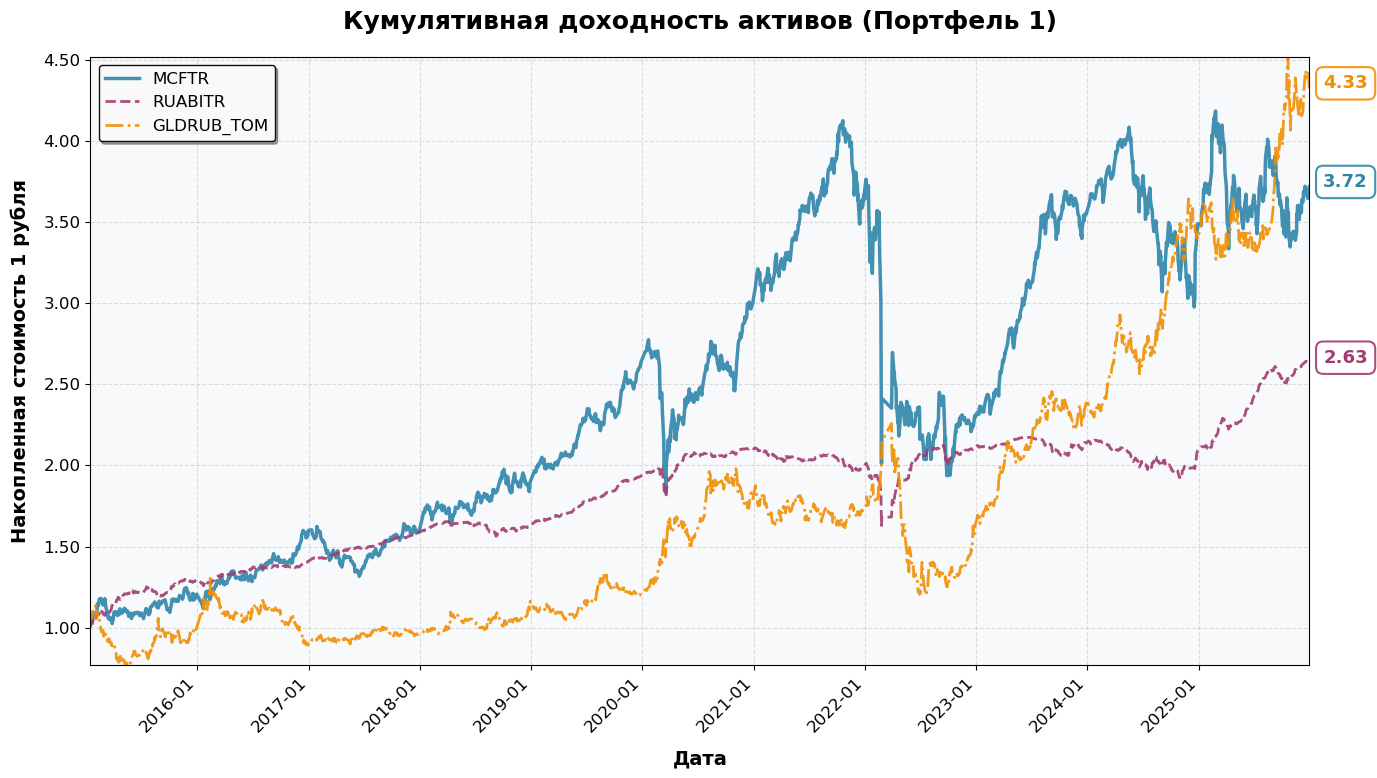

Итоговые кумулятивные доходности (Спец. 1):
  MCFTR: 3.7181
  RUABITR: 2.6340
  GLDRUB_TOM: 4.3261


In [50]:
cumulative_returns_1 = render_cumulative_returns(
    portfolio_1_daily_returns,
    asset_names_1,
    specification_number=1,
)

In [51]:
analysis_results_1 = run_specification_analysis(
    portfolio_1_daily_returns,
    initial_weights_1,
    asset_names_1,
    specification_number=1,
    risk_free_rate=risk_free_rate,
    mar=mar,
)


all metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Сохранён кэш: cache\analysis_results_1_0e9ed41c566df48f.pkl


In [52]:
bounds_1, bounds_summary_1, pooled_weights_1 = build_specification_bounds(
    analysis_results_1,
    asset_names_1,
    core_metrics_for_bounds,
)

bounds_summary_1


,Asset,Mean_Weight,Median_Weight,Std_Weight,P10_Weight,P90_Weight,Range_Width,N_Observations
0,MCFTR,25.11,22.37,17.55,0.19,51.3,51.11,6912
1,RUABITR,40.53,54.86,23.40,0.00,60.0,60.00,6912
2,GLDRUB_TOM,34.36,33.80,19.30,7.64,60.0,52.36,6912


In [53]:
all_optimizations_1, summary_static_1 = optimize_specification(
    portfolio_1_daily_returns,
    bounds_1,
    asset_names_1,
    risk_free_rate=risk_free_rate,
    mar=mar,
)


In [54]:
style_static_optimization_summary(summary_static_1, asset_names_1)


Metric,Metric_Value,MCFTR,RUABITR,GLDRUB_TOM,Total_Weight
Sharpe Ratio,0.6299,15.02%,52.44%,32.53%,100.00%
Sortino Ratio,0.8121,30.44%,17.79%,51.78%,100.00%
Calmar Ratio,1.0228,7.41%,60.00%,32.59%,100.00%
CVaR Ratio (5%),0.0190,17.71%,54.23%,28.06%,100.00%
Martin Ratio,1.8385,14.86%,60.00%,25.14%,100.00%
Omega Ratio,1.1172,19.05%,54.24%,26.71%,100.00%
Min Volatility,0.0904,12.10%,60.00%,27.90%,100.00%
Min Max Drawdown,0.1592,8.84%,60.00%,31.16%,100.00%


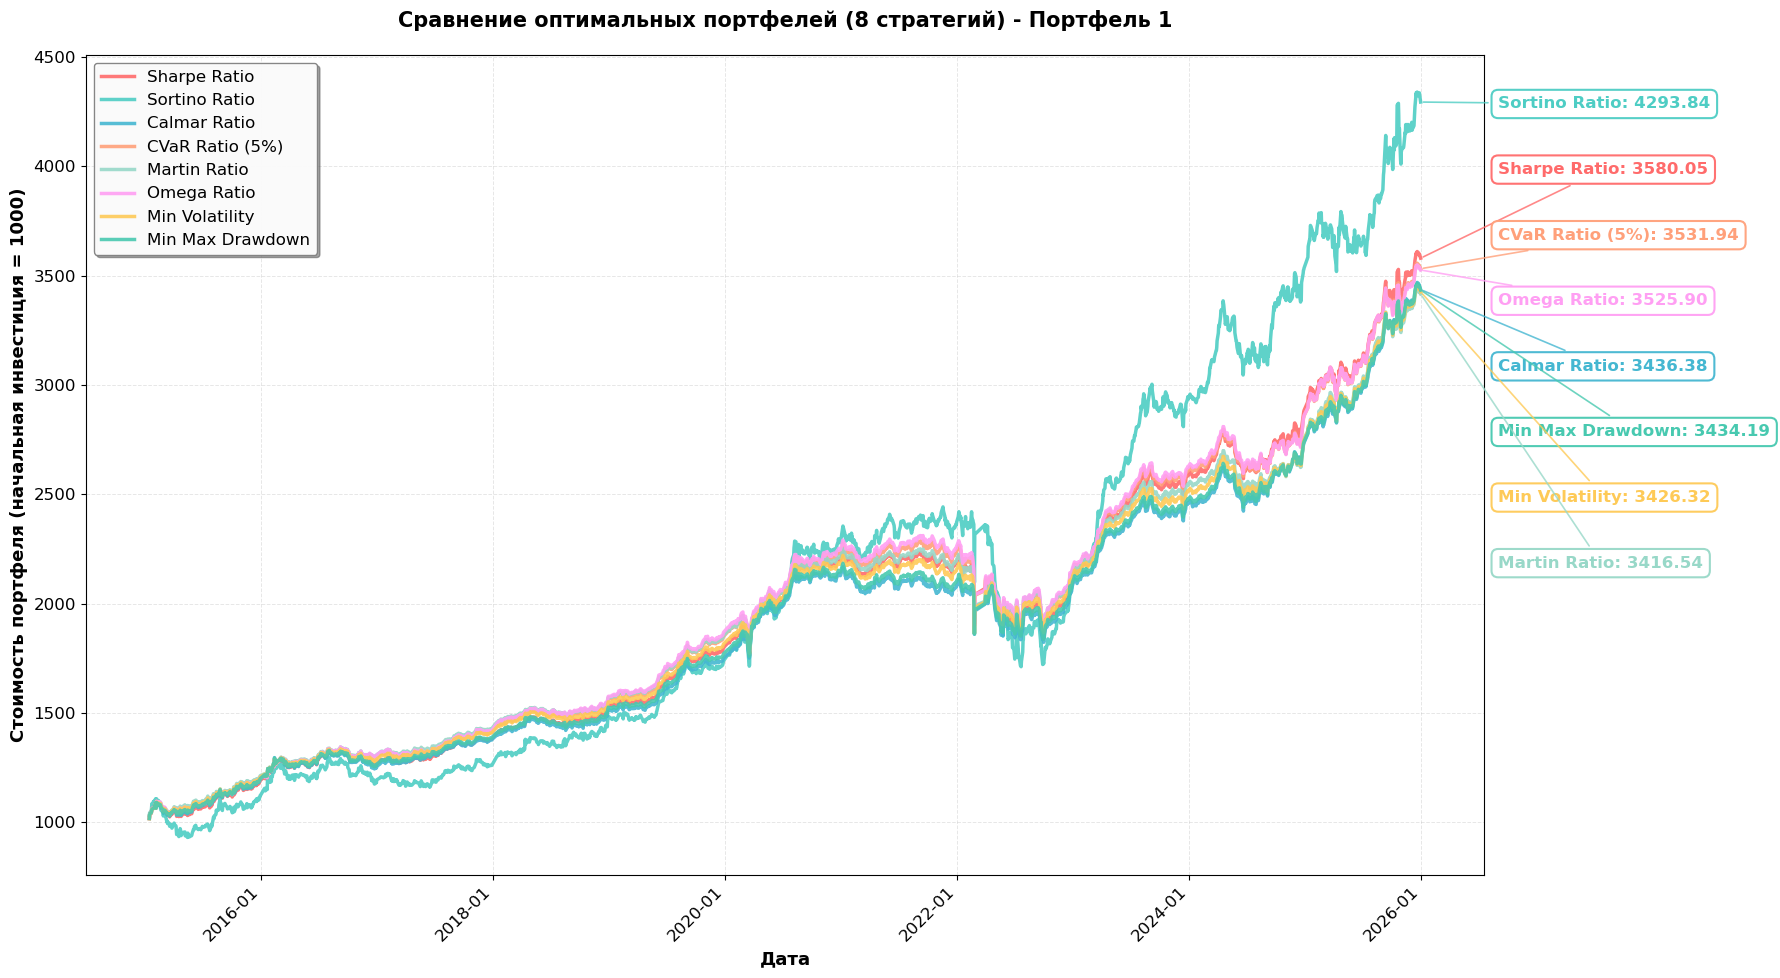

\nИтоговая стоимость портфелей (Спец. 1, начальная инвестиция = 1000):
  Sortino Ratio: 4293.84
  Sharpe Ratio: 3580.05
  CVaR Ratio (5%): 3531.94
  Omega Ratio: 3525.90
  Calmar Ratio: 3436.38
  Min Max Drawdown: 3434.19
  Min Volatility: 3426.32
  Martin Ratio: 3416.54


In [55]:
portfolio_values_1 = render_static_portfolio_values(
    portfolio_1_daily_returns,
    all_optimizations_1,
    specification_number=1,
)


## 3.3. Спецификация 2: MCFTR, RGBITR, GLDRUB_TOM

In [56]:
asset_names_2 = ['MCFTR', 'RGBITR', 'GLDRUB_TOM']
initial_weights_2 = np.array([30, 55, 15]) / 100

In [57]:
portfolio_2_data = build_synced_portfolio({
    'MCFTR': df_MCFTR,
    'RGBITR': df_RGBITR,
    'GLDRUB_TOM': df_GLDRUB_TOM,
})

Синхронизированный портфель: 2064 дат, 3 активов: ['MCFTR', 'RGBITR', 'GLDRUB_TOM']
Период: 2015-01-13 - 2025-12-30


In [58]:
portfolio_2_daily_returns = prepare_portfolio_daily_returns(portfolio_2_data)


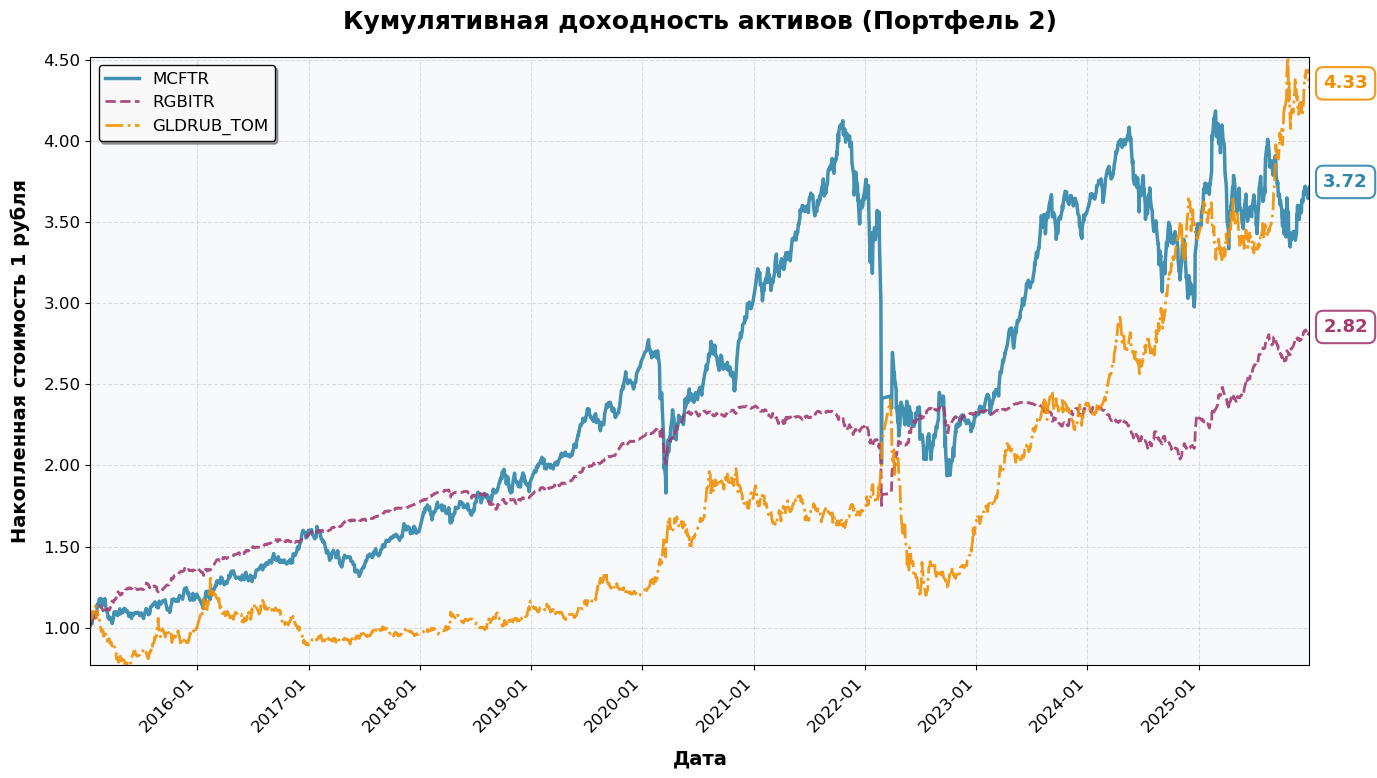

Итоговые кумулятивные доходности (Спец. 2):
  MCFTR: 3.7181
  RGBITR: 2.8236
  GLDRUB_TOM: 4.3261


In [59]:
cumulative_returns_2 = render_cumulative_returns(
    portfolio_2_daily_returns,
    asset_names_2,
    specification_number=2,
)


In [60]:
analysis_results_2 = run_specification_analysis(
    portfolio_2_daily_returns,
    initial_weights_2,
    asset_names_2,
    specification_number=2,
    risk_free_rate=risk_free_rate,
    mar=mar,
)


all metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Сохранён кэш: cache\analysis_results_2_650f3637085a5d37.pkl


In [61]:
bounds_2, bounds_summary_2, pooled_weights_2 = build_specification_bounds(
    analysis_results_2,
    asset_names_2,
    core_metrics_for_bounds,
)

bounds_summary_2


,Asset,Mean_Weight,Median_Weight,Std_Weight,P10_Weight,P90_Weight,Range_Width,N_Observations
0,MCFTR,25.29,24.60,17.67,1.12,51.3,50.18,6912
1,RGBITR,39.51,50.82,23.96,0.00,60.0,60.00,6912
2,GLDRUB_TOM,35.20,35.17,19.17,9.36,60.0,50.64,6912


In [62]:
all_optimizations_2, summary_static_2 = optimize_specification(
    portfolio_2_daily_returns,
    bounds_2,
    asset_names_2,
    risk_free_rate=risk_free_rate,
    mar=mar,
)

style_static_optimization_summary(summary_static_2, asset_names_2)


Metric,Metric_Value,MCFTR,RGBITR,GLDRUB_TOM,Total_Weight
Sharpe Ratio,0.6455,12.37%,55.36%,32.27%,100.00%
Sortino Ratio,0.8272,19.67%,36.44%,43.89%,100.00%
Calmar Ratio,1.0216,4.95%,60.00%,35.05%,100.00%
CVaR Ratio (5%),0.0196,16.33%,54.73%,28.94%,100.00%
Martin Ratio,1.9101,12.92%,60.00%,27.08%,100.00%
Omega Ratio,1.1240,15.47%,59.66%,24.87%,100.00%
Min Volatility,0.0978,11.01%,60.00%,28.99%,100.00%
Min Max Drawdown,0.1658,6.08%,60.00%,33.92%,100.00%


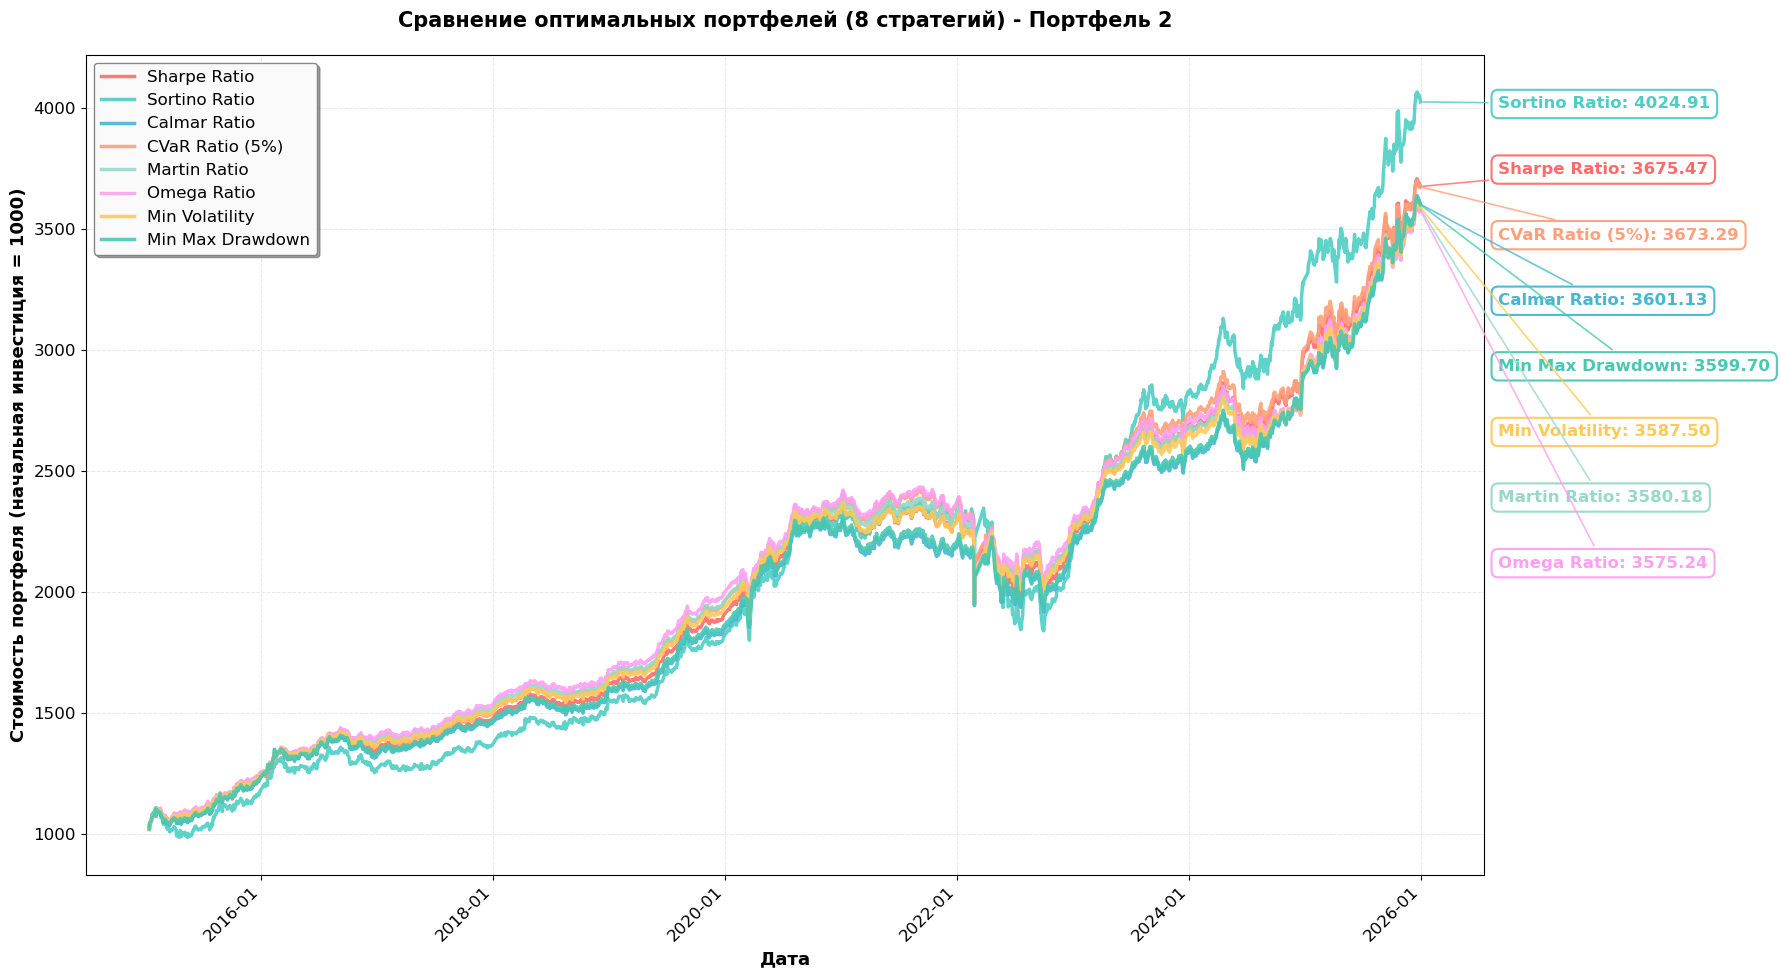

\nИтоговая стоимость портфелей (Спец. 2, начальная инвестиция = 1000):
  Sortino Ratio: 4024.91
  Sharpe Ratio: 3675.47
  CVaR Ratio (5%): 3673.29
  Calmar Ratio: 3601.13
  Min Max Drawdown: 3599.70
  Min Volatility: 3587.50
  Martin Ratio: 3580.18
  Omega Ratio: 3575.24


In [63]:
portfolio_values_2 = render_static_portfolio_values(
    portfolio_2_daily_returns,
    all_optimizations_2,
    specification_number=2,
)


## 3.4. Спецификация 3: MCFTR, RUGBITR3Y, RUGBITR10Y, GLDRUB_TOM

In [64]:
asset_names_3 = ['MCFTR', 'RUGBITR3Y', 'RUGBITR10Y', 'GLDRUB_TOM']
initial_weights_3 = np.array([30, 15, 40, 15]) / 100

In [65]:
portfolio_3_data = build_synced_portfolio({
    'MCFTR': df_MCFTR,
    'RUGBITR3Y': df_RUGBITR3Y,
    'RUGBITR10Y': df_RUGBITR10Y,
    'GLDRUB_TOM': df_GLDRUB_TOM,
})

Синхронизированный портфель: 2064 дат, 4 активов: ['MCFTR', 'RUGBITR3Y', 'RUGBITR10Y', 'GLDRUB_TOM']
Период: 2015-01-13 - 2025-12-30


In [66]:
portfolio_3_daily_returns = prepare_portfolio_daily_returns(portfolio_3_data)


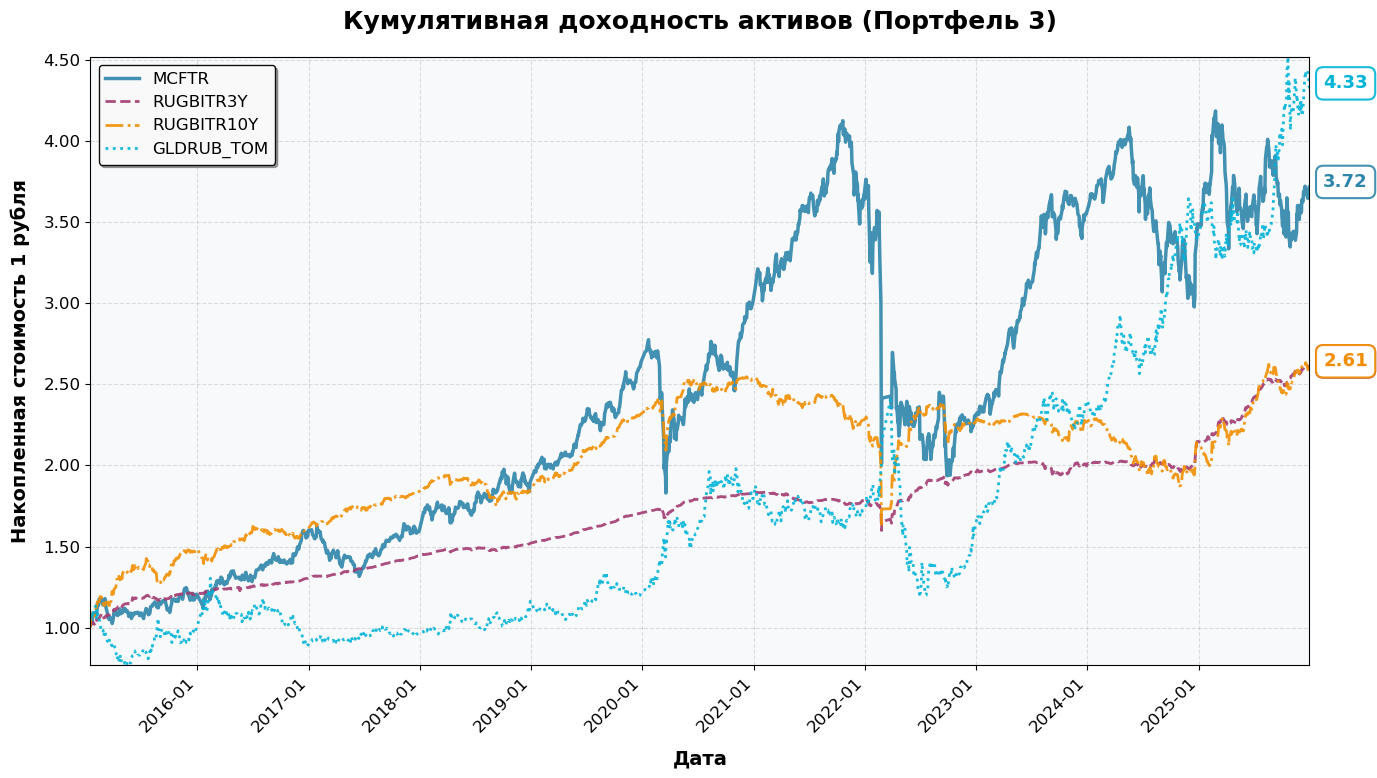

Итоговые кумулятивные доходности (Спец. 3):
  MCFTR: 3.7181
  RUGBITR3Y: 2.6105
  RUGBITR10Y: 2.6120
  GLDRUB_TOM: 4.3261


In [67]:
cumulative_returns_3 = render_cumulative_returns(
    portfolio_3_daily_returns,
    asset_names_3,
    specification_number=3,
)


In [68]:
analysis_results_3 = run_specification_analysis(
    portfolio_3_daily_returns,
    initial_weights_3,
    asset_names_3,
    specification_number=3,
    risk_free_rate=risk_free_rate,
    mar=mar,
)


all metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Сохранён кэш: cache\analysis_results_3_f9c5a769f3d92590.pkl


In [69]:
bounds_3, bounds_summary_3, pooled_weights_3 = build_specification_bounds(
    analysis_results_3,
    asset_names_3,
    core_metrics_for_bounds,
)

bounds_summary_3


,Asset,Mean_Weight,Median_Weight,Std_Weight,P10_Weight,P90_Weight,Range_Width,N_Observations
0,MCFTR,19.01,12.27,19.54,0.00,51.70,51.70,6912
1,RUGBITR3Y,38.48,53.67,24.77,0.00,60.00,60.00,6912
2,RUGBITR10Y,13.67,10.82,14.98,0.00,33.31,33.31,6912
3,GLDRUB_TOM,28.84,24.65,20.26,4.21,60.00,55.79,6912


In [70]:
all_optimizations_3, summary_static_3 = optimize_specification(
    portfolio_3_daily_returns,
    bounds_3,
    asset_names_3,
    risk_free_rate=risk_free_rate,
    mar=mar,
)


In [71]:
style_static_optimization_summary(summary_static_3, asset_names_3)


Metric,Metric_Value,MCFTR,RUGBITR3Y,RUGBITR10Y,GLDRUB_TOM,Total_Weight
Sharpe Ratio,0.6458,13.93%,60.00%,0.00%,26.07%,100.00%
Sortino Ratio,0.8185,19.23%,43.95%,0.00%,36.82%,100.00%
Calmar Ratio,1.4369,1.95%,60.00%,10.57%,27.48%,100.00%
CVaR Ratio (5%),0.0201,15.11%,60.00%,2.95%,21.94%,100.00%
Martin Ratio,2.5106,14.70%,60.00%,3.87%,21.43%,100.00%
Omega Ratio,1.1197,15.92%,60.00%,3.32%,20.75%,100.00%
Min Volatility,0.0664,0.00%,60.00%,26.38%,13.62%,100.00%
Min Max Drawdown,0.1065,1.64%,60.00%,10.82%,27.54%,100.00%


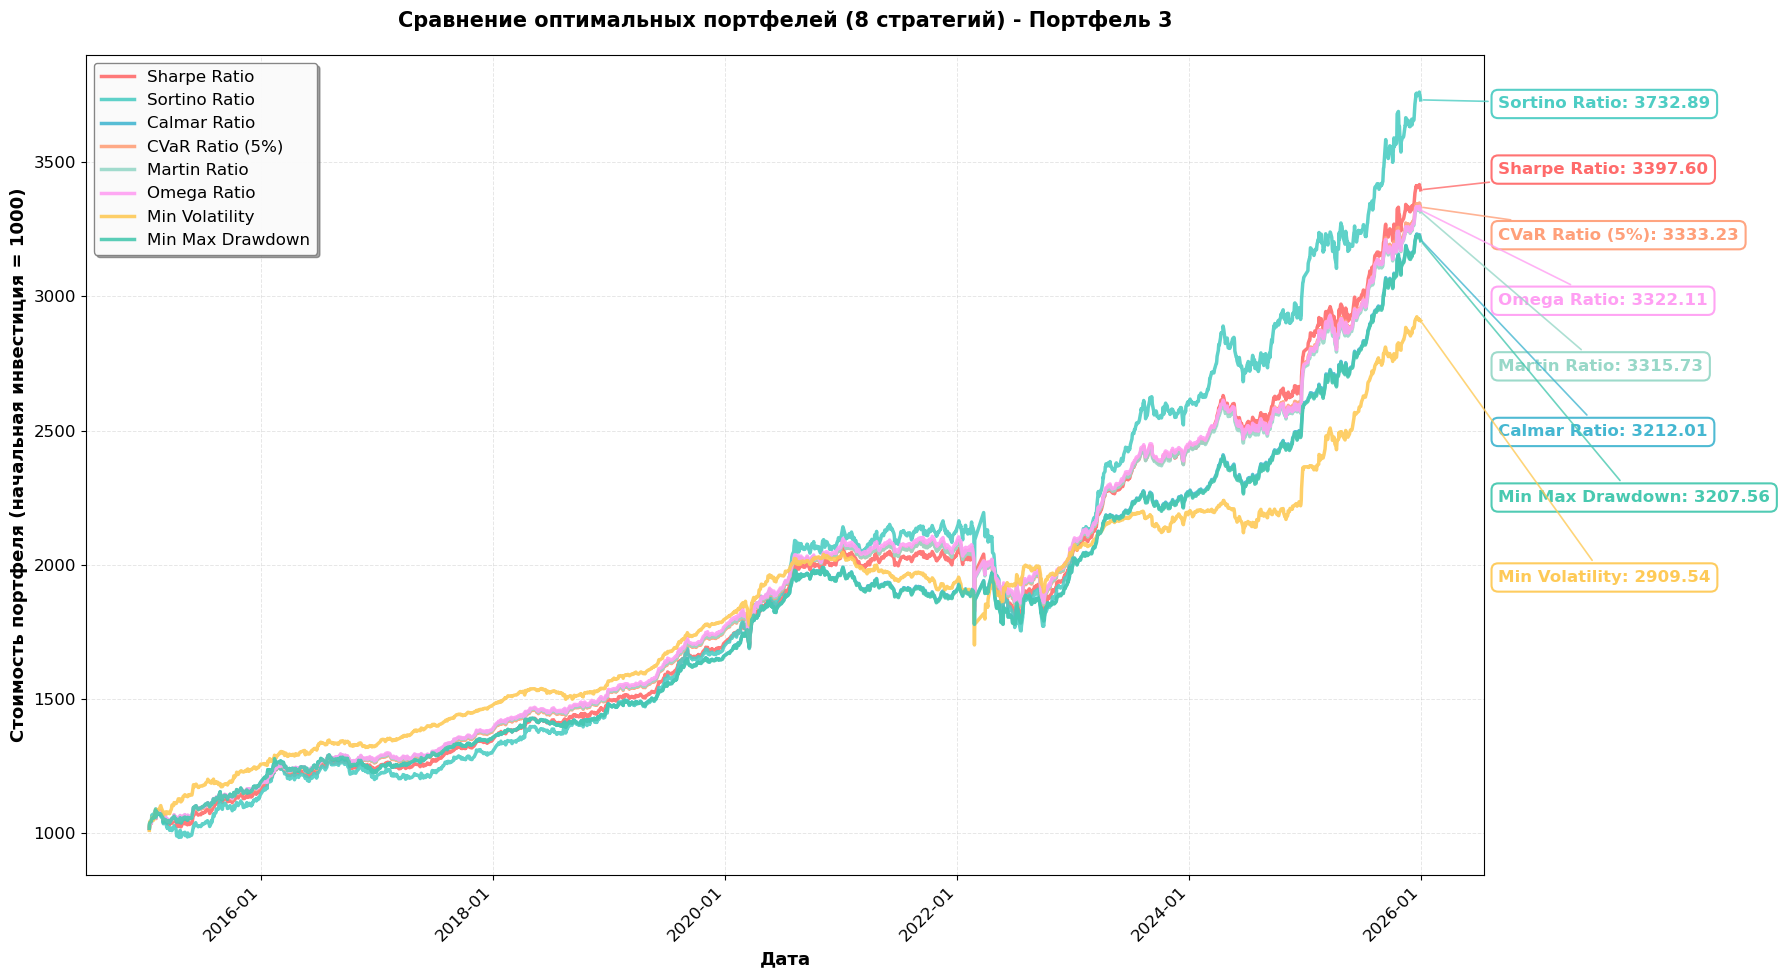

\nИтоговая стоимость портфелей (Спец. 3, начальная инвестиция = 1000):
  Sortino Ratio: 3732.89
  Sharpe Ratio: 3397.60
  CVaR Ratio (5%): 3333.23
  Omega Ratio: 3322.11
  Martin Ratio: 3315.73
  Calmar Ratio: 3212.01
  Min Max Drawdown: 3207.56
  Min Volatility: 2909.54


In [72]:
portfolio_values_3 = render_static_portfolio_values(
    portfolio_3_daily_returns,
    all_optimizations_3,
    specification_number=3,
)


## 3.5. Спецификация 4: MEBCTR, RUGBITR3Y, RUGBITR10Y, GLDRUB_TOM

In [73]:
asset_names_4 = ['MEBCTR', 'RUGBITR3Y', 'RUGBITR10Y', 'GLDRUB_TOM']
initial_weights_4 = np.array([30, 15, 40, 15]) / 100

In [74]:
portfolio_4_data = build_synced_portfolio({
    'MEBCTR': df_MEBCTR,
    'RUGBITR3Y': df_RUGBITR3Y,
    'RUGBITR10Y': df_RUGBITR10Y,
    'GLDRUB_TOM': df_GLDRUB_TOM,
})

Синхронизированный портфель: 2063 дат, 4 активов: ['MEBCTR', 'RUGBITR3Y', 'RUGBITR10Y', 'GLDRUB_TOM']
Период: 2015-01-13 - 2025-12-30


In [75]:
portfolio_4_daily_returns = prepare_portfolio_daily_returns(portfolio_4_data)


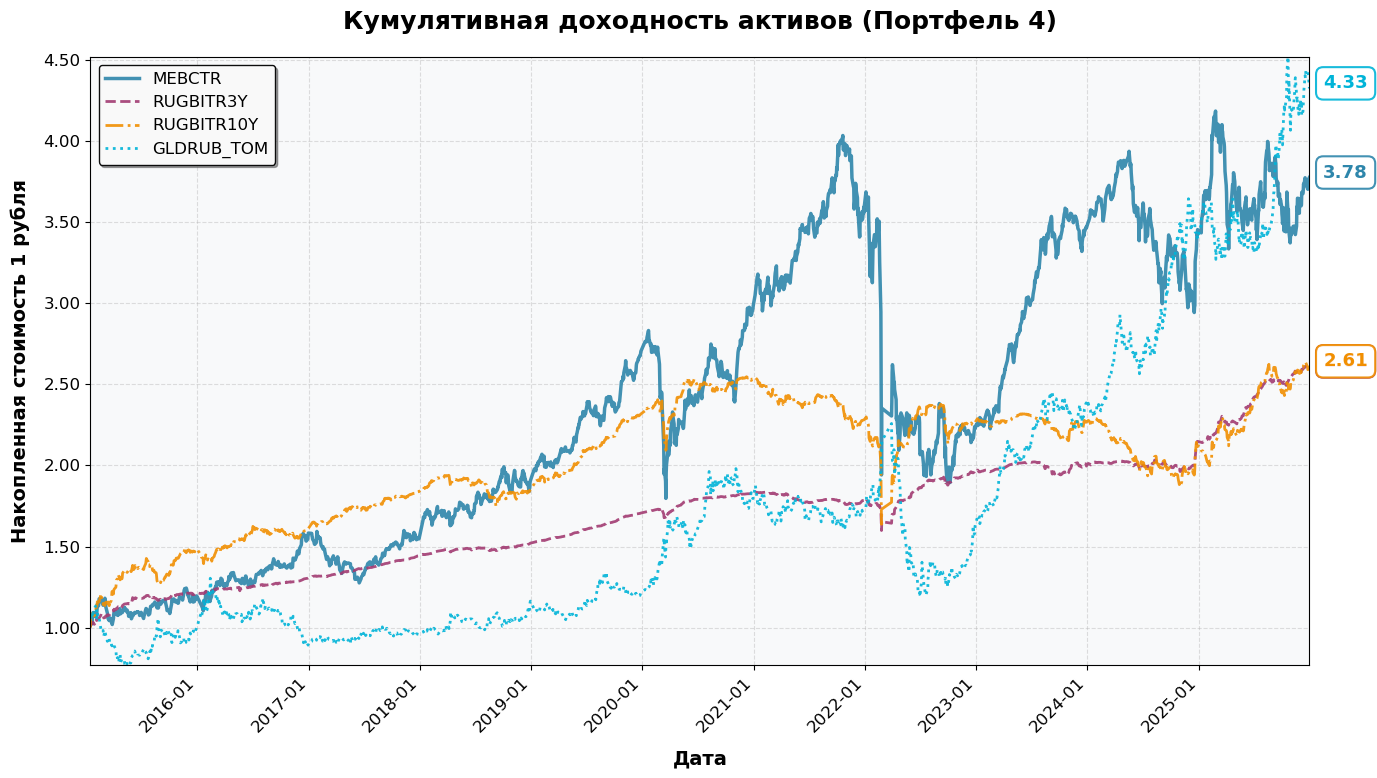

Итоговые кумулятивные доходности (Спец. 4):
  MEBCTR: 3.7762
  RUGBITR3Y: 2.6105
  RUGBITR10Y: 2.6120
  GLDRUB_TOM: 4.3261


In [76]:
cumulative_returns_4 = render_cumulative_returns(
    portfolio_4_daily_returns,
    asset_names_4,
    specification_number=4,
)


In [77]:
analysis_results_4 = run_specification_analysis(
    portfolio_4_daily_returns,
    initial_weights_4,
    asset_names_4,
    specification_number=4,
    risk_free_rate=risk_free_rate,
    mar=mar,
)


all metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Сохранён кэш: cache\analysis_results_4_1be1b2c1610fa04d.pkl


In [78]:
bounds_4, bounds_summary_4, pooled_weights_4 = build_specification_bounds(
    analysis_results_4,
    asset_names_4,
    core_metrics_for_bounds,
)

bounds_summary_4


,Asset,Mean_Weight,Median_Weight,Std_Weight,P10_Weight,P90_Weight,Range_Width,N_Observations
0,MEBCTR,17.92,11.28,18.87,0.0,49.04,49.04,6912
1,RUGBITR3Y,38.88,53.64,24.36,0.0,60.00,60.00,6912
2,RUGBITR10Y,14.02,11.10,15.43,0.0,34.28,34.28,6912
3,GLDRUB_TOM,29.18,24.65,20.45,3.6,60.00,56.40,6912


In [79]:
all_optimizations_4, summary_static_4 = optimize_specification(
    portfolio_4_daily_returns,
    bounds_4,
    asset_names_4,
    risk_free_rate=risk_free_rate,
    mar=mar,
)


In [80]:
style_static_optimization_summary(summary_static_4, asset_names_4)


Metric,Metric_Value,MEBCTR,RUGBITR3Y,RUGBITR10Y,GLDRUB_TOM,Total_Weight
Sharpe Ratio,0.6583,13.39%,60.00%,0.00%,26.61%,100.00%
Sortino Ratio,0.8331,18.06%,46.21%,0.00%,35.72%,100.00%
Calmar Ratio,1.4237,1.86%,60.00%,10.78%,27.36%,100.00%
CVaR Ratio (5%),0.0205,14.45%,60.00%,2.80%,22.75%,100.00%
Martin Ratio,2.4684,15.25%,60.00%,3.45%,21.30%,100.00%
Omega Ratio,1.1210,15.77%,60.00%,3.12%,21.11%,100.00%
Min Volatility,0.0659,0.00%,60.00%,25.89%,14.11%,100.00%
Min Max Drawdown,0.1074,1.46%,60.00%,11.10%,27.43%,100.00%


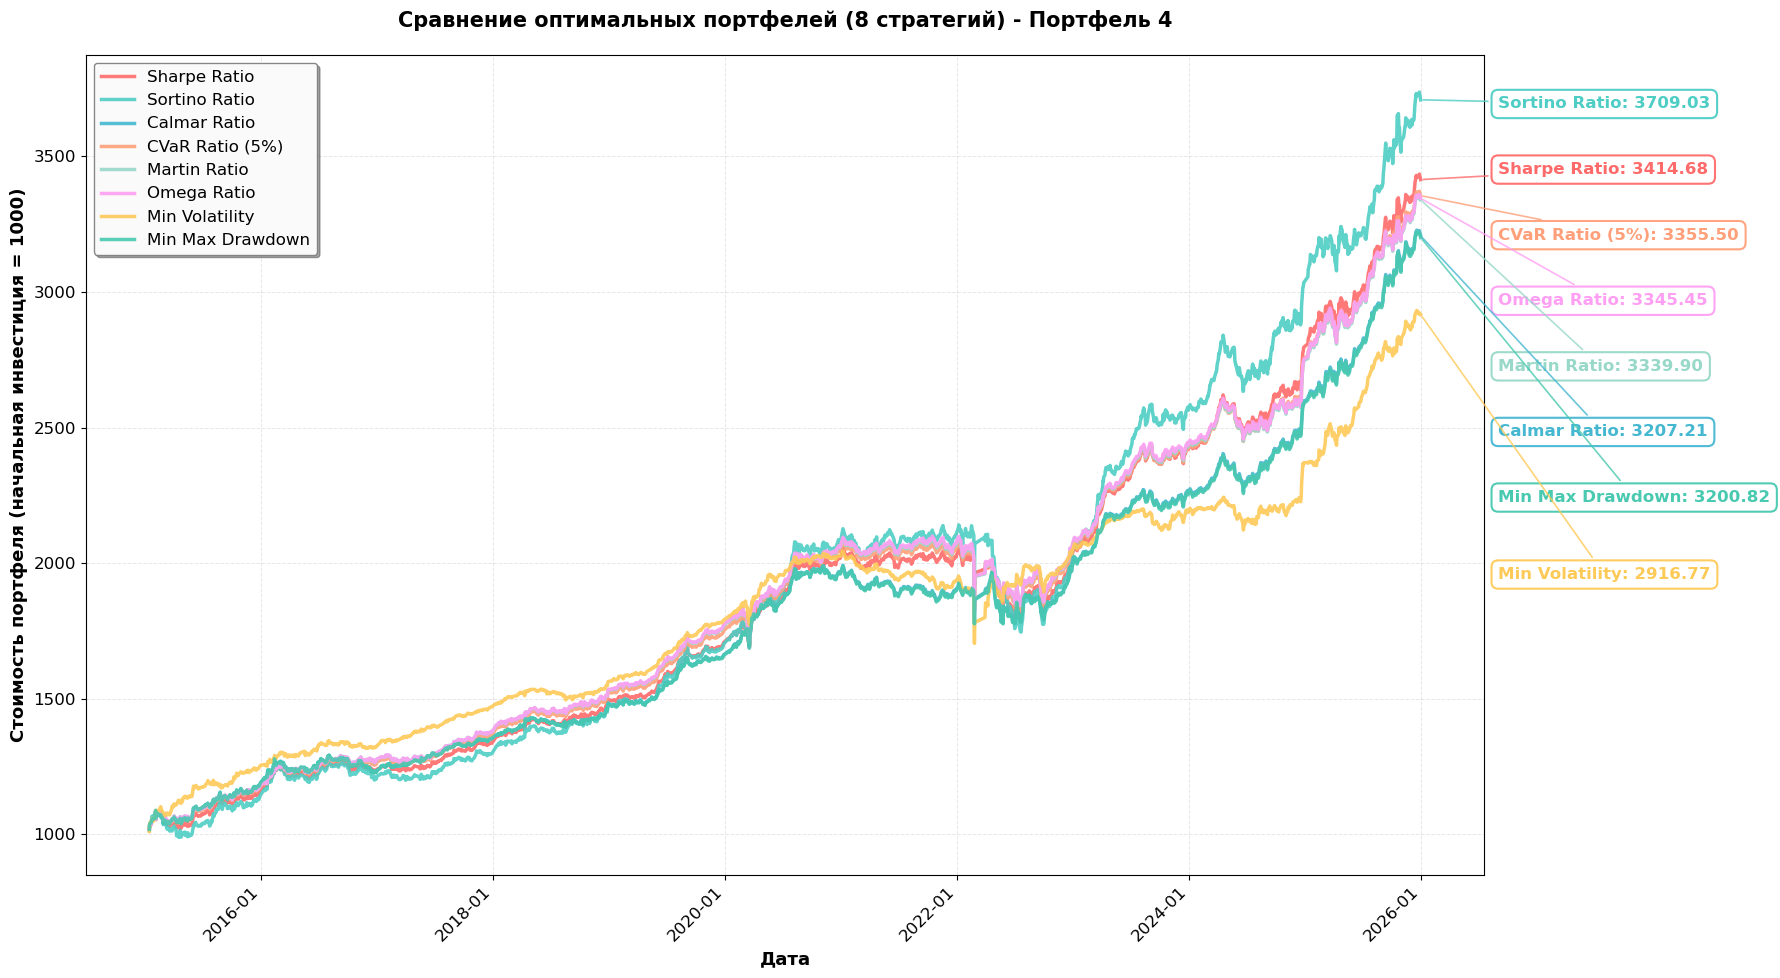

\nИтоговая стоимость портфелей (Спец. 4, начальная инвестиция = 1000):
  Sortino Ratio: 3709.03
  Sharpe Ratio: 3414.68
  CVaR Ratio (5%): 3355.50
  Omega Ratio: 3345.45
  Martin Ratio: 3339.90
  Calmar Ratio: 3207.21
  Min Max Drawdown: 3200.82
  Min Volatility: 2916.77


In [81]:
portfolio_values_4 = render_static_portfolio_values(
    portfolio_4_daily_returns,
    all_optimizations_4,
    specification_number=4,
)


## 3.6. Интеграционная проверка спецификаций


In [82]:
section_3_specifications = {
    "Спец. 1": {
        "portfolio_daily_returns": portfolio_1_daily_returns,
        "asset_names": asset_names_1,
        "bounds_pct": bounds_1,
        "all_optimizations": all_optimizations_1,
    },
    "Спец. 2": {
        "portfolio_daily_returns": portfolio_2_daily_returns,
        "asset_names": asset_names_2,
        "bounds_pct": bounds_2,
        "all_optimizations": all_optimizations_2,
    },
    "Спец. 3": {
        "portfolio_daily_returns": portfolio_3_daily_returns,
        "asset_names": asset_names_3,
        "bounds_pct": bounds_3,
        "all_optimizations": all_optimizations_3,
    },
    "Спец. 4": {
        "portfolio_daily_returns": portfolio_4_daily_returns,
        "asset_names": asset_names_4,
        "bounds_pct": bounds_4,
        "all_optimizations": all_optimizations_4,
    },
}

section_3_compatibility_report = validate_section_3_specifications(
    section_3_specifications,
    required_metrics=core_metrics_for_bounds,
)
print("Совместимость данных, границ и статических оптимизаций:")
print(section_3_compatibility_report.to_string())

section_3_optimizer_cross_checks = cross_check_section_3_optimizers(
    section_3_specifications,
    risk_free_rate=risk_free_rate,
    mar=mar,
)
print("Сверка SLSQP с differential evolution:")
print(section_3_optimizer_cross_checks)

Совместимость данных, границ и статических оптимизаций:
              Наблюдений  Активов  Проверено метрик
Спецификация                                       
Спец. 1             2062        3                 8
Спец. 2             2063        3                 8
Спец. 3             2063        4                 8
Спец. 4             2062        4                 8
volatility    multi-start=0.09045 DE=0.09045 gap=0.000%
volatility    multi-start=0.09777 DE=0.09777 gap=0.000%
volatility    multi-start=0.06637 DE=0.06782 gap=-2.136%
volatility    multi-start=0.06590 DE=0.06671 gap=-1.214%
Сверка SLSQP с differential evolution:
{'Спец. 1': True, 'Спец. 2': True, 'Спец. 3': True, 'Спец. 4': True}


## 3.7. Сравнение результатов спецификаций 

In [83]:
def compute_all_metrics_for_weights(
    portfolio_daily_returns: pd.DataFrame,
    weights: np.ndarray,
    risk_free_rate: float,
    mar: float,
    cvar_alpha: float = 0.05,
    periods_per_year: int = TRADING_DAYS,
) -> dict[str, float]:
    """Собирает сопоставимый отчёт из канонических портфельных метрик.

    Функция намеренно делегирует расчёты проверенным функциям блока 1.3,
    чтобы итоговые таблицы не содержали независимую копию тех же формул.

    Args:
        portfolio_daily_returns: Дневные простые доходности активов.
        weights: Long-only веса, сумма которых равна единице.
        risk_free_rate: Годовая безрисковая ставка в долях.
        mar: Годовой minimum acceptable return в долях.
        cvar_alpha: Размер левого хвоста для CVaR.
        periods_per_year: Число торговых дней для аннуализации.

    Returns:
        CAGR, волатильность и MDD в процентах; остальные метрики —
        безразмерные отношения в соглашениях блока 1.3.
    """
    returns, normalized_weights = _validate_inputs(
        portfolio_daily_returns,
        weights,
    )
    portfolio_returns = _portfolio_return_series(returns, normalized_weights)
    cagr = _cagr(portfolio_returns, periods_per_year=periods_per_year)

    return {
        "CAGR": cagr * 100,
        "Volatility": calculate_portfolio_volatility(
            returns,
            normalized_weights,
            periods_per_year=periods_per_year,
        ) * 100,
        "Sharpe": calculate_portfolio_sharpe_ratio(
            returns,
            normalized_weights,
            risk_free_rate,
            periods_per_year=periods_per_year,
        ),
        "Sortino": calculate_portfolio_sortino_ratio(
            returns,
            normalized_weights,
            mar=mar,
            mar_annual=True,
            periods_per_year=periods_per_year,
        ),
        "Calmar": calculate_portfolio_calmar_ratio(
            returns,
            normalized_weights,
            periods_per_year=periods_per_year,
        ),
        "MDD": calculate_portfolio_max_drawdown(returns, normalized_weights) * 100,
        "CVaR Ratio": calculate_portfolio_cvar_ratio(
            returns,
            normalized_weights,
            risk_free_rate,
            alpha=cvar_alpha,
            periods_per_year=periods_per_year,
        ),
        "Martin Ratio": calculate_portfolio_martin_ratio(
            returns,
            normalized_weights,
            risk_free_rate,
            periods_per_year=periods_per_year,
        ),
        "Omega": calculate_portfolio_omega_ratio(
            returns,
            normalized_weights,
            threshold_return=mar,
            threshold_annual=True,
            periods_per_year=periods_per_year,
        ),
    }


def extract_median_weights(bounds_summary: pd.DataFrame) -> np.ndarray:
    """Извлекает и нормализует медианные веса оконного распределения.

    Args:
        bounds_summary: Таблица агрегации с колонкой ``Median_Weight``
            в процентах и строками в порядке активов спецификации.

    Returns:
        Одномерный массив неотрицательных весов с суммой 1.0.

    Raises:
        KeyError: В таблице отсутствует ``Median_Weight``.
        ValueError: Веса пусты, нечисловые, отрицательные или имеют
            неположительную сумму.
    """
    if "Median_Weight" not in bounds_summary:
        raise KeyError("bounds_summary must contain Median_Weight")

    weights = pd.to_numeric(bounds_summary["Median_Weight"], errors="coerce").to_numpy(
        dtype=float
    )
    if weights.size == 0 or not np.isfinite(weights).all():
        raise ValueError("Median weights must be non-empty and finite")
    if (weights < 0).any():
        raise ValueError("Median weights must be non-negative")
    total = float(weights.sum())
    if total <= 0:
        raise ValueError("Median weights must have a positive sum")
    return weights / total


In [84]:
def build_comparison_table(
    specifications: Mapping[str, tuple[pd.DataFrame, np.ndarray]],
    risk_free_rate: float,
    mar: float,
) -> pd.DataFrame:
    """Строит сводную таблицу метрик спецификаций и бенчмарков.

    Args:
        specifications: Соответствие подписи паре ``(доходности, веса)``.
        risk_free_rate: Годовая безрисковая ставка в долях.
        mar: Годовой minimum acceptable return в долях.

    Returns:
        Таблица, где одна строка соответствует одной спецификации.
    """
    rows: list[dict[str, float | str]] = []
    for label, (returns, weights) in specifications.items():
        metrics: dict[str, float | str] = compute_all_metrics_for_weights(
            returns,
            weights,
            risk_free_rate,
            mar,
        )
        metrics["Portfolio"] = label
        rows.append(metrics)

    comparison = pd.DataFrame(rows)
    ordered_columns = [
        "Portfolio",
        *(column for column in comparison.columns if column != "Portfolio"),
    ]
    comparison = comparison[ordered_columns]
    numeric_columns = comparison.select_dtypes(include=[np.number]).columns
    comparison[numeric_columns] = comparison[numeric_columns].round(4)
    return comparison


In [85]:
def _parse_cbr_deposit_rates(html: str) -> tuple[dict[str, float], int]:
    """Преобразует HTML-таблицу ЦБ в среднемесячные депозитные ставки.

    Args:
        html: HTML страницы со ставками по декадам.

    Returns:
        Словарь ``YYYY-MM -> ставка, %`` и число распознанных декад.

    Raises:
        ValueError: Таблица отсутствует или не содержит корректных строк.
    """
    soup = BeautifulSoup(html, "html.parser")
    table = soup.find("table", class_="data")
    if table is None:
        for candidate in soup.find_all("table"):
            headers = [header.get_text(strip=True) for header in candidate.find_all("th")]
            if any("Декада" in header or "Ставка" in header for header in headers):
                table = candidate
                break
    if table is None:
        raise ValueError("Не удалось найти таблицу депозитных ставок ЦБ")

    rates_by_month: defaultdict[str, list[float]] = defaultdict(list)
    for row in table.find_all("tr"):
        cells = row.find_all("td")
        if len(cells) < 2:
            continue
        date_parts = cells[0].get_text(strip=True).split(".")
        if len(date_parts) != 3:
            continue
        try:
            month = int(date_parts[1])
            year = int(date_parts[2])
            rate = float(cells[1].get_text(strip=True).replace(",", "."))
        except (ValueError, IndexError):
            continue
        if 1 <= month <= 12 and np.isfinite(rate):
            rates_by_month[f"{year}-{month:02d}"].append(rate)

    if not rates_by_month:
        raise ValueError("Таблица ЦБ не содержит распознаваемых ставок")

    observation_count = sum(map(len, rates_by_month.values()))
    monthly_rates = {
        month: round(float(np.mean(values)), 2)
        for month, values in sorted(rates_by_month.items())
    }
    return monthly_rates, observation_count


def fetch_cbr_deposit_rates(
    url: str = (
        "https://www.cbr.ru/statistics/avgprocstav/"
        "?UniDbQuery.Posted=True"
        "&UniDbQuery.From=1.01.2015"
        "&UniDbQuery.To=3.12.2025"
    ),
) -> tuple[dict[str, float], int]:
    """Загружает и агрегирует ставки топ-10 банков с сайта ЦБ.

    Args:
        url: Страница ЦБ с заданным периодом наблюдений.

    Returns:
        Среднемесячные ставки в процентах и число исходных декад.

    Raises:
        requests.HTTPError: Сервер вернул ошибочный HTTP-статус.
        requests.RequestException: Сетевая ошибка или таймаут.
        ValueError: Формат HTML не соответствует ожидаемой таблице.

    Side Effects:
        Выполняет HTTP GET-запрос.
    """
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    response.encoding = "utf-8"
    return _parse_cbr_deposit_rates(response.text)


In [86]:
def build_deposit_daily_returns(
    portfolio_index: pd.DatetimeIndex,
    deposit_rates: Mapping[str, float],
    trading_days: int = TRADING_DAYS,
) -> pd.Series:
    """Преобразует месячные годовые ставки в дневной депозитный бенчмарк.

    Args:
        portfolio_index: Торговые даты сравниваемого портфеля.
        deposit_rates: Соответствие ``YYYY-MM -> годовая ставка, %``.
        trading_days: Число торговых дней в году.

    Returns:
        Дневные геометрически эквивалентные доходности с исходным индексом.

    Raises:
        TypeError: ``portfolio_index`` не DatetimeIndex.
        ValueError: Индекс пуст, периодичность неположительна, отсутствует
            ставка хотя бы для одного месяца или годовая ставка <= -100%.
    """
    if not isinstance(portfolio_index, pd.DatetimeIndex):
        raise TypeError("portfolio_index must be a DatetimeIndex")
    if portfolio_index.empty:
        raise ValueError("portfolio_index must not be empty")
    if trading_days <= 0:
        raise ValueError("trading_days must be positive")

    month_keys = pd.Series(
        portfolio_index.to_period("M").astype(str),
        index=portfolio_index,
    )
    annual_rates_pct = month_keys.map(deposit_rates)
    if annual_rates_pct.isna().any():
        missing_months = sorted(month_keys[annual_rates_pct.isna()].unique())
        raise ValueError(f"Missing deposit rates for months: {missing_months}")

    annual_rates = annual_rates_pct.astype(float) / 100.0
    if (annual_rates <= -1.0).any():
        raise ValueError("Deposit rates must be greater than -100%")
    daily_returns = np.expm1(np.log1p(annual_rates) / trading_days)
    return pd.Series(daily_returns, index=portfolio_index, name="Deposit")


In [87]:
def test_block_3_7_metric_report_matches_canonical_functions() -> None:
    """Фиксирует единые формулы между отчётом и каноническими метриками."""
    returns = _make_synthetic_returns(seed=31, n_years=2, n_assets=3)
    weights = np.array([0.4, 0.35, 0.25])
    risk_free_rate = 0.08
    mar = 0.10

    report = compute_all_metrics_for_weights(
        returns,
        weights,
        risk_free_rate,
        mar,
    )

    portfolio_returns = _portfolio_return_series(returns, weights)
    expected = {
        "CAGR": _cagr(portfolio_returns) * 100,
        "Volatility": calculate_portfolio_volatility(returns, weights) * 100,
        "Sharpe": calculate_portfolio_sharpe_ratio(returns, weights, risk_free_rate),
        "Sortino": calculate_portfolio_sortino_ratio(
            returns, weights, mar=mar, mar_annual=True
        ),
        "Calmar": calculate_portfolio_calmar_ratio(returns, weights),
        "MDD": calculate_portfolio_max_drawdown(returns, weights) * 100,
        "CVaR Ratio": calculate_portfolio_cvar_ratio(
            returns, weights, risk_free_rate, alpha=0.05
        ),
        "Martin Ratio": calculate_portfolio_martin_ratio(
            returns, weights, risk_free_rate
        ),
        "Omega": calculate_portfolio_omega_ratio(
            returns, weights, threshold_return=mar, threshold_annual=True
        ),
    }
    assert report.keys() == expected.keys()
    for metric_name, expected_value in expected.items():
        assert report[metric_name] == pytest.approx(expected_value)


def test_block_3_7_extract_median_weights_validates_and_normalizes() -> None:
    """Проверяет контракт медианных весов оконного распределения."""
    summary = pd.DataFrame({"Median_Weight": [20.0, 30.0, 40.0]})
    np.testing.assert_allclose(extract_median_weights(summary), [2 / 9, 1 / 3, 4 / 9])

    with pytest.raises(KeyError):
        extract_median_weights(pd.DataFrame({"Mean_Weight": [100.0]}))
    with pytest.raises(ValueError):
        extract_median_weights(pd.DataFrame({"Median_Weight": [0.0, 0.0]}))


def test_block_3_7_parses_deposit_rates_and_builds_daily_series() -> None:
    """Проверяет HTML-парсер и геометрическое преобразование ставок."""
    html = """
    <table class="data">
      <tr><th>Декада</th><th>Ставка</th></tr>
      <tr><td>1.01.2024</td><td>10,0</td></tr>
      <tr><td>2.01.2024</td><td>12,0</td></tr>
      <tr><td>1.02.2024</td><td>9,0</td></tr>
    </table>
    """
    monthly_rates, observation_count = _parse_cbr_deposit_rates(html)
    assert observation_count == 3
    assert monthly_rates == {"2024-01": 11.0, "2024-02": 9.0}

    index = pd.DatetimeIndex(["2024-01-10", "2024-02-12"])
    daily = build_deposit_daily_returns(index, monthly_rates)
    expected = np.expm1(np.log1p(np.array([0.11, 0.09])) / TRADING_DAYS)
    np.testing.assert_allclose(daily.to_numpy(), expected)

    with pytest.raises(ValueError, match="Missing deposit rates"):
        build_deposit_daily_returns(
            pd.DatetimeIndex(["2024-03-01"]),
            monthly_rates,
        )


In [88]:
run_notebook_tests("test_block_3_7")


...                                                                                          [100%]


0

In [89]:
deposit_monthly_rates_pct, n_obs = fetch_cbr_deposit_rates()
avg_deposit_rate = np.mean(list(deposit_monthly_rates_pct.values()))
print(f'Загружено {n_obs} подекадных наблюдений ({len(deposit_monthly_rates_pct)} месяцев)')
print(f'Период: {min(deposit_monthly_rates_pct.keys())} — {max(deposit_monthly_rates_pct.keys())}')
print(f'Средняя максимальная ставка по депозитам: {avg_deposit_rate:.2f}%')

Загружено 396 подекадных наблюдений (132 месяцев)
Период: 2015-01 — 2025-12
Средняя максимальная ставка по депозитам: 9.71%


In [90]:
median_w1 = extract_median_weights(bounds_summary_1)
median_w2 = extract_median_weights(bounds_summary_2)
median_w3 = extract_median_weights(bounds_summary_3)
median_w4 = extract_median_weights(bounds_summary_4)
 
print("\nМедианные веса (нормализованные):")
for i, (w, names) in enumerate([
    (median_w1, asset_names_1),
    (median_w2, asset_names_2),
    (median_w3, asset_names_3),
    (median_w4, asset_names_4),
], 1):
    parts = ", ".join(f"{n}: {v:.2f}%" for n, v in zip(names, w * 100))
    print(f"  Спецификация {i}: [{parts}], сумма = {w.sum()*100:.2f}%")


Медианные веса (нормализованные):
  Спецификация 1: [MCFTR: 20.15%, RUABITR: 49.41%, GLDRUB_TOM: 30.44%], сумма = 100.00%
  Спецификация 2: [MCFTR: 22.24%, RGBITR: 45.95%, GLDRUB_TOM: 31.80%], сумма = 100.00%
  Спецификация 3: [MCFTR: 12.10%, RUGBITR3Y: 52.92%, RUGBITR10Y: 10.67%, GLDRUB_TOM: 24.31%], сумма = 100.00%
  Спецификация 4: [MEBCTR: 11.20%, RUGBITR3Y: 53.28%, RUGBITR10Y: 11.03%, GLDRUB_TOM: 24.49%], сумма = 100.00%


In [91]:
n3 = len(asset_names_3)
equal_w3 = np.ones(n3) / n3
only_equity = np.array([1.0, 0.0, 0.0, 0.0])
only_bond_short = np.array([0.0, 1.0, 0.0, 0.0])
only_bond_long = np.array([0.0, 0.0, 1.0, 0.0])
only_gold = np.array([0.0, 0.0, 0.0, 1.0])
 
deposit_daily_ret = build_deposit_daily_returns(
    portfolio_3_daily_returns.index,
    deposit_monthly_rates_pct,
)
deposit_returns_df = deposit_daily_ret.to_frame('Deposit')
 
portfolio_60_40_data = build_synced_portfolio({
    'MCFTR': df_MCFTR,
    'RGBITR': df_RGBITR,
})
portfolio_60_40_returns = portfolio_60_40_data.pct_change().dropna()
weights_60_40 = np.array([0.60, 0.40])
weights_dalio = initial_weights_3
 
print(f"\nВеса Далио (оригинал): {weights_dalio * 100}%")
print(f"Равновзвешенные (Спец. 3): {equal_w3 * 100}%")

Синхронизированный портфель: 2762 дат, 2 активов: ['MCFTR', 'RGBITR']
Период: 2015-01-05 - 2025-12-30

Веса Далио (оригинал): [30. 15. 40. 15.]%
Равновзвешенные (Спец. 3): [25. 25. 25. 25.]%


In [92]:
comparison = build_comparison_table(
    specifications={
        "Спец. 1 (медиана)": (portfolio_1_daily_returns, median_w1),
        "Спец. 2 (медиана)": (portfolio_2_daily_returns, median_w2),
        "Спец. 3 (медиана)": (portfolio_3_daily_returns, median_w3),
        "Спец. 4 (медиана)": (portfolio_4_daily_returns, median_w4),
        "Равновзвешенный (Спец.3)": (portfolio_3_daily_returns, equal_w3),
        "Депозит (макс. ставка)": (deposit_returns_df, np.array([1.0])),
        "100% Акции (MCFTR)": (portfolio_3_daily_returns, only_equity),
        "100% Облиг. кратк.": (portfolio_3_daily_returns, only_bond_short),
        "100% Облиг. длин.": (portfolio_3_daily_returns, only_bond_long),
        "100% Золото": (portfolio_3_daily_returns, only_gold),
        "60/40 (MCFTR/RGBITR)": (portfolio_60_40_returns, weights_60_40),
        "Далио оригинал (Спец.3)": (portfolio_3_daily_returns, weights_dalio),
    },
    risk_free_rate=risk_free_rate,
    mar=mar,
)
 
print("\n" + comparison.to_string(index=False))


               Portfolio    CAGR  Volatility  Sharpe  Sortino  Calmar     MDD  CVaR Ratio  Martin Ratio  Omega
       Спец. 1 (медиана) 17.0611     10.4105  0.6249   0.7679  0.8741 19.5175      0.0189        1.6875 1.1168
       Спец. 2 (медиана) 17.8137     11.4321  0.6351   0.7951  0.8286 21.4978      0.0194        1.6648 1.1220
       Спец. 3 (медиана) 15.8647      8.3689  0.6312   0.7696  1.1928 13.3001      0.0195        2.2460 1.1171
       Спец. 4 (медиана) 15.8717      8.2297  0.6412   0.7806  1.1884 13.3556      0.0199        2.2065 1.1180
Равновзвешенный (Спец.3) 16.9191     11.1498  0.5801   0.7038  0.8011 21.1193      0.0180        1.5057 1.1135
  Депозит (макс. ставка)  9.6020      0.2565 -2.4516  -6.5803     NaN  0.0000      0.1444           NaN 0.4730
      100% Акции (MCFTR) 17.3995     26.6060  0.3746   0.4617  0.3280 53.0501      0.0108        0.4415 1.0739
      100% Облиг. кратк. 12.4355      5.0701  0.4051   0.3570  0.9611 12.9385      0.0130        1.8371 1.0736


In [93]:
stability = pd.DataFrame({
    "Спецификация": [f"Спец. {i}" for i in range(1, 5)],
    "Средняя ширина диапазона": [
        bounds_summary_1["Range_Width"].mean(),
        bounds_summary_2["Range_Width"].mean(),
        bounds_summary_3["Range_Width"].mean(),
        bounds_summary_4["Range_Width"].mean(),
    ],
    "Число активов": [3, 3, 4, 4],
})

print("Устойчивость весов (средняя ширина диапазона, п.п.):")
print(stability.to_string(index=False))

Устойчивость весов (средняя ширина диапазона, п.п.):
Спецификация  Средняя ширина диапазона  Число активов
     Спец. 1                 54.490000              3
     Спец. 2                 53.606667              3
     Спец. 3                 50.200000              4
     Спец. 4                 49.930000              4


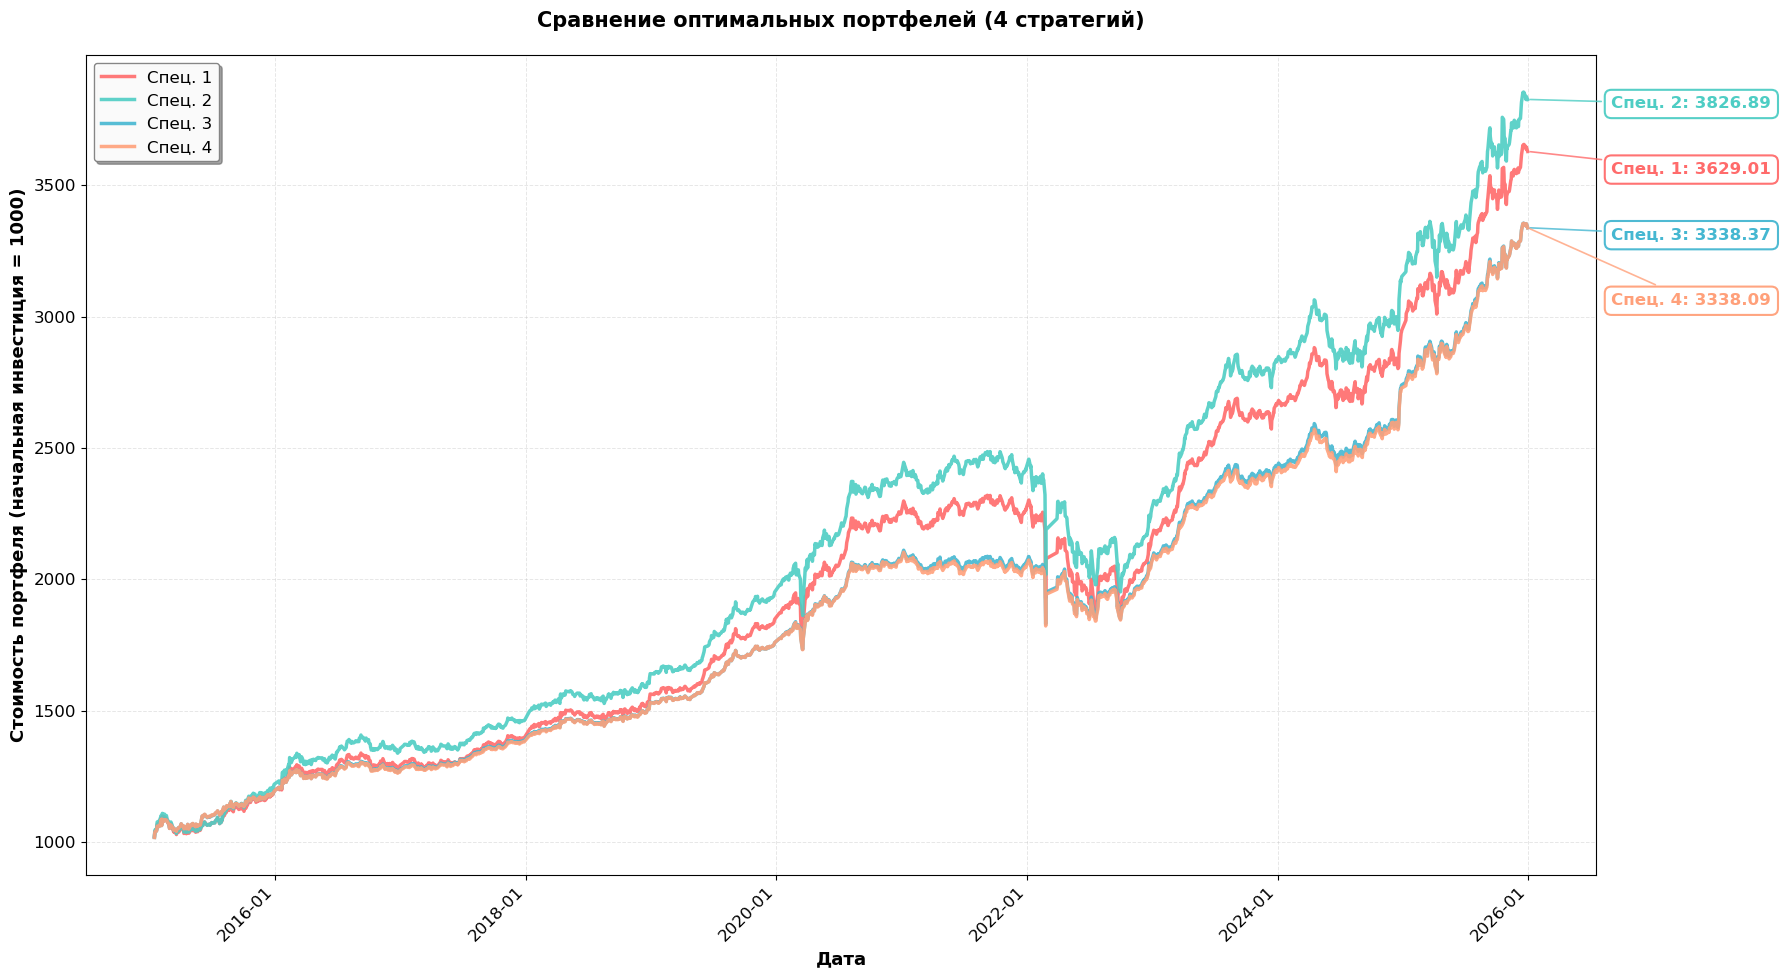


График 1 — Итоговая стоимость спецификаций:
  Спец. 1: 3629.01
  Спец. 2: 3826.89
  Спец. 3: 3338.37
  Спец. 4: 3338.09
Лидер по итоговой стоимости: Спец. 2 (3826.89)
Для сравнительных графиков используется: Спец. 3


In [94]:
spec_values = pd.DataFrame(index=portfolio_3_daily_returns.index)
for label, (ret_df, w) in [
    ("Спец. 1", (portfolio_1_daily_returns, median_w1)),
    ("Спец. 2", (portfolio_2_daily_returns, median_w2)),
    ("Спец. 3", (portfolio_3_daily_returns, median_w3)),
    ("Спец. 4", (portfolio_4_daily_returns, median_w4)),
]:
    port_ret = ret_df @ np.asarray(w, dtype=float)
    spec_values[label] = 1000 * (1 + port_ret).cumprod()
spec_values = spec_values.dropna()
 
filepath, _ = plot_portfolio_comparison(
    portfolio_values=spec_values,
    portfolio_number=None,
    initial_investment=1000,
    save_dir="figures",
    filename="comparison_1_specs",
    fmt="pdf",
)
 
print("\nГрафик 1 — Итоговая стоимость спецификаций:")
for col in spec_values.columns:
    print(f"  {col}: {spec_values[col].iloc[-1]:.2f}")
 
top_spec_by_value = spec_values.iloc[-1].idxmax()
print(f"Лидер по итоговой стоимости: {top_spec_by_value} "
      f"({spec_values[top_spec_by_value].iloc[-1]:.2f})")

best_spec_name = "Спец. 3"  # выбрана по downside-метрикам
print(f"Для сравнительных графиков используется: {best_spec_name}")

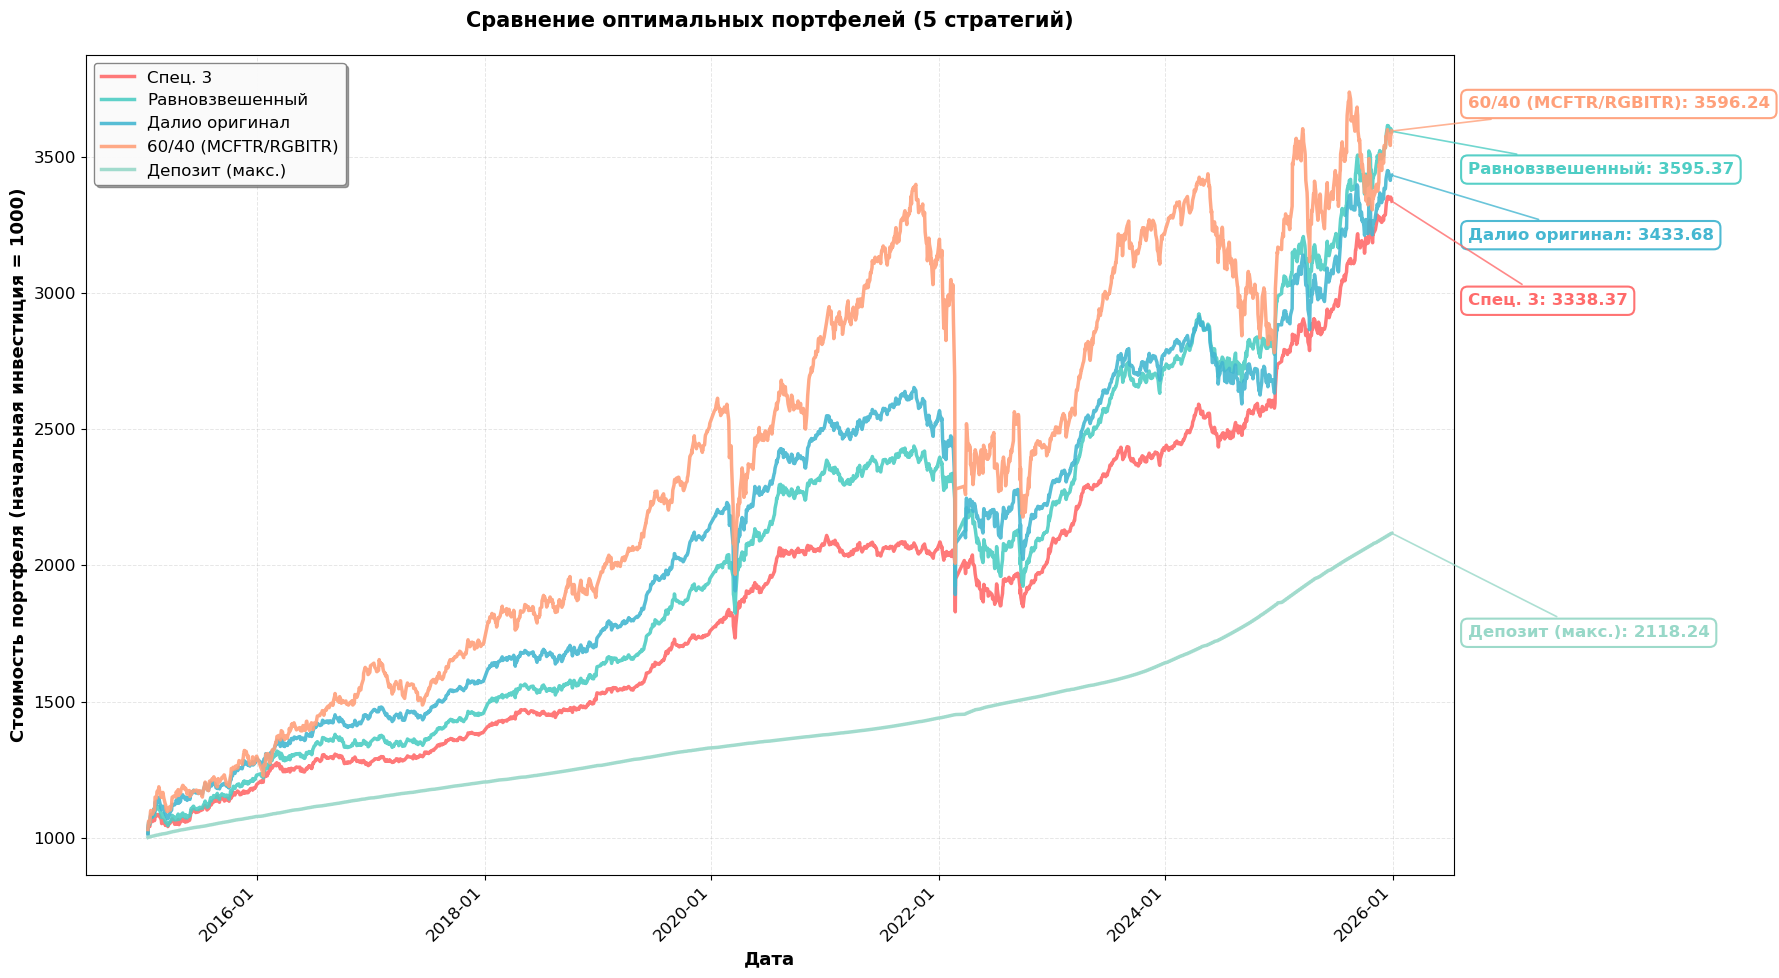


График 2 — Итоговая стоимость стратегий аллокации:
  Спец. 3: 3338.37
  Равновзвешенный: 3595.37
  Далио оригинал: 3433.68
  60/40 (MCFTR/RGBITR): 3596.24
  Депозит (макс.): 2118.24


In [95]:
spec_map = {
    "Спец. 1": (portfolio_1_daily_returns, median_w1),
    "Спец. 2": (portfolio_2_daily_returns, median_w2),
    "Спец. 3": (portfolio_3_daily_returns, median_w3),
    "Спец. 4": (portfolio_4_daily_returns, median_w4),
}
best_ret_df, best_weights = spec_map[best_spec_name]
best_port_ret = best_ret_df @ np.asarray(best_weights, dtype=float)
 
strategy_values = pd.DataFrame(index=portfolio_3_daily_returns.index)
 
strategy_values[best_spec_name] = 1000 * (1 + best_port_ret).cumprod()
for label, w in [
    ("Равновзвешенный", equal_w3),
    ("Далио оригинал", weights_dalio),
]:
    port_ret = portfolio_3_daily_returns @ np.asarray(w, dtype=float)
    strategy_values[label] = 1000 * (1 + port_ret).cumprod()
 
ret_60_40 = portfolio_60_40_returns @ weights_60_40
cum_60_40 = 1000 * (1 + ret_60_40).cumprod()
cum_60_40.index = pd.to_datetime(cum_60_40.index)
strategy_values["60/40 (MCFTR/RGBITR)"] = cum_60_40.reindex(
    strategy_values.index, method="ffill"
)
 
strategy_values["Депозит (макс.)"] = 1000 * (1 + deposit_daily_ret).cumprod()
 
strategy_values = strategy_values.dropna()
 
filepath, _ = plot_portfolio_comparison(
    portfolio_values=strategy_values,
    portfolio_number=None,
    initial_investment=1000,
    save_dir="figures",
    filename="comparison_3_strategies",
    fmt="pdf",
)
 
print("\nГрафик 2 — Итоговая стоимость стратегий аллокации:")
for col in strategy_values.columns:
    print(f"  {col}: {strategy_values[col].iloc[-1]:.2f}")

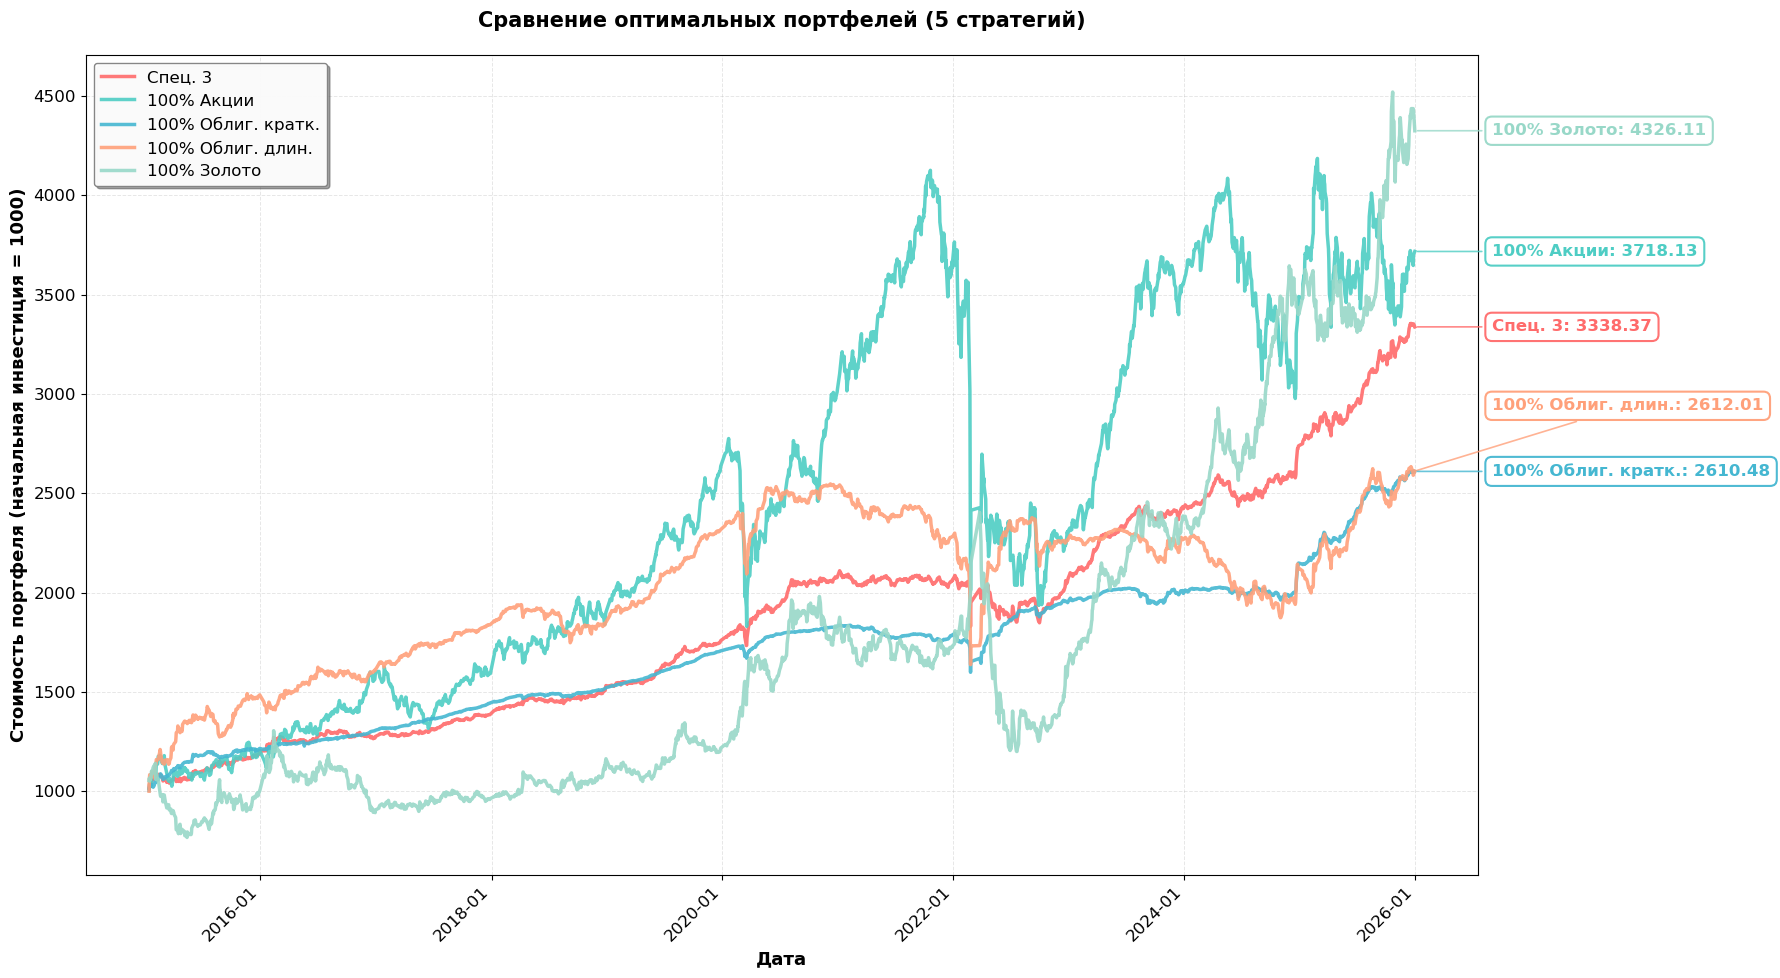


График 3 — Итоговая стоимость одноклассовых вложений:
  Спец. 3: 3338.37
  100% Акции: 3718.13
  100% Облиг. кратк.: 2610.48
  100% Облиг. длин.: 2612.01
  100% Золото: 4326.11


In [96]:
asset_values = pd.DataFrame(index=portfolio_3_daily_returns.index)
asset_values[best_spec_name] = 1000 * (1 + best_port_ret).cumprod()
for label, w in [
    ("100% Акции", only_equity),
    ("100% Облиг. кратк.", only_bond_short),
    ("100% Облиг. длин.", only_bond_long),
    ("100% Золото", only_gold),
]:
    port_ret = portfolio_3_daily_returns @ np.asarray(w, dtype=float)
    asset_values[label] = 1000 * (1 + port_ret).cumprod()
 
asset_values = asset_values.dropna()
 
filepath, _ = plot_portfolio_comparison(
    portfolio_values=asset_values,
    portfolio_number=None,
    initial_investment=1000,
    save_dir="figures",
    filename="comparison_4_vs_assets",
    fmt="pdf",
)
 
print("\nГрафик 3 — Итоговая стоимость одноклассовых вложений:")
for col in asset_values.columns:
    print(f"  {col}: {asset_values[col].iloc[-1]:.2f}")

## 3.8. Устойчивость ранжирования спецификаций

In [97]:
def align_specs_to_common_dates(
    specs: Mapping[str, tuple[pd.DataFrame, np.ndarray]],
) -> dict[str, tuple[pd.DataFrame, np.ndarray]]:
    """Оставляет только даты, общие для всех сравниваемых спецификаций.

    Args:
        specs: Словарь вида ``{name: (daily_returns, weights)}``.

    Returns:
        Спецификации на общем отсортированном DatetimeIndex.

    Raises:
        ValueError: Передано меньше двух спецификаций или общих дат нет.

    Side Effects:
        Печатает диапазон общих торговых дат.
    """
    if len(specs) < 2:
        raise ValueError("At least two specifications are required")

    common_dates: pd.DatetimeIndex | None = None
    for returns, _ in specs.values():
        if not isinstance(returns.index, pd.DatetimeIndex):
            raise TypeError("Specification returns must use a DatetimeIndex")
        common_dates = (
            returns.index
            if common_dates is None
            else common_dates.intersection(returns.index)
        )

    assert common_dates is not None
    common_dates = common_dates.sort_values()
    if common_dates.empty:
        raise ValueError("Specifications do not have common trading dates")

    aligned_specs = {
        name: (returns.loc[common_dates], np.asarray(weights, dtype=np.float64))
        for name, (returns, weights) in specs.items()
    }
    print(
        f"Общих торговых дней: {len(common_dates)} "
        f"({common_dates.min().date()} - {common_dates.max().date()})"
    )
    return aligned_specs


def criterion_total_return(
    daily_returns: pd.DataFrame,
    weights: np.ndarray,
) -> float:
    """Возвращает итоговую доходность портфеля для ранжирования спецификаций."""
    return float((1.0 + daily_returns.to_numpy() @ weights).prod() - 1.0)


def criterion_max_drawdown(
    daily_returns: pd.DataFrame,
    weights: np.ndarray,
) -> float:
    """Возвращает максимальную просадку портфеля для ранжирования спецификаций."""
    return calculate_portfolio_max_drawdown(daily_returns, weights)


def criterion_sortino(
    daily_returns: pd.DataFrame,
    weights: np.ndarray,
) -> float:
    """Возвращает Sortino с текущим MAR для ранжирования спецификаций."""
    return calculate_portfolio_sortino_ratio(
        daily_returns,
        weights,
        risk_free_rate=None,
        mar=mar,
        mar_annual=True,
    )


def criterion_cvar(
    daily_returns: pd.DataFrame,
    weights: np.ndarray,
) -> float:
    """Возвращает CVaR reward-risk ratio для ранжирования спецификаций."""
    return calculate_portfolio_cvar_ratio(
        daily_returns,
        weights,
        risk_free_rate,
        alpha=0.05,
    )


def criterion_calmar(
    daily_returns: pd.DataFrame,
    weights: np.ndarray,
) -> float:
    """Возвращает Calmar ratio для ранжирования спецификаций."""
    return calculate_portfolio_calmar_ratio(daily_returns, weights)


specs = align_specs_to_common_dates(
    {
        "Спец. 1 (медиана)": (portfolio_1_daily_returns, median_w1),
        "Спец. 2 (медиана)": (portfolio_2_daily_returns, median_w2),
        "Спец. 3 (медиана)": (portfolio_3_daily_returns, median_w3),
        "Спец. 4 (медиана)": (portfolio_4_daily_returns, median_w4),
    }
)


Общих торговых дней: 2062 (2015-01-14 - 2025-12-30)


In [98]:
print("=== Критерий: итоговая доходность (больше - лучше) ===")
rank_stability_total_return = bootstrap_rank_stability(
    specs,
    criterion_total_return,
    higher_is_better=True,
    n_boot=1000,
    seed=1,
)

print("\n=== Критерий: MDD (меньше - лучше) ===")
rank_stability_max_drawdown_jackknife = jackknife_by_year_rank_stability(
    specs,
    criterion_max_drawdown,
    higher_is_better=False,
)


=== Критерий: итоговая доходность (больше - лучше) ===
Block bootstrap: n_boot=1000, block=63, criterion=max
Baseline leader: Спец. 2 (медиана)
Спец. 1 (медиана) baseline=2 modal=2 P(same)=70.4% CI=[1.0523, 5.1634]
Спец. 2 (медиана) baseline=1 modal=1 P(same)=60.4% CI=[0.9120, 5.7874]
Спец. 3 (медиана) baseline=4 modal=4 P(same)=64.3% CI=[0.9777, 3.9392]
Спец. 4 (медиана) baseline=3 modal=3 P(same)=52.6% CI=[1.1670, 3.9813]
P(top-1 unchanged): 60.4%
Mean rank correlation: 0.648

=== Критерий: MDD (меньше - лучше) ===
Jackknife by year, criterion=min
excluded=2015: {'Спец. 1 (медиана)': 3, 'Спец. 2 (медиана)': 4, 'Спец. 3 (медиана)': 2, 'Спец. 4 (медиана)': 1}
excluded=2016: {'Спец. 1 (медиана)': 3, 'Спец. 2 (медиана)': 4, 'Спец. 3 (медиана)': 2, 'Спец. 4 (медиана)': 1}
excluded=2017: {'Спец. 1 (медиана)': 3, 'Спец. 2 (медиана)': 4, 'Спец. 3 (медиана)': 2, 'Спец. 4 (медиана)': 1}
excluded=2018: {'Спец. 1 (медиана)': 3, 'Спец. 2 (медиана)': 4, 'Спец. 3 (медиана)': 2, 'Спец. 4 (медиана)':

In [99]:
rank_stability_sortino = bootstrap_rank_stability(
    specs,
    criterion_sortino,
    higher_is_better=True,
    n_boot=1000,
    seed=1,
)
rank_stability_cvar = bootstrap_rank_stability(
    specs,
    criterion_cvar,
    higher_is_better=True,
    n_boot=1000,
    seed=1,
)
rank_stability_calmar_jackknife = jackknife_by_year_rank_stability(
    specs,
    criterion_calmar,
    higher_is_better=True,
)

Block bootstrap: n_boot=1000, block=63, criterion=max
Baseline leader: Спец. 4 (медиана)
Спец. 1 (медиана) baseline=2 modal=2 P(same)=51.3% CI=[-0.1269, 2.0911]
Спец. 2 (медиана) baseline=3 modal=4 P(same)=23.3% CI=[-0.1948, 2.1236]
Спец. 3 (медиана) baseline=4 modal=4 P(same)=43.3% CI=[-0.2354, 1.9964]
Спец. 4 (медиана) baseline=1 modal=1 P(same)=45.5% CI=[-0.0941, 1.9988]
P(top-1 unchanged): 45.5%
Mean rank correlation: 0.350
Block bootstrap: n_boot=1000, block=63, criterion=max
Baseline leader: Спец. 4 (медиана)
Спец. 1 (медиана) baseline=2 modal=2 P(same)=47.9% CI=[-0.0009, 0.0442]
Спец. 2 (медиана) baseline=3 modal=4 P(same)=23.5% CI=[-0.0027, 0.0442]
Спец. 3 (медиана) baseline=4 modal=4 P(same)=35.7% CI=[-0.0033, 0.0432]
Спец. 4 (медиана) baseline=1 modal=1 P(same)=53.5% CI=[0.0007, 0.0430]
P(top-1 unchanged): 53.5%
Mean rank correlation: 0.360
Jackknife by year, criterion=max
excluded=2015: {'Спец. 1 (медиана)': 3, 'Спец. 2 (медиана)': 4, 'Спец. 3 (медиана)': 2, 'Спец. 4 (медиан

# 4. Регрессионный анализ факторов доходности

### Назначение регрессии и пределы вывода

Регрессия объясняет историческую месячную доходность выбранного медианного портфеля. Она не доказывает причинность и не является вневыборочной прогнозной моделью. Перед отбором факторы проходят преобразования, проверку стационарности ADF+KPSS и контроль VIF; HAC-ковариация Ньюи-Уэста используется для статистического вывода при возможной гетероскедастичности и автокорреляции остатков.


In [100]:
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)
FIGURE_DPI = 600
FIGURE_FMT = "pdf"


def save_figure(
    fig: Figure,
    filename: str,
    *,
    dpi: int = FIGURE_DPI,
    fmt: str = FIGURE_FMT,
) -> Path:
    """Сохраняет фигуру в каталоге figures и возвращает путь к результату.

    Args:
        fig: Фигура Matplotlib.
        filename: Имя без расширения.
        dpi: Разрешение выходного файла.
        fmt: Формат файла.

    Returns:
        Путь к сохранённой фигуре.

    Side Effects:
        Создаёт файл на диске.

    Raises:
        ValueError: Если имя файла или формат пустые.
    """
    if not filename.strip() or not fmt.strip():
        raise ValueError("filename and fmt must not be empty")

    path = FIGURE_DIR / f"{filename}.{fmt}"
    fig.savefig(path, dpi=dpi, bbox_inches="tight", format=fmt, facecolor="white")
    print(f"Сохранено: {path}")
    return path


## 4.1. Подготовка данных

In [101]:
def transform_daily_to_monthly(
    frame: pd.DataFrame,
    price_col_name: str,
    *,
    date_column: str = "Дата",
    value_column: str = "Цена",
) -> pd.DataFrame:
    """Агрегирует ежедневный ценовой ряд по первой дате каждого месяца.

    Args:
        frame: Исходная таблица с датой и ценой.
        price_col_name: Имя столбца в результате.
        date_column: Имя исходного столбца даты.
        value_column: Имя исходного столбца цены.

    Returns:
        DataFrame с месячным индексом MS и единственным ценовым столбцом.

    Raises:
        TypeError: Если frame не является DataFrame.
        KeyError: Если не найдены дата или цена.
    """
    if not isinstance(frame, pd.DataFrame):
        raise TypeError("frame must be a pandas.DataFrame")
    missing_columns = {date_column, value_column}.difference(frame.columns)
    if missing_columns:
        raise KeyError(f"Missing columns: {sorted(missing_columns)}")

    data = frame[[date_column, value_column]].copy()
    data[date_column] = pd.to_datetime(data[date_column], dayfirst=True)
    return (
        data.sort_values(date_column)
        .set_index(date_column)[[value_column]]
        .resample("MS")
        .first()
        .rename(columns={value_column: price_col_name})
    )


In [102]:
def test_block_4_1_transform_daily_to_monthly_uses_first_month_observation() -> None:
    source = pd.DataFrame(
        {"Дата": ["02.01.2024", "15.01.2024", "03.02.2024"], "Цена": [101.0, 99.0, 105.0]}
    )

    result = transform_daily_to_monthly(source, "Asset")

    assert result.index.tolist() == [pd.Timestamp("2024-01-01"), pd.Timestamp("2024-02-01")]
    assert result["Asset"].tolist() == [101.0, 105.0]


def test_block_4_1_transform_daily_to_monthly_rejects_missing_columns() -> None:
    with pytest.raises(KeyError):
        transform_daily_to_monthly(pd.DataFrame({"Дата": ["01.01.2024"]}), "Asset")


In [103]:
run_notebook_tests("test_block_4_1")


..                                                                                           [100%]


0

In [104]:
portfolio_data = portfolio_3_data.copy()
month_start_prices = portfolio_data.resample('MS').first()

monthly_simple_returns = (
    month_start_prices / month_start_prices.shift(1) - 1
).dropna(how='all')

weights = extract_median_weights(bounds_summary_3)

print("Активы и веса портфеля (нормализованная медиана):")
for i, col in enumerate(month_start_prices.columns):
    print(f"  {col}: {weights[i]:.4f} ({weights[i]*100:.2f}%)")

portfolio_simple_return = (monthly_simple_returns * weights).sum(axis=1)
monthly_log_returns_portfolio = pd.DataFrame({
    'Portfolio': np.log(1 + portfolio_simple_return)
})

print(f"\nY: {monthly_log_returns_portfolio.shape}, "
      f"период {monthly_log_returns_portfolio.index[0]:%Y-%m} - "
      f"{monthly_log_returns_portfolio.index[-1]:%Y-%m}")


Активы и веса портфеля (нормализованная медиана):
  MCFTR: 0.1210 (12.10%)
  RUGBITR3Y: 0.5292 (52.92%)
  RUGBITR10Y: 0.1067 (10.67%)
  GLDRUB_TOM: 0.2431 (24.31%)

Y: (131, 1), период 2015-02 - 2025-12


In [105]:
df_MOEXBMI_m = (
    df_MOEXBMI.copy()
    .assign(TRADEDATE=lambda x: pd.to_datetime(x['TRADEDATE'], format='%d.%m.%Y'))
    .sort_values('TRADEDATE')
    .set_index('TRADEDATE')[['CLOSE']]
    .rename(columns={'CLOSE': 'MOEXBMI'})
    .resample('MS').first()
)

moex_monthly_log_returns = np.log(
    df_MOEXBMI_m / df_MOEXBMI_m.shift(1)
).dropna(how='all')

print(f"MOEXBMI: {moex_monthly_log_returns.shape}, "
      f"период {moex_monthly_log_returns.index[0]:%Y-%m} - "
      f"{moex_monthly_log_returns.index[-1]:%Y-%m}")


MOEXBMI: (131, 1), период 2015-02 - 2025-12


In [106]:
df_CNY_RUB_m = transform_daily_to_monthly(df_CNY_RUB, 'CNY_RUB')
df_EUR_RUB_m = transform_daily_to_monthly(df_EUR_RUB, 'EUR_RUB')
df_USD_RUB_m = transform_daily_to_monthly(df_USD_RUB, 'USD_RUB')
df_USD_CNY_m = transform_daily_to_monthly(df_USD_CNY, 'USD_CNY')
df_BRENT_m   = transform_daily_to_monthly(df_BRENT,   'BRENT')

df_RUONIA_m = (
    df_RUONIA.copy()
    .assign(DT=lambda x: pd.to_datetime(x['DT']))
    .sort_values('DT')
    .set_index('DT')[['ruo']]
    .rename(columns={'ruo': 'RUONIA'})
    .resample('MS').first()
)


In [107]:
df_gcurve = (
    df_ofz[['tradedate', 'period_1.0', 'period_10.0']]
    .copy()
    .set_index('tradedate')
    .sort_index()
    .rename(columns={'period_1.0': 'yield_1Y', 'period_10.0': 'yield_10Y'})
)
df_gcurve_m = df_gcurve.resample('MS').first()
df_gcurve_m['yield_spread'] = df_gcurve_m['yield_10Y'] - df_gcurve_m['yield_1Y']
df_yield_spread_m = df_gcurve_m[['yield_spread']]
print(f"Yield spread (10Y-1Y): {df_yield_spread_m.shape}, "
      f"период {df_yield_spread_m.index[0]:%Y-%m} - "
      f"{df_yield_spread_m.index[-1]:%Y-%m}")


Yield spread (10Y-1Y): (132, 1), период 2015-01 - 2025-12


In [108]:
df_daily_macro = df_CNY_RUB_m.copy()
for df in [df_EUR_RUB_m, df_USD_RUB_m, df_USD_CNY_m, df_BRENT_m, df_RUONIA_m,
           df_yield_spread_m]:
    df_daily_macro = df_daily_macro.join(df, how='outer')
df_daily_macro.index = pd.to_datetime(df_daily_macro.index)

df_monthly_raw = df_monthly_data.copy()
df_monthly_macro = df_monthly_raw.T.iloc[2:].copy()
df_monthly_macro.index = pd.to_datetime(df_monthly_macro.index)
df_monthly_macro = df_monthly_macro.apply(pd.to_numeric, errors='coerce')
df_monthly_macro.columns = [
    'budget_deficit_ratio',   # дефицит/профицит к расходам (кумулятивный)
    'gov_debt_internal',      # объем гос. внутреннего долга, млрд руб.
    'gov_debt_external',      # объем гос. внешнего долга, млн долл.
    'M2',                     # денежный агрегат М2, млрд руб.
    'key_rate',               # ключевая ставка ЦБ, % годовых
    'inflation',              # инфляция, % г/г
    'output_index',           # индекс выпуска товаров и услуг
    'avg_wage',               # среднемесячная зарплата, руб.
    'org_turnover',           # оборот организаций, млрд руб.
    'industry_prod_idx',      # индекс пром. производства
    'export_value',           # экспорт, млрд долл.
    'import_value',           # импорт, млрд долл.
    'moex_volume',            # объем торгов на MOEX, млрд руб.
]

df_macro_all = df_daily_macro.join(df_monthly_macro, how='outer')
df_macro_all.index = pd.to_datetime(df_macro_all.index)

print(f"Макропоказатели (сырые): {df_macro_all.shape}, "
      f"период {df_macro_all.index[0]:%Y-%m} - {df_macro_all.index[-1]:%Y-%m}")


Макропоказатели (сырые): (132, 20), период 2015-01 - 2025-12


In [109]:
LOG_DIFF_1M = [
    'CNY_RUB', 'EUR_RUB', 'USD_RUB', 'USD_CNY', 'BRENT',
    'gov_debt_internal', 'gov_debt_external',
    'industry_prod_idx', 'import_value', 'moex_volume',
    'output_index',
]

LOG_DIFF_12M = [
    'M2', 'avg_wage', 'org_turnover', 'export_value',
]

FIRST_DIFF_1M = [
    'RUONIA', 'key_rate', 'inflation', 'yield_spread',
]

FIRST_DIFF_12M = [
    'budget_deficit_ratio',
]

df_macro_transformed = pd.DataFrame(index=df_macro_all.index)

for col in df_macro_all.columns:
    series = df_macro_all[col]
    if series.isna().all():
        df_macro_transformed[col] = np.nan
        continue

    if col in LOG_DIFF_1M:
        positive = (series.dropna() > 0).all()
        if positive:
            df_macro_transformed[col] = np.log(series).diff(1)
        else:
            print(f"  {col}: log-diff невозможен (значения <= 0), "
                  f"применена first-diff")
            df_macro_transformed[col] = series.diff(1)

    elif col in LOG_DIFF_12M:
        positive = (series.dropna() > 0).all()
        if positive:
            df_macro_transformed[col] = np.log(series).diff(12)
        else:
            print(f"  {col}: 12M log-diff невозможен, применена 12M first-diff")
            df_macro_transformed[col] = series.diff(12)

    elif col in FIRST_DIFF_1M:
        df_macro_transformed[col] = series.diff(1)

    elif col in FIRST_DIFF_12M:
        df_macro_transformed[col] = series.diff(12)

    else:
        positive = (series.dropna() > 0).all()
        if positive:
            df_macro_transformed[col] = np.log(series).diff(1)
        else:
            df_macro_transformed[col] = series.diff(1)
            
df_macro_transformed = df_macro_transformed.dropna(how='any')

print(f"Преобразования:")
print(f"  log-diff 1M:    {len(LOG_DIFF_1M)} переменных")
print(f"  log-diff 12M:   {len(LOG_DIFF_12M)} переменных")
print(f"  first-diff 1M:  {len(FIRST_DIFF_1M)} переменных")
print(f"  first-diff 12M: {len(FIRST_DIFF_12M)} переменных")
print(f"Результат: {df_macro_transformed.shape}, "
      f"период {df_macro_transformed.index[0]:%Y-%m} - "
      f"{df_macro_transformed.index[-1]:%Y-%m}")


Преобразования:
  log-diff 1M:    11 переменных
  log-diff 12M:   4 переменных
  first-diff 1M:  4 переменных
  first-diff 12M: 1 переменных
Результат: (120, 20), период 2016-01 - 2025-12


In [110]:
EXTRA_DIFF_VARS = ['M2', 'avg_wage', 'export_value']

for col in EXTRA_DIFF_VARS:
    df_macro_transformed[col] = df_macro_transformed[col].diff()

df_macro_transformed = df_macro_transformed.dropna(how='any')

print(f"Дополнительная первая разность: {EXTRA_DIFF_VARS}")
print(f"Результат: {df_macro_transformed.shape}, "
      f"период {df_macro_transformed.index[0]:%Y-%m} - "
      f"{df_macro_transformed.index[-1]:%Y-%m}")


Дополнительная первая разность: ['M2', 'avg_wage', 'export_value']
Результат: (119, 20), период 2016-02 - 2025-12


In [111]:
last_complete = df_macro_transformed.dropna().index[-1]
df_macro_transformed = df_macro_transformed.loc[:last_complete]
monthly_log_returns_portfolio = monthly_log_returns_portfolio.loc[:last_complete]
moex_monthly_log_returns = moex_monthly_log_returns.loc[:last_complete]

common_index = (
    df_macro_transformed.index
    .intersection(monthly_log_returns_portfolio.index)
    .intersection(moex_monthly_log_returns.index)
)

if len(common_index) == 0:
    raise ValueError("Нет общих дат между датасетами")

df_macro_transformed = df_macro_transformed.loc[common_index]
monthly_log_returns_portfolio = monthly_log_returns_portfolio.loc[common_index]
moex_monthly_log_returns = moex_monthly_log_returns.loc[common_index]

n_nan = (
    monthly_log_returns_portfolio.isna().sum().sum()
    + moex_monthly_log_returns.isna().sum().sum()
    + df_macro_transformed.isna().sum().sum()
)

print(f"Синхронизированный период: "
      f"{common_index[0]:%Y-%m} - {common_index[-1]:%Y-%m}, "
      f"{len(common_index)} наблюдений")

if n_nan == 0:
    print("Пропущенных значений нет")
else:
    print(f"Обнаружено {n_nan} пропусков:")
    print(df_macro_transformed.isna().sum()[lambda x: x > 0])


Синхронизированный период: 2016-02 - 2025-12, 119 наблюдений
Пропущенных значений нет


## 4.2. Проверка стационарности и контроль преобразований

In [112]:
def assess_stationarity(
    series: pd.Series,
    *,
    alpha: float = 0.05,
) -> dict[str, float | bool | str]:
    """Проверяет стационарность временного ряда комбинированным ADF+KPSS.

    Args:
        series: Одномерный ряд без пропусков.
        alpha: Уровень значимости для обоих тестов.

    Returns:
        Словарь со статистиками тестов и статусом +, ± или -.

    Raises:
        TypeError: Если передан не pandas Series.
        ValueError: Если ряд содержит пропуски, слишком короткий или alpha некорректен.
    """
    if not isinstance(series, pd.Series):
        raise TypeError("series must be a pandas.Series")
    if not 0 < alpha < 1:
        raise ValueError("alpha must be between 0 and 1")
    if series.isna().any():
        raise ValueError("series must not contain missing values")
    if len(series) < 10:
        raise ValueError("series must contain at least 10 observations")

    try:
        adf_stat, adf_pvalue, *_ = adfuller(series, autolag="AIC")
        kpss_stat, kpss_pvalue, *_ = kpss(series, regression="c", nlags="auto")
    except (ValueError, np.linalg.LinAlgError) as error:
        return {
            "ADF Statistic": np.nan,
            "ADF p-value": np.nan,
            "KPSS Statistic": np.nan,
            "KPSS p-value": np.nan,
            "ADF stationary": False,
            "KPSS stationary": False,
            "Stationary": False,
            "Status": "-",
            "Error": str(error),
        }

    adf_stationary = adf_pvalue < alpha
    kpss_stationary = kpss_pvalue > alpha
    stationary = adf_stationary and kpss_stationary
    borderline = adf_pvalue < alpha * 2 and kpss_pvalue > alpha / 2
    return {
        "ADF Statistic": float(adf_stat),
        "ADF p-value": float(adf_pvalue),
        "KPSS Statistic": float(kpss_stat),
        "KPSS p-value": float(kpss_pvalue),
        "ADF stationary": bool(adf_stationary),
        "KPSS stationary": bool(kpss_stationary),
        "Stationary": bool(stationary),
        "Status": "+" if stationary else "±" if borderline else "-",
        "Error": "",
    }


def run_stationarity_tests(
    frame: pd.DataFrame,
    dataset_name: str,
    *,
    alpha: float = 0.05,
) -> tuple[pd.DataFrame, list[str], list[str]]:
    """Тестирует каждый столбец DataFrame и разделяет строгие и пограничные статусы.

    Args:
        frame: DataFrame временных рядов.
        dataset_name: Заголовок печатаемого отчёта.
        alpha: Уровень значимости.

    Returns:
        Таблица результатов, список рядов со статусом - и список рядов
        со статусом ±.

    Raises:
        ValueError: Если DataFrame пуст.
    """
    if frame.empty:
        raise ValueError("frame must not be empty")

    rows: list[dict[str, float | bool | str]] = []
    nonstationary: list[str] = []
    borderline: list[str] = []
    for column in frame.columns:
        result = assess_stationarity(frame[column], alpha=alpha)
        result["Variable"] = str(column)
        rows.append(result)
        if result["Status"] == "-":
            nonstationary.append(str(column))
        elif result["Status"] == "±":
            borderline.append(str(column))

    results = pd.DataFrame(rows)
    print(f"\n{dataset_name}")
    print(
        results[
            ["Variable", "ADF Statistic", "ADF p-value", "KPSS Statistic", "KPSS p-value", "Status"]
        ].to_string(index=False, float_format="{:.4f}".format)
    )
    return results, nonstationary, borderline


In [113]:
def test_block_4_2_assess_stationarity_returns_complete_contract() -> None:
    series = pd.Series(np.random.default_rng(42).normal(size=120))

    result = assess_stationarity(series)

    assert set(["ADF p-value", "KPSS p-value", "Stationary", "Status", "Error"]).issubset(result)
    assert result["Status"] in {"+", "±", "-"}


def test_block_4_2_assess_stationarity_rejects_missing_values() -> None:
    series = pd.Series(np.arange(12, dtype=float))
    series.iloc[0] = np.nan

    with pytest.raises(ValueError, match="missing values"):
        assess_stationarity(series)


def test_block_4_2_run_stationarity_tests_marks_failed_rows() -> None:
    frame = pd.DataFrame({"noise": np.random.default_rng(1).normal(size=120)})

    report, failed, borderline = run_stationarity_tests(frame, "synthetic")

    assert report["Variable"].tolist() == ["noise"]
    assert failed in ([], ["noise"])
    assert borderline in ([], ["noise"])

def test_block_4_2_run_stationarity_tests_separates_borderline_status(
    monkeypatch: pytest.MonkeyPatch,
) -> None:
    """Отделяет статус ± от строго нестационарных рядов."""
    statuses = {"strict": "+", "borderline": "±", "nonstationary": "-"}

    def fake_assessment(series: pd.Series, *, alpha: float) -> dict[str, float | bool | str]:
        """Возвращает заданный тестовый статус стационарности."""
        del alpha
        return {
            "ADF Statistic": 0.0,
            "ADF p-value": 0.0,
            "KPSS Statistic": 0.0,
            "KPSS p-value": 0.0,
            "ADF stationary": series.name == "strict",
            "KPSS stationary": series.name == "strict",
            "Stationary": series.name == "strict",
            "Status": statuses[str(series.name)],
            "Error": "",
        }

    monkeypatch.setitem(globals(), "assess_stationarity", fake_assessment)
    frame = pd.DataFrame(
        {
            "strict": [1.0] * 10,
            "borderline": [1.0] * 10,
            "nonstationary": [1.0] * 10,
        }
    )

    _, nonstationary, borderline = run_stationarity_tests(frame, "synthetic")

    assert nonstationary == ["nonstationary"]
    assert borderline == ["borderline"]



In [114]:
run_notebook_tests("test_block_4_2")

....                                                                                         [100%]


0

In [115]:
STRICT_STATIONARITY = True
print(
    "Режим стационарности: строгий. "
    "Статус ± останавливает регрессионный анализ."
)

Режим стационарности: строгий. Статус ± останавливает регрессионный анализ.


In [116]:
portfolio_df, portfolio_nonstat, portfolio_borderline = run_stationarity_tests(
    monthly_log_returns_portfolio,
    "ПОРТФЕЛЬ (Y)",
)



ПОРТФЕЛЬ (Y)
 Variable  ADF Statistic  ADF p-value  KPSS Statistic  KPSS p-value Status
Portfolio        -3.5642       0.0065          0.2074        0.1000      +


In [117]:
moex_df, moex_nonstat, moex_borderline = run_stationarity_tests(
    moex_monthly_log_returns,
    "MOEXBMI",
)



MOEXBMI
Variable  ADF Statistic  ADF p-value  KPSS Statistic  KPSS p-value Status
 MOEXBMI        -4.8760       0.0000          0.1432        0.1000      +


In [118]:
macro_df, macro_nonstat, macro_borderline = run_stationarity_tests(
    df_macro_transformed,
    "МАКРОПОКАЗАТЕЛИ (X)",
)



МАКРОПОКАЗАТЕЛИ (X)
            Variable  ADF Statistic  ADF p-value  KPSS Statistic  KPSS p-value Status
             CNY_RUB        -9.0889       0.0000          0.0563        0.1000      +
             EUR_RUB        -9.6890       0.0000          0.0498        0.1000      +
             USD_RUB        -6.8983       0.0000          0.0509        0.1000      +
             USD_CNY        -8.4258       0.0000          0.0476        0.1000      +
               BRENT        -7.4691       0.0000          0.0971        0.1000      +
              RUONIA        -9.5842       0.0000          0.1103        0.1000      +
        yield_spread        -5.4649       0.0000          0.0516        0.1000      +
budget_deficit_ratio        -3.0157       0.0335          0.1434        0.1000      +
   gov_debt_internal        -7.5076       0.0000          0.1708        0.1000      +
   gov_debt_external       -10.4056       0.0000          0.0531        0.1000      +
                  M2        -4.67

In [119]:
if macro_nonstat:
    print(f"Нестационарные переменные: {', '.join(macro_nonstat)}")
    print(macro_df[macro_df["Status"] == "-"].to_string(index=False))

if macro_borderline:
    print(f"Пограничные переменные: {', '.join(macro_borderline)}")
    print(macro_df[macro_df["Status"] == "±"].to_string(index=False))

if macro_nonstat or (STRICT_STATIONARITY and macro_borderline):
    mode_hint = (
        "Отключите STRICT_STATIONARITY только при осознанном "
        "методологическом допущении."
    )
    raise ValueError(
        "Обнаружены нестационарные или пограничные ряды после "
        "преобразований в 4.1. Необходимо вернуться в 4.1 и "
        f"скорректировать преобразования. {mode_hint}"
    )

macro_final_nonstat: list[str] = []
macro_final_borderline = macro_borderline
if macro_borderline:
    print("Пограничные ряды допущены в нестрогом режиме стационарности.")
else:
    print("Все макропоказатели стационарны после преобразований в 4.1")


Все макропоказатели стационарны после преобразований в 4.1


In [120]:
initial_transformations = {}
for col in df_macro_transformed.columns:
    if col in ['CNY_RUB', 'EUR_RUB', 'USD_RUB', 'USD_CNY', 'BRENT',
               'gov_debt_internal', 'gov_debt_external',
               'industry_prod_idx', 'import_value', 'moex_volume',
               'output_index']:
        initial_transformations[col] = 'log_diff_1M'
    elif col in ['org_turnover']:
        initial_transformations[col] = 'log_diff_12M'
    elif col in ['M2', 'avg_wage', 'export_value']:
        initial_transformations[col] = 'log_diff_12M + diff_1'
    elif col in ['RUONIA', 'key_rate', 'inflation', 'yield_spread']:
        initial_transformations[col] = 'first_diff_1M'
    elif col in ['budget_deficit_ratio']:
        initial_transformations[col] = 'first_diff_12M'
    else:
        initial_transformations[col] = 'unknown'

print(f"\n{'='*80}")
print("СВОДКА ПРЕОБРАЗОВАНИЙ")
print(f"{'='*80}")
print(f"{'Переменная':<25} {'Преобразование':<25}")
print("-" * 50)
for var in df_macro_transformed.columns:
    init = initial_transformations.get(var, '?')
    print(f"{var:<25} {init:<25}")



СВОДКА ПРЕОБРАЗОВАНИЙ
Переменная                Преобразование           
--------------------------------------------------
CNY_RUB                   log_diff_1M              
EUR_RUB                   log_diff_1M              
USD_RUB                   log_diff_1M              
USD_CNY                   log_diff_1M              
BRENT                     log_diff_1M              
RUONIA                    first_diff_1M            
yield_spread              first_diff_1M            
budget_deficit_ratio      first_diff_12M           
gov_debt_internal         log_diff_1M              
gov_debt_external         log_diff_1M              
M2                        log_diff_12M + diff_1    
key_rate                  first_diff_1M            
inflation                 first_diff_1M            
output_index              log_diff_1M              
avg_wage                  log_diff_12M + diff_1    
org_turnover              log_diff_12M             
industry_prod_idx         log_diff_1M     

In [121]:
common_index = (
    df_macro_transformed.index
    .intersection(monthly_log_returns_portfolio.index)
    .intersection(moex_monthly_log_returns.index)
)
if len(common_index) == 0:
    raise ValueError("Нет общих дат между датасетами")

df_macro_transformed = df_macro_transformed.loc[common_index]
monthly_log_returns_portfolio = monthly_log_returns_portfolio.loc[common_index]
moex_monthly_log_returns = moex_monthly_log_returns.loc[common_index]


In [122]:
n_nan = (
    monthly_log_returns_portfolio.isna().sum().sum()
    + moex_monthly_log_returns.isna().sum().sum()
    + df_macro_transformed.isna().sum().sum()
)

all_nonstationary = (
    portfolio_nonstat
    + moex_nonstat
    + macro_final_nonstat
)
all_borderline = (
    portfolio_borderline
    + moex_borderline
    + macro_final_borderline
)
all_stationary = not all_nonstationary and (
    not STRICT_STATIONARITY or not all_borderline
)

summary = pd.DataFrame({
    "Датасет": ["Портфель (Y)", "MOEXBMI", "Макропоказатели (X)"],
    "Переменных": [
        monthly_log_returns_portfolio.shape[1],
        moex_monthly_log_returns.shape[1],
        df_macro_transformed.shape[1],
    ],
    "Наблюдений": [
        len(monthly_log_returns_portfolio),
        len(moex_monthly_log_returns),
        len(df_macro_transformed),
    ],
    "Стационарных": [
        (portfolio_df["Status"] == "+").sum(),
        (moex_df["Status"] == "+").sum(),
        (macro_df["Status"] == "+").sum(),
    ],
    "Пограничных": [
        (portfolio_df["Status"] == "±").sum(),
        (moex_df["Status"] == "±").sum(),
        (macro_df["Status"] == "±").sum(),
    ],
})
summary["% стац."] = (
    summary["Стационарных"] / summary["Переменных"] * 100
).round(1)
print("\n" + summary.to_string(index=False))

print(
    f"\nОбщий период: {common_index[0]:%Y-%m} - "
    f"{common_index[-1]:%Y-%m} ({len(common_index)} месяцев)"
)

if STRICT_STATIONARITY and all_borderline:
    raise ValueError(
        "Строгий режим остановил анализ из-за пограничных рядов: "
        + ", ".join(all_borderline)
    )

if all_stationary and n_nan == 0:
    print("\nДАННЫЕ ГОТОВЫ К РЕГРЕССИОННОМУ АНАЛИЗУ")
    print("  Все ряды стационарны по комбинированному ADF+KPSS тесту")
    print("  Пропущенных значений: 0")
else:
    if all_nonstationary:
        print(f"\nНестационарные: {', '.join(all_nonstationary)}")
    if all_borderline:
        print(f"\nПограничные: {', '.join(all_borderline)}")
    if n_nan > 0:
        print(f"Пропущенные значения: {n_nan}")



            Датасет  Переменных  Наблюдений  Стационарных  Пограничных  % стац.
       Портфель (Y)           1         119             1            0    100.0
            MOEXBMI           1         119             1            0    100.0
Макропоказатели (X)          20         119            20            0    100.0

Общий период: 2016-02 - 2025-12 (119 месяцев)

ДАННЫЕ ГОТОВЫ К РЕГРЕССИОННОМУ АНАЛИЗУ
  Все ряды стационарны по комбинированному ADF+KPSS тесту
  Пропущенных значений: 0


## 4.3. VIF

In [123]:
def find_high_correlation_pairs(
    frame: pd.DataFrame,
    *,
    threshold: float = 0.7,
) -> tuple[pd.DataFrame, np.ndarray]:
    """Находит пары признаков с модулем корреляции выше заданного порога.

    Args:
        frame: Матрица признаков.
        threshold: Порог абсолютной корреляции в диапазоне от 0 до 1.

    Returns:
        Таблица пар и массив элементов верхнего треугольника матрицы.

    Raises:
        ValueError: Если порог находится вне диапазона от 0 до 1.
    """
    if not 0 <= threshold <= 1:
        raise ValueError("threshold must be between 0 and 1")

    correlation_matrix = frame.corr()
    pairs: list[dict[str, str | float]] = []
    for left_index, left_name in enumerate(correlation_matrix.columns):
        for right_name in correlation_matrix.columns[left_index + 1:]:
            value = float(correlation_matrix.loc[left_name, right_name])
            if abs(value) > threshold:
                pairs.append(
                    {
                        "Var1": str(left_name),
                        "Var2": str(right_name),
                        "Correlation": round(value, 3),
                    }
                )

    pair_table = pd.DataFrame(pairs, columns=["Var1", "Var2", "Correlation"])
    if not pair_table.empty:
        pair_table = (
            pair_table.assign(abs_corr=lambda values: values["Correlation"].abs())
            .sort_values("abs_corr", ascending=False)
            .drop(columns="abs_corr")
            .reset_index(drop=True)
        )
    values = correlation_matrix.to_numpy()
    return pair_table, values[np.triu_indices_from(values, k=1)]


def calculate_vif_table(features: pd.DataFrame) -> pd.DataFrame:
    """Рассчитывает VIF всех регрессоров без изменения исходной матрицы.

    Args:
        features: Матрица независимых переменных без константы.

    Returns:
        Таблица с именем переменной и VIF в порядке убывания.

    Raises:
        ValueError: Если матрица пуста или содержит пропуски.
    """
    if features.empty or features.shape[1] == 0:
        raise ValueError("features must contain at least one column")
    if features.isna().any().any():
        raise ValueError("features must not contain missing values")

    return (
        pd.DataFrame(
            {
                "Variable": features.columns,
                "VIF": [
                    variance_inflation_factor(features.to_numpy(), index)
                    for index in range(features.shape[1])
                ],
            }
        )
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )


def reduce_features_by_vif(
    features: pd.DataFrame,
    *,
    threshold: float = 5.0,
    max_iterations: int = 20,
    verbose: bool = True,
) -> tuple[pd.DataFrame, list[tuple[str, float]]]:
    """Итеративно исключает переменную с максимальным VIF выше порога.

    Args:
        features: Исходная матрица факторов.
        threshold: Максимально допустимое значение VIF.
        max_iterations: Предохранитель от бесконечного цикла.
        verbose: Печатать ход исключения.

    Returns:
        Сокращённая матрица факторов и список исключённых пар имя-VIF.

    Raises:
        ValueError: Если threshold или max_iterations некорректны.
    """
    if threshold <= 0:
        raise ValueError("threshold must be positive")
    if max_iterations < 1:
        raise ValueError("max_iterations must be positive")

    reduced = features.copy()
    removed: list[tuple[str, float]] = []
    for iteration in range(1, max_iterations + 1):
        if reduced.shape[1] == 0:
            break
        vif_table = calculate_vif_table(reduced)
        max_vif = float(vif_table.loc[0, "VIF"])
        if max_vif <= threshold:
            if verbose:
                print(f"Итерация {iteration}: все VIF <= {threshold}, завершение")
            break

        variable = str(vif_table.loc[0, "Variable"])
        removed.append((variable, max_vif))
        if verbose:
            print(f"Итерация {iteration:2d}: удаление {variable:<25} (VIF = {max_vif:.2f})")
        reduced = reduced.drop(columns=variable)
    return reduced, removed


In [124]:
def test_block_4_3_finds_high_correlation_pairs() -> None:
    frame = pd.DataFrame({"x": [1.0, 2.0, 3.0], "y": [2.0, 4.0, 6.0], "z": [2.0, 1.0, 0.0]})

    pairs, upper_triangle = find_high_correlation_pairs(frame, threshold=0.9)

    assert {pairs.loc[0, "Var1"], pairs.loc[0, "Var2"]} == {"x", "y"}
    assert len(upper_triangle) == 3


def test_block_4_3_calculates_and_reduces_vif() -> None:
    rng = np.random.default_rng(5)
    base = rng.normal(size=50)
    frame = pd.DataFrame(
        {
            "base": base,
            "copy": base + rng.normal(scale=1e-5, size=50),
            "independent": rng.normal(size=50),
        }
    )

    vif = calculate_vif_table(frame)
    reduced, removed = reduce_features_by_vif(frame, threshold=5.0, verbose=False)

    assert vif.loc[0, "VIF"] > 5.0
    assert len(removed) >= 1
    assert reduced.shape[1] < frame.shape[1]


In [125]:
run_notebook_tests("test_block_4_3")


..                                                                                           [100%]


0

In [126]:
correlation_matrix = df_macro_transformed.corr()
high_corr_df, upper_tri = find_high_correlation_pairs(
    df_macro_transformed,
    threshold=0.7,
)

if high_corr_df.empty:
    print("Пар с корреляцией |r| > 0.7 не обнаружено")
else:
    print(f"Высокие парные корреляции (|r| > 0.7): {len(high_corr_df)} пар(а)")
    print(high_corr_df.to_string(index=False))

print("\nОбщая статистика корреляций:")
print(f"  Переменных:       {len(correlation_matrix.columns)}")
print(f"  Пар:              {len(upper_tri)}")
print(f"  Средняя |r|:      {np.abs(upper_tri).mean():.3f}")
print(f"  Медианная |r|:    {np.median(np.abs(upper_tri)):.3f}")
print(f"  Максимальная |r|: {np.abs(upper_tri).max():.3f}")


Высокие парные корреляции (|r| > 0.7): 4 пар(а)
        Var1              Var2  Correlation
     CNY_RUB           USD_RUB        0.965
     CNY_RUB           EUR_RUB        0.950
     EUR_RUB           USD_RUB        0.940
output_index industry_prod_idx        0.924

Общая статистика корреляций:
  Переменных:       20
  Пар:              190
  Средняя |r|:      0.170
  Медианная |r|:    0.123
  Максимальная |r|: 0.965


Сохранено: figures\regression_correlation_matrix.pdf


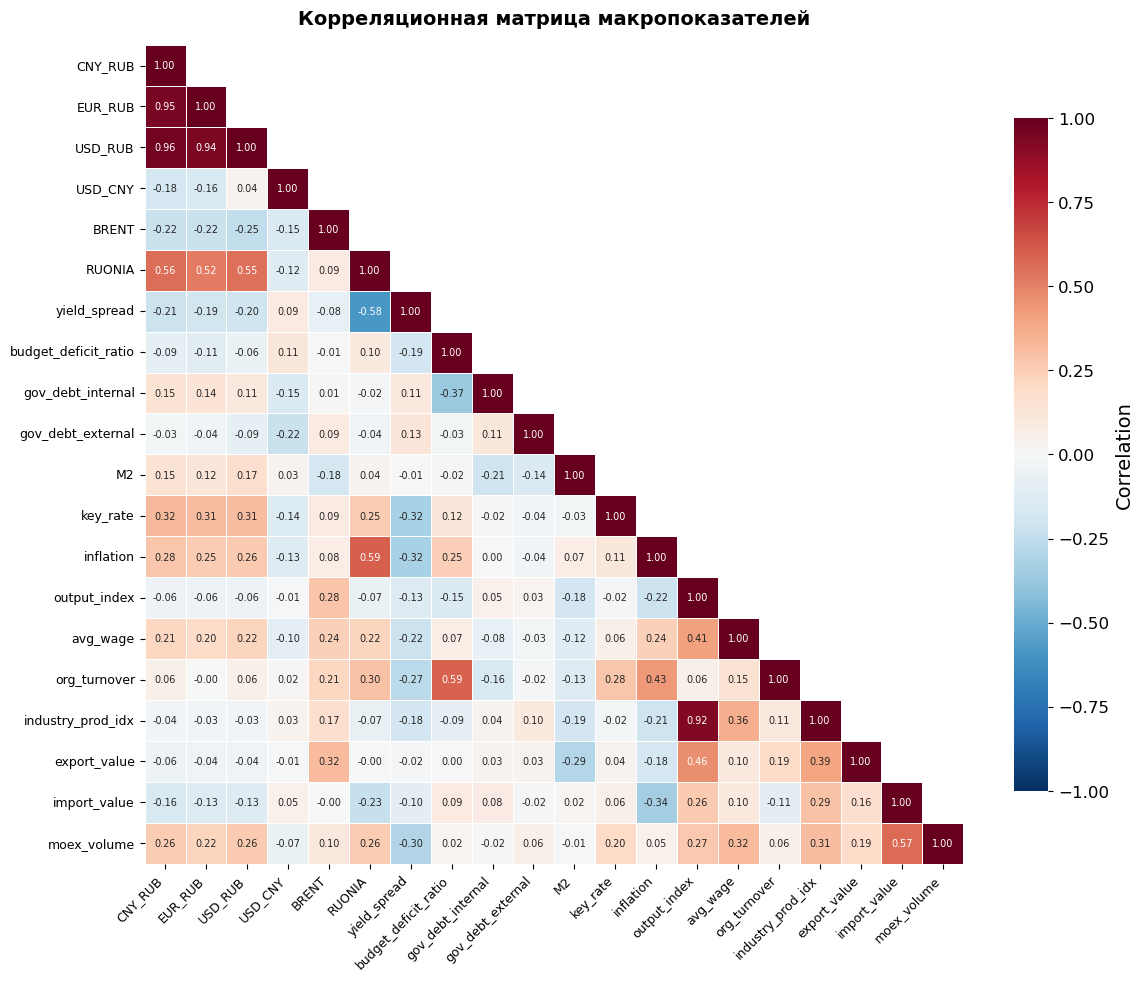

In [127]:
n_vars = len(correlation_matrix.columns)
fig_width = max(12, n_vars * 0.6)
fig_height = max(10, n_vars * 0.5)

fig_corr = plt.figure(figsize=(fig_width, fig_height))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
sns.heatmap(
    correlation_matrix, mask=mask, annot=True, fmt='.2f',
    annot_kws={'size': 7}, cmap='RdBu_r', center=0, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
    vmin=-1, vmax=1,
)
plt.title('Корреляционная матрица макропоказателей',
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
save_figure(fig_corr, "regression_correlation_matrix")
_render_figure(fig_corr, show=True)


In [128]:
X_macro = df_macro_transformed.copy()
vif_data = calculate_vif_table(X_macro)

print("Начальные VIF:")
print(vif_data.to_string(index=False))

high_vif = vif_data[vif_data["VIF"] > 10]
moderate_vif = vif_data[(vif_data["VIF"] >= 5) & (vif_data["VIF"] <= 10)]
low_vif = vif_data[vif_data["VIF"] < 5]

print("\nКатегоризация:")
print(f"  VIF > 10:  {len(high_vif):2d} переменных")
print(f"  VIF 5-10:  {len(moderate_vif):2d} переменных")
print(f"  VIF < 5:   {len(low_vif):2d} переменных")

if not high_vif.empty:
    print("\nПеременные с VIF > 10:")
    for _, row in high_vif.iterrows():
        print(f"  {row['Variable']:<25} VIF = {row['VIF']:.2f}")


Начальные VIF:
            Variable       VIF
             USD_RUB 59.369681
             CNY_RUB 46.131256
             EUR_RUB 13.865236
        output_index  9.960034
   industry_prod_idx  9.153442
             USD_CNY  3.802094
              RUONIA  3.521062
        import_value  2.776826
         moex_volume  2.489012
           inflation  2.229335
        yield_spread  2.153639
budget_deficit_ratio  1.932724
            avg_wage  1.808478
   gov_debt_internal  1.805579
        org_turnover  1.797984
        export_value  1.646708
               BRENT  1.581295
            key_rate  1.416572
                  M2  1.361684
   gov_debt_external  1.220978

Категоризация:
  VIF > 10:   3 переменных
  VIF 5-10:   2 переменных
  VIF < 5:   15 переменных

Переменные с VIF > 10:
  USD_RUB                   VIF = 59.37
  CNY_RUB                   VIF = 46.13
  EUR_RUB                   VIF = 13.87


In [129]:
VIF_THRESHOLD = 5.0
print(f"Порог VIF: {VIF_THRESHOLD}")
print(f"Начальное количество переменных: {len(X_macro.columns)}\n")

X_macro_reduced, removed_vars = reduce_features_by_vif(
    X_macro,
    threshold=VIF_THRESHOLD,
    max_iterations=20,
    verbose=True,
)


Порог VIF: 5.0
Начальное количество переменных: 20

Итерация  1: удаление USD_RUB                   (VIF = 59.37)
Итерация  2: удаление CNY_RUB                   (VIF = 12.76)
Итерация  3: удаление output_index              (VIF = 9.93)
Итерация 4: все VIF <= 5.0, завершение


In [130]:
if X_macro_reduced.shape[1] > 0:
    vif_final = calculate_vif_table(X_macro_reduced)
    print(f"Оставшиеся переменные: {len(X_macro_reduced.columns)}")
    print(vif_final.to_string(index=False))

    if removed_vars:
        print(f"\nУдалено: {len(removed_vars)}")
        for variable, vif_value in removed_vars:
            print(f"  {variable:<25} (VIF = {vif_value:.2f})")

    print("\nФинальная статистика VIF:")
    print(f"  Максимальный: {vif_final['VIF'].max():.2f}")
    print(f"  Средний:      {vif_final['VIF'].mean():.2f}")
    print(f"  Медианный:    {vif_final['VIF'].median():.2f}")
else:
    print("Не осталось переменных после фильтрации")


Оставшиеся переменные: 17
            Variable      VIF
              RUONIA 3.255770
        import_value 2.568755
         moex_volume 2.295180
           inflation 2.163247
             EUR_RUB 2.088413
        yield_spread 2.079743
budget_deficit_ratio 1.898128
        org_turnover 1.774087
   gov_debt_internal 1.756275
   industry_prod_idx 1.738269
            avg_wage 1.542484
        export_value 1.473449
               BRENT 1.464560
            key_rate 1.365230
                  M2 1.264054
             USD_CNY 1.189935
   gov_debt_external 1.159764

Удалено: 3
  USD_RUB                   (VIF = 59.37)
  CNY_RUB                   (VIF = 12.76)
  output_index              (VIF = 9.93)

Финальная статистика VIF:
  Максимальный: 3.26
  Средний:      1.83
  Медианный:    1.76


In [131]:
Y = monthly_log_returns_portfolio.copy()
X_control = moex_monthly_log_returns.copy()
X_macro = X_macro_reduced.copy()

common_idx = Y.index.intersection(X_control.index).intersection(X_macro.index)
Y = Y.loc[common_idx]
X_control = X_control.loc[common_idx]
X_macro = X_macro.loc[common_idx]
X_all = pd.concat([X_control, X_macro], axis=1, sort=False)

print(f"Размерности массивов:")
print(f"  Y (портфель):                {Y.shape}")
print(f"  X_control (MOEXBMI):         {X_control.shape}")
print(f"  X_macro (после VIF-фильтра): {X_macro.shape}")
print(f"  X_all (контроль + макро):    {X_all.shape}")

print(f"\nПеременные в X_macro ({len(X_macro.columns)}):")
for i, col in enumerate(X_macro.columns, 1):
    print(f"  {i:2d}. {col}")

total_missing = (
    Y.isna().sum().sum()
    + X_control.isna().sum().sum()
    + X_macro.isna().sum().sum()
)

if total_missing == 0:
    print(f"\nПропущенных значений нет")
else:
    print(f"\nОбнаружено {total_missing} пропущенных значений")
    valid_idx = Y.notna().all(axis=1) & X_all.notna().all(axis=1)
    Y = Y[valid_idx]
    X_control = X_control[valid_idx]
    X_macro = X_macro[valid_idx]
    X_all = X_all[valid_idx]
    print(f"После удаления пропусков: {Y.shape[0]} наблюдений")

assert Y.index.equals(X_all.index), "Индексы Y и X не совпадают"

print(f"\nИтого:")
print(f"  Период:     {Y.index[0]:%Y-%m} -- {Y.index[-1]:%Y-%m}")
print(f"  Наблюдений: {len(Y)}")
print(f"  Переменных: Y=1, X_control=1, "
      f"X_macro={len(X_macro.columns)}, X_all={len(X_all.columns)}")


Размерности массивов:
  Y (портфель):                (119, 1)
  X_control (MOEXBMI):         (119, 1)
  X_macro (после VIF-фильтра): (119, 17)
  X_all (контроль + макро):    (119, 18)

Переменные в X_macro (17):
   1. EUR_RUB
   2. USD_CNY
   3. BRENT
   4. RUONIA
   5. yield_spread
   6. budget_deficit_ratio
   7. gov_debt_internal
   8. gov_debt_external
   9. M2
  10. key_rate
  11. inflation
  12. avg_wage
  13. org_turnover
  14. industry_prod_idx
  15. export_value
  16. import_value
  17. moex_volume

Пропущенных значений нет

Итого:
  Период:     2016-02 -- 2025-12
  Наблюдений: 119
  Переменных: Y=1, X_control=1, X_macro=17, X_all=18


## 4.4. Оценивание и отбор регрессионных моделей


Основной критерий выбора — минимум BIC среди всех линейных подмножеств очищенной матрицы факторов размером от 1 до 5 и на одном временном интервале. BIC выбран ради парсимоничной объясняющей модели; он сильнее штрафует лишние параметры, чем AIC. Backward, forward, LASSO с хронологической кросс-валидацией и максимум скорректированного R² используются как проверки устойчивости, а не как конкурирующие финальные правила. При малой разнице BIC между двумя лучшими спецификациями вывод о единственной модели должен трактоваться осторожно.

In [132]:
HAC_PARAMS: dict[str, Any] = {'cov_type': 'HAC', 'cov_kwds': {'maxlags': 4}}


def _fit_ols(
    y: pd.Series | pd.DataFrame | np.ndarray,
    X: pd.DataFrame,
    use_hac: bool = True,
) -> RegressionResultsWrapper:
    """OLS с HAC стандартными ошибками (Newey-West)."""
    model = sm.OLS(y, sm.add_constant(X))
    return model.fit(**HAC_PARAMS) if use_hac else model.fit()


def backward_elimination(
    X: pd.DataFrame,
    y: pd.Series | pd.DataFrame,
    threshold: float = 0.05,
    verbose: bool = True,
) -> tuple[RegressionResultsWrapper, list[str]]:
    """Поэтапное удаление незначимых переменных (p-value > threshold)."""
    variables = list(X.columns)

    while variables:
        model = _fit_ols(y, X[variables])
        pvalues = model.pvalues.drop('const', errors='ignore')

        if pvalues.empty:
            break

        max_pvalue = pvalues.max()
        if max_pvalue > threshold:
            var_to_remove = pvalues.idxmax()
            variables.remove(var_to_remove)
            if verbose:
                print(f"Удаляем {var_to_remove} (p-value={max_pvalue:.4f})")
        else:
            break

    final_model = (
        _fit_ols(y, X[variables]) if variables
        else _fit_ols(y, pd.DataFrame(index=X.index))
    )
    return final_model, variables


def forward_selection(
    X: pd.DataFrame,
    y: pd.Series | pd.DataFrame,
    threshold: float = 0.05,
    verbose: bool = True,
) -> tuple[RegressionResultsWrapper, list[str]]:
    """Поэтапное добавление наиболее значимых переменных."""
    selected = []
    remaining = list(X.columns)

    while remaining:
        best_pvalue = 1.0
        best_feature = None

        for feature in remaining:
            test_features = selected + [feature]
            model = _fit_ols(y, X[test_features])
            pval = model.pvalues[feature]
            if pval < best_pvalue:
                best_pvalue = pval
                best_feature = feature

        if best_pvalue < threshold:
            selected.append(best_feature)
            remaining.remove(best_feature)
            if verbose:
                print(f"Добавляем {best_feature} (p-value={best_pvalue:.4f})")
        else:
            break

    final_model = (
        _fit_ols(y, X[selected]) if selected
        else _fit_ols(y, pd.DataFrame(index=X.index))
    )
    return final_model, selected


def lasso_selection(
    X: pd.DataFrame,
    y: pd.Series | pd.DataFrame,
    cv: int = 5,
    alpha_grid: Sequence[float] | np.ndarray | None = None,
    verbose: bool = True,
) -> tuple[RegressionResultsWrapper, list[str]]:
    """Отбирает факторы LASSO с leakage-safe временной валидацией.

    ``GridSearchCV`` переобучает весь pipeline на каждом expanding-window
    фолде, поэтому ``StandardScaler`` не использует будущие наблюдения.
    LASSO служит только robustness-проверкой отбора; итоговая OLS-модель
    оценивается на полной выборке с HAC-ковариацией.

    Args:
        X: Матрица регрессоров в хронологическом порядке.
        y: Зависимая переменная с тем же временным индексом.
        cv: Число expanding-window фолдов.
        alpha_grid: Положительная сетка коэффициентов L1. По умолчанию
            используется 100 значений от 1e-6 до 1e-1.
        verbose: Печатать выбранный alpha и число факторов.

    Returns:
        HAC-оценённая OLS-модель и признаки с ненулевыми LASSO-коэффициентами.

    Raises:
        ValueError: Фолды, индексы или сетка alpha некорректны.
    """
    if not 2 <= cv < len(X):
        raise ValueError("cv must be between 2 and one less than the sample size")
    if not X.index.is_monotonic_increasing:
        raise ValueError("X index must be sorted in chronological order")
    if isinstance(y, (pd.Series, pd.DataFrame)) and not X.index.equals(y.index):
        raise ValueError("X and y must have the same time index")

    alpha_values = np.asarray(
        np.logspace(-6, -1, 100) if alpha_grid is None else alpha_grid,
        dtype=float,
    )
    if (
        alpha_values.ndim != 1
        or alpha_values.size == 0
        or not np.isfinite(alpha_values).all()
        or (alpha_values <= 0).any()
    ):
        raise ValueError("alpha_grid must be a non-empty sequence of positive values")

    pipeline = Pipeline(
        [
            ("scale", StandardScaler()),
            ("lasso", Lasso(max_iter=10_000, random_state=42)),
        ]
    )
    search = GridSearchCV(
        estimator=pipeline,
        param_grid={"lasso__alpha": np.unique(alpha_values)},
        cv=TimeSeriesSplit(n_splits=cv),
        scoring="neg_mean_squared_error",
        refit=True,
    )
    target = y.to_numpy().ravel() if hasattr(y, "to_numpy") else np.asarray(y).ravel()
    search.fit(X, target)

    lasso = search.best_estimator_.named_steps["lasso"]
    selected = [
        column
        for column, coefficient in zip(X.columns, lasso.coef_, strict=True)
        if not np.isclose(coefficient, 0.0, atol=1e-12)
    ]
    if verbose:
        print(
            f"LASSO alpha: {search.best_params_['lasso__alpha']:.6f}, "
            f"отобрано {len(selected)} переменных"
        )
    if selected:
        return _fit_ols(y, X[selected]), selected

    if verbose:
        print("LASSO не выбрал ни одной переменной")
    return _fit_ols(y, pd.DataFrame(index=X.index)), selected

def score_linear_subsets(
    X: pd.DataFrame,
    y: pd.Series | pd.DataFrame,
    *,
    max_features: int = 6,
) -> pd.DataFrame:
    """Оценивает все линейные подмодели для прозрачного выбора по критерию.

    BIC и AIC рассчитываются по обычному OLS likelihood, поскольку это
    информационные критерии. После выбора спецификация отдельно
    переоценивается с HAC-ковариацией для статистического вывода.

    Args:
        X: Матрица факторов на едином временном интервале.
        y: Зависимая переменная, синхронизированная с ``X``.
        max_features: Максимальное число факторов без константы.

    Returns:
        Таблица всех подмоделей с AIC, BIC, скорректированным R² и списком
        факторов.

    Raises:
        ValueError: Если ``X`` пуст, индекс или длина ``y`` не совпадают с ``X`` или
            ``max_features`` некорректен.
    """
    if X.empty:
        raise ValueError("X must not be empty")
    if len(X) != len(y):
        raise ValueError("X and y must contain the same number of observations")
    if not X.index.equals(y.index):
        raise ValueError("X and y must have the same time index")
    if max_features < 1:
        raise ValueError("max_features must be positive")

    rows: list[dict[str, float | int | tuple[str, ...]]] = []
    variables = list(X.columns)
    max_size = min(max_features, len(variables))
    for size in range(1, max_size + 1):
        for combination in combinations(variables, size):
            model = sm.OLS(y, sm.add_constant(X[list(combination)])).fit()
            rows.append(
                {
                    "Факторы": combination,
                    "Число факторов": size,
                    "Adj R²": float(model.rsquared_adj),
                    "AIC": float(model.aic),
                    "BIC": float(model.bic),
                }
            )
    return pd.DataFrame(rows)


def select_subset_model(
    X: pd.DataFrame,
    y: pd.Series | pd.DataFrame,
    subset_scores: pd.DataFrame,
    *,
    criterion: str = "bic",
    verbose: bool = True,
) -> tuple[RegressionResultsWrapper, list[str]]:
    """Выбирает подмодель из таблицы оценённых комбинаций.

    Args:
        X: Исходная матрица факторов.
        y: Зависимая переменная.
        subset_scores: Результат ``score_linear_subsets``.
        criterion: ``"adj_r2"`` (максимум), ``"aic"`` или ``"bic"``
            (минимум).
        verbose: Печатать выбранную комбинацию.

    Returns:
        HAC-оценённая OLS-модель и список выбранных факторов.

    Raises:
        ValueError: Если критерий неизвестен или таблица пуста.
    """
    criterion_columns = {"adj_r2": "Adj R²", "aic": "AIC", "bic": "BIC"}
    if criterion not in criterion_columns:
        raise ValueError(f"Unknown criterion: {criterion}")
    if subset_scores.empty:
        raise ValueError("subset_scores must not be empty")

    score_column = criterion_columns[criterion]
    winner_index = (
        subset_scores[score_column].idxmax()
        if criterion == "adj_r2"
        else subset_scores[score_column].idxmin()
    )
    winner = subset_scores.loc[winner_index]
    selected = list(winner["Факторы"])
    model = _fit_ols(y, X[selected])

    if verbose:
        print(f"Лучшая комбинация ({len(selected)} перем.): {selected}")
        print(f"  {criterion}: {winner[score_column]:.4f}")
    return model, selected


def summarize_bic_evidence(subset_scores: pd.DataFrame) -> pd.DataFrame:
    """Возвращает лидирующие подмодели и разницу BIC относительно лучшей.

    Args:
        subset_scores: Результат ``score_linear_subsets``.

    Returns:
        Таблица пяти моделей с наименьшим BIC и столбцом ``ΔBIC``.

    Raises:
        ValueError: Если таблица пуста или не содержит BIC.
    """
    if subset_scores.empty or "BIC" not in subset_scores:
        raise ValueError("subset_scores must contain at least one BIC value")

    ranking = subset_scores.sort_values("BIC", kind="stable").head(5).copy()
    ranking["ΔBIC"] = ranking["BIC"] - float(ranking["BIC"].iloc[0])
    return ranking.reset_index(drop=True)


def find_best_subset(
    X: pd.DataFrame,
    y: pd.Series | pd.DataFrame,
    max_features: int = 6,
    criterion: str = "adj_r2",
    verbose: bool = True,
) -> tuple[RegressionResultsWrapper, list[str]]:
    """Совместимый интерфейс полного перебора подмножеств факторов.

    Args:
        X: Матрица факторов.
        y: Зависимая переменная.
        max_features: Максимальное число факторов без константы.
        criterion: ``"adj_r2"``, ``"aic"`` или ``"bic"``.
        verbose: Печатать выбранную комбинацию.

    Returns:
        HAC-оценённая выбранная модель и её факторы.
    """
    scores = score_linear_subsets(X, y, max_features=max_features)
    return select_subset_model(
        X,
        y,
        scores,
        criterion=criterion,
        verbose=verbose,
    )

def model_with_lags(
    X_all: pd.DataFrame,
    y: pd.Series | pd.DataFrame,
    n_lags: int = 2,
    verbose: bool = True,
) -> tuple[RegressionResultsWrapper, list[str]]:
    """Модель с лагами зависимой переменной."""
    y_1d = y.values.ravel() if hasattr(y, 'values') else np.asarray(y).ravel()
    dates = X_all.index

    Y_series = pd.Series(y_1d, index=dates)
    X_with_lag = X_all.copy()

    for lag in range(1, n_lags + 1):
        X_with_lag[f'portfolio_lag{lag}'] = Y_series.shift(lag)

    X_with_lag = X_with_lag.dropna()
    Y_lag = Y_series.loc[X_with_lag.index]

    model = _fit_ols(Y_lag, X_with_lag)

    if verbose:
        print(f"Модель с {n_lags} лагами: {len(Y_lag)} наблюдений "
              f"(потеряно {n_lags})")
        for lag in range(1, n_lags + 1):
            name = f'portfolio_lag{lag}'
            if name in model.params.index:
                p = model.pvalues[name]
                c = model.params[name]
                sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
                print(f"  Лаг {lag}: coef={c:.6f}, p={p:.4f} {sig}")

    return model, list(X_with_lag.columns)


In [133]:
def compare_models(models_dict: Mapping[str, RegressionResultsWrapper]) -> pd.DataFrame:
    """
    Сравнивает несколько моделей регрессии
    
    Parameters:
    -----------
    models_dict : dict
        Словарь с моделями {имя_модели: модель_OLS}
    
    Returns:
    --------
    pd.DataFrame
        Таблица сравнения моделей
    """
    if not models_dict:
        raise ValueError("Словарь models_dict не может быть пустым")
    
    comparison_data = []
    
    for name, model in models_dict.items():
        n_obs = model.nobs
        n_params = len(model.params)
        
        comparison_data.append({
            'Модель': name,
            'Наблюдения': int(n_obs),
            'Параметры': n_params,
            'R²': model.rsquared,
            'Adj R²': model.rsquared_adj,
            'AIC': model.aic,
            'BIC': model.bic,
            'RMSE': np.sqrt(model.mse_resid),
            'Log-Likelihood': model.llf,
            'F-statistic': model.fvalue,
            'F p-value': model.f_pvalue
        })
    
    df_comparison = pd.DataFrame(comparison_data)
    df_comparison = df_comparison.sort_values('Adj R²', ascending=False).reset_index(drop=True)
    
    return df_comparison

def f_test_nested(
    model_simple: RegressionResultsWrapper,
    model_complex: RegressionResultsWrapper,
    alpha: float = 0.05,
) -> dict[str, Any]:
    """
    Wald-тест для сравнения вложенных моделей.
 
    При использовании HAC-ошибок классический SSR-based F-тест
    некорректен, поскольку опирается на предпосылку i.i.d. ошибок.
    Wald-тест использует HAC-ковариационную матрицу и потому
    согласован с оценкой Ньюи-Уэста.
 
    Parameters
    ----------
    model_simple : RegressionResultsWrapper
        Простая (ограниченная) модель.
    model_complex : RegressionResultsWrapper
        Сложная (неограниченная) модель.
    alpha : float
        Уровень значимости.
 
    Returns
    -------
    dict
        Результаты теста.
    """
    k_simple = len(model_simple.params)
    k_complex = len(model_complex.params)
 
    if k_simple >= k_complex:
        raise ValueError(
            "Простая модель должна иметь меньше параметров, чем сложная"
        )
 
    if model_simple.nobs != model_complex.nobs:
        raise ValueError(
            f"Число наблюдений различается: "
            f"{model_simple.nobs} vs {model_complex.nobs}"
        )
 
    simple_vars = set(model_simple.params.index)
    complex_vars = set(model_complex.params.index)
 
    if not simple_vars.issubset(complex_vars):
        missing = simple_vars - complex_vars
        raise ValueError(
            f"Переменные простой модели отсутствуют в сложной: {missing}"
        )

    extra_vars = sorted(complex_vars - simple_vars)

    restriction = ", ".join(f"{var} = 0" for var in extra_vars)
    wald_result = model_complex.wald_test(restriction, use_f=True, scalar=True)
 
    f_stat = wald_result.fvalue
    p_value = wald_result.pvalue
    df_num = int(wald_result.df_num)
    df_denom = int(wald_result.df_denom)
 
    return {
        'F-статистика': f_stat,
        'p-value': p_value,
        'df_числитель': df_num,
        'df_знаменатель': df_denom,
        'Тестируемые переменные': extra_vars,
        'Уровень значимости': alpha,
        'Вывод': (
            'Сложная модель значимо лучше'
            if p_value < alpha
            else 'Модели статистически не различаются'
        ),
        'Reject H0': p_value < alpha,
    }

def get_coefficients_table(
    model: RegressionResultsWrapper,
    significance_levels: tuple[float, float, float] = (0.01, 0.05, 0.1),
) -> pd.DataFrame:
    """
    Создает таблицу коэффициентов с уровнями значимости
    
    Parameters:
    -----------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        Объект модели
    significance_levels : list
        Уровни значимости для маркировки [0.01, 0.05, 0.1] для ***, **, *
    
    Returns:
    --------
    pd.DataFrame
        Таблица коэффициентов
    """
    coef_df = pd.DataFrame({
        'Переменная': model.params.index,
        'Коэффициент': model.params.values,
        'Std Error': model.bse.values,
        't-stat': model.tvalues.values,
        'p-value': model.pvalues.values
    })

    conf_int = model.conf_int()
    coef_df['CI 95% Lower'] = conf_int[0].values
    coef_df['CI 95% Upper'] = conf_int[1].values

    def add_significance_stars(p_value: float) -> str:
        """Возвращает маркер значимости для одного p-value."""
        if p_value < significance_levels[0]:
            return '***'
        elif p_value < significance_levels[1]:
            return '**'
        elif p_value < significance_levels[2]:
            return '*'
        return ''
    
    coef_df['Значимость'] = coef_df['p-value'].apply(add_significance_stars)
    
    const_row = coef_df[coef_df['Переменная'] == 'const']
    coef_df_no_const = coef_df[coef_df['Переменная'] != 'const'].copy()
    
    if not coef_df_no_const.empty:
        coef_df_no_const = coef_df_no_const.reindex(
            coef_df_no_const['Коэффициент'].abs().sort_values(ascending=False).index
        )

    coef_df_sorted = pd.concat([const_row, coef_df_no_const]) if not const_row.empty else coef_df_no_const
    coef_df_sorted = coef_df_sorted.reset_index(drop=True)
    
    return coef_df_sorted

def plot_coefficients(
    model: RegressionResultsWrapper,
    exclude_vars: Sequence[str] = ('const',),
    figsize: tuple[float, float] = (12, 8),
    show: bool = False,
) -> tuple[Figure | None, Axes | None]:
    """
    Визуализация коэффициентов с доверительными интервалами
    
    Parameters:
    -----------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        Объект модели
    exclude_vars : list
        Переменные для исключения из графика
    figsize : tuple
        Размер фигуры
    show : bool
        Показать график немедленно
    
    Returns:
    --------
    tuple
        (fig, ax) объекты matplotlib
    """
    coef_df = get_coefficients_table(model)
    
    plot_df = coef_df[~coef_df['Переменная'].isin(exclude_vars)].copy()
    
    if plot_df.empty:
        print("Нет переменных для отображения после исключения")
        return None, None
    
    plot_df = plot_df.sort_values('Коэффициент')
    
    fig, ax = plt.subplots(figsize=figsize)
    
    y_pos = np.arange(len(plot_df))
    colors = ['red' if p < 0.05 else 'steelblue' if p < 0.1 else 'gray' 
              for p in plot_df['p-value']]

    ci_95 = 1.96 * plot_df['Std Error']

    bars = ax.barh(y_pos, plot_df['Коэффициент'], color=colors, alpha=0.6, edgecolor='black')

    ax.errorbar(plot_df['Коэффициент'], y_pos, xerr=ci_95, 
                fmt='none', ecolor='black', capsize=3, linewidth=1.5)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_df['Переменная'])
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Коэффициент', fontsize=12)
    ax.set_title('Коэффициенты регрессии (95% доверительный интервал)\n' + 
                 'Красный: p<0.05 | Синий: p<0.1 | Серый: p≥0.1', 
                 fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    
    if show:
        _render_figure(fig, show=True)
    
    return fig, ax 

def _interpret_dw(dw_stat: float) -> str:
    """Интерпретация статистики Durbin-Watson"""
    if 1.5 < dw_stat < 2.5:
        return "Нет значимой автокорреляции"
    elif dw_stat <= 1.5:
        return "Возможна положительная автокорреляция"
    else:
        return "Возможна отрицательная автокорреляция"

def residual_diagnostics(
    model: RegressionResultsWrapper,
    X: pd.DataFrame | np.ndarray | None = None,
    alpha: float = 0.05,
    verbose: bool = True,
) -> dict[str, dict[str, Any]]:
    """
    Проверка остатков модели
    
    Parameters:
    -----------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        Объект модели
    X : array-like, optional
        Матрица независимых переменных (для тестов гетероскедастичности)
    alpha : float
        Уровень значимости
    verbose : bool
        Выводить интерпретацию результатов
    
    Returns:
    --------
    dict
        Словарь с результатами диагностических тестов
    """
    residuals = model.resid
    fitted = model.fittedvalues
    
    results = {}

    jb_stat, jb_pval, skew, kurtosis = jarque_bera(residuals)
    results['normality_jb'] = {
        'test': 'Jarque-Bera',
        'statistic': jb_stat,
        'p_value': jb_pval,
        'skewness': skew,
        'kurtosis': kurtosis,
        'reject_H0': jb_pval < alpha,
        'interpretation': 'Остатки НЕнормальные (H0 отвергнута)' if jb_pval < alpha else 'Остатки нормальные (H0 не отвергнута)'
    }

    if len(residuals) < 5000:
        sw_stat, sw_pval = stats.shapiro(residuals)
        results['normality_sw'] = {
            'test': 'Shapiro-Wilk',
            'statistic': sw_stat,
            'p_value': sw_pval,
            'reject_H0': sw_pval < alpha,
            'interpretation': 'Остатки НЕнормальные (H0 отвергнута)' if sw_pval < alpha else 'Остатки нормальные (H0 не отвергнута)'
        }
 
    if X is not None:
        bp_stat, bp_pval, _, _ = het_breuschpagan(residuals, X)
        results['heteroskedasticity_bp'] = {
            'test': 'Breusch-Pagan',
            'statistic': bp_stat,
            'p_value': bp_pval,
            'reject_H0': bp_pval < alpha,
            'interpretation': 'Гетероскедастичность (H0 отвергнута)' if bp_pval < alpha else 'Гомоскедастичность (H0 не отвергнута)'
        }
        
        white_stat, white_pval, _, _ = het_white(residuals, X)
        results['heteroskedasticity_white'] = {
            'test': 'White',
            'statistic': white_stat,
            'p_value': white_pval,
            'reject_H0': white_pval < alpha,
            'interpretation': 'Гетероскедастичность (H0 отвергнута)' if white_pval < alpha else 'Гомоскедастичность (H0 не отвергнута)'
        }
    
    dw_stat = durbin_watson(residuals)
    results['autocorrelation_dw'] = {
        'test': 'Durbin-Watson',
        'statistic': dw_stat,
        'interpretation': _interpret_dw(dw_stat)
    }
    
    n_lags = min(10, len(residuals) // 5)
    if n_lags > 0:
        try:
            lb_result = acorr_ljungbox(residuals, lags=n_lags, return_df=True)
            lb_pval_min = lb_result['lb_pvalue'].min()
            lb_stat_last = lb_result['lb_stat'].iloc[-1]
                
            results['autocorrelation_lb'] = {
                'test': 'Ljung-Box',
                'statistic': float(lb_stat_last),
                'p_value': float(lb_pval_min),
                'lags_tested': n_lags,
                'reject_H0': lb_pval_min < alpha,
                'interpretation': 'Автокорреляция присутствует (H0 отвергнута)' if lb_pval_min < alpha else 'Автокорреляция отсутствует (H0 не отвергнута)'
            }
            
        except Exception as e:
            print(f"Ошибка при выполнении теста Ljung-Box: {e}")
            results['autocorrelation_lb'] = {
                'test': 'Ljung-Box',
                'statistic': None,
                'p_value': None,
                'lags_tested': n_lags,
                'reject_H0': None,
                'interpretation': f'Ошибка выполнения: {e}'
            }

    if verbose:
        print("\n" + "="*60)
        print("ДИАГНОСТИКА ОСТАТКОВ МОДЕЛИ")
        print("="*60)
        
        for key, result in results.items():
            print(f"\n{result['test']}:")
            if 'statistic' in result and result['statistic'] is not None:
                print(f"   Статистика: {result['statistic']:.4f}")
            if 'p_value' in result and result['p_value'] is not None:
                print(f"   p-value: {result['p_value']:.4f}")
            if 'interpretation' in result:
                print(f"   ➜ {result['interpretation']}")
    
    return results

def plot_residual_diagnostics(
    model: RegressionResultsWrapper,
    figsize: tuple[float, float] = (14, 10),
    show: bool = False,
) -> tuple[Figure, np.ndarray]:
    """
    Визуализация диагностики остатков
    
    Parameters:
    -----------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        Объект модели
    figsize : tuple
        Размер фигуры
    show : bool
        Показать график немедленно
    
    Returns:
    --------
    tuple
        (fig, axes) объекты matplotlib
    """
    residuals = model.resid
    fitted = model.fittedvalues
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    axes[0, 0].scatter(fitted, residuals, alpha=0.6, edgecolors='k', s=30)
    axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    
    lowess_result = lowess(residuals, fitted, frac=0.3)
    axes[0, 0].plot(lowess_result[:, 0], lowess_result[:, 1], 'b-', linewidth=2, label='LOWESS')
    
    axes[0, 0].set_xlabel('Прогнозные значения', fontsize=11)
    axes[0, 0].set_ylabel('Остатки', fontsize=11)
    axes[0, 0].set_title('Остатки vs Прогноз\n(Проверка гомоскедастичности)', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    stats.probplot(residuals, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title('Q-Q Plot\n(Проверка нормальности)', fontsize=12, fontweight='bold')
    axes[0, 1].grid(alpha=0.3)
    
    axes[1, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7, density=True, label='Остатки')

    mu, std = residuals.mean(), residuals.std()
    x = np.linspace(residuals.min(), residuals.max(), 100)
    if std > 0:
        axes[1, 0].plot(x, stats.norm.pdf(x, mu, std), 'r-', lw=2, label='Нормальное')
        kde = gaussian_kde(residuals)
        axes[1, 0].plot(x, kde(x), 'g--', lw=2, label='KDE')
    
    axes[1, 0].axvline(x=0, color='red', linestyle='--', alpha=0.5)
    axes[1, 0].set_xlabel('Остатки', fontsize=11)
    axes[1, 0].set_ylabel('Плотность', fontsize=11)
    axes[1, 0].set_title('Распределение остатков', fontsize=12, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    plot_acf(residuals, lags=min(20, len(residuals)//4), ax=axes[1, 1], alpha=0.05)
    axes[1, 1].set_title('Автокорреляция остатков (ACF)', fontsize=12, fontweight='bold')
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    
    if show:
        _render_figure(fig, show=True)
    
    return fig, axes

def diagnostic_summary(
    model: RegressionResultsWrapper,
    X: pd.DataFrame | np.ndarray | None = None,
    alpha: float = 0.05,
) -> pd.DataFrame:
    """
    Сводная таблица всех диагностических тестов
    
    Parameters:
    -----------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        Объект модели
    X : array-like, optional
        Матрица независимых переменных
    alpha : float
        Уровень значимости
    
    Returns:
    --------
    pd.DataFrame
        Сводная таблица результатов
    """
    diag = residual_diagnostics(model, X=X, alpha=alpha, verbose=False)
    
    summary_data = []
    
    for category, result in diag.items():
        if category != 'multicollinearity_vif':
            row = {
                'Тест': result['test'],
                'Статистика': result.get('statistic', '-'),
                'p-value': result.get('p_value', '-'),
                'Вывод': result['interpretation']
            }
            summary_data.append(row)
    if 'multicollinearity_vif' in diag:
        vif_result = diag['multicollinearity_vif']
        row = {
            'Тест': vif_result['test'],
            'Статистика': f"Max VIF = {vif_result['max_vif']:.2f}",
            'p-value': '-',
            'Вывод': vif_result['interpretation']
        }
        summary_data.append(row)
    
    return pd.DataFrame(summary_data)


In [134]:
@pytest.fixture
def block_4_4_sample() -> tuple[pd.Series, pd.DataFrame]:
    """Создаёт воспроизводимую выборку для регрессионных тестов."""
    rng = np.random.default_rng(11)
    index = pd.date_range("2018-01-01", periods=80, freq="MS")
    features = pd.DataFrame({"signal": rng.normal(size=80), "noise": rng.normal(size=80)}, index=index)
    target = pd.Series(0.8 * features["signal"] + rng.normal(scale=0.2, size=80), index=index)
    return target, features


def test_block_4_4_selection_finds_signal(
    block_4_4_sample: tuple[pd.Series, pd.DataFrame],
) -> None:
    target, features = block_4_4_sample

    _, backward = backward_elimination(features, target, verbose=False)
    _, forward = forward_selection(features, target, verbose=False)
    _, subset = find_best_subset(features, target, max_features=1, verbose=False)

    assert "signal" in backward
    assert "signal" in forward
    assert subset == ["signal"]


def test_block_4_4_diagnostics_and_coefficients_table_work(
    block_4_4_sample: tuple[pd.Series, pd.DataFrame],
) -> None:
    """Проверяет диагностический контракт без зависимости от графического backend."""
    target, features = block_4_4_sample
    model = _fit_ols(target, features)
    design_matrix = sm.add_constant(features)

    diagnostics = residual_diagnostics(model, X=design_matrix, verbose=False)
    summary = diagnostic_summary(model, X=design_matrix)
    coefficients = get_coefficients_table(model)

    assert "normality_jb" in diagnostics
    assert {"Тест", "Статистика", "p-value", "Вывод"} == set(summary.columns)
    assert coefficients.iloc[0]["Переменная"] == "const"

def test_block_4_4_lasso_scales_inside_time_series_cv(
    block_4_4_sample: tuple[pd.Series, pd.DataFrame],
    monkeypatch: pytest.MonkeyPatch,
) -> None:
    """Фиксирует pipeline-масштабирование внутри хронологических фолдов."""
    target, features = block_4_4_sample
    captured: dict[str, Any] = {}

    class FakeLassoResult:
        """Имитирует обученный Lasso внутри лучшего pipeline."""

        coef_ = np.array([1.0, 0.0])

    class FakeBestPipeline:
        """Хранит шаг Lasso в формате sklearn Pipeline."""

        named_steps = {"lasso": FakeLassoResult()}

    class FakeGridSearchCV:
        """Перехватывает estimator и временной splitter без обучения."""

        def __init__(
            self,
            *,
            estimator: Pipeline,
            param_grid: Mapping[str, np.ndarray],
            cv: TimeSeriesSplit,
            **kwargs: Any,
        ) -> None:
            del kwargs
            captured["estimator"] = estimator
            captured["param_grid"] = param_grid
            captured["cv"] = cv
            self.best_estimator_ = FakeBestPipeline()
            self.best_params_ = {"lasso__alpha": 0.01}

        def fit(self, X: pd.DataFrame, y: np.ndarray) -> "FakeGridSearchCV":
            del X, y
            return self

    monkeypatch.setitem(globals(), "GridSearchCV", FakeGridSearchCV)
    _, selected = lasso_selection(features, target, cv=3, verbose=False)

    estimator = captured["estimator"]
    assert isinstance(estimator, Pipeline)
    assert isinstance(estimator.named_steps["scale"], StandardScaler)
    assert isinstance(captured["cv"], TimeSeriesSplit)
    assert captured["cv"].n_splits == 3
    assert selected == ["signal"]

def test_block_4_4_subset_scores_support_transparent_bic_choice(
    block_4_4_sample: tuple[pd.Series, pd.DataFrame],
) -> None:
    """Проверяет таблицу кандидатов, BIC-ранжирование и HAC-переоценку."""
    target, features = block_4_4_sample

    scores = score_linear_subsets(features, target, max_features=2)
    ranking = summarize_bic_evidence(scores)
    _, selected = select_subset_model(
        features,
        target,
        scores,
        criterion="bic",
        verbose=False,
    )

    assert len(scores) == 3
    assert ranking.loc[0, "ΔBIC"] == pytest.approx(0.0)
    assert "signal" in selected


def test_block_4_4_subset_scores_reject_misaligned_time_index(
    block_4_4_sample: tuple[pd.Series, pd.DataFrame],
) -> None:
    """Не допускает сравнения BIC на несинхронизированных рядах."""
    target, features = block_4_4_sample
    shifted_target = target.copy()
    shifted_target.index = shifted_target.index + pd.DateOffset(months=1)

    with pytest.raises(ValueError, match="same time index"):
        score_linear_subsets(features, shifted_target, max_features=1)


In [135]:
run_notebook_tests("test_block_4_4")


.....                                                                                        [100%]


0

In [136]:
model_1 = _fit_ols(Y, X_control)
print(model_1.summary())


                            OLS Regression Results                            
Dep. Variable:              Portfolio   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                  0.145
Method:                 Least Squares   F-statistic:                     16.08
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           0.000108
Time:                        12:55:54   Log-Likelihood:                 325.84
No. Observations:                 119   AIC:                            -647.7
Df Residuals:                     117   BIC:                            -642.1
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0082      0.002      5.138      0.0

In [137]:
model_2 = _fit_ols(Y, X_all)
print(model_2.summary())


                            OLS Regression Results                            
Dep. Variable:              Portfolio   R-squared:                       0.572
Model:                            OLS   Adj. R-squared:                  0.495
Method:                 Least Squares   F-statistic:                     24.81
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           5.17e-29
Time:                        12:55:54   Log-Likelihood:                 366.45
No. Observations:                 119   AIC:                            -694.9
Df Residuals:                     100   BIC:                            -642.1
Df Model:                          18                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0114 

In [138]:
model_3 = _fit_ols(Y, X_macro)
print(model_3.summary())


                            OLS Regression Results                            
Dep. Variable:              Portfolio   R-squared:                       0.400
Model:                            OLS   Adj. R-squared:                  0.299
Method:                 Least Squares   F-statistic:                     10.12
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           4.13e-15
Time:                        12:55:54   Log-Likelihood:                 346.34
No. Observations:                 119   AIC:                            -656.7
Df Residuals:                     101   BIC:                            -606.7
Df Model:                          17                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0105 

In [139]:
models_base = {
    'Модель 1 (только MOEXBMI)': model_1,
    'Модель 2 (MOEXBMI + макро)': model_2,
    'Модель 3 (только макро)': model_3,
}

print(compare_models(models_base).to_string(index=False))


                    Модель  Наблюдения  Параметры       R²   Adj R²         AIC         BIC     RMSE  Log-Likelihood  F-statistic    F p-value
Модель 2 (MOEXBMI + макро)         119         19 0.571796 0.494720 -694.901921 -642.098575 0.012138      366.450961    24.810202 5.166098e-29
   Модель 3 (только макро)         119         18 0.399609 0.298553 -656.682056 -606.657833 0.014302      346.341028    10.116109 4.127035e-15
 Модель 1 (только MOEXBMI)         119          2 0.152686 0.145444 -647.687639 -642.129392 0.015786      325.843819    16.076366 1.075048e-04


In [140]:
all_models = {'Базовая (MOEXBMI + макро)': model_2}

model_backward, vars_backward = backward_elimination(X_all, Y)
all_models['Backward Elimination'] = model_backward
print(f"Отобраны: {vars_backward}")


Удаляем M2 (p-value=0.9753)
Удаляем avg_wage (p-value=0.8869)
Удаляем moex_volume (p-value=0.8653)
Удаляем RUONIA (p-value=0.8381)
Удаляем inflation (p-value=0.7428)
Удаляем budget_deficit_ratio (p-value=0.6345)
Удаляем gov_debt_internal (p-value=0.6954)
Удаляем gov_debt_external (p-value=0.6090)
Удаляем BRENT (p-value=0.4979)
Удаляем industry_prod_idx (p-value=0.4097)
Удаляем USD_CNY (p-value=0.1662)
Удаляем export_value (p-value=0.1748)
Удаляем yield_spread (p-value=0.0813)
Отобраны: ['MOEXBMI', 'EUR_RUB', 'key_rate', 'org_turnover', 'import_value']


In [141]:
model_forward, vars_forward = forward_selection(X_all, Y)
all_models['Forward Selection'] = model_forward
print(f"Отобраны: {vars_forward}")


Добавляем org_turnover (p-value=0.0000)
Добавляем EUR_RUB (p-value=0.0004)
Добавляем MOEXBMI (p-value=0.0000)
Добавляем import_value (p-value=0.0001)
Добавляем key_rate (p-value=0.0482)
Отобраны: ['org_turnover', 'EUR_RUB', 'MOEXBMI', 'import_value', 'key_rate']


In [142]:
model_lasso, vars_lasso = lasso_selection(X_all, Y, cv=5)
all_models['LASSO Selection'] = model_lasso
print(f"Отобраны: {vars_lasso}")


LASSO alpha: 0.001918, отобрано 6 переменных
Отобраны: ['MOEXBMI', 'EUR_RUB', 'yield_spread', 'budget_deficit_ratio', 'org_turnover', 'import_value']


In [143]:
MAX_REGRESSION_FEATURES = 5
subset_scores = score_linear_subsets(
    X_all,
    Y,
    max_features=MAX_REGRESSION_FEATURES,
)
print(
    f"Оценено линейных подмоделей: {len(subset_scores)}; "
    f"максимум факторов: {MAX_REGRESSION_FEATURES}."
)


Оценено линейных подмоделей: 12615; максимум факторов: 5.


In [144]:
model_brute_r2, vars_brute_r2 = select_subset_model(
    X_all,
    Y,
    subset_scores,
    criterion="adj_r2",
)
all_models["Brute Force (max Adj R2)"] = model_brute_r2


Лучшая комбинация (5 перем.): ['MOEXBMI', 'EUR_RUB', 'yield_spread', 'org_turnover', 'import_value']
  adj_r2: 0.5324


In [145]:
model_brute_aic, vars_brute_aic = select_subset_model(
    X_all,
    Y,
    subset_scores,
    criterion="aic",
)
all_models["Brute Force (min AIC)"] = model_brute_aic


Лучшая комбинация (5 перем.): ['MOEXBMI', 'EUR_RUB', 'yield_spread', 'org_turnover', 'import_value']
  aic: -715.5749


In [146]:
model_brute_bic, vars_brute_bic = select_subset_model(
    X_all,
    Y,
    subset_scores,
    criterion="bic",
)
all_models["Brute Force (min BIC)"] = model_brute_bic


Лучшая комбинация (4 перем.): ['MOEXBMI', 'EUR_RUB', 'org_turnover', 'import_value']
  bic: -701.0697


In [147]:
base_for_poly = vars_backward

coef_table = pd.DataFrame({
    'Variable': model_backward.params.index,
    't_abs': model_backward.tvalues.abs(),
    'p_value': model_backward.pvalues,
})
top_vars = (
    coef_table[
        (~coef_table['Variable'].isin(['const']))
        & (coef_table['p_value'] < 0.05)
    ]
    .nlargest(5, 't_abs')['Variable']
    .tolist()
)

print(f"Тестирование квадратов для {len(top_vars)} значимых переменных:")

significant_squares = []
for var in top_vars:
    sq_name = f'{var}_sq'
    X_test = X_all[base_for_poly].copy()
    X_test[sq_name] = X_all[var] ** 2
    m = _fit_ols(Y, X_test)
    pval = m.pvalues[sq_name]
    coef = m.params[sq_name]
    adj_r2 = m.rsquared_adj
    delta = adj_r2 - model_backward.rsquared_adj
    status = f"p={pval:.4f}, ΔAdj R²={delta:+.4f}" + (" (значим)" if pval < 0.1 else "")
    print(f"  {sq_name:<30} coef={coef:.6f}, {status}")
    if pval < 0.1:
        significant_squares.append(sq_name)

if significant_squares:
    X_poly_final = X_all[base_for_poly].copy()
    for sq_name in significant_squares:
        original = sq_name.replace('_sq', '')
        X_poly_final[sq_name] = X_all[original] ** 2
    model_poly = _fit_ols(Y, X_poly_final)
    if model_poly.rsquared_adj > model_backward.rsquared_adj:
        all_models['Polynomial Features'] = model_poly
        print(f"\nПолиномиальная модель улучшает Adj R2: "
              f"{model_backward.rsquared_adj:.4f} -> "
              f"{model_poly.rsquared_adj:.4f}")
    else:
        all_models['Polynomial Features'] = model_backward
        model_poly = model_backward
        print("Полиномиальная модель не улучшает Adj R2")
else:
    model_poly = model_backward
    all_models['Polynomial Features'] = model_backward
    print("\nНет значимых квадратичных признаков")


Тестирование квадратов для 5 значимых переменных:
  MOEXBMI_sq                     coef=-0.106720, p=0.3055, ΔAdj R²=-0.0000
  EUR_RUB_sq                     coef=0.129947, p=0.3176, ΔAdj R²=-0.0005
  org_turnover_sq                coef=0.003674, p=0.9463, ΔAdj R²=-0.0042
  import_value_sq                coef=0.003637, p=0.9314, ΔAdj R²=-0.0042
  key_rate_sq                    coef=0.000095, p=0.2061, ΔAdj R²=-0.0019

Нет значимых квадратичных признаков


In [148]:
model_lags_2, _ = model_with_lags(X_all[vars_backward], Y, n_lags=2)
model_lags_1, _ = model_with_lags(X_all[vars_backward], Y, n_lags=1)
print("Про лаги стоит упомянуть в тексте, но результаты не надо приводить")


Модель с 2 лагами: 117 наблюдений (потеряно 2)
  Лаг 1: coef=-0.033764, p=0.6107 
  Лаг 2: coef=-0.030078, p=0.6200 
Модель с 1 лагами: 118 наблюдений (потеряно 1)
  Лаг 1: coef=-0.033234, p=0.6086 
Про лаги стоит упомянуть в тексте, но результаты не надо приводить


In [149]:
comparison_df = compare_models(all_models)

print("\n" + "=" * 80)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("=" * 80)
print(comparison_df.to_string(index=False))

best_r2  = comparison_df.iloc[0]
best_aic = comparison_df.loc[comparison_df['AIC'].idxmin()]
best_bic = comparison_df.loc[comparison_df['BIC'].idxmin()]

print(f"\nЛучшая по Adj R2: {best_r2['Модель']} "
      f"(Adj R2={best_r2['Adj R²']:.4f}, params={best_r2['Параметры']})")
print(f"Лучшая по AIC:    {best_aic['Модель']} "
      f"(AIC={best_aic['AIC']:.2f}, params={best_aic['Параметры']})")
print(f"Лучшая по BIC:    {best_bic['Модель']} "
      f"(BIC={best_bic['BIC']:.2f}, params={best_bic['Параметры']})")


bic_evidence = summarize_bic_evidence(subset_scores)
print("\nПять лучших линейных подмоделей по BIC:")
print(
    bic_evidence.assign(
        Факторы=bic_evidence["Факторы"].map(lambda values: ", ".join(values))
    ).round({"Adj R²": 4, "AIC": 2, "BIC": 2, "ΔBIC": 2}).to_string(index=False)
)
if len(bic_evidence) > 1 and bic_evidence.loc[1, "ΔBIC"] < 2:
    print("Внимание: ΔBIC < 2; лидер BIC не имеет решающего преимущества над второй моделью.")



СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
                   Модель  Наблюдения  Параметры       R²   Adj R²         AIC         BIC     RMSE  Log-Likelihood  F-statistic    F p-value
    Brute Force (min AIC)         119          6 0.552192 0.532378 -715.574866 -698.900125 0.011677      363.787433    64.909494 1.285314e-31
 Brute Force (max Adj R2)         119          6 0.552192 0.532378 -715.574866 -698.900125 0.011677      363.787433    64.909494 1.285314e-31
          LASSO Selection         119          7 0.552281 0.528296 -713.598542 -694.144677 0.011728      363.799271    53.415774 1.272230e-30
     Backward Elimination         119          6 0.547242 0.527209 -714.266721 -697.591980 0.011742      363.133361    68.710787 1.187916e-32
      Polynomial Features         119          6 0.547242 0.527209 -714.266721 -697.591980 0.011742      363.133361    68.710787 1.187916e-32
        Forward Selection         119          6 0.547242 0.527209 -714.266721 -697.591980 0.011742      363.133361    68.71

In [150]:
FINAL_MODEL_KEY = "Brute Force (min BIC)"
final_models = {
    "Парсимоничная (BIC)": all_models[FINAL_MODEL_KEY],
}

## 4.5. Диагностика и интерпретация финальной модели


In [151]:
def analyze_model(
    model: RegressionResultsWrapper,
    name: str,
    X_for_diag: pd.DataFrame | None = None,
    fig_prefix: str = "model",
) -> tuple[pd.DataFrame, dict[str, dict[str, Any]]]:
    """Полный анализ модели: коэффициенты, диагностика, графики с сохранением."""

    print(f"\n{'=' * 80}")
    print(f"  {name}")
    print(f"{'=' * 80}")

    print("\nКОЭФФИЦИЕНТЫ")
    print("-" * 80)
    coef_table = get_coefficients_table(model)
    print(coef_table.to_string(index=False))
    print(f"\nR2 = {model.rsquared:.4f}, "
          f"Adj R2 = {model.rsquared_adj:.4f}, "
          f"AIC = {model.aic:.2f}, "
          f"BIC = {model.bic:.2f}")
    print(f"F-stat = {model.fvalue:.2f}, "
          f"F p-value = {model.f_pvalue:.2e}, "
          f"N = {int(model.nobs)}, "
          f"params = {len(model.params)}")
    fig_coef, ax_coef = plot_coefficients(
        model, exclude_vars=['const'], figsize=(12, 6)
    )
    if fig_coef is not None:
        save_figure(fig_coef, f"regression_{fig_prefix}_coefficients")
    _render_figure(fig_coef, show=True)
    print("\nДИАГНОСТИКА ОСТАТКОВ")
    print("-" * 80)

    if X_for_diag is not None:
        X_diag = sm.add_constant(X_for_diag)
    else:
        model_vars = [v for v in model.params.index if v != 'const']
        try:
            X_diag = sm.add_constant(
                pd.DataFrame(
                    model.model.exog[:, 1:],
                    columns=model_vars,
                    index=model.model.data.row_labels,
                )
            )
        except Exception:
            X_diag = None

    diag = residual_diagnostics(model, X=X_diag, alpha=0.05, verbose=True)
    print("\nСВОДКА ДИАГНОСТИЧЕСКИХ ТЕСТОВ")
    print("-" * 80)
    diag_summary = diagnostic_summary(model, X=X_diag, alpha=0.05)
    print(diag_summary.to_string(index=False))
    fig_resid, axes_resid = plot_residual_diagnostics(model, figsize=(14, 10))
    if fig_resid is not None:
        save_figure(fig_resid, f"regression_{fig_prefix}_residuals")
    _render_figure(fig_resid, show=True)

    return coef_table, diag


In [152]:
def test_block_4_5_analyze_model_returns_coefficients_and_diagnostics(
    monkeypatch: pytest.MonkeyPatch,
) -> None:
    """Проверяет полный отчёт модели без создания файлов и тяжёлых рисунков."""
    rng = np.random.default_rng(21)
    features = pd.DataFrame({"x": rng.normal(size=40)})
    target = pd.Series(0.5 * features["x"] + rng.normal(scale=0.1, size=40))
    model = _fit_ols(target, features)

    monkeypatch.setitem(globals(), "plot_coefficients", lambda *args, **kwargs: (None, None))
    monkeypatch.setitem(globals(), "plot_residual_diagnostics", lambda *args, **kwargs: (None, None))
    monkeypatch.setitem(globals(), "save_figure", lambda figure, filename: Path(f"{filename}.pdf"))
    monkeypatch.setitem(globals(), "_render_figure", lambda figure, show: None)

    coefficients, diagnostics = analyze_model(model, "synthetic", X_for_diag=features)

    assert coefficients.iloc[0]["Переменная"] == "const"
    assert "normality_jb" in diagnostics


In [153]:
run_notebook_tests("test_block_4_5")


.                                                                                            [100%]


0


  Парсимоничная (BIC): MOEXBMI, EUR_RUB, org_turnover, import_value

КОЭФФИЦИЕНТЫ
--------------------------------------------------------------------------------
  Переменная  Коэффициент  Std Error    t-stat      p-value  CI 95% Lower  CI 95% Upper Значимость
       const     0.012604   0.001451  8.686115 3.750448e-18      0.009760      0.015448        ***
     EUR_RUB     0.142933   0.016598  8.611473 7.212758e-18      0.110401      0.175464        ***
     MOEXBMI     0.136759   0.014825  9.224988 2.835925e-20      0.107703      0.165815        ***
org_turnover    -0.042814   0.006635 -6.453030 1.096354e-10     -0.055818     -0.029810        ***
import_value    -0.031771   0.007980 -3.981323 6.853268e-05     -0.047411     -0.016130        ***

R2 = 0.5423, Adj R2 = 0.5262, AIC = -714.97, BIC = -701.07
F-stat = 70.66, F p-value = 5.69e-30, N = 119, params = 5
Сохранено: figures\regression_bic_coefficients.pdf


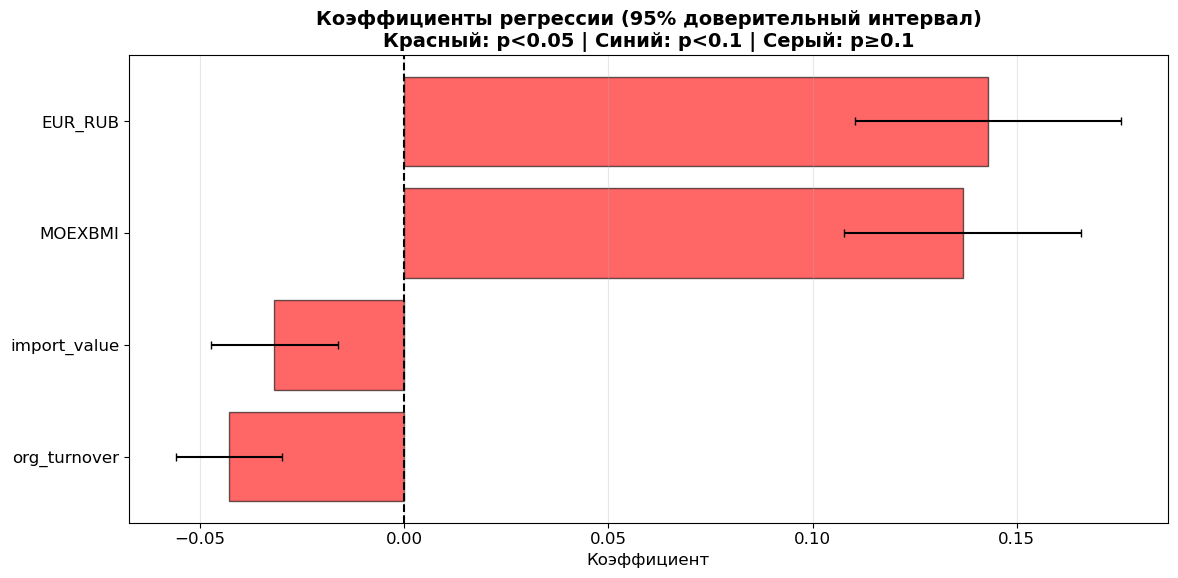


ДИАГНОСТИКА ОСТАТКОВ
--------------------------------------------------------------------------------

ДИАГНОСТИКА ОСТАТКОВ МОДЕЛИ

Jarque-Bera:
   Статистика: 0.0970
   p-value: 0.9526
   ➜ Остатки нормальные (H0 не отвергнута)

Shapiro-Wilk:
   Статистика: 0.9939
   p-value: 0.8846
   ➜ Остатки нормальные (H0 не отвергнута)

Breusch-Pagan:
   Статистика: 3.8889
   p-value: 0.4213
   ➜ Гомоскедастичность (H0 не отвергнута)

White:
   Статистика: 7.1508
   p-value: 0.9287
   ➜ Гомоскедастичность (H0 не отвергнута)

Durbin-Watson:
   Статистика: 2.0312
   ➜ Нет значимой автокорреляции

Ljung-Box:
   Статистика: 11.6087
   p-value: 0.2074
   ➜ Автокорреляция отсутствует (H0 не отвергнута)

СВОДКА ДИАГНОСТИЧЕСКИХ ТЕСТОВ
--------------------------------------------------------------------------------
         Тест  Статистика   p-value                                         Вывод
  Jarque-Bera    0.097034  0.952641         Остатки нормальные (H0 не отвергнута)
 Shapiro-Wilk    0.993871  

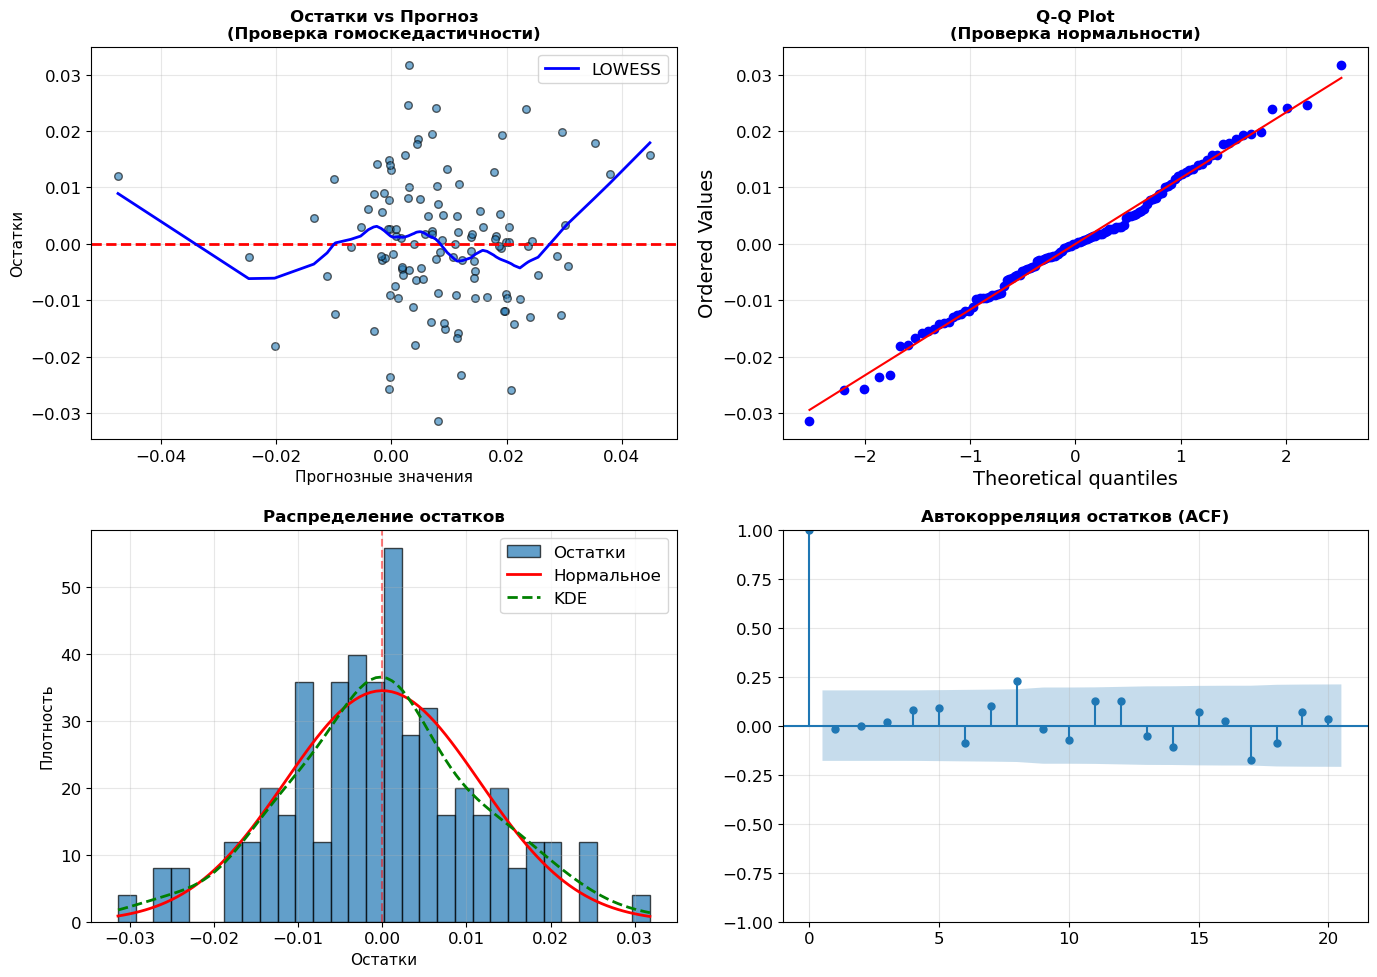

In [154]:
results = {}

for model_key, model_obj in final_models.items():
    model_vars = [v for v in model_obj.params.index if v != 'const']
    label = f"{model_key}: {', '.join(model_vars)}"
    prefix_map = {
        'Парсимоничная (BIC)':  'bic',
        'Backward / AIC':       'aic',
        'Парсимоничная + Lag1': 'lag1',
    }
    prefix = prefix_map.get(model_key, model_key.lower().replace(' ', '_'))

    if all(v in X_all.columns for v in model_vars):
        X_diag = X_all[model_vars]
    else:
        X_diag = pd.DataFrame(
            model_obj.model.exog[:, 1:],
            columns=model_vars,
            index=model_obj.model.data.row_labels,
        )

    coef, diag = analyze_model(
        model_obj, label, X_for_diag=X_diag, fig_prefix=prefix
    )
    results[model_key] = {'model': model_obj, 'coef': coef, 'diag': diag}


In [155]:
if len(final_models) >= 2:
    models_list = list(final_models.values())
    names_list = list(final_models.keys())
    for i in range(len(models_list)):
        for j in range(i + 1, len(models_list)):
            m_simple = models_list[i]
            m_complex = models_list[j]
            if len(m_simple.params) > len(m_complex.params):
                m_simple, m_complex = m_complex, m_simple
                n_simple, n_complex = names_list[j], names_list[i]
            else:
                n_simple, n_complex = names_list[i], names_list[j]

            if (m_simple.nobs == m_complex.nobs
                    and len(m_simple.params) < len(m_complex.params)):
                simple_vars = set(m_simple.params.index)
                complex_vars = set(m_complex.params.index)
                if simple_vars.issubset(complex_vars):
                    try:
                        f_result = f_test_nested(m_simple, m_complex)
                        print(f"\nF-тест: {n_simple} vs {n_complex}")
                        print(f"  F = {f_result['F-статистика']:.4f}, "
                              f"p = {f_result['p-value']:.4f}")
                        print(f"  {f_result['Вывод']}")
                    except ValueError as e:
                        print(f"\nF-тест невозможен ({n_simple} vs {n_complex}): {e}")


In [156]:
print(f"\n{'=' * 80}")
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА ФИНАЛЬНЫХ МОДЕЛЕЙ")
print(f"{'=' * 80}")

comparison_final = compare_models(final_models)
print(comparison_final.to_string(index=False))



СРАВНИТЕЛЬНАЯ ТАБЛИЦА ФИНАЛЬНЫХ МОДЕЛЕЙ
             Модель  Наблюдения  Параметры       R²   Adj R²         AIC         BIC     RMSE  Log-Likelihood  F-statistic    F p-value
Парсимоничная (BIC)         119          5 0.542264 0.526203 -714.965365 -701.069747 0.011754      362.482682    70.655282 5.694032e-30


In [157]:
print(f"\n{'=' * 80}")
print("ИТОГОВЫЙ ВЫБОР МОДЕЛИ")
print(f"{'=' * 80}")
best_model = final_models['Парсимоничная (BIC)']
best_name = 'Парсимоничная (BIC)'
best_vars = [v for v in best_model.params.index if v != 'const']

print(f"\nОсновная модель: {best_name}")
print(f"  Переменные: {best_vars}")
print(f"  R2 = {best_model.rsquared:.4f}")
print(f"  Adj R2 = {best_model.rsquared_adj:.4f}")
print(f"  AIC = {best_model.aic:.2f}")
print(f"  BIC = {best_model.bic:.2f}")
print(f"  Наблюдений: {int(best_model.nobs)}")
print(f"  Параметров: {len(best_model.params)}")

print("\nПротокол выбора:")
print(
    "  - Основной критерий: минимум BIC среди линейных подмножеств "
    f"размером 1–{MAX_REGRESSION_FEATURES} на единой выборке."
)
print(
    "  - Цель: парсимоничная объясняющая модель; AIC, Adj R², "
    "backward, forward и LASSO — проверки устойчивости."
)
if len(bic_evidence) > 1:
    print(f"  - ΔBIC до второй модели: {bic_evidence.loc[1, 'ΔBIC']:.2f}")
    if bic_evidence.loc[1, "ΔBIC"] < 2:
        print("  - Преимущество BIC не является решающим; интерпретируйте выбор осторожно.")
print("  - HAC стандартные ошибки используются для инференции после выбора спецификации.")

print(f"\nИнтерпретация коэффициентов:")

for _, row in get_coefficients_table(best_model).iterrows():
    var = row['Переменная']
    coef = row['Коэффициент']
    sig = row['Значимость']

    if var == 'const':
        print(f"  const = {coef:.4f} {sig}: средняя месячная log-доходность "
              f"портфеля при нулевых факторах")
    elif var == 'MOEXBMI':
        print(f"  MOEXBMI = {coef:.4f} {sig}: рост рынка на 1% "
              f"повышает доходность портфеля на {coef:.4f}")
    elif var == 'EUR_RUB':
        print(f"  EUR_RUB = {coef:.4f} {sig}: ослабление рубля к евро "
              f"на 1% повышает доходность на {coef:.4f}")
    elif var == 'yield_spread':
        print(f"  yield_spread = {coef:.4f} {sig}: рост наклона кривой "
              f"доходности на 1 п.п. {'повышает' if coef > 0 else 'снижает'} "
              f"доходность на {abs(coef):.4f}")
    elif var == 'org_turnover':
        print(f"  org_turnover = {coef:.4f} {sig}: рост оборота организаций "
              f"на 1% {'повышает' if coef > 0 else 'снижает'} "
              f"доходность на {abs(coef):.4f}")
    elif var == 'import_value':
        print(f"  import_value = {coef:.4f} {sig}: рост импорта "
              f"на 1% {'повышает' if coef > 0 else 'снижает'} "
              f"доходность на {abs(coef):.4f}")
    elif var == 'export_value':
        print(f"  export_value = {coef:.4f} {sig}: рост экспорта "
              f"на 1% {'повышает' if coef > 0 else 'снижает'} "
              f"доходность на {abs(coef):.4f}")
    elif var == 'inflation':
        print(f"  inflation = {coef:.4f} {sig}: рост инфляции "
              f"на 1 п.п. {'повышает' if coef > 0 else 'снижает'} "
              f"доходность на {abs(coef):.4f}")
    elif var == 'moex_volume':
        print(f"  moex_volume = {coef:.4f} {sig}: рост объема торгов "
              f"на 1% {'повышает' if coef > 0 else 'снижает'} "
              f"доходность на {abs(coef):.4f}")
    elif 'lag' in var:
        lag_n = var.replace('portfolio_lag', '')
        print(f"  {var} = {coef:.4f} {sig}: доходность {lag_n} мес. назад "
              f"{'положительно' if coef > 0 else 'отрицательно'} "
              f"влияет на текущую")
    else:
        print(f"  {var} = {coef:.4f} {sig}")



ИТОГОВЫЙ ВЫБОР МОДЕЛИ

Основная модель: Парсимоничная (BIC)
  Переменные: ['MOEXBMI', 'EUR_RUB', 'org_turnover', 'import_value']
  R2 = 0.5423
  Adj R2 = 0.5262
  AIC = -714.97
  BIC = -701.07
  Наблюдений: 119
  Параметров: 5

Протокол выбора:
  - Основной критерий: минимум BIC среди линейных подмножеств размером 1–5 на единой выборке.
  - Цель: парсимоничная объясняющая модель; AIC, Adj R², backward, forward и LASSO — проверки устойчивости.
  - ΔBIC до второй модели: 2.17
  - HAC стандартные ошибки используются для инференции после выбора спецификации.

Интерпретация коэффициентов:
  const = 0.0126 ***: средняя месячная log-доходность портфеля при нулевых факторах
  EUR_RUB = 0.1429 ***: ослабление рубля к евро на 1% повышает доходность на 0.1429
  MOEXBMI = 0.1368 ***: рост рынка на 1% повышает доходность портфеля на 0.1368
  org_turnover = -0.0428 ***: рост оборота организаций на 1% снижает доходность на 0.0428
  import_value = -0.0318 ***: рост импорта на 1% снижает доходность на

In [158]:
print(f"\n{'=' * 80}")
print("ФИНАЛЬНАЯ МОДЕЛЬ")
print(f"{'=' * 80}")
print(best_model.summary())



ФИНАЛЬНАЯ МОДЕЛЬ
                            OLS Regression Results                            
Dep. Variable:              Portfolio   R-squared:                       0.542
Model:                            OLS   Adj. R-squared:                  0.526
Method:                 Least Squares   F-statistic:                     70.66
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           5.69e-30
Time:                        12:56:20   Log-Likelihood:                 362.48
No. Observations:                 119   AIC:                            -715.0
Df Residuals:                     114   BIC:                            -701.1
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0126      0

## 4.6. Скользящая регрессия: устойчивость коэффициентов во времени


In [159]:
VAR_LABELS = {
    'MOEXBMI':      'MOEXBMI\n(коэфф. при log-доходности)',
    'EUR_RUB':      'EUR/RUB\n(коэфф. при log-приросте курса)',
    'org_turnover': 'Оборот организаций\n(коэфф. при г/г темпе прироста)',
    'import_value': 'Импорт\n(коэфф. при log-приросте)',
}
SIG_COLOR, NONSIG_COLOR = '#2e8b57', '#e8821e'

WINDOW = 60
def plot_rolling_coefficients_marked(
    rolling_coefs: pd.DataFrame,
    rolling_pvals: pd.DataFrame,
    rolling_r2: pd.Series,
    window: int,
    *,
    reference_model: RegressionResultsWrapper | None = None,
    exclude: Sequence[str] = ('const',),
    figsize: tuple[float, float] = (14, 14),
    alpha_level: float = 0.05,
) -> tuple[Figure, np.ndarray]:
    """Строит траектории коэффициентов rolling-регрессии и их значимость.

    Args:
        rolling_coefs: Оценки коэффициентов по окнам.
        rolling_pvals: p-value коэффициентов по окнам.
        rolling_r2: Скорректированный R2 по окнам.
        window: Размер rolling-окна.
        reference_model: Модель полной выборки для горизонтальных ориентиров.
        exclude: Переменные, исключаемые из графика.
        figsize: Размер фигуры.
        alpha_level: Порог значимости маркеров.

    Returns:
        Созданная фигура и массив осей.

    Raises:
        ValueError: Если после исключения не осталось коэффициентов.
    """
    plt.rcParams['axes.unicode_minus'] = False
    comma = FuncFormatter(lambda x, _: f'{x:.2f}'.replace('.', ','))

    vars_to_plot = [c for c in rolling_coefs.columns if c not in exclude]
    n_vars = len(vars_to_plot)
    if n_vars == 0:
        raise ValueError("No coefficients available for plotting")
    fig, axes = plt.subplots(n_vars + 1, 1, figsize=figsize, sharex=True)
    for i, var in enumerate(vars_to_plot):
        ax = axes[i]
        coef, pval = rolling_coefs[var], rolling_pvals[var]
        sig_mask = (pval < alpha_level).values
        idx = coef.index
        ax.plot(idx, coef.values, '-', color='black', linewidth=1.2, zorder=3)
        ax.scatter(idx[sig_mask], coef.values[sig_mask], s=16, color=SIG_COLOR, zorder=4)
        ax.scatter(idx[~sig_mask], coef.values[~sig_mask], s=22, color=NONSIG_COLOR, zorder=5, edgecolor='black', linewidth=0.4)
        nonsig = ~sig_mask
        j = 0
        while j < len(nonsig):
            if nonsig[j]:
                k = j
                while k + 1 < len(nonsig) and nonsig[k + 1]: k += 1
                ax.axvspan(idx[max(j - 1, 0)], idx[min(k + 1, len(idx) - 1)], color=NONSIG_COLOR, alpha=0.10, zorder=0)
                j = k + 1
            else:
                j += 1
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, zorder=1)
        full_coef = None if reference_model is None else reference_model.params.get(var)
        if full_coef is not None:
            ax.axhline(full_coef, color='blue', linestyle=':', linewidth=1.2, zorder=2)
        ax.set_ylabel(VAR_LABELS.get(var, var), fontsize=9)
        ax.yaxis.set_major_formatter(comma)          # десятичная запятая на оси Y
        ax.grid(alpha=0.3)
        handles = [
            Line2D([0], [0], marker='o', linestyle='None', color=SIG_COLOR, label='p < 0,05', markersize=6),
            Line2D([0], [0], marker='o', linestyle='None', color=NONSIG_COLOR, markeredgecolor='black', markeredgewidth=0.4, label='p ≥ 0,05', markersize=6),
        ]
        if full_coef is not None:
            handles.append(Line2D([0], [0], color='blue', linestyle=':',
                                   label=f"Полная выборка: {full_coef:.4f}".replace('.', ',')))
        ax.legend(handles=handles, loc='best', fontsize=8)   # 'best' — легенда не налезает на данные
    ax_r2 = axes[-1]
    ax_r2.plot(rolling_r2.index, rolling_r2.values, 'k-', linewidth=1.2)
    ax_r2.fill_between(rolling_r2.index, rolling_r2.values, alpha=0.2, color='steelblue')
    full_r2 = None if reference_model is None else reference_model.rsquared_adj
    if full_r2 is not None:
        ax_r2.axhline(full_r2, color='blue', linestyle=':', linewidth=1.2,
                      label=f"Полная выборка: {full_r2:.3f}".replace('.', ','))
    ax_r2.set_ylabel('Adj R²\n(доля объяснённой дисперсии)', fontsize=9)
    ax_r2.yaxis.set_major_formatter(comma)           # десятичная запятая на оси Y
    ax_r2.set_xlabel('Конец скользящего окна', fontsize=11)
    if full_r2 is not None:
        ax_r2.legend(loc='best', fontsize=8)
    ax_r2.grid(alpha=0.3)
    ax_r2.set_ylim(0, 1)
    x_start, x_end = rolling_coefs.index.min(), rolling_coefs.index.max()
    for ax in axes: ax.set_xlim(x_start, x_end)
    ticks = pd.date_range(x_start, x_end, freq='6MS')
    if x_end not in ticks: ticks = ticks.append(pd.DatetimeIndex([x_end]))
    ticks = ticks.unique()
    axes[-1].set_xticks(ticks)
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha='right')
    fig.suptitle(f'Скользящая регрессия (окно {window} мес.) - значимость по маркерам\n'
                 f'Коэффициенты OLS с HAC-ошибками (Newey-West, 4 лага)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig, axes


In [160]:
def test_block_4_6_rolling_plot_uses_explicit_figure() -> None:
    index = pd.date_range("2020-01-01", periods=4, freq="MS")
    rolling_coefs = pd.DataFrame({"x": [0.1, 0.2, 0.3, 0.4]}, index=index)
    rolling_pvals = pd.DataFrame({"x": [0.01, 0.2, 0.01, 0.2]}, index=index)
    rolling_r2 = pd.Series([0.1, 0.2, 0.3, 0.4], index=index)

    figure, axes = plot_rolling_coefficients_marked(
        rolling_coefs,
        rolling_pvals,
        rolling_r2,
        window=3,
    )
    try:
        assert isinstance(figure, Figure)
        assert len(axes) == 2
    finally:
        plt.close(figure)


In [161]:
run_notebook_tests("test_block_4_6")


.                                                                                            [100%]


0

Rolling: 60 мес., 60 окон, 2021-01 - 2025-12
Переменные: ['MOEXBMI', 'EUR_RUB', 'org_turnover', 'import_value']
  MOEXBMI: знак стаб. 100.0%, значим 100.0%
  EUR_RUB: знак стаб. 100.0%, значим 100.0%
  org_turnover: знак стаб. 100.0%, значим 100.0%
  import_value: знак стаб. 100.0%, значим 100.0%
Adj R²: мин 0.229, мед 0.650, макс 0.692

Сводная таблица:
  Переменная  Полновыб. β  Медиана β     Мин β    Макс β % знак стаб. % значим
     MOEXBMI     0.136759   0.137465  0.099816  0.151275       100.0%   100.0%
     EUR_RUB     0.142933   0.149009  0.112872  0.159434       100.0%   100.0%
org_turnover    -0.042814  -0.038499 -0.049176 -0.031769       100.0%   100.0%
import_value    -0.031771  -0.040829 -0.052092 -0.020150       100.0%   100.0%
Сохранено: figures\regression_rolling_coefficients_signif.pdf
Сохранено PNG: figures/regression_rolling_coefficients_signif.png


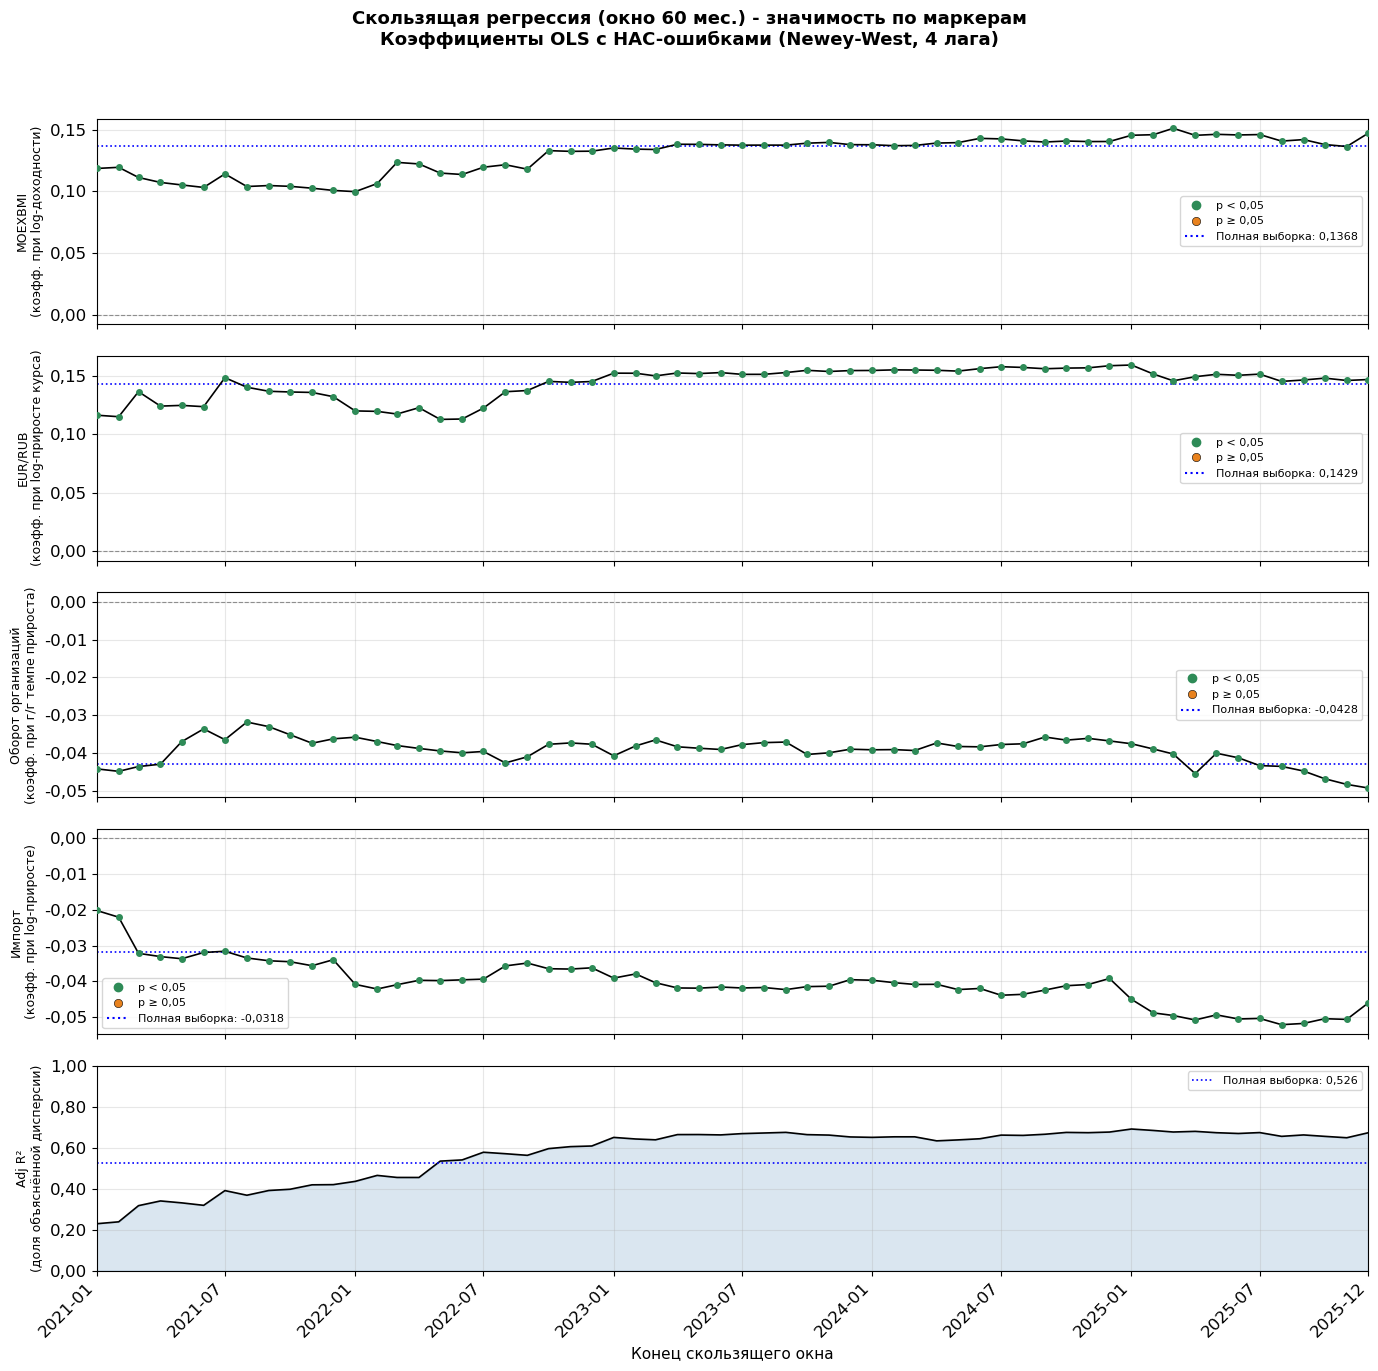

In [162]:
if len(Y) < WINDOW:
    raise ValueError(
        f"Недостаточно наблюдений для rolling-окна {WINDOW}: получено {len(Y)}"
    )

best_vars = [v for v in best_model.params.index if v != 'const']

coef_records, pval_records, r2_records = [], [], []
for end_idx in range(WINDOW, len(Y) + 1):
    start_idx = end_idx - WINDOW
    Y_win = Y.iloc[start_idx:end_idx]
    X_win = X_all[best_vars].iloc[start_idx:end_idx]
    m = _fit_ols(Y_win, X_win)
    date = Y.index[end_idx - 1]
    coef_records.append({"date": date, **{v: m.params.get(v, np.nan) for v in best_vars}})
    pval_records.append({"date": date, **{v: m.pvalues.get(v, np.nan) for v in best_vars}})
    r2_records.append({"date": date, "adj_r2": m.rsquared_adj})

rolling_coefs = pd.DataFrame(coef_records).set_index("date")
rolling_pvals = pd.DataFrame(pval_records).set_index("date")
rolling_r2 = pd.DataFrame(r2_records).set_index("date")["adj_r2"]

print(f"Rolling: {WINDOW} мес., {len(rolling_coefs)} окон, {rolling_coefs.index[0]:%Y-%m} - {rolling_coefs.index[-1]:%Y-%m}")
print(f"Переменные: {best_vars}")
for var in best_vars:
    sign_stab = (np.sign(rolling_coefs[var]) == np.sign(best_model.params[var])).mean() * 100
    signif = (rolling_pvals[var] < 0.05).mean() * 100
    print(f"  {var}: знак стаб. {sign_stab:.1f}%, значим {signif:.1f}%")
print(f"Adj R²: мин {rolling_r2.min():.3f}, мед {rolling_r2.median():.3f}, макс {rolling_r2.max():.3f}")

stability_table = pd.DataFrame({
    'Переменная': best_vars,
    'Полновыб. β': [best_model.params[v] for v in best_vars],
    'Медиана β': [rolling_coefs[v].median() for v in best_vars],
    'Мин β': [rolling_coefs[v].min() for v in best_vars],
    'Макс β': [rolling_coefs[v].max() for v in best_vars],
    '% знак стаб.': [f"{(np.sign(rolling_coefs[v]) == np.sign(best_model.params[v])).mean()*100:.1f}%" for v in best_vars],
    '% значим': [f"{(rolling_pvals[v] < 0.05).mean()*100:.1f}%" for v in best_vars],
})
print("\nСводная таблица:")
print(stability_table.to_string(index=False))


fig_roll2, _ = plot_rolling_coefficients_marked(
    rolling_coefs,
    rolling_pvals,
    rolling_r2,
    window=WINDOW,
    reference_model=best_model,
)
save_figure(fig_roll2, "regression_rolling_coefficients_signif")
png_path = "figures/regression_rolling_coefficients_signif.png"
fig_roll2.savefig(png_path, dpi=300, bbox_inches="tight", format="png", facecolor="white")
print(f"Сохранено PNG: {png_path}")
_render_figure(fig_roll2, show=True)


# 5. Ответы на замечания рецензента


## 5.1. Выбор безрисковой ставки: 10Y и проверка чувствительности


Замечание 1. Длинный конец кривой бескупонной доходности может быть модельно обусловлен и неустойчив. Поэтому базовой безрисковой ставкой остаётся 10Y: этот срок соответствует наблюдаемому участку кривой.

Сегмент 20Y возвращён в проверку чувствительности. В КБД он формируется моделью Свенссона на дальнем, экстраполируемом конце кривой, поэтому его уместно рассматривать как консервативный сценарий, а не как замену базовой ставке. Если ранжирование портфелей не меняется при переходе от 10Y к 20Y, вывод устойчив и к этому модельному допущению.

Текущая реализация берёт простое среднее ежедневных значений каждого сегмента за весь доступный период кривой ОФЗ. Альтернативные сегменты в этом разделе не меняют выбранную ставку в основном анализе.


In [163]:
RISK_FREE_SENSITIVITY_SEGMENTS: tuple[str, ...] = ("1Y", "3Y", "10Y", "20Y")


def build_risk_free_candidates(
    yield_curve_summary: pd.DataFrame,
    *,
    segments: Sequence[str] = RISK_FREE_SENSITIVITY_SEGMENTS,
) -> dict[str, float]:
    """Строит кандидаты безрисковой ставки для проверки чувствительности.

    Args:
        yield_curve_summary: Сводка сегментов из summarize_yield_curve_segments.
        segments: Сегменты кривой, включаемые в проверку.

    Returns:
        Словарь сегмент -> средняя годовая ставка в долях.

    Raises:
        KeyError: Если в сводке отсутствует хотя бы один сегмент.
    """
    return {
        segment: select_risk_free_rate(yield_curve_summary, segment) / 100
        for segment in segments
    }


def calculate_risk_free_sensitivity(
    specifications: Mapping[str, tuple[pd.DataFrame, np.ndarray]],
    risk_free_candidates: Mapping[str, float],
    *,
    mar: float,
    metric_function: Callable[
        [pd.DataFrame, np.ndarray, float, float], Mapping[str, float]
    ] = compute_all_metrics_for_weights,
) -> pd.DataFrame:
    """Считает риск-скорректированные метрики при альтернативных ставках.

    Args:
        specifications: Словарь спецификация -> дневные доходности и веса.
        risk_free_candidates: Метки и годовые ставки в долях.
        mar: Годовой minimum acceptable return.
        metric_function: Функция расчёта метрик портфеля.

    Returns:
        Таблица метрик каждой пары ставка-спецификация.
    """
    rows: list[dict[str, str | float]] = []
    for rate_label, rate_value in risk_free_candidates.items():
        for specification_name, (returns, weights) in specifications.items():
            metrics = metric_function(returns, weights, rate_value, mar)
            rows.append(
                {
                    "RF": rate_label,
                    "RF_value_%": rate_value * 100,
                    "Спецификация": specification_name,
                    "Sharpe": float(metrics["Sharpe"]),
                    "Sortino": float(metrics["Sortino"]),
                    "Calmar": float(metrics["Calmar"]),
                    "Martin": float(metrics["Martin Ratio"]),
                }
            )
    return pd.DataFrame(rows)


def create_sensitivity_pivot(
    sensitivity: pd.DataFrame,
    metric: str,
) -> pd.DataFrame:
    """Преобразует результаты чувствительности в таблицу сегмент на спецификацию.

    Args:
        sensitivity: Результат calculate_risk_free_sensitivity.
        metric: Имя метрики для значений таблицы.

    Returns:
        Pivot-таблица для сравнения сегментов кривой.
    """
    return sensitivity.pivot(index="RF", columns="Спецификация", values=metric)


def has_stable_ranking(metric_pivot: pd.DataFrame) -> bool:
    """Проверяет неизменность ранжирования спецификаций между ставками.

    Args:
        metric_pivot: Таблица сегмент на спецификацию.

    Returns:
        True, если ранг каждой спецификации одинаков во всех строках.
    """
    ranking = metric_pivot.rank(axis=1, ascending=False, method="min")
    return bool((ranking.nunique(axis=0) == 1).all())


In [164]:
def test_block_5_1_build_risk_free_candidates_converts_percent_to_fraction() -> None:
    summary = pd.DataFrame(
        {"Средняя доходность, %": [8.0, 9.0, 10.0, 11.0]},
        index=["1Y", "3Y", "10Y", "20Y"],
    )

    candidates = build_risk_free_candidates(summary)

    assert candidates == {"1Y": 0.08, "3Y": 0.09, "10Y": 0.10, "20Y": 0.11}


def test_block_5_1_sensitivity_keeps_expected_shape_and_ranking() -> None:
    specifications = {
        "A": (pd.DataFrame({"asset": [0.01]}), np.array([1.0])),
        "B": (pd.DataFrame({"asset": [0.02]}), np.array([1.0])),
    }

    def fake_metrics(
        returns: pd.DataFrame,
        weights: np.ndarray,
        risk_free_rate: float,
        mar: float,
    ) -> Mapping[str, float]:
        """Возвращает детерминированные метрики для проверки формы таблицы."""
        del weights, mar
        value = float(returns.iloc[0, 0] - risk_free_rate)
        return {
            "Sharpe": value,
            "Sortino": value,
            "Calmar": value,
            "Martin Ratio": value,
        }

    sensitivity = calculate_risk_free_sensitivity(
        specifications,
        {"1Y": 0.01, "10Y": 0.02, "20Y": 0.03},
        mar=0.03,
        metric_function=fake_metrics,
    )
    sharpe = create_sensitivity_pivot(sensitivity, "Sharpe")

    assert sensitivity.shape == (6, 7)
    assert has_stable_ranking(sharpe)


In [165]:
run_notebook_tests("test_block_5_1")


..                                                                                           [100%]


0

In [166]:
risk_free_candidates = build_risk_free_candidates(yield_curve_summary)
specifications_for_rf_sensitivity = {
    "Спец. 1": (portfolio_1_daily_returns, median_w1),
    "Спец. 2": (portfolio_2_daily_returns, median_w2),
    "Спец. 3": (portfolio_3_daily_returns, median_w3),
    "Спец. 4": (portfolio_4_daily_returns, median_w4),
}
risk_free_sensitivity = calculate_risk_free_sensitivity(
    specifications_for_rf_sensitivity,
    risk_free_candidates,
    mar=mar,
)

selected_rf_period = yield_curve_summary.loc[
    SELECTED_RISK_FREE_SEGMENT,
    ["Наблюдений", "Начало", "Конец", "Средняя доходность, %"],
]
print(
    f"Базовая ставка: {SELECTED_RISK_FREE_SEGMENT} = "
    f"{risk_free_rate_10:.2f}%"
)
print(selected_rf_period.to_string())
print(
    "20Y включён как сценарий чувствительности: дальний участок КБД "
    "получен модельной экстраполяцией Свенссона."
)

for metric_name in ("Sharpe", "Sortino", "Calmar", "Martin"):
    metric_pivot = create_sensitivity_pivot(risk_free_sensitivity, metric_name)
    print(f"\n{metric_name} при альтернативных сегментах кривой:")
    print(metric_pivot.round(3).to_string())
    print(f"Ранжирование устойчиво: {has_stable_ranking(metric_pivot)}")


Базовая ставка: 10Y = 9.80%
Наблюдений                              2766
Начало                   2015-01-05 00:00:00
Конец                    2025-12-30 00:00:00
Средняя доходность, %               9.799277
20Y включён как сценарий чувствительности: дальний участок КБД получен модельной экстраполяцией Свенссона.

Sharpe при альтернативных сегментах кривой:
Спецификация  Спец. 1  Спец. 2  Спец. 3  Спец. 4
RF                                              
10Y             0.625    0.635    0.631    0.641
1Y              0.647    0.656    0.659    0.670
20Y             0.616    0.627    0.620    0.629
3Y              0.640    0.649    0.650    0.661
Ранжирование устойчиво: False

Sortino при альтернативных сегментах кривой:
Спецификация  Спец. 1  Спец. 2  Спец. 3  Спец. 4
RF                                              
10Y             0.768    0.795     0.77    0.781
1Y              0.768    0.795     0.77    0.781
20Y             0.768    0.795     0.77    0.781
3Y              0.768    

## 5.2. MOEXALLW как benchmark, а не цель репликации

Исследование не решает задачу репликации MOEXALLW: целевая функция выбирает веса по набору риск-скорректированных метрик, а индекс используется как внешний ориентир. Tracking error и information ratio показываются как диагностические характеристики, а не как критерии оптимизации.

В текущем наборе данных MOEXALLW доступен только с 12.03.2025 по 31.12.2025. Поэтому ниже сравнение ограничено общим доступным периодом и не подтверждает поведение портфеля на всём горизонте 2015–2025. Для такого вывода необходимо добавить историю MOEXALLW за весь исследуемый период.


Замечание 2. Инвестор во «всепогодный» портфель может ориентироваться
на MOEXALLW, поэтому нужны корреляция и соответствие индексу.

Проверка добавлена для всех спецификаций. При этом MOEXALLW является внешним
benchmark: задача исследования — не репликация индекса, а выбор устойчивого
смешанного портфеля по набору риск-доходностных критериев. Если целью была бы
именно репликация, критерием оптимизации стал бы tracking error, а не Sharpe,
Sortino и другие использованные метрики.


In [167]:
def calculate_benchmark_statistics(
    portfolio_returns: pd.Series,
    benchmark_returns: pd.Series,
    *,
    periods_per_year: int = 252,
) -> dict[str, float | int | pd.Timestamp]:
    """Вычисляет связь портфеля с benchmark на общем временном интервале.

    Args:
        portfolio_returns: Дневные доходности портфеля.
        benchmark_returns: Дневные доходности benchmark.
        periods_per_year: Число торговых периодов в году.

    Returns:
        Корреляция, beta, tracking error, active return, information ratio
        и параметры общего периода.

    Raises:
        ValueError: Если после синхронизации недостаточно наблюдений или
            дисперсия benchmark равна нулю.
    """
    aligned = pd.concat(
        [portfolio_returns.rename("portfolio"), benchmark_returns.rename("benchmark")],
        axis=1,
        sort=False,
    ).dropna()
    if len(aligned) < 2:
        raise ValueError("At least two overlapping observations are required")

    active_returns = aligned["portfolio"] - aligned["benchmark"]
    benchmark_variance = float(aligned["benchmark"].var(ddof=1))
    if benchmark_variance == 0:
        raise ValueError("Benchmark variance must be non-zero")

    tracking_error = float(active_returns.std(ddof=1) * np.sqrt(periods_per_year))
    active_return = float(active_returns.mean() * periods_per_year)
    information_ratio = (
        float(active_returns.mean() / active_returns.std(ddof=1) * np.sqrt(periods_per_year))
        if tracking_error > 0
        else np.nan
    )
    covariance = float(np.cov(aligned["portfolio"], aligned["benchmark"], ddof=1)[0, 1])
    return {
        "Наблюдений": len(aligned),
        "Начало": aligned.index.min(),
        "Конец": aligned.index.max(),
        "Корреляция": float(aligned["portfolio"].corr(aligned["benchmark"])),
        "Beta": covariance / benchmark_variance,
        "Tracking Error, %": tracking_error * 100,
        "Активная доходность, %": active_return * 100,
        "Information Ratio": information_ratio,
    }


def compare_specifications_to_benchmark(
    specifications: Mapping[str, tuple[pd.DataFrame, np.ndarray]],
    benchmark_returns: pd.Series,
) -> pd.DataFrame:
    """Сравнивает все портфельные спецификации с единым benchmark.

    Args:
        specifications: Словарь спецификация -> доходности активов и веса.
        benchmark_returns: Дневные доходности benchmark.

    Returns:
        Таблица benchmark-статистик для каждой спецификации.
    """
    rows: list[dict[str, str | float | int | pd.Timestamp]] = []
    for name, (returns, weights) in specifications.items():
        portfolio_returns = returns @ weights
        rows.append(
            {
                "Спецификация": name,
                **calculate_benchmark_statistics(portfolio_returns, benchmark_returns),
            }
        )
    return pd.DataFrame(rows).set_index("Спецификация").sort_values(
        "Tracking Error, %",
        ascending=True,
    )


def plot_benchmark_growth(
    portfolio_returns: pd.Series,
    benchmark_returns: pd.Series,
    *,
    portfolio_label: str,
    benchmark_label: str = "MOEXALLW",
    initial_value: float = 1000.0,
) -> Figure:
    """Строит динамику стоимости портфеля и benchmark на общем периоде.

    Args:
        portfolio_returns: Дневные доходности портфеля.
        benchmark_returns: Дневные доходности benchmark.
        portfolio_label: Подпись портфеля.
        benchmark_label: Подпись benchmark.
        initial_value: Начальная стоимость обеих инвестиций.

    Returns:
        Фигура Matplotlib без немедленного отображения.
    """
    aligned = pd.concat(
        [portfolio_returns.rename(portfolio_label), benchmark_returns.rename(benchmark_label)],
        axis=1,
        sort=False,
    ).dropna()
    values = (1 + aligned).cumprod() * initial_value
    figure, axis = plt.subplots(figsize=(12, 6))
    values.plot(ax=axis, linewidth=1.8)
    axis.set_title(f"{portfolio_label} и {benchmark_label}: общий период")
    axis.set_xlabel("Дата")
    axis.set_ylabel("Стоимость инвестиции")
    axis.grid(alpha=0.3)
    axis.legend(loc="best")
    figure.tight_layout()
    return figure


In [168]:
def test_block_5_2_calculates_benchmark_statistics_on_common_period() -> None:
    index = pd.bdate_range("2024-01-01", periods=4)
    portfolio = pd.Series([0.02, 0.01, -0.01, 0.03], index=index)
    benchmark = pd.Series([0.01, 0.00, -0.02, 0.02], index=index)

    statistics = calculate_benchmark_statistics(portfolio, benchmark)

    assert statistics["Наблюдений"] == 4
    assert statistics["Корреляция"] == pytest.approx(1.0)
    assert statistics["Tracking Error, %"] > 0


def test_block_5_2_compares_each_specification() -> None:
    index = pd.bdate_range("2024-01-01", periods=4)
    specifications = {
        "A": (pd.DataFrame({"x": [0.01, 0.02, 0.01, 0.02]}, index=index), np.array([1.0])),
        "B": (pd.DataFrame({"x": [0.02, 0.01, 0.00, 0.03]}, index=index), np.array([1.0])),
    }
    benchmark = pd.Series([0.01, 0.01, 0.00, 0.02], index=index)

    comparison = compare_specifications_to_benchmark(specifications, benchmark)

    assert set(comparison.index) == {"A", "B"}
    assert set(["Beta", "Information Ratio"]).issubset(comparison.columns)


In [169]:
run_notebook_tests("test_block_5_2")


..                                                                                           [100%]


0

Сравнение спецификаций с MOEXALLW:
              Наблюдений     Начало      Конец  Корреляция   Beta  Tracking Error, %  Активная доходность, %  Information Ratio
Спецификация                                                                                                                   
Спец. 3              161 2025-03-13 2025-12-30       0.462  0.387              9.689                  14.959              1.544
Спец. 4              161 2025-03-13 2025-12-30       0.453  0.377              9.748                  15.544              1.595
Спец. 1              161 2025-03-13 2025-12-30       0.494  0.509             10.279                  15.113              1.470
Спец. 2              161 2025-03-13 2025-12-30       0.532  0.637             10.847                  13.869              1.279

Спец. 3 относительно MOEXALLW:
Наблюдений                                161
Начало                    2025-03-13 00:00:00
Конец                     2025-12-30 00:00:00
Корреляция                 

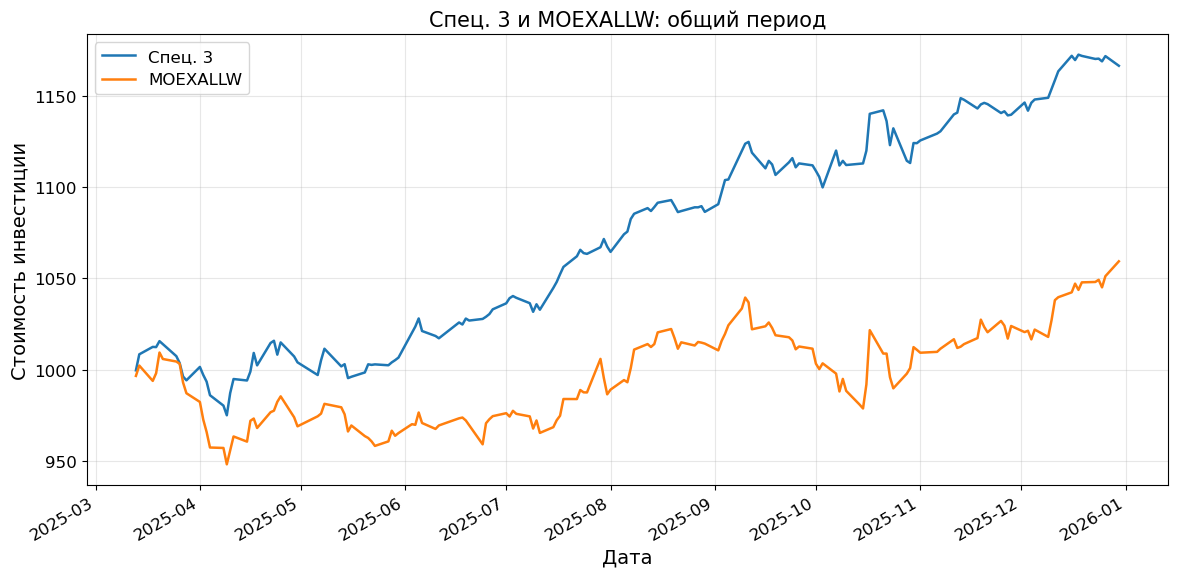

In [170]:
moexallw_prices = df_MOEXALLW.set_index("TRADEDATE")["CLOSE"].sort_index()
moexallw_daily = moexallw_prices.pct_change().dropna()

specifications_for_benchmark = {
    "Спец. 1": (portfolio_1_daily_returns, median_w1),
    "Спец. 2": (portfolio_2_daily_returns, median_w2),
    "Спец. 3": (portfolio_3_daily_returns, median_w3),
    "Спец. 4": (portfolio_4_daily_returns, median_w4),
}
benchmark_comparison = compare_specifications_to_benchmark(
    specifications_for_benchmark,
    moexallw_daily,
)
print("Сравнение спецификаций с MOEXALLW:")
benchmark_display = benchmark_comparison.copy()
benchmark_numeric_columns = benchmark_display.select_dtypes(include=[np.number]).columns
benchmark_display[benchmark_numeric_columns] = benchmark_display[
    benchmark_numeric_columns
].round(3)
print(benchmark_display.to_string())

recommended_portfolio_returns = portfolio_3_daily_returns @ median_w3
recommended_statistics = calculate_benchmark_statistics(
    recommended_portfolio_returns,
    moexallw_daily,
)
print("\nСпец. 3 относительно MOEXALLW:")
print(pd.Series(recommended_statistics).to_string())

benchmark_figure = plot_benchmark_growth(
    recommended_portfolio_returns,
    moexallw_daily,
    portfolio_label="Спец. 3",
)
save_figure(benchmark_figure, "comparison_spec3_vs_moexallw")
_render_figure(benchmark_figure, show=True)


# 6. Проверка устойчивости диапазонов весов к набору метрик


Раздел проверяет, насколько диапазоны и медианные веса зависят от
состава метрик, включённых в агрегацию. Базовым остаётся фактический набор из
восьми метрик, использованный в основном анализе.


In [171]:
ALL_METRICS: tuple[str, ...] = CORE_METRICS_FOR_BOUNDS
BASE_METRIC_SET = "8 (базовый, с MDD)"
METRIC_SETS: dict[str, list[str]] = {
    BASE_METRIC_SET: list(ALL_METRICS),
    "7 (без MDD)": [
        "sharpe",
        "sortino",
        "calmar",
        "cvar_005",
        "martin",
        "omega",
        "volatility",
    ],
    "5 (узкий)": ["sharpe", "sortino", "calmar", "cvar_005", "martin"],
}


def validate_metric_set_configuration(
    core_metrics: Sequence[str],
    all_metrics: Sequence[str],
    metric_sets: Mapping[str, Sequence[str]],
    *,
    base_set: str,
) -> None:
    """Проверяет согласованность базового набора и альтернативных наборов метрик.

    Args:
        core_metrics: Метрики, применённые в основном расчёте bounds.
        all_metrics: Полный допустимый набор метрик.
        metric_sets: Наборы для robustness checks.
        base_set: Метка набора, соответствующего основному расчёту.

    Raises:
        ValueError: Если базовый набор не совпадает с основным расчётом
            либо альтернативный набор содержит неизвестную метрику.
        KeyError: Если базовый набор отсутствует.
    """
    if base_set not in metric_sets:
        raise KeyError(f"Unknown base metric set: {base_set}")
    if set(core_metrics) != set(metric_sets[base_set]):
        raise ValueError(
            "core_metrics_for_bounds must match the declared base metric set"
        )
    available_metrics = set(all_metrics)
    for set_name, metrics in metric_sets.items():
        if not set(metrics).issubset(available_metrics):
            raise ValueError(f"{set_name} contains unknown metrics")


def calculate_bounds_sensitivity(
    specifications: Mapping[str, tuple[Mapping[str, dict[str, Any]], Sequence[str]]],
    metric_sets: Mapping[str, Sequence[str]],
    *,
    aggregate_function: Callable[..., tuple[list[tuple[float, float]], pd.DataFrame, pd.DataFrame]]
    = aggregate_bounds_from_window_results,
) -> dict[str, dict[str, pd.DataFrame]]:
    """Агрегирует bounds для всех спецификаций и наборов метрик.

    Args:
        specifications: Спецификация -> результаты окон и порядок активов.
        metric_sets: Набор метрик для каждой альтернативы.
        aggregate_function: Функция агрегирования bounds.

    Returns:
        Вложенный словарь спецификация -> набор метрик -> таблица bounds.
    """
    result: dict[str, dict[str, pd.DataFrame]] = {}
    for specification_name, (analysis_results, asset_names) in specifications.items():
        result[specification_name] = {}
        for set_name, metrics in metric_sets.items():
            _, summary, _ = aggregate_function(
                analysis_results=analysis_results,
                asset_names=list(asset_names),
                metrics_to_use=list(metrics),
                lower_percentile=10,
                upper_percentile=90,
                successful_only=True,
            )
            result[specification_name][set_name] = summary
    return result


def build_bounds_shift_summary(
    sensitivity: Mapping[str, Mapping[str, pd.DataFrame]],
    *,
    base_set: str,
) -> pd.DataFrame:
    """Собирает максимальные сдвиги медианных весов от базового набора.

    Args:
        sensitivity: Результат calculate_bounds_sensitivity.
        base_set: Метка базового набора метрик.

    Returns:
        Таблица максимальных абсолютных сдвигов медианы по спецификациям.
    """
    rows: list[dict[str, str | float]] = []
    for specification_name, set_results in sensitivity.items():
        base = set_results[base_set].set_index("Asset")["Median_Weight"]
        for set_name, summary in set_results.items():
            if set_name == base_set:
                continue
            shift = summary.set_index("Asset")["Median_Weight"].sub(base)
            asset = str(shift.abs().idxmax())
            rows.append(
                {
                    "Спецификация": specification_name,
                    "Набор": set_name,
                    "Макс |сдвиг|, п.п.": float(shift.abs().max()),
                    "Актив с макс. сдвигом": asset,
                    "Знак сдвига": "+" if shift.loc[asset] > 0 else "-",
                    "Средняя ширина диапазона, п.п.": float(
                        summary["Range_Width"].mean()
                    ),
                }
            )
    return pd.DataFrame(rows)


def calculate_portfolio_metrics_by_set(
    bounds_by_set: Mapping[str, pd.DataFrame],
    asset_names: Sequence[str],
    portfolio_returns: pd.DataFrame,
    *,
    risk_free_rate: float,
    mar: float,
) -> pd.DataFrame:
    """Сравнивает метрики портфеля на медианных весах разных наборов.

    Args:
        bounds_by_set: Таблицы bounds одной спецификации по наборам метрик.
        asset_names: Порядок активов портфеля.
        portfolio_returns: Дневные доходности активов.
        risk_free_rate: Годовая безрисковая ставка.
        mar: Годовой MAR.

    Returns:
        Таблица метрик по набору агрегации.
    """
    metrics_by_set: dict[str, Mapping[str, float | str]] = {}
    for set_name, summary in bounds_by_set.items():
        median_weights = summary.set_index("Asset").loc[
            list(asset_names),
            "Median_Weight",
        ].to_numpy(dtype=float)
        normalized_weights = median_weights / median_weights.sum()
        metrics = dict(
            compute_all_metrics_for_weights(
                portfolio_returns,
                normalized_weights,
                risk_free_rate,
                mar,
            )
        )
        metrics["Веса (норм.), %"] = ", ".join(
            f"{weight * 100:.1f}" for weight in normalized_weights
        )
        metrics_by_set[set_name] = metrics
    return pd.DataFrame(metrics_by_set).T


In [172]:
def test_block_6_validates_base_metric_set() -> None:
    validate_metric_set_configuration(
        ["a", "b"],
        ["a", "b", "c"],
        {"base": ["a", "b"], "alternative": ["a"]},
        base_set="base",
    )

    with pytest.raises(ValueError):
        validate_metric_set_configuration(
            ["a"],
            ["a", "b"],
            {"base": ["a", "b"]},
            base_set="base",
        )


def test_block_6_calculates_bounds_shift_summary() -> None:
    summary_base = pd.DataFrame(
        {
            "Asset": ["A", "B"],
            "Median_Weight": [40.0, 60.0],
            "Range_Width": [10.0, 20.0],
        }
    )
    summary_alt = pd.DataFrame(
        {
            "Asset": ["A", "B"],
            "Median_Weight": [45.0, 55.0],
            "Range_Width": [12.0, 18.0],
        }
    )

    result = build_bounds_shift_summary(
        {"Spec": {"base": summary_base, "alt": summary_alt}},
        base_set="base",
    )

    assert result.loc[0, "Макс |сдвиг|, п.п."] == pytest.approx(5.0)
    assert result.loc[0, "Актив с макс. сдвигом"] == "A"


In [173]:
run_notebook_tests("test_block_6")

..                                                                                           [100%]


0

In [174]:
validate_metric_set_configuration(
    core_metrics_for_bounds,
    ALL_METRICS,
    METRIC_SETS,
    base_set=BASE_METRIC_SET,
)

all_specifications_for_sensitivity = {
    "Спец. 1": (analysis_results_1, asset_names_1),
    "Спец. 2": (analysis_results_2, asset_names_2),
    "Спец. 3": (analysis_results_3, asset_names_3),
    "Спец. 4": (analysis_results_4, asset_names_4),
}
bounds_sensitivity = calculate_bounds_sensitivity(
    all_specifications_for_sensitivity,
    METRIC_SETS,
)
bounds_shift_summary = build_bounds_shift_summary(
    bounds_sensitivity,
    base_set=BASE_METRIC_SET,
)

print("Сдвиг медианных весов относительно базового набора:")
print(bounds_shift_summary.round(2).to_string(index=False))

spec3_bounds_by_set = bounds_sensitivity["Спец. 3"]
spec3_medians = pd.DataFrame(
    {
        set_name: summary.set_index("Asset")["Median_Weight"]
        for set_name, summary in spec3_bounds_by_set.items()
    }
)
print("\nСпец. 3: медианные веса, %:")
print(spec3_medians.round(2).to_string())

portfolio_metrics_by_set = calculate_portfolio_metrics_by_set(
    spec3_bounds_by_set,
    asset_names_3,
    portfolio_3_daily_returns,
    risk_free_rate=risk_free_rate,
    mar=mar,
)
metric_columns = [
    "CAGR",
    "Volatility",
    "Sharpe",
    "Sortino",
    "Calmar",
    "MDD",
    "Martin Ratio",
    "Omega",
]
print("\nСпец. 3: метрики на медианных весах:")
print(portfolio_metrics_by_set[metric_columns].round(3).to_string())

metric_ranges = (
    portfolio_metrics_by_set[metric_columns]
    .astype(float)
    .agg(lambda values: values.max() - values.min())
)
print("\nРазмах метрик между наборами:")
print(metric_ranges.round(3).to_string())


Сдвиг медианных весов относительно базового набора:
Спецификация       Набор  Макс |сдвиг|, п.п. Актив с макс. сдвигом Знак сдвига  Средняя ширина диапазона, п.п.
     Спец. 1 7 (без MDD)               12.30               RUABITR           -                           55.54
     Спец. 1   5 (узкий)               14.86               RUABITR           -                           56.31
     Спец. 2 7 (без MDD)               10.82                RGBITR           -                           54.51
     Спец. 2   5 (узкий)               10.82                RGBITR           -                           55.67
     Спец. 3 7 (без MDD)               13.67             RUGBITR3Y           -                           51.52
     Спец. 3   5 (узкий)               13.67             RUGBITR3Y           -                           51.31
     Спец. 4 7 (без MDD)               13.64             RUGBITR3Y           -                           50.98
     Спец. 4   5 (узкий)               13.64             RUG

# 7. Обзор литературы: временная карта источников


Визуализация группирует ключевые работы по направлениям исследования. Она дополняет библиографию, но не заменяет полный список источников в тексте работы.


In [175]:
_CAT_RU = {
    "Теория портфеля":           "#1565C0",
    "Устойчивая оптимизация":    "#E65100",
    "Risk Parity / All-Weather": "#2E7D32",
    "Метрики эффективности":     "#6A0DAD",
    "Эконометрика":              "#C62828",
    "Золото и защитные активы":  "#F57F17",
    "Российский рынок":          "#AD1457",
}

_PAPERS_RU = [
    (1930, "Fisher",                "Теория портфеля"),
    (1952, "Markowitz",             "Теория портфеля"),
    (1958, "Tobin",                 "Теория портфеля"),
    (1969, "Samuelson",             "Теория портфеля"),
    (1969, "Merton\n(lifetime)",    "Теория портфеля"),
    (1973, "Merton\n(ICAPM)",       "Теория портфеля"),
    (2002, "Campbell,\nViceira",    "Теория портфеля"),
    (2012, "Damodaran",             "Теория портфеля"),
    (1986, "Jorion",                "Устойчивая оптимизация"),
    (1989, "Michaud",               "Устойчивая оптимизация"),
    (1991, "Best,\nGrauer",         "Устойчивая оптимизация"),
    (1992, "Black,\nLitterman",     "Устойчивая оптимизация"),
    (1993, "Chopra,\nZiemba",       "Устойчивая оптимизация"),
    (2003, "Goldfarb,\nIyengar",    "Устойчивая оптимизация"),
    (2003, "Jagannathan,\nMa",      "Устойчивая оптимизация"),
    (2004, "Ledoit,\nWolf",         "Устойчивая оптимизация"),
    (2009, "DeMiguel\net al.",      "Устойчивая оптимизация"),
    (2008, "Choueifaty,\nCoignard", "Risk Parity / All-Weather"),
    (2010, "Maillard\net al.",      "Risk Parity / All-Weather"),
    (2011, "Qian",                  "Risk Parity / All-Weather"),
    (2011, "Bridgewater\n(Eng.)",   "Risk Parity / All-Weather"),
    (2012, "Asness\net al.",        "Risk Parity / All-Weather"),
    (2012, "Bridgewater\n(Story)",  "Risk Parity / All-Weather"),
    (2013, "Roncalli",              "Risk Parity / All-Weather"),
    (2014, "Ang",                   "Risk Parity / All-Weather"),
    (2016, "Roncalli,\nWeisang",    "Risk Parity / All-Weather"),
    (1966, "Sharpe\n(1966)",        "Метрики эффективности"),
    (1989, "Martin,\nMcCann",       "Метрики эффективности"),
    (1991, "Sortino,\nvan der Meer","Метрики эффективности"),
    (1993, "Rom,\nFerguson",        "Метрики эффективности"),
    (1994, "Sharpe\n(1994)",        "Метрики эффективности"),
    (1994, "Sortino,\nPrice",       "Метрики эффективности"),
    (1999, "Artzner\net al.",       "Метрики эффективности"),
    (2000, "Rockafellar,\nUryasev", "Метрики эффективности"),
    (2002, "Lo",                    "Метрики эффективности"),
    (2002, "Keating,\nShadwick",    "Метрики эффективности"),
    (2004, "Ehrgott\net al.",       "Метрики эффективности"),
    (2005, "Chekhlov\net al.",      "Метрики эффективности"),
    (2007, "Eling,\nSchuhmacher",   "Метрики эффективности"),
    (2021, "Bacon",                 "Метрики эффективности"),
    (1950, "Durbin,\nWatson",       "Эконометрика"),
    (1965, "Shapiro,\nWilk",        "Эконометрика"),
    (1979, "Dickey,\nFuller",       "Эконометрика"),
    (1979, "Breusch,\nPagan",       "Эконометрика"),
    (1980, "Jarque,\nBera",         "Эконометрика"),
    (1980, "White",                 "Эконометрика"),
    (1992, "KPSS",                  "Эконометрика"),
    (1994, "Newey,\nWest",          "Эконометрика"),
    (2013, "James\net al.",         "Эконометрика"),
    (2010, "Baur,\nLucey",          "Золото и защитные активы"),
    (2013, "Erb,\nHarvey",          "Золото и защитные активы"),
    (2017, "Teplova,\nSokolova",    "Российский рынок"),
    (2018, "Asaturov",              "Российский рынок"),
    (2019, "Redkin",                "Российский рынок"),
]




def build_compressed_year_positions(
    papers: Sequence[tuple[int, str, str]],
    *,
    min_gap: float = 2.0,
    scale: float = 0.4,
) -> dict[int, float]:
    """Строит нелинейные координаты лет для компактной временной шкалы.

    Args:
        papers: Тройки год, подпись и категория источника.
        min_gap: Минимальный интервал между соседними годами на оси.
        scale: Множитель реального временного интервала.

    Returns:
        Словарь год -> координата на сжатой оси.

    Raises:
        ValueError: Если список источников пуст.
    """
    years = sorted({year for year, _, _ in papers})
    if not years:
        raise ValueError("papers must not be empty")

    positions = {years[0]: 0.0}
    current_position = 0.0
    for previous_year, year in zip(years, years[1:]):
        current_position += max(min_gap, (year - previous_year) * scale)
        positions[year] = current_position
    return positions


def interpolate_year_position(year: int, year_positions: Mapping[int, float]) -> float:
    """Интерполирует координату произвольного года на сжатой шкале.

    Args:
        year: Год для размещения.
        year_positions: Координаты опорных лет.

    Returns:
        Координата года на шкале.
    """
    years = sorted(year_positions)
    if year <= years[0]:
        return year_positions[years[0]]
    if year >= years[-1]:
        return year_positions[years[-1]]
    for left_year, right_year in zip(years, years[1:]):
        if left_year <= year <= right_year:
            ratio = (year - left_year) / (right_year - left_year)
            return year_positions[left_year] + ratio * (
                year_positions[right_year] - year_positions[left_year]
            )
    raise ValueError("year interpolation failed")


def assign_timeline_levels(
    papers: Sequence[tuple[int, str, str]],
    *,
    year_gap: int = 3,
) -> list[tuple[int, str, str, int]]:
    """Назначает вертикальные уровни, предотвращая наложение подписей.

    Args:
        papers: Тройки год, подпись и категория источника.
        year_gap: Минимальная разница лет для повторного использования уровня.

    Returns:
        Четвёрки год, подпись, категория и вертикальный уровень.
    """
    placed: list[tuple[int, int]] = []
    result: list[tuple[int, str, str, int]] = []
    for year, label, category in sorted(papers, key=lambda item: (item[0], item[2])):
        blocked_levels = {
            level for placed_year, level in placed if abs(year - placed_year) < year_gap
        }
        level = 1
        while level in blocked_levels:
            level += 1
        placed.append((year, level))
        result.append((year, label, category, level))
    return result


def plot_literature_timeline(
    papers: Sequence[tuple[int, str, str]],
    category_colors: Mapping[str, str],
) -> Figure:
    """Строит временную карту ключевых источников исследования.

    Args:
        papers: Тройки год, подпись и тематическая категория.
        category_colors: Цвет для каждой тематической категории.

    Returns:
        Фигура Matplotlib, готовая к сохранению и отображению.
    """
    year_positions = build_compressed_year_positions(papers)
    positioned_papers = assign_timeline_levels(papers)
    max_level = max(level for _, _, _, level in positioned_papers)
    level_step = 0.60

    figure, axis = plt.subplots(figsize=(22, max_level * level_step + 3.6))
    figure.patch.set_facecolor("#FFFFFF")
    axis.set_facecolor("#F5F7FA")
    axis.set_xlim(year_positions[min(year_positions)] - 1.5, year_positions[max(year_positions)] + 2.5)
    axis.set_ylim(-1.2, (max_level + 1.9) * level_step)
    axis.axis("off")
    axis.axhline(0, color="#1C1C1C", linewidth=2.5, zorder=5)

    for year in range(1930, 2030, 10):
        x_position = interpolate_year_position(year, year_positions)
        axis.plot(x_position, 0, "|", color="#1C1C1C", markersize=10, markeredgewidth=1.8)
        axis.text(x_position, -0.23, str(year), ha="center", va="top", fontsize=9)

    for year, label, category, level in positioned_papers:
        x_position = year_positions[year]
        y_position = level * level_step
        color = category_colors[category]
        axis.plot(
            [x_position, x_position],
            [0.05, y_position - 0.11],
            linestyle="--",
            color=color,
            linewidth=0.85,
            alpha=0.45,
        )
        axis.scatter(x_position, y_position, s=50, color=color, edgecolors="white", linewidths=1.2)
        axis.text(
            x_position,
            y_position + 0.10,
            label,
            ha="center",
            va="bottom",
            fontsize=6.2,
            color="#111111",
            linespacing=1.2,
            multialignment="center",
        )

    handles = [
        mpatches.Patch(color=color, label=category)
        for category, color in category_colors.items()
    ]
    axis.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.14),
        ncol=4,
        fontsize=8.5,
        frameon=True,
    )
    axis.set_title("Временная карта ключевых научных источников", fontsize=13, fontweight="bold")
    figure.tight_layout(pad=1.5)
    return figure


In [176]:
def test_block_7_builds_compressed_year_positions() -> None:
    papers = [(2000, "A", "x"), (2010, "B", "x"), (2011, "C", "x")]

    positions = build_compressed_year_positions(papers, min_gap=2.0, scale=0.4)

    assert positions[2010] - positions[2000] == pytest.approx(4.0)
    assert positions[2011] - positions[2010] == pytest.approx(2.0)


def test_block_7_assigns_distinct_levels_to_nearby_sources() -> None:
    papers = [(2020, "A", "x"), (2021, "B", "x"), (2025, "C", "x")]

    positioned = assign_timeline_levels(papers, year_gap=3)

    assert positioned[0][3] != positioned[1][3]
    assert positioned[2][3] == 1


In [177]:
run_notebook_tests("test_block_7")


..                                                                                           [100%]


0

Сохранено: figures\bibliography_timeline_pptx.png


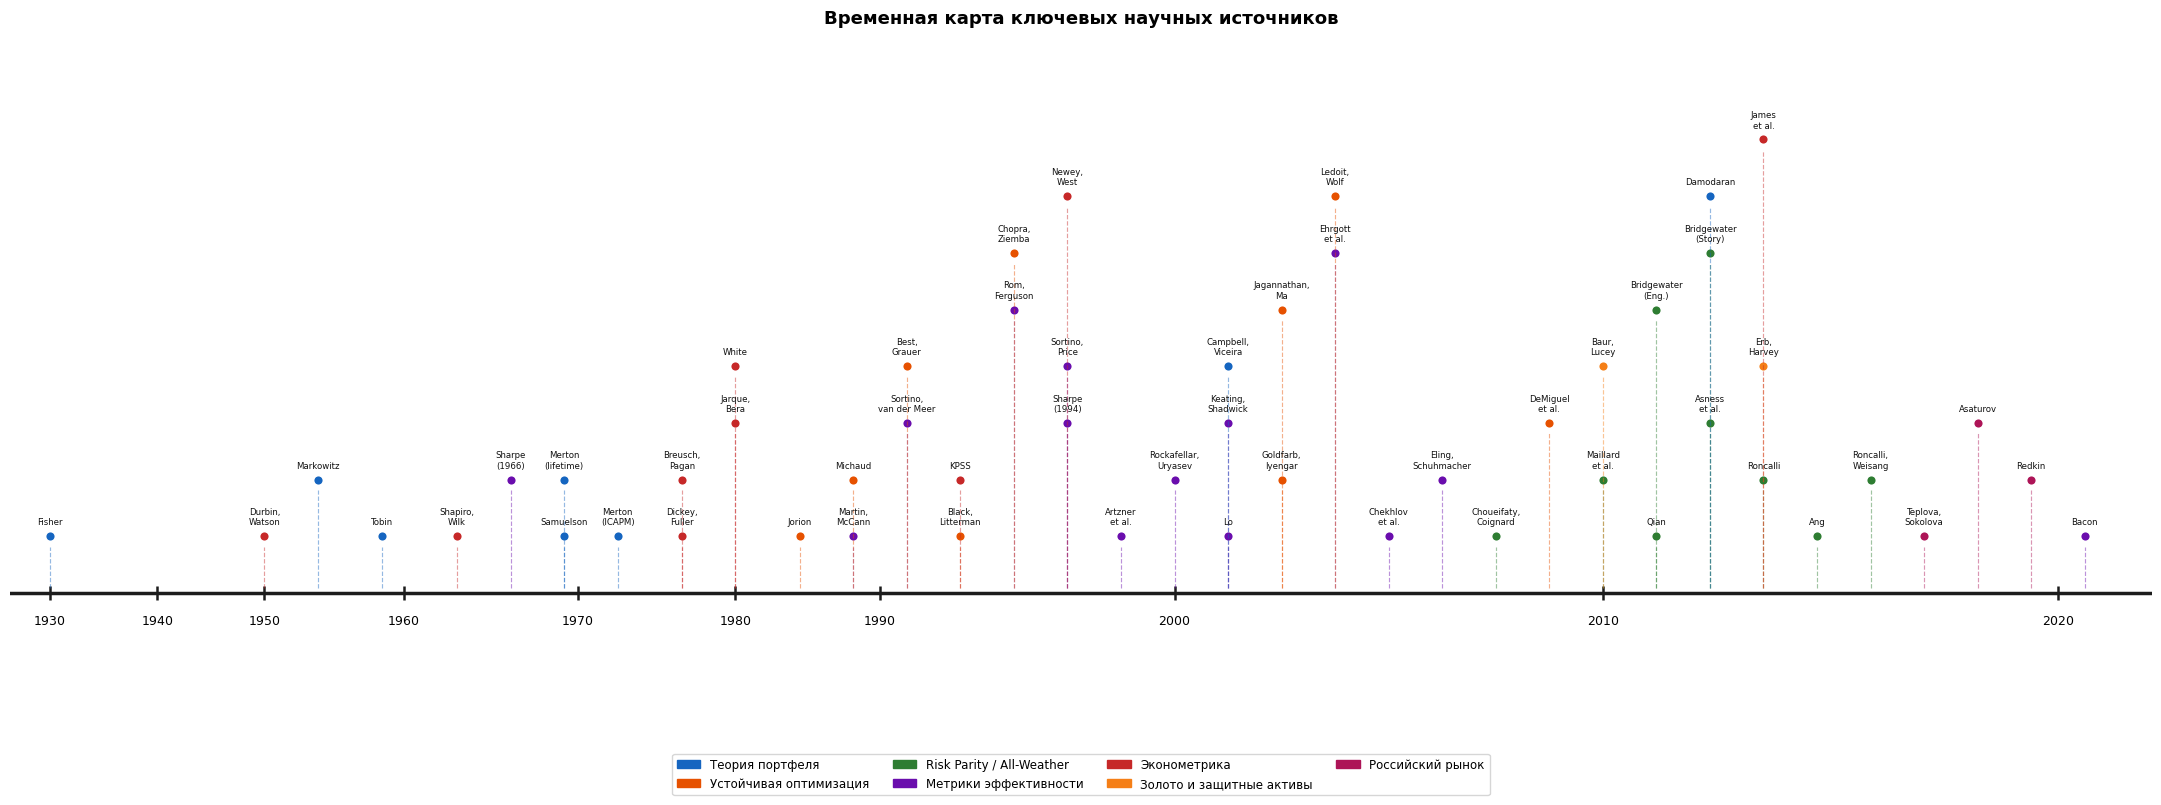

In [178]:
literature_timeline_figure = plot_literature_timeline(_PAPERS_RU, _CAT_RU)
save_figure(literature_timeline_figure, "bibliography_timeline_pptx", dpi=300, fmt="png")
_render_figure(literature_timeline_figure, show=True)


# 8. Дополнительные диагностические материалы


In [179]:
def summarize_asset_correlations(
    asset_returns: pd.DataFrame,
    *,
    reference_asset: str = "GLDRUB_TOM",
) -> tuple[pd.DataFrame, pd.Series]:
    """Вычисляет корреляционную матрицу и связи выбранного актива с остальными.

    Args:
        asset_returns: Дневные доходности активов.
        reference_asset: Актив, для которого нужна отдельная строка корреляций.

    Returns:
        Полная корреляционная матрица и корреляции reference_asset с остальными.

    Raises:
        KeyError: Если reference_asset отсутствует среди столбцов.
    """
    if reference_asset not in asset_returns.columns:
        raise KeyError(f"Unknown reference asset: {reference_asset}")
    correlation = asset_returns.corr()
    return correlation, correlation[reference_asset].drop(reference_asset)


def plot_asset_correlation(correlation: pd.DataFrame) -> Figure:
    """Строит тепловую карту корреляций доходностей активов.

    Args:
        correlation: Квадратная корреляционная матрица.

    Returns:
        Готовая фигура Matplotlib.
    """
    figure, axis = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8, "label": "Корреляция"},
        ax=axis,
    )
    axis.set_title("Корреляция дневных доходностей активов")
    figure.tight_layout()
    return figure


def calculate_yield_curve_spread(
    yield_curve: pd.DataFrame,
    *,
    short_column: str = "yield_1Y",
    long_column: str = "yield_10Y",
) -> pd.Series:
    """Рассчитывает спред длинного и короткого сегментов кривой ОФЗ.

    Args:
        yield_curve: Кривая доходности с временным индексом.
        short_column: Столбец короткого сегмента.
        long_column: Столбец длинного сегмента.

    Returns:
        Ряд long - short в процентных пунктах.

    Raises:
        KeyError: Если не найдены требуемые столбцы.
    """
    required_columns = {short_column, long_column}
    missing_columns = required_columns.difference(yield_curve.columns)
    if missing_columns:
        raise KeyError(f"Missing yield curve columns: {sorted(missing_columns)}")
    return yield_curve[long_column] - yield_curve[short_column]


def summarize_yield_curve_spread(spread: pd.Series) -> pd.Series:
    """Собирает описательные статистики спреда кривой доходности.

    Args:
        spread: Временной ряд long-short.

    Returns:
        Серия с ключевыми характеристиками спреда.
    """
    return pd.Series(
        {
            "Среднее, п.п.": spread.mean(),
            "Медиана, п.п.": spread.median(),
            "Минимум, п.п.": spread.min(),
            "Максимум, п.п.": spread.max(),
            "Стандартное отклонение, п.п.": spread.std(),
            "Доля инверсии, %": (spread < 0).mean() * 100,
        }
    )


def plot_yield_curve_spread(spread: pd.Series) -> Figure:
    """Строит временной ряд спреда 10Y-1Y и выделяет периоды инверсии.

    Args:
        spread: Временной ряд спреда в процентных пунктах.

    Returns:
        Фигура Matplotlib.
    """
    figure, axis = plt.subplots(figsize=(11, 4))
    axis.plot(spread.index, spread.to_numpy(), lw=1, color="steelblue")
    axis.axhline(0, color="red", linestyle="--", lw=1, label="Плоская кривая")
    axis.axhline(spread.mean(), color="green", linestyle=":", lw=1.3, label="Среднее")
    axis.fill_between(
        spread.index,
        spread.to_numpy(),
        0,
        where=spread.to_numpy() < 0,
        color="red",
        alpha=0.15,
        label="Инверсия",
    )
    axis.set_title("Спред бескупонной кривой ОФЗ: 10Y - 1Y")
    axis.set_xlabel("Дата")
    axis.set_ylabel("Спред, п.п.")
    axis.legend(loc="best", fontsize=9)
    axis.grid(alpha=0.3)
    figure.tight_layout()
    return figure


In [180]:
def test_block_8_summarizes_asset_correlations() -> None:
    returns = pd.DataFrame(
        {
            "A": [0.01, 0.02, 0.03],
            "GLDRUB_TOM": [0.02, 0.04, 0.06],
        }
    )

    correlation, gold_correlation = summarize_asset_correlations(returns)

    assert correlation.loc["A", "GLDRUB_TOM"] == pytest.approx(1.0)
    assert gold_correlation.index.tolist() == ["A"]


def test_block_8_calculates_yield_curve_spread() -> None:
    curve = pd.DataFrame({"yield_1Y": [7.0, 8.0], "yield_10Y": [8.5, 7.5]})

    spread = calculate_yield_curve_spread(curve)
    summary = summarize_yield_curve_spread(spread)

    assert spread.tolist() == [1.5, -0.5]
    assert summary["Доля инверсии, %"] == pytest.approx(50.0)


In [181]:
run_notebook_tests("test_block_8")


..                                                                                           [100%]


0

Корреляционная матрица Спец. 3:
            MCFTR  RUGBITR3Y  RUGBITR10Y  GLDRUB_TOM
MCFTR        1.00       0.50        0.54       -0.01
RUGBITR3Y    0.50       1.00        0.79       -0.04
RUGBITR10Y   0.54       0.79        1.00       -0.13
GLDRUB_TOM  -0.01      -0.04       -0.13        1.00

Золото и остальные активы:
MCFTR        -0.01
RUGBITR3Y    -0.04
RUGBITR10Y   -0.13
Сохранено: figures\asset_correlation_spec3.pdf


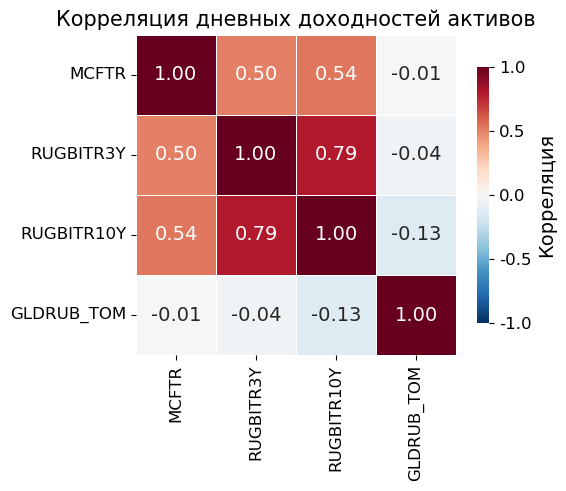


Спред кривой ОФЗ 10Y - 1Y:
Среднее, п.п.                    0.23
Медиана, п.п.                    0.36
Минимум, п.п.                   -6.69
Максимум, п.п.                   3.66
Стандартное отклонение, п.п.     1.58
Доля инверсии, %                39.84
Сохранено: figures\gcurve_spread_10_1.pdf


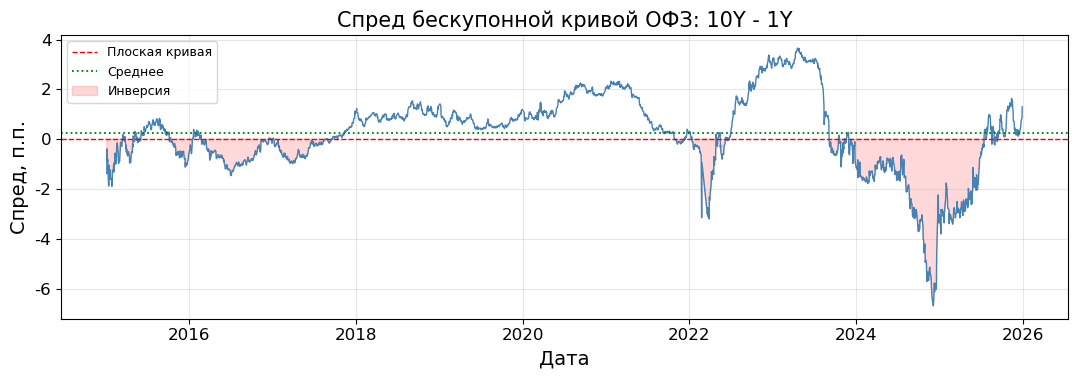

In [182]:
assets_spec3 = portfolio_3_daily_returns[asset_names_3]
asset_correlation, gold_correlation = summarize_asset_correlations(assets_spec3)

print("Корреляционная матрица Спец. 3:")
print(asset_correlation.round(2).to_string())
print("\nЗолото и остальные активы:")
print(gold_correlation.round(2).to_string())

asset_correlation_figure = plot_asset_correlation(asset_correlation)
save_figure(asset_correlation_figure, "asset_correlation_spec3")
_render_figure(asset_correlation_figure, show=True)

yield_curve_spread = calculate_yield_curve_spread(df_gcurve)
spread_summary = summarize_yield_curve_spread(yield_curve_spread)
print("\nСпред кривой ОФЗ 10Y - 1Y:")
print(spread_summary.round(2).to_string())

spread_figure = plot_yield_curve_spread(yield_curve_spread)
save_figure(spread_figure, "gcurve_spread_10_1")
_render_figure(spread_figure, show=True)
